# 성현님 코드

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

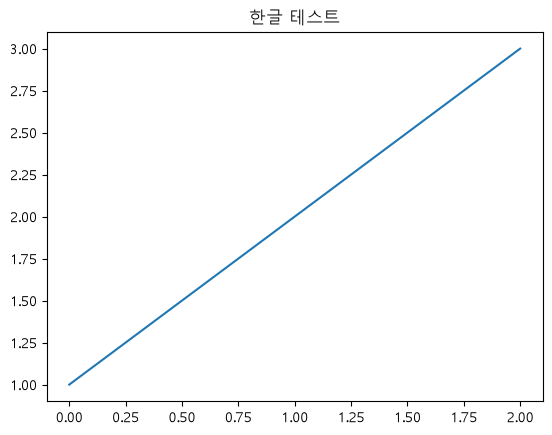

In [111]:
plt.plot([1, 2, 3])
plt.title("한글 테스트")
plt.show()

## 데이터 불러오기 

In [112]:
FILE_PATH = 'data/csv/data 1'

user_df = pd.read_csv(f'{FILE_PATH}/accounts_user_clean.csv')
friend_request = pd.read_csv(f'{FILE_PATH}/accounts_friendrequest_clean.csv')
user_question_record = pd.read_csv(f'{FILE_PATH}/accounts_userquestionrecord.csv')
polls_usercandidate = pd.read_csv(f'{FILE_PATH}/polls_usercandidate.csv')
point_history = pd.read_csv(f'{FILE_PATH}/accounts_pointhistory_clean.csv')
payment_history = pd.read_csv(f'{FILE_PATH}/accounts_paymenthistory_clean.csv')
attendance = pd.read_csv(f'{FILE_PATH}/accounts_attendance_clean.csv')
group = pd.read_csv(f'{FILE_PATH}/accounts_group.csv')
school = pd.read_csv(f'{FILE_PATH}/accounts_school.csv')
user_contacts = pd.read_csv(f'{FILE_PATH}/accounts_user_contacts_clean.csv')
block_record = pd.read_csv(f'{FILE_PATH}/accounts_blockrecord.csv')

events = pd.read_csv(f'{FILE_PATH}/events.csv')
event_receipts = pd.read_csv(f'{FILE_PATH}/event_receipts.csv')

### 각 테이블을 유저 단위로 집계

In [113]:
user_df.head(3)

,id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id,friend_count,block_user_count,hide_user_count
0,831962,0,0,F,2248,"[833025, 832642, 982531, 879496, 838541, 83752...",1,2023-03-29 05:18:56.162368,[],[],N,253,40878,5499,110,12,43,0,0
1,832151,0,0,M,1519,"[838785, 982531, 882567, 879496, 838541, 83649...",0,2023-03-29 12:56:34.989468,[],[],N,0,37,0,47,1,51,0,0
2,832340,0,0,F,57,"[841345, 982531, 838785, 963714, 882567, 83252...",1,2023-03-29 12:56:35.020790,[],[],N,0,19,0,21,1,57,0,0


In [114]:
user_df = user_df.drop(columns=['is_superuser','is_staff'])

In [115]:
user_contacts.head()

,id,contacts_count,invite_user_id_list,user_id,invite_user_count
0,259,30,[],1167696,0
1,1756,79,[],863169,0
2,13742,21,[854615],857205,1
3,13754,29,[],851431,0
4,13756,28,[849318],855476,1


---

In [116]:
events.head()

,id,title,plus_point,event_type,is_expired,created_at
0,1,코드잇 은행 가입 이벤트,500,FCFS,1,2023-06-20 11:56:38
1,2,코드잇 멤버십 가입 이벤트,1000,FCFS,1,2023-08-08 07:43:45
2,3,예고 영상 기대평 이벤트,500,FCFS,1,2023-09-24 17:05:59


In [117]:
event_receipts.head()

,id,created_at,event_id,user_id,plus_point
0,2,2023-06-22 09:25:16,1,1193618,500
1,3,2023-06-22 09:38:53,1,928351,500
2,4,2023-06-22 10:32:15,1,904872,500
3,5,2023-06-22 13:03:06,1,974697,500
4,6,2023-06-22 13:40:38,1,1168260,500


In [118]:
event_receipts.shape

(309, 5)

In [119]:
event_feature = (
    pd.merge(event_receipts, events, how='left', left_on='event_id', right_on='id')
)
event_feature = event_feature.drop(columns=['id_y','plus_point_x','created_at_y'])
event_feature = event_feature.rename(columns={'id_x':'id', 'created_at_x':'created_at', 'plus_point_y':'plus_point'})

event_feature

,id,created_at,event_id,user_id,title,plus_point,event_type,is_expired
0,2,2023-06-22 09:25:16,1,1193618,코드잇 은행 가입 이벤트,500,FCFS,1
1,3,2023-06-22 09:38:53,1,928351,코드잇 은행 가입 이벤트,500,FCFS,1
2,4,2023-06-22 10:32:15,1,904872,코드잇 은행 가입 이벤트,500,FCFS,1
3,5,2023-06-22 13:03:06,1,974697,코드잇 은행 가입 이벤트,500,FCFS,1
4,6,2023-06-22 13:40:38,1,1168260,코드잇 은행 가입 이벤트,500,FCFS,1
...,...,...,...,...,...,...,...,...
304,317,2023-11-14 11:17:29,3,918053,예고 영상 기대평 이벤트,500,FCFS,1
305,318,2023-11-15 05:09:02,3,932419,예고 영상 기대평 이벤트,500,FCFS,1
306,319,2023-11-17 06:17:25,3,1188104,예고 영상 기대평 이벤트,500,FCFS,1
307,320,2023-11-17 06:17:59,3,1296978,예고 영상 기대평 이벤트,500,FCFS,1


---

In [120]:
# friend_request 테이블 유저 별 집계 -> 유저 당 다른 유저에게 보낸 요청 수, 유저가 다른 유저에게 받은 요청 수, 수락한 친구 수, 대기/요청 거절 수
friend_request.head()

,id,status,created_at,updated_at,receive_user_id,send_user_id
0,11,A,2023-04-17 18:29:11,2023-04-18 19:28:41,832340,837521
1,13,A,2023-04-17 18:29:11,2023-04-19 11:05:04,833041,837521
2,10,A,2023-04-17 18:29:11,2023-04-22 06:02:53,832151,837521
3,46,A,2023-04-18 06:44:18,2023-06-01 01:14:53,835871,837523
4,53,A,2023-04-19 05:55:30,2023-04-19 08:47:32,835869,837524


In [121]:
unique_user_count = pd.concat(
    [friend_request['send_user_id'], friend_request['receive_user_id']]
).nunique()

print(f'고유 요청 보낸 유저 수: {friend_request['send_user_id'].nunique()}')
print(f'고유 요청 받은 유저 수: {friend_request['receive_user_id'].nunique()}')
print(f'고유 모든 유저 수: {unique_user_count}')

고유 요청 보낸 유저 수: 649072
고유 요청 받은 유저 수: 660841
고유 모든 유저 수: 673705


In [122]:
send_user_count = (
    friend_request.groupby('send_user_id')['receive_user_id']
    .nunique()
    .rename('send_request_count')
)

receive_user_count = (
    friend_request.groupby('receive_user_id')['send_user_id']
    .nunique()
    .rename('receive_request_count')
)

accept_request_count = (
    friend_request[friend_request['status'] == 'A']
    .groupby('send_user_id')['receive_user_id']
    .nunique()
    .rename('accept_request_count')
)

pend_rejected_request_count = (
    friend_request[friend_request['status'] != 'A']
    .groupby('send_user_id')['receive_user_id']
    .nunique()
    .rename('pend_rejected_request_count')
)

In [123]:
users = pd.Index(
    pd.concat([
        friend_request['send_user_id'],
        friend_request['receive_user_id']
    ]).unique(),
    name='user_id'
)

friend_feature = (
    pd.DataFrame(index=users)
    .join(send_user_count.rename_axis('user_id'))
    .join(receive_user_count.rename_axis('user_id'))
    .join(accept_request_count.rename_axis('user_id'))
    .join(pend_rejected_request_count.rename_axis('user_id'))
    .fillna(0)
    .reset_index()
)

In [124]:
count_cols = [
    'send_request_count',
    'receive_request_count',
    'accept_request_count',
    'pend_rejected_request_count'
]

friend_feature[count_cols] = friend_feature[count_cols].astype(int)

friend_feature

,user_id,send_request_count,receive_request_count,accept_request_count,pend_rejected_request_count
0,837521,7,53,3,4
1,837523,13,4,6,7
2,837524,8,23,6,2
3,837532,9,18,8,1
4,837534,14,25,10,4
...,...,...,...,...,...
673700,1390017,0,1,0,0
673701,1322099,0,1,0,0
673702,1581091,0,1,0,0
673703,1581812,0,1,0,0


---

In [125]:
group.head()

,id,grade,class_num,school_id
0,1,1,1,1
1,8,3,2,1
2,9,3,3,1
3,10,2,2,1
4,11,2,3,1


In [126]:
print(f'학급 데이터의 고유 학교 수: {group['school_id'].nunique()}')
print(f'학교 데이터의 고유 학교 수: {school.shape[0]}')

학급 데이터의 고유 학교 수: 5604
학교 데이터의 고유 학교 수: 5951


학급 데이터에는 학교 데이터에 있는 모든 학교가 존재하지 않는 상태

In [127]:
school = school.rename(columns={'id': 'school_id'})

school_group = (
    pd.merge(group, school, how='left', on='school_id')
)

school_group

,id,grade,class_num,school_id,address,student_count,school_type
0,1,1,1,1,NaN,NaN,NaN
1,8,3,2,1,NaN,NaN,NaN
2,9,3,3,1,NaN,NaN,NaN
3,10,2,2,1,NaN,NaN,NaN
4,11,2,3,1,NaN,NaN,NaN
...,...,...,...,...,...,...,...
84510,84542,3,2,5107,경기도 수원시 팔달구,198.0,H
84511,84543,2,7,3487,광주광역시 광산구,195.0,M
84512,84544,3,1,5043,경기도 안산시 단원구,15.0,M
84513,84545,2,7,416,충청남도 서산시,264.0,H


---

In [128]:
user_question_record.head()

,id,status,created_at,chosen_user_id,question_id,user_id,question_piece_id,has_read,answer_status,answer_updated_at,report_count,opened_times
0,771777,C,2023-04-28 12:27:49,849469,252,849436,998458,0,N,2023-04-28 12:27:49,0,0
1,771800,C,2023-04-28 12:28:02,849446,244,849436,998459,0,N,2023-04-28 12:28:02,0,0
2,771812,C,2023-04-28 12:28:09,849454,183,849436,998460,1,N,2023-04-28 12:28:09,0,0
3,771828,C,2023-04-28 12:28:16,847375,101,849436,998461,0,N,2023-04-28 12:28:16,0,0
4,771851,C,2023-04-28 12:28:26,849477,209,849436,998462,1,N,2023-04-28 12:28:26,0,0


In [129]:
print(f'총 데이터 row 수: {user_question_record.shape[0]}')

unique_user_count = pd.concat(
    [user_question_record['chosen_user_id'], user_question_record['user_id']]
).nunique()

print(f'고유 투표 선택한 유저 수: {user_question_record['user_id'].nunique()}')
print(f'고유 투표 선택받은 유저 수: {user_question_record['chosen_user_id'].nunique()}')
print(f'고유 모든 유저 수: {unique_user_count}')

총 데이터 row 수: 1217558
고유 투표 선택한 유저 수: 4849
고유 투표 선택받은 유저 수: 15426
고유 모든 유저 수: 15452


In [130]:
# 유저 별 투표한 수, 받은 투표 수, 결과 확인 여부, 결과 열람 횟수, 유저 별 신고 횟수
vote_send_count = (
    user_question_record.groupby('user_id')['question_piece_id']
    .size()
    .rename('vote_send_count')  
)
vote_received_count = (
    user_question_record.groupby('chosen_user_id')['question_piece_id']
    .size()
    .rename('vote_received_count')
)
result_open_count = (
    user_question_record.groupby('user_id')['opened_times']
    .sum()
    .rename('result_open_count')
)
user_report_count = (
    user_question_record.groupby('user_id')['report_count']
    .sum()
    .rename('user_report_count')
)

In [131]:
users = pd.Index(
    pd.concat([
        user_question_record['user_id'],
        user_question_record['chosen_user_id']
    ]).unique(),
    name='user_id'
)

vote_feature = (
    pd.DataFrame(index=users)
    .join(vote_send_count.rename_axis('user_id'))
    .join(vote_received_count.rename_axis('user_id'))
    .join(result_open_count.rename_axis('user_id'))
    .join(user_report_count.rename_axis('user_id'))
    .fillna(0)
    .reset_index()
)

count_cols = [
    'vote_send_count',
    'vote_received_count',
    'result_open_count',
    'user_report_count'
]

vote_feature[count_cols] = vote_feature[count_cols].astype(int)

vote_feature

,user_id,vote_send_count,vote_received_count,result_open_count,user_report_count
0,849436,638,398,7,0
1,847375,378,834,21,0
2,849438,306,405,24,0
3,849479,472,216,16,0
4,849441,119,369,9,0
...,...,...,...,...,...
15447,854411,0,1,0,0
15448,1552101,0,1,0,0
15449,1131886,0,1,0,0
15450,865788,0,1,0,0


---

In [132]:
polls_usercandidate.head()

,id,created_at,question_piece_id,user_id
0,3088872,2023-04-28 12:27:49,998458,849444
1,3088873,2023-04-28 12:27:49,998458,849454
2,3088874,2023-04-28 12:27:49,998458,849460
3,3088875,2023-04-28 12:27:49,998458,849469
4,3088964,2023-04-28 12:28:02,998459,849446


In [133]:
polls_usercandidate['user_id'].nunique()

19994

In [134]:
# 유저 별 투표 후보 등장 수 집계
user_candidate = (
    polls_usercandidate.groupby('user_id')['question_piece_id'].size()
    .reset_index()
)
user_candidate = user_candidate.rename(columns={'question_piece_id': 'user_candidate_count'})

---

In [135]:
point_history.head()

,id,delta_point,created_at,user_id,user_question_record_id
0,145705235,-1000,2023-05-18 12:51:30,1117193,54641410.0
1,145748211,-1000,2023-05-18 12:53:42,1138997,55851981.0
2,145870757,-1000,2023-05-18 12:59:44,1156301,58954316.0
3,145961455,-1000,2023-05-18 13:04:01,1303729,56455390.0
4,146066190,-1000,2023-05-18 13:09:12,863427,71932526.0


In [136]:
use_point_df = point_history[point_history['delta_point'] < 0]
get_point_df = point_history[point_history['delta_point'] > 0]

In [137]:
print(f'고유 유저 수: {point_history['user_id'].nunique()}')

print(f'포인트 사용 고유 유저 수: {use_point_df['user_id'].nunique()}')
print(f'포인트 획득 고유 유저 수: {get_point_df['user_id'].nunique()}')

고유 유저 수: 5037
포인트 사용 고유 유저 수: 4609
포인트 획득 고유 유저 수: 5037


In [138]:
# 포인트 사용량, 포인트 사용 횟수 집계

user_point_used = (
    use_point_df.groupby('user_id')
    .agg(
        total_used_point=('delta_point', 'sum'),
        point_used_count=('delta_point', 'count')
    )
)

user_point_used['total_used_point'] = abs(user_point_used['total_used_point'])

user_point_used

,total_used_point,point_used_count
user_id,,
838023,600,2
838466,3800,13
838642,300,1
839357,1700,6
840293,1200,4
...,...,...
1571821,200,1
1576039,200,1
1576107,200,1


In [139]:
# 포인트 획득량, 무료 포인트 획득 횟수 집계

user_point_get = (
    get_point_df.groupby('user_id')
    .agg(
        total_get_point=('delta_point', 'sum'),
        point_get_count=('delta_point', 'count')
    )
)

user_point_get

,total_get_point,point_get_count
user_id,,
838023,1665,173
838466,4748,474
838642,344,37
839357,3048,302
839670,139,14
...,...,...
1578443,200,1
1579418,488,49
1579659,50,1


In [140]:
point_feature = (
    user_point_used
    .join(user_point_get, how='outer')
    .fillna(0)
    .astype(int)
    .reset_index()
)

point_feature

,user_id,total_used_point,point_used_count,total_get_point,point_get_count
0,838023,600,2,1665,173
1,838466,3800,13,4748,474
2,838642,300,1,344,37
3,839357,1700,6,3048,302
4,839670,0,0,139,14
...,...,...,...,...,...
5032,1578443,0,0,200,1
5033,1579418,0,0,488,49
5034,1579659,0,0,50,1
5035,1580578,0,0,10,2


---

In [141]:
payment_history.head()

,id,productId,phone_type,created_at,user_id
0,6,heart.777,A,2023-05-13 21:28:34,1211127
1,7,heart.777,A,2023-05-13 21:29:39,1151343
2,8,heart.777,A,2023-05-13 21:31:33,1002147
3,9,heart.777,A,2023-05-13 21:31:39,1095040
4,11,heart.777,A,2023-05-13 21:34:32,1164081


In [142]:
print(f'결제 고유 유저 수: {payment_history['user_id'].nunique()}')

결제 고유 유저 수: 59192


In [143]:
payment_history['productId'].unique()

<StringArray>
['heart.777', 'heart.200', 'heart.4000', 'heart.1000']
Length: 4, dtype: str

In [144]:
# 가격 컬럼 생성 (가격은 기능 figma에서 참조)

conditions = [
    payment_history['productId'] == 'heart.200',
    payment_history['productId'] == 'heart.777',
    payment_history['productId'] == 'heart.1000',
    payment_history['productId'] == 'heart.4000'
]

values = [900, 1900, 2900, 9900]

payment_history['price'] = np.select(conditions, values, default=0)

In [145]:
payment_history.head()

,id,productId,phone_type,created_at,user_id,price
0,6,heart.777,A,2023-05-13 21:28:34,1211127,1900
1,7,heart.777,A,2023-05-13 21:29:39,1151343,1900
2,8,heart.777,A,2023-05-13 21:31:33,1002147,1900
3,9,heart.777,A,2023-05-13 21:31:39,1095040,1900
4,11,heart.777,A,2023-05-13 21:34:32,1164081,1900


In [146]:
payment_history['created_at'] = pd.to_datetime(payment_history['created_at'])

In [147]:
print(f'데이터 기간: {payment_history['created_at'].min()} ~ {payment_history['created_at'].max()}')

데이터 기간: 2023-05-13 21:28:34 ~ 2024-05-08 14:12:45


In [148]:
# 유저 별 결제 여부, 결제 횟수, 첫 결제일, 총 결제금액(결제 여부는 집계 테이블 만든 이후 범주형(1) 컬럼 추가)
payment_feature = (
    payment_history.groupby('user_id').agg(
        payment_count=('productId', 'count'),
        first_payment_day=('created_at', 'min'),
        last_payment_day=('created_at', 'max'),
        revenue=('price', 'sum')
    )
    .reset_index()
)

payment_feature['is_paid_user'] = 1

# 하트 구매 빈도 
payment_feature['payment_frequency'] = payment_feature['payment_count'] / 12

# 유저 당 건단가 
payment_feature['avg_payment_value'] = payment_feature['revenue'] / payment_feature['payment_count']

payment_feature['avg_payment_value'] = np.floor(payment_feature['avg_payment_value'])

In [149]:
payment_feature

,user_id,payment_count,first_payment_day,last_payment_day,revenue,is_paid_user,payment_frequency,avg_payment_value
0,833041,2,2023-05-14 07:59:46,2023-05-15 01:50:06,19800,1,0.166667,9900.0
1,834112,1,2023-05-21 23:55:46,2023-05-21 23:55:46,1900,1,0.083333,1900.0
2,835815,3,2023-06-10 14:17:45,2023-06-10 14:19:17,3700,1,0.250000,1233.0
3,835839,1,2023-05-15 16:37:30,2023-05-15 16:37:30,1900,1,0.083333,1900.0
4,835888,2,2023-06-06 04:58:49,2023-06-06 04:59:22,2800,1,0.166667,1400.0
...,...,...,...,...,...,...,...,...
59187,1583408,3,2024-03-24 14:22:50,2024-03-24 14:23:29,5700,1,0.250000,1900.0
59188,1583445,1,2024-03-28 13:58:23,2024-03-28 13:58:23,900,1,0.083333,900.0
59189,1583450,1,2024-03-26 13:37:40,2024-03-26 13:37:40,1900,1,0.083333,1900.0
59190,1583454,2,2024-03-27 05:36:38,2024-03-27 05:37:02,3800,1,0.166667,1900.0


In [150]:
payment_feature_copy = payment_feature.copy()

payment_feature_copy['purchase_group'] = np.where(
    payment_feature_copy['payment_count'] >= 4,
    '4+',
    payment_feature_copy['payment_count'].astype(str)
)

In [151]:
summary = (
    payment_feature_copy.groupby('purchase_group')
      .agg(
          Customer_Count=('payment_count', 'size'),
          Total_Sales=('revenue', 'sum'),
          Avg_AOV=('avg_payment_value', 'mean'),
          Avg_Purchase_Cycle=('payment_frequency', 'mean')
      )
)

summary['Sales_Ratio(%)'] = (
    summary['Total_Sales']
    / summary['Total_Sales'].sum()
    * 100
).round(2)

In [152]:
summary

,Customer_Count,Total_Sales,Avg_AOV,Avg_Purchase_Cycle,Sales_Ratio(%)
purchase_group,,,,,
1,43277,85079300,1965.924163,0.083333,42.48
2,8453,35758400,2115.130723,0.166667,17.86
3,3378,21745600,2145.503552,0.250000,10.86
4+,4084,57680800,2312.519099,0.495674,28.80


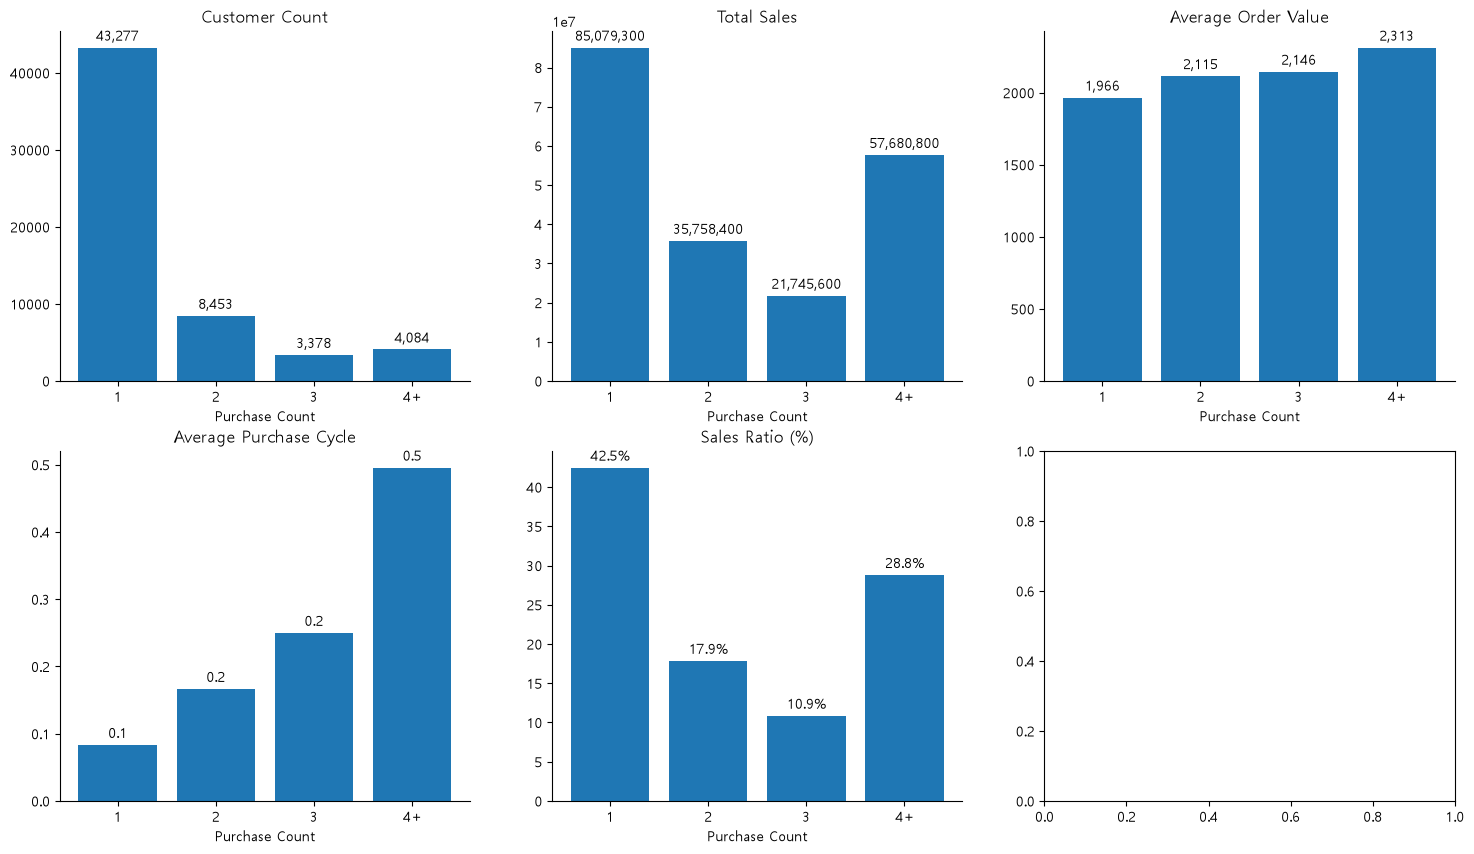

In [153]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

cols = [
    'Customer_Count',
    'Total_Sales',
    'Avg_AOV',
    'Avg_Purchase_Cycle',
    'Sales_Ratio(%)'
]

titles = [
    'Customer Count',
    'Total Sales',
    'Average Order Value',
    'Average Purchase Cycle',
    'Sales Ratio (%)'
]

for i, (col, title) in enumerate(zip(cols, titles)):
    ax = axes[i]

    bars = ax.bar(
        summary.index.astype(str),
        summary[col]
    )

    labels = []

    for value in summary[col]:
        if pd.isna(value):
            labels.append("")
        elif col == 'Sales_Ratio(%)':
            labels.append(f'{value:.1f}%')
        elif col == 'Avg_Purchase_Cycle':
            labels.append(f'{value:.1f}')
        elif col == 'Customer_Count':
            labels.append(f'{int(value):,}')
        else:
            labels.append(f'{value:,.0f}')

    ax.bar_label(
        bars,
        labels=labels,
        padding=3,
        fontsize=10
    )

    ax.set_title(title)
    ax.set_xlabel('Purchase Count')

    # 오른쪽, 위쪽 테두리 제거
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

---

In [154]:
attendance.head()

,id,attendance_date_list,user_id,attendance_count
0,1,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",1446852,13
1,2,"[""2023-05-27"", ""2023-05-29"", ""2023-05-30"", ""20...",1359398,33
2,3,"[""2023-05-27"", ""2023-05-29"", ""2023-05-30"", ""20...",1501542,9
3,4,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",1507767,30
4,5,"[""2023-05-27"", ""2023-05-28"", ""2023-05-29"", ""20...",1287453,31


In [155]:
print(f'총 데이터 row 수 : {attendance.shape[0]}')
print(f'고객 고유 수: {attendance['user_id'].nunique()}')

총 데이터 row 수 : 349637
고객 고유 수: 349637


In [156]:
# 리스트 형태인지, 문자열 형태인지
print(type(attendance['attendance_date_list'].iloc[0]))

<class 'str'>


In [157]:
# 출석 횟수, 마지막 출석일, 첫 출석일 
import ast

attendance['attendance_date_list'] = attendance['attendance_date_list'].apply(ast.literal_eval)
attendance['first_attend'] = attendance['attendance_date_list'].str[0]
attendance['last_attend'] = attendance['attendance_date_list'].str[-1]

In [158]:
attendance_feature = attendance[['user_id','attendance_count','first_attend','last_attend']]

attendance_feature

,user_id,attendance_count,first_attend,last_attend
0,1446852,13,2023-05-27,2023-09-19
1,1359398,33,2023-05-27,2023-08-22
2,1501542,9,2023-05-27,2023-06-14
3,1507767,30,2023-05-27,2023-06-30
4,1287453,31,2023-05-27,2023-06-28
...,...,...,...,...
349632,897005,0,NaN,NaN
349633,1407059,1,2024-05-09,2024-05-09
349634,1583727,1,2024-05-09,2024-05-09
349635,1392372,1,2024-05-09,2024-05-09


---

### user 테이블을 기준으로 집계한 것 merge

In [159]:
user_df.head(2)

,id,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes,group_id,friend_count,block_user_count,hide_user_count
0,831962,F,2248,"[833025, 832642, 982531, 879496, 838541, 83752...",1,2023-03-29 05:18:56.162368,[],[],N,253,40878,5499,110,12,43,0,0
1,832151,M,1519,"[838785, 982531, 882567, 879496, 838541, 83649...",0,2023-03-29 12:56:34.989468,[],[],N,0,37,0,47,1,51,0,0


In [160]:
user_df.shape

(677080, 17)

In [161]:
user_df['id'].nunique()

677080

In [162]:
user_df = user_df.set_index('id')
friend_feature = friend_feature.set_index('user_id')
vote_feature = vote_feature.set_index('user_id')
user_candidate = user_candidate.set_index('user_id')
point_feature = point_feature.set_index('user_id')
payment_feature = payment_feature.set_index('user_id')
attendance_feature = attendance_feature.set_index('user_id')

In [163]:
master = (
    user_df
    .join(friend_feature, how='outer')
    .join(vote_feature, how='outer')
    .join(user_candidate, how='outer')
    .join(point_feature, how='outer')
    .join(payment_feature, how='outer')
    .join(attendance_feature, how='outer')
    .reset_index()
)

In [164]:
print(f'집계 테이블과 user 테이블 merge 하기 전 고유 user 수: {user_df.index.nunique()}')
print(f'집계 테이블과 user 테이블 merge 하기 후 고유 user 수: {master['id'].nunique()}')

집계 테이블과 user 테이블 merge 하기 전 고유 user 수: 677080
집계 테이블과 user 테이블 merge 하기 후 고유 user 수: 677080


In [165]:
master.head(2)

,id,gender,point,friend_id_list,is_push_on,created_at,block_user_id_list,hide_user_id_list,ban_status,report_count,...,payment_count,first_payment_day,last_payment_day,revenue,is_paid_user,payment_frequency,avg_payment_value,attendance_count,first_attend,last_attend
0,831962,F,2248,"[833025, 832642, 982531, 879496, 838541, 83752...",1,2023-03-29 05:18:56.162368,[],[],N,253,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,832151,M,1519,"[838785, 982531, 882567, 879496, 838541, 83649...",0,2023-03-29 12:56:34.989468,[],[],N,0,...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,1.0,2023-05-29,2023-05-29


In [166]:
master.info()

<class 'pandas.DataFrame'>
RangeIndex: 677080 entries, 0 to 677079
Data columns (total 40 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   id                           677080 non-null  int64         
 1   gender                       677080 non-null  str           
 2   point                        677080 non-null  int64         
 3   friend_id_list               677080 non-null  str           
 4   is_push_on                   677080 non-null  int64         
 5   created_at                   677080 non-null  str           
 6   block_user_id_list           677080 non-null  str           
 7   hide_user_id_list            677080 non-null  str           
 8   ban_status                   677080 non-null  str           
 9   report_count                 677080 non-null  int64         
 10  alarm_count                  677080 non-null  int64         
 11  pending_chat                 677080 n

In [167]:
# 날짜 컬럼들 결측치 채우기
master['first_payment_day'] = master['first_payment_day'].fillna('None')
master['last_payment_day'] = master['last_payment_day'].fillna('None')
master['first_attend'] = master['first_attend'].fillna('None')
master['last_attend'] = master['last_attend'].fillna('None')

# 나머지 컬럼들 0으로 채우기
master = master.fillna(0)

## 결제 전환에 영향을 미치는 변수 조합 알아보기

### 결제 전환에 영향을 미치는 변수 찾기

**결제 전환에 영향을 미칠 것 같은 변수들**

- friend_count
- send_request_count
- receive_request_count

- vote_send_count
- vote_received_count

- user_candidate_count
- attendance_count

In [168]:
master[['friend_count', 'send_request_count', 'receive_request_count',
    'vote_send_count', 'vote_received_count', 'user_candidate_count', 'attendance_count']].describe()

,friend_count,send_request_count,receive_request_count,vote_send_count,vote_received_count,user_candidate_count,attendance_count
count,677080.000000,677080.000000,677080.000000,677080.000000,677080.000000,677080.000000,677080.000000
mean,53.328085,25.164285,25.164285,1.798248,1.798248,7.044380,3.282222
std,32.226378,23.335575,19.489883,28.702964,23.069632,86.831452,7.307701
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000
50%,49.000000,20.000000,21.000000,0.000000,0.000000,0.000000,0.000000
75%,70.000000,34.000000,36.000000,0.000000,0.000000,0.000000,4.000000
max,1373.000000,1549.000000,218.000000,2786.000000,1239.000000,4226.000000,310.000000


In [169]:
# 분포가 그나마 정상적인 'friend_count', 'send_request_count', 'receive_request_count' 의 범위수 결제율 확인
cols = [
    'friend_count', 'send_request_count', 'receive_request_count'
]

summary_list = []

for col in cols:
    temp = master[[col, 'is_paid_user']].copy()

    temp['bin'] = pd.qcut(
        temp[col],
        q=4,
        duplicates='drop'
    )

    summary = (
        temp.groupby('bin', observed=True)['is_paid_user']
            .agg(count='count', paid_ratio='mean')
            .reset_index()
    )

    summary['column'] = col
    summary['paid_ratio'] *= 100

    summary_list.append(summary)

final_result = pd.concat(summary_list, ignore_index=True)

final_result

,bin,count,paid_ratio,column
0,"(-0.001, 31.0]",172278,5.054041,friend_count
1,"(31.0, 49.0]",175523,8.432513,friend_count
2,"(49.0, 70.0]",163417,10.000184,friend_count
3,"(70.0, 1373.0]",165862,11.661502,friend_count
4,"(-0.001, 10.0]",176121,5.827244,send_request_count
5,"(10.0, 20.0]",175054,8.298011,send_request_count
6,"(20.0, 34.0]",162590,9.770589,send_request_count
7,"(34.0, 1549.0]",163315,11.338211,send_request_count
8,"(-0.001, 10.0]",181961,5.786405,receive_request_count
9,"(10.0, 21.0]",159669,8.433697,receive_request_count


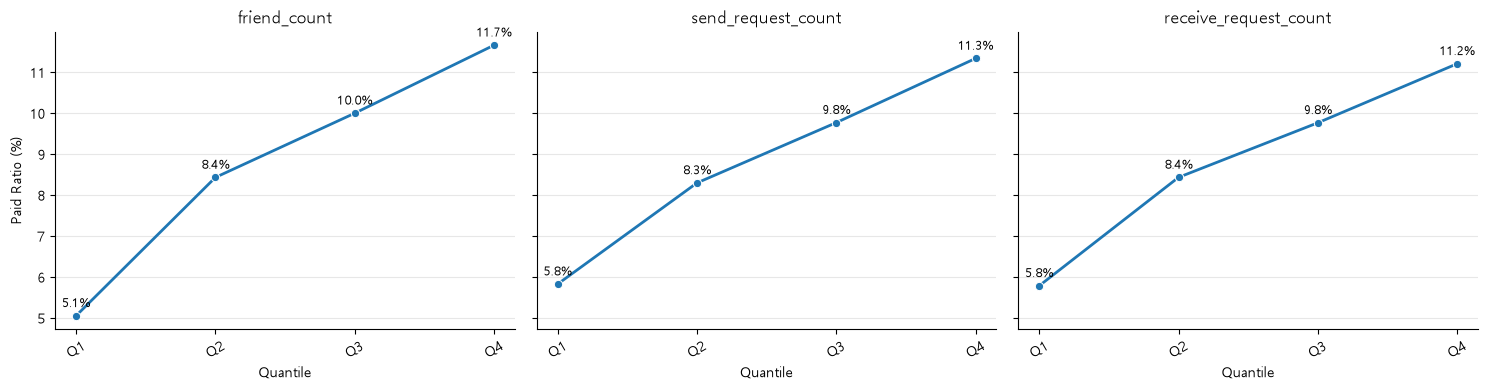

In [170]:
labels = ['Q1', 'Q2', 'Q3', 'Q4']

final_result['quantile'] = labels * (len(final_result) // 4)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, col in zip(axes, final_result['column'].unique()):
    temp = final_result[final_result['column'] == col]

    sns.lineplot(
        data=temp,
        x='quantile',
        y='paid_ratio',
        marker='o',
        linewidth=2,
        ax=ax
    )

    for x, y in zip(temp['quantile'], temp['paid_ratio']):
        ax.text(
            x=x,
            y=y + 0.15,          # 점보다 약간 위에 표시
            s=f'{y:.1f}%',
            ha='center',
            va='bottom',
            fontsize=9
        )

    ax.set_title(col)
    ax.set_xlabel('Quantile')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)

    # 위, 오른쪽 테두리 제거
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Paid Ratio (%)')

plt.tight_layout()
plt.show()

In [171]:
# friend_count, send_request_count, receive_request_count 제외한 변수들은 절댓값으로 범위를 나누고 확인
# 'vote_send_count', 'vote_received_count', 'user_candidate_count', 'attendance_count'
master[['vote_send_count', 'vote_received_count', 'user_candidate_count', 'attendance_count']].describe()

,vote_send_count,vote_received_count,user_candidate_count,attendance_count
count,677080.000000,677080.000000,677080.000000,677080.000000
mean,1.798248,1.798248,7.044380,3.282222
std,28.702964,23.069632,86.831452,7.307701
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,4.000000
max,2786.000000,1239.000000,4226.000000,310.000000


In [172]:
# 1차 분해 : 값이 0인 그룹 vs 값이 0이 아닌 그룹 
# 2차 분해 : 값이 0이 아닌 그룹에서 범위 나누기

# 1차 분해 후 결제율 비교
cols = [
    'vote_send_count',
    'vote_received_count',
    'user_candidate_count',
    'attendance_count'
]

result_list = []

for col in cols:
    temp = master[[col, 'is_paid_user']].copy()
    
    # zero vs non-zero 그룹 생성
    temp['group'] = temp[col].apply(lambda x: 'zero' if x == 0 else 'non_zero')
    
    # 그룹별 결제율 계산
    agg = temp.groupby('group')['is_paid_user'].agg(
        payment_rate='mean',
        count='size'
    ).reset_index()
    
    agg['variable'] = col
    result_list.append(agg)

result_df = pd.concat(result_list, ignore_index=True) 

result_df

,group,payment_rate,count,variable
0,non_zero,0.084554,4849,vote_send_count
1,zero,0.087443,672231,vote_send_count
2,non_zero,0.078633,15426,vote_received_count
3,zero,0.087627,661654,vote_received_count
4,non_zero,0.079424,19994,user_candidate_count
5,zero,0.087666,657086,user_candidate_count
6,non_zero,0.126465,328692,attendance_count
7,zero,0.050587,348388,attendance_count


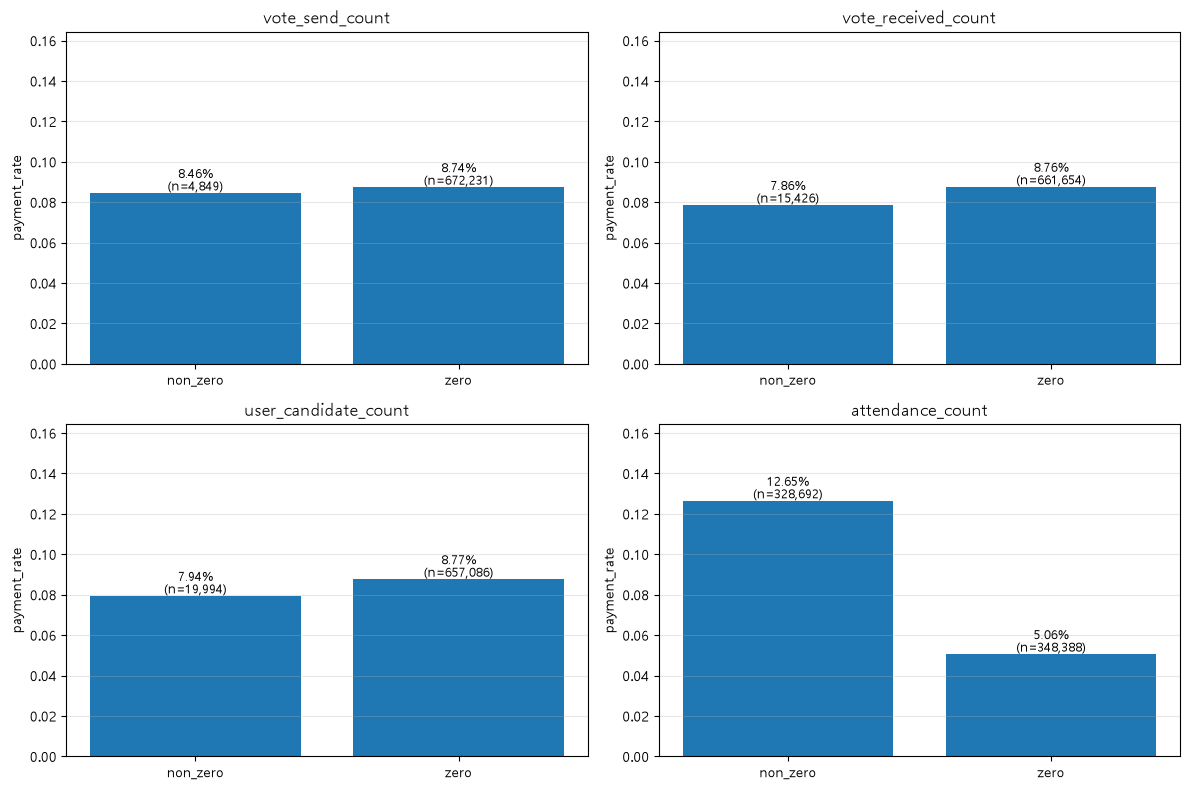

In [173]:
# variable 목록
variables = result_df['variable'].unique()

# subplot grid 계산 (가로 2개 기준)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, var in enumerate(variables):
    ax = axes[i]
    
    temp = result_df[result_df['variable'] == var].copy()
    temp = temp.sort_values('group')

    bars = ax.bar(
        temp['group'],
        temp['payment_rate']
    )

    # bar annotation (rate + count)
    for bar, (_, row) in zip(bars, temp.iterrows()):
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{row['payment_rate']:.2%}\n(n={row['count']:,})",
            ha='center',
            va='bottom',
            fontsize=9
        )

    ax.set_title(var)
    ax.set_ylim(0, result_df['payment_rate'].max() * 1.3)
    ax.set_xlabel("")
    ax.set_ylabel("payment_rate")
    ax.grid(axis='y', alpha=0.3)

# 빈 subplot 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [174]:
# user_candidate_count는 집계했을 때, 0인 값이 없는 상태 -> 0인 값은 데이터가 존재하지 않는 값 = 투표 후보에 등장하지 않았다라고 해석 가능
# vote_received_count,vote_send_count, attendance_count는 집계했을 때, 0인 값이 일부 존재했음 -> 따라서 0인 값이 실제로 측정 시 0과 데이터가 존재하지 않는 0이 공존하고 있음 
# 지금 확인하고 있는 컬럼들은 유저 집계 테이블에서 나온 컬럼들이기 때문에 0인 값을 모두 실제로 측정 시 0으로 해도 상관 없다

vote_send_non_zero = (
    master.loc[master['vote_send_count'] > 0, ['vote_send_count','is_paid_user']]
)

vote_received_non_zero = (
    master.loc[master['vote_received_count'] > 0, ['vote_received_count','is_paid_user']]
)

user_candidate_non_zero = (
    master.loc[master['user_candidate_count'] > 0, ['user_candidate_count','is_paid_user']]
)

attendance_non_zero = (
    master.loc[master['attendance_count'] > 0, ['attendance_count','is_paid_user']]
)


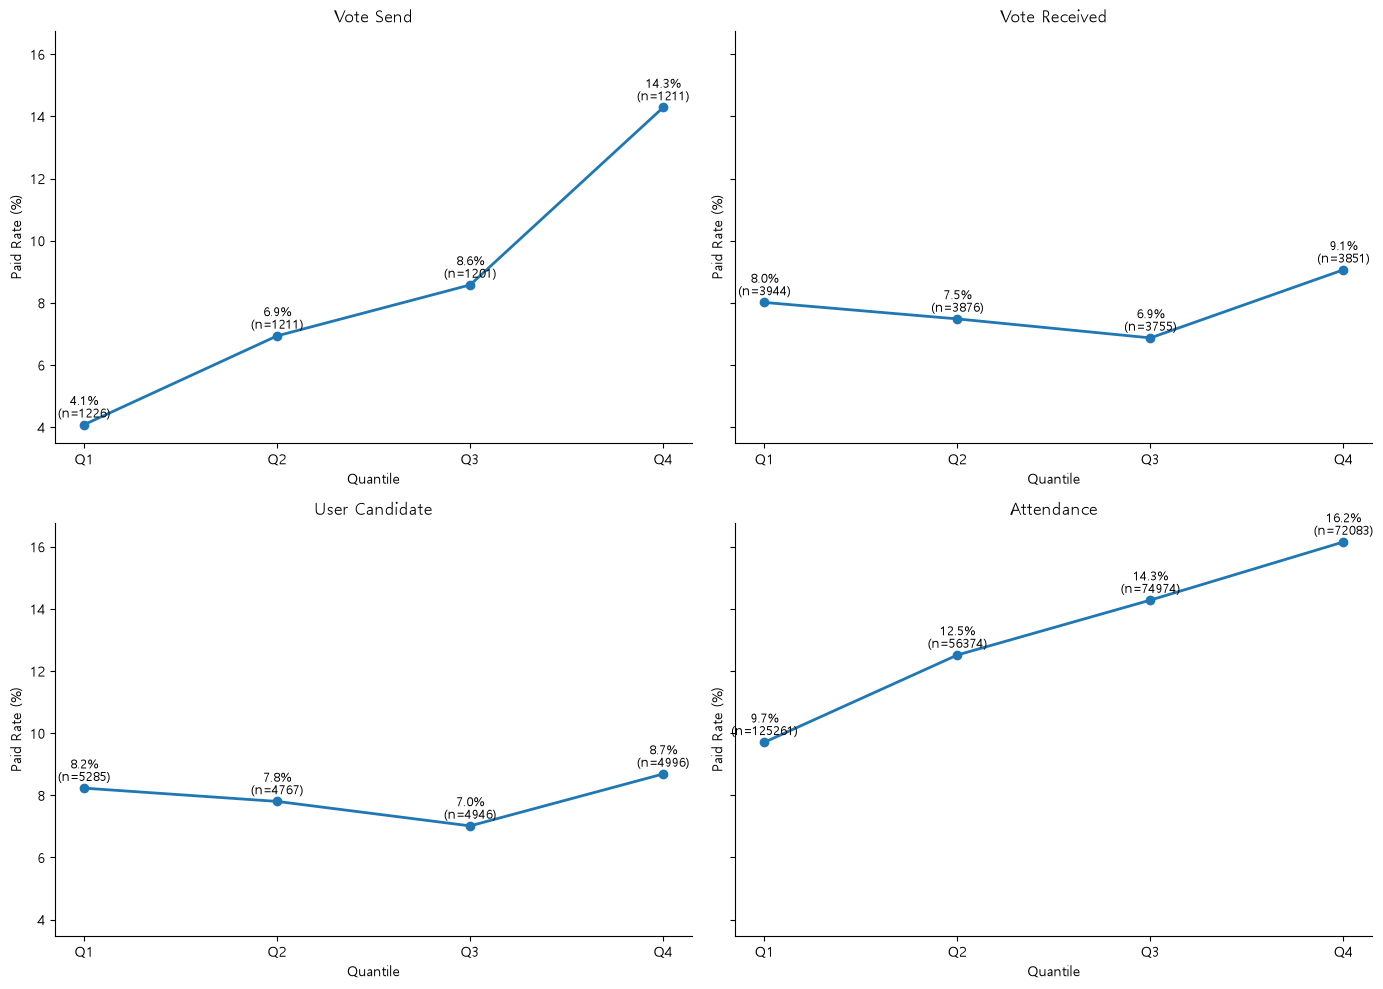

In [175]:
# 분석 대상
df_dict = {
    'Vote Send': vote_send_non_zero,
    'Vote Received': vote_received_non_zero,
    'User Candidate': user_candidate_non_zero,
    'Attendance': attendance_non_zero
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()

for ax, (title, df) in zip(axes, df_dict.items()):

    # count 컬럼 찾기
    count_col = [col for col in df.columns if col != 'is_paid_user'][0]

    temp = df.copy()

    # 분위수(Q1~Q4)
    temp['quantile'] = pd.qcut(
        temp[count_col],
        q=4,
        labels=['Q1', 'Q2', 'Q3', 'Q4'],
        duplicates='drop'
    )

    # 결제율 및 표본 수 계산
    summary = (
        temp.groupby('quantile', observed=True)
            .agg(
                paid_rate=('is_paid_user', lambda x: x.mean() * 100),
                sample_size=('is_paid_user', 'size')
            )
            .reset_index()
    )

    # Line plot
    ax.plot(
        summary['quantile'],
        summary['paid_rate'],
        marker='o',
        linewidth=2
    )

    # 점마다 백분율 및 표본 수 표시
    for _, row in summary.iterrows():
        ax.text(
            row['quantile'],
            row['paid_rate'] + 0.15,
            f"{row['paid_rate']:.1f}%\n(n={row['sample_size']})",
            ha='center',
            va='bottom',
            fontsize=9
        )

    ax.set_title(title)
    ax.set_xlabel('Quantile')
    ax.set_ylabel('Paid Rate (%)')

    # 오른쪽, 위쪽 테두리 제거
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [176]:
master[['friend_count', 'send_request_count', 'receive_request_count',
    'vote_send_count','attendance_count']].describe() 

,friend_count,send_request_count,receive_request_count,vote_send_count,attendance_count
count,677080.000000,677080.000000,677080.000000,677080.000000,677080.000000
mean,53.328085,25.164285,25.164285,1.798248,3.282222
std,32.226378,23.335575,19.489883,28.702964,7.307701
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,10.000000,10.000000,0.000000,0.000000
50%,49.000000,20.000000,21.000000,0.000000,0.000000
75%,70.000000,34.000000,36.000000,0.000000,4.000000
max,1373.000000,1549.000000,218.000000,2786.000000,310.000000


### 변수 간 상관관계

In [177]:
# 변수 간 상관관계 분석 
features = ['friend_count', 'send_request_count', 'receive_request_count',
    'vote_send_count', 'vote_received_count', 'user_candidate_count', 'attendance_count']

x = master[features]

corr = x.corr()

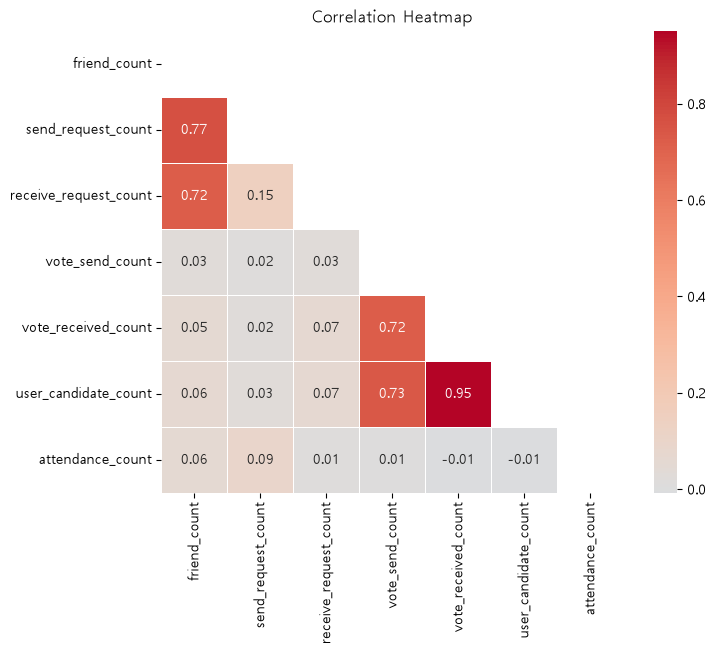

In [178]:
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [179]:
# VIF 변수
vif = pd.DataFrame()

vif["Variable"] = x.columns

vif["VIF"] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

vif

,Variable,VIF
0,friend_count,91.901270
2,receive_request_count,30.574375
1,send_request_count,28.397029
5,user_candidate_count,11.122227
4,vote_received_count,10.698406
3,vote_send_count,2.207705
6,attendance_count,1.171493


- VIF 계산 후 먼저 91.9점인 friend_count를 제거한 후 다시 VIF 계산

In [180]:
x_new = x.drop(columns=['friend_count'])

vif = pd.DataFrame()

vif["Variable"] = x_new.columns

vif["VIF"] = [
    variance_inflation_factor(x_new.values, i)
    for i in range(x_new.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

vif

,Variable,VIF
4,user_candidate_count,11.121927
3,vote_received_count,10.698403
2,vote_send_count,2.207675
0,send_request_count,1.770853
1,receive_request_count,1.744050
5,attendance_count,1.171421


- 이후 다시 계산해보았을 땐, 투표 노출 횟수가 11.1점, 투표를 받은 횟수가 10.6점으로 높은 것을 확인할 수 있다.
    - 둘 중 하나를 제거해야 하는데, 두 개의 관점은 약간 다른 것 같다.
    - 투표 노출 횟수는 서비스 안에서 얼마나 자주 등장하고 반응을 만들 수 있는지 보는 지표
    - 투표를 받은 횟수는 다른 유저들이 나를 선택했다는 의미라서 영향력이나 주목도를 볼 수 있는 지표라고 생각한다.

- 고민해 본 결과, 단순 노출되는 것보다, 투표를 받아야 받은 사람이 포인트를 사용할 수 있는 상황이니까 투표를 받은 횟수가 결제 관련해선 더 중요할 것 같다.
    - **따라서 user_candidate_count(투표 노출 횟수) 변수를 제거하였다.**

In [181]:
x_new2 = x_new.drop(columns=['user_candidate_count'])

vif = pd.DataFrame()

vif["Variable"] = x_new2.columns

vif["VIF"] = [
    variance_inflation_factor(x_new2.values, i)
    for i in range(x_new2.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

vif

,Variable,VIF
3,vote_received_count,2.109840
2,vote_send_count,2.098219
0,send_request_count,1.768947
1,receive_request_count,1.744034
4,attendance_count,1.171206


**결제 전환에 영향을 미칠 것 같은 변수들**

**전체 유저를 대상으로 결제율 확인한 변수**
- send_request_count
- receive_request_count

**0 이상 즉, 활동이 있는 유저를 대상으로 결제율 확인한 변수**
- vote_send_count
- attendance_count

**문제점**

- 변수 조합을 확인하기 전에 4개의 변수의 **모집단이 서로 다른 것**을 확인할 수 있다.
- 전체 유저 x 활동 유저 조합을 비교하게 될 경우 의도와는 다르게 해석될 수 있다.

--

- 따라서 전체 유저 기준 or 활동 유저 기준으로 통일해야 하는데 활동 유저 기준으로 하면 표본이 너무 적어진다. 
- vote_send_count, attendance_count도 전체 유저를 기준으로 측정한 결제율을 확인해보면
    - attendance_count는 결제율이 증가하고, vote_send_count는 결제율에 큰 차이가 없으니 attendance_count를 남기고, vote_send_count는 제외하는 것이 좋을 것 같다.

**결제 전환에 영향을 미칠 것 같은 변수들(최종)**

- send_request_count
- receive_request_count
- attendance_count

### 변수들을 조합해서 어느 조합이 결제 전환에 가장 큰 영향을 미치는가

In [182]:
master_copy = master.copy()

variables = [
    'send_request_count',
    'receive_request_count',
    'attendance_count'
]

send_bins = [-1, 10, 20, 34, float('inf')]
send_labels = [
    '0~10',
    '11~20',
    '21~34',
    '35+'
]

master_copy['send_bin'] = pd.cut(
    master_copy['send_request_count'],
    bins=send_bins,
    labels=send_labels
)

receive_bins = [-1, 10, 21, 36, float('inf')]
receive_labels = [
    '0~10',
    '11~21',
    '22~36',
    '37+'
]

master_copy['receive_bin'] = pd.cut(
    master_copy['receive_request_count'],
    bins=receive_bins,
    labels=receive_labels
)

In [183]:
master_copy.loc[master_copy['attendance_count'] > 0, 'attendance_count'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count    328692.000000
mean          6.761123
std           9.299667
min           1.000000
25%           2.000000
50%           4.000000
75%           9.000000
90%          15.000000
95%          22.000000
99%          42.000000
max         310.000000
Name: attendance_count, dtype: float64

In [184]:
attendance_bins = [-1, 0, 2, 4, 9, float('inf')]
attendance_labels = [
    '0',
    '1~2',
    '3~4',
    '5~9',
    '10+'
]

master_copy['attendance_bin'] = pd.cut(
    master_copy['attendance_count'],
    bins=attendance_bins,
    labels=attendance_labels
)

In [185]:
from itertools import combinations

bin_cols = [
    'send_bin',
    'receive_bin',
    'attendance_bin'
]

pairs = list(combinations(bin_cols, 2))

pairs

[('send_bin', 'receive_bin'),
 ('send_bin', 'attendance_bin'),
 ('receive_bin', 'attendance_bin')]

In [186]:
pair1 = (
    'send_bin',
    'receive_bin'
)

pivot1 = pd.pivot_table(
    master_copy,
    index=pair1[0],
    columns=pair1[1],
    values='is_paid_user',
    aggfunc='mean'
)

count_table1 = pd.pivot_table(
    master_copy,
    index=pair1[0],
    columns=pair1[1],
    values='is_paid_user',
    aggfunc='count'
)

display(count_table1)

display(pivot1)

receive_bin,0~10,11~21,22~36,37+
send_bin,,,,
0~10,66545,39639,35703,34234
11~20,47879,43894,44024,39257
21~34,36347,39710,43267,43266
35+,31190,36426,43594,52105


receive_bin,0~10,11~21,22~36,37+
send_bin,,,,
0~10,0.030055,0.058806,0.077557,0.092394
11~20,0.060632,0.078895,0.091836,0.104873
21~34,0.075164,0.091866,0.103636,0.116073
35+,0.092786,0.110471,0.114098,0.127147


In [187]:
pair2 = (
    'send_bin',
    'attendance_bin'
)

pivot2 = pd.pivot_table(
    master_copy,
    index=pair2[0],
    columns=pair2[1],
    values='is_paid_user',
    aggfunc='mean'
)

count_table2 = pd.pivot_table(
    master_copy,
    index=pair2[0],
    columns=pair2[1],
    values='is_paid_user',
    aggfunc='count'
)

display(count_table2)

display(pivot2)

attendance_bin,0,1~2,3~4,5~9,10+
send_bin,,,,,
0~10,115357,26344,10239,12751,11430
11~20,89805,33580,14811,19183,17675
21~34,73838,32557,15402,20888,19905
35+,69388,32780,15922,22152,23073


attendance_bin,0,1~2,3~4,5~9,10+
send_bin,,,,,
0~10,0.031138,0.080474,0.113585,0.130735,0.150569
11~20,0.049195,0.091691,0.116062,0.133243,0.155813
21~34,0.060728,0.099180,0.122452,0.141948,0.166893
35+,0.073932,0.113850,0.143701,0.158902,0.166732


In [188]:
pair3 = (
    'receive_bin',
    'attendance_bin'
)

pivot3 = pd.pivot_table(
    master_copy,
    index=pair3[0],
    columns=pair3[1],
    values='is_paid_user',
    aggfunc='mean'
)

count_table3 = pd.pivot_table(
    master_copy,
    index=pair3[0],
    columns=pair3[1],
    values='is_paid_user',
    aggfunc='count'
)

display(count_table3)

display(pivot3)

attendance_bin,0,1~2,3~4,5~9,10+
receive_bin,,,,,
0~10,106338,29532,12755,16628,16708
11~21,80761,29213,13444,18438,17813
22~36,79799,32549,14975,19957,19308
37+,81490,33967,15200,19951,18254


attendance_bin,0,1~2,3~4,5~9,10+
receive_bin,,,,,
0~10,0.030506,0.074732,0.095492,0.107529,0.124012
11~21,0.050656,0.091055,0.113508,0.135318,0.151238
22~36,0.058409,0.100925,0.133957,0.147517,0.174746
37+,0.069064,0.117997,0.151711,0.174477,0.191958


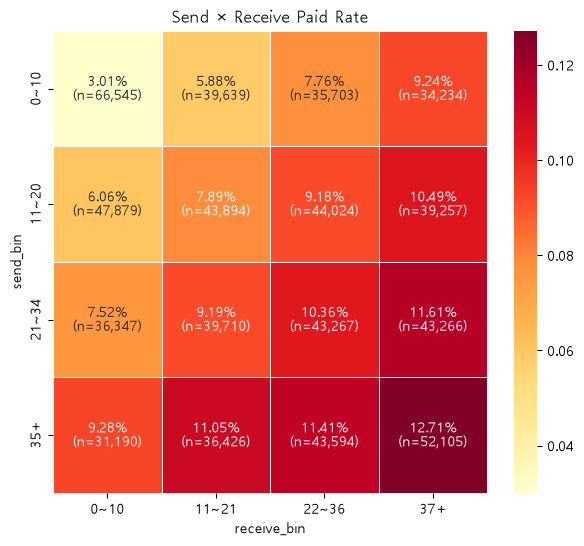

In [189]:
# annotation 생성
annot = pivot1.copy().astype(str)

for i in range(pivot1.shape[0]):
    for j in range(pivot1.shape[1]):
        rate = pivot1.iloc[i, j]
        cnt = count_table1.iloc[i, j]
        annot.iloc[i, j] = f"{rate:.2%}\n(n={cnt:,})"

plt.figure(figsize=(7,6))

sns.heatmap(
    pivot1,
    annot=annot,
    fmt="",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title('Send × Receive Paid Rate')
plt.show()

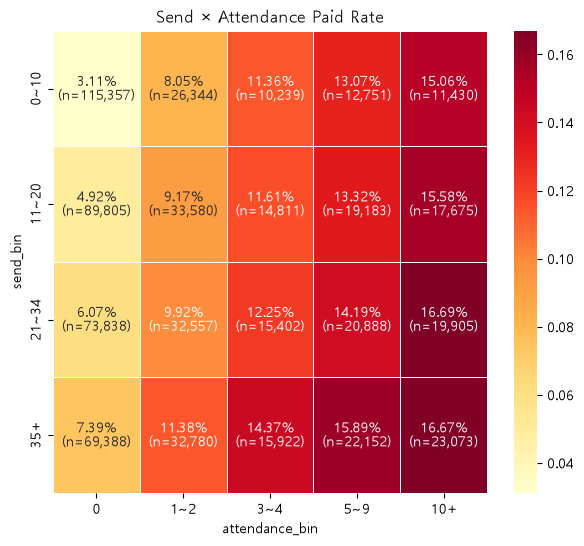

In [190]:
# annotation 생성
annot = pivot2.copy().astype(str)

for i in range(pivot2.shape[0]):
    for j in range(pivot2.shape[1]):
        rate = pivot2.iloc[i, j]
        cnt = count_table2.iloc[i, j]
        annot.iloc[i, j] = f"{rate:.2%}\n(n={cnt:,})"

plt.figure(figsize=(7,6))

sns.heatmap(
    pivot2,
    annot=annot,
    fmt="",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title('Send × Attendance Paid Rate')
plt.show()

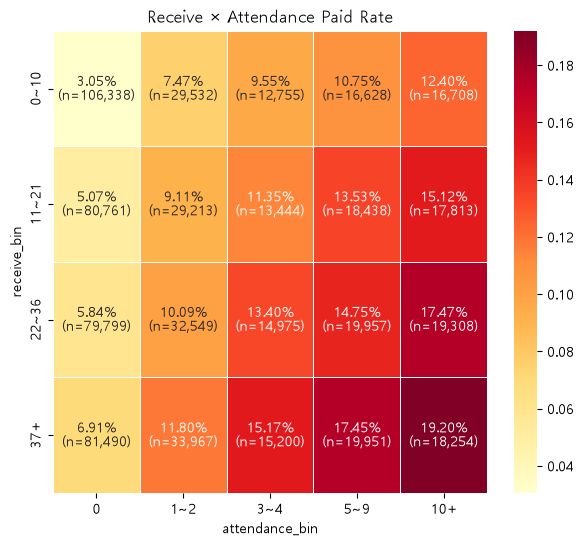

In [191]:
# annotation 생성
annot = pivot3.copy().astype(str)

for i in range(pivot3.shape[0]):
    for j in range(pivot3.shape[1]):
        rate = pivot3.iloc[i, j]
        cnt = count_table3.iloc[i, j]
        annot.iloc[i, j] = f"{rate:.2%}\n(n={cnt:,})"

plt.figure(figsize=(7,6))

sns.heatmap(
    pivot3,
    annot=annot,
    fmt="",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title('Receive × Attendance Paid Rate')
plt.show()

In [192]:
# lift 계산
overall_rate = master_copy['is_paid_user'].mean()

lift1 = pivot1 / overall_rate
lift2 = pivot2 / overall_rate
lift3 = pivot3 / overall_rate

In [193]:
# 각 조합마다 최대 결제율, 최대 lift 저장
max_rate1 = pivot1.max().max()
max_rate2 = pivot2.max().max()
max_rate3 = pivot3.max().max()

max_lift1 = lift1.max().max()
max_lift2 = lift2.max().max()
max_lift3 = lift3.max().max()

In [194]:
print(f'전체 평균 결제율: {round(overall_rate ,2) * 100}%')
print(f'Send × Receive 조합에서의 최대 결제율: {round(max_rate1, 3) * 100}%, 최대 Lift: {round(max_lift1, 3)}')
print(f'Send × Attendance 조합에서의 최대 결제율: {round(max_rate2, 3) * 100}%, 최대 Lift: {round(max_lift2, 3)}')
print(f'Receive × Attendance 조합에서의 최대 결제율: {round(max_rate3, 3) * 100}%, 최대 Lift: {round(max_lift3, 3)}')

전체 평균 결제율: 9.0%
Send × Receive 조합에서의 최대 결제율: 12.7%, 최대 Lift: 1.454
Send × Attendance 조합에서의 최대 결제율: 16.7%, 최대 Lift: 1.909
Receive × Attendance 조합에서의 최대 결제율: 19.2%, 최대 Lift: 2.196


### 실제로 최대 결제율을 보여주는 조합이 우연히 발생한 결과인가? 아니면 확실한 차이가 있어 발생한 결과인지 검증

- 최대 결제율을 보여주는 그룹과 그 외 그룹 간 통계 검정을 진행하여 우연히 발생한 건지, 아니면 확실한 차이가 있는지 확인해볼 예정 

1. 카이제곱 검정: 변수 조합과 결제 여부 사이에 전체적인 연관성이 있는지 확인.
2. Cramér's V: 그 연관성의 크기를 평가.
3. 두 비율 Z-test: 최고 결제율 그룹과 최저 결제율 그룹(또는 관심 있는 두 그룹)의 결제율 차이가 유의한지 검정.
4. Lift: 통계적 유의성과 별개로 비즈니스적 효과를 해석.

#### 카이제곱 검정 + Cramer's V

In [195]:
master_copy.info() # bin 범위 컬럼이 모두 categorical 타입

<class 'pandas.DataFrame'>
RangeIndex: 677080 entries, 0 to 677079
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   id                           677080 non-null  int64   
 1   gender                       677080 non-null  str     
 2   point                        677080 non-null  int64   
 3   friend_id_list               677080 non-null  str     
 4   is_push_on                   677080 non-null  int64   
 5   created_at                   677080 non-null  str     
 6   block_user_id_list           677080 non-null  str     
 7   hide_user_id_list            677080 non-null  str     
 8   ban_status                   677080 non-null  str     
 9   report_count                 677080 non-null  int64   
 10  alarm_count                  677080 non-null  int64   
 11  pending_chat                 677080 non-null  int64   
 12  pending_votes                677080 non-null  int64   


In [196]:
master_copy['send_bin'] = master_copy['send_bin'].astype(str)
master_copy['receive_bin'] = master_copy['receive_bin'].astype(str)
master_copy['attendance_bin'] = master_copy['attendance_bin'].astype(str)

In [197]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

In [198]:
def cramers_v(chi2, n, r, k):
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

In [199]:
def chi_square_summary(df, var1, var2, target='is_paid_user'):
    
    # 교차표 (조합 × 결제)
    table = pd.crosstab(
        index=df[var1] + "_" + df[var2],
        columns=df[target]
    )
    
    chi2, p, dof, expected = chi2_contingency(table)
    
    n = table.values.sum()
    r, k = table.shape
    
    v = cramers_v(chi2, n, r, k)
    
    return {
        "pair": f"{var1} × {var2}",
        "chi2": chi2,
        "p_value": p,
        "cramers_v": v
    }

In [200]:
results = []

pairs = [
    ('send_bin', 'receive_bin'),
    ('send_bin', 'attendance_bin'),
    ('receive_bin', 'attendance_bin')
]

for v1, v2 in pairs:
    res = chi_square_summary(master_copy, v1, v2)
    results.append(res)

result_df = pd.DataFrame(results)
result_df

,pair,chi2,p_value,cramers_v
0,send_bin × receive_bin,6176.745598,0.0,0.095512
1,send_bin × attendance_bin,16523.586119,0.0,0.156218
2,receive_bin × attendance_bin,17676.751943,0.0,0.161578


In [201]:
result_df = result_df.sort_values(
    by=['cramers_v', 'chi2'],
    ascending=False
)

result_df

,pair,chi2,p_value,cramers_v
2,receive_bin × attendance_bin,17676.751943,0.0,0.161578
1,send_bin × attendance_bin,16523.586119,0.0,0.156218
0,send_bin × receive_bin,6176.745598,0.0,0.095512


**결론**

- P-value는 모든 조합 전부 0이 나왔음 
    - 하지만 이 결과는 표본 수가 매우 크기 때문에 발생했을 가능성이 존재함. 따라서 크래머 V 계수도 계산
- 크래머 V 계수 결과는 다음과 같다.
    - send_bin × receive_bin 조합은 0.09로 상대적으로 약한 관계를 가지며
    - send_bin × attendance_bin 조합은 0.156으로 중간
    - receive_bin × attendance_bin 조합은 0.161로 **결제와 상대적으로 가장 강한 연관성**을 가진다.

#### 두 비율 Z-test

In [202]:
from statsmodels.stats.proportion import proportions_ztest

def z_test_from_pivot(df, pivot, var1, var2, target='is_paid_user'):

    # 최고/최저 결제율 위치
    high_idx = pivot.stack().idxmax()
    low_idx = pivot.stack().idxmin()

    # 최고 그룹
    high_group = df[
        (df[var1] == high_idx[0]) &
        (df[var2] == high_idx[1])
    ]

    # 최저 그룹
    low_group = df[
        (df[var1] == low_idx[0]) &
        (df[var2] == low_idx[1])
    ]

    # 결제자 수
    paid_high = high_group[target].sum()
    paid_low = low_group[target].sum()

    # 전체 인원
    n_high = len(high_group)
    n_low = len(low_group)

    # Z-test
    z_stat, p_value = proportions_ztest(
        count=[paid_high, paid_low],
        nobs=[n_high, n_low]
    )

    return {
        "pair": f"{var1} × {var2}",
        "high_group": high_idx,
        "high_rate": paid_high / n_high,
        "high_n": n_high,
        "low_group": low_idx,
        "low_rate": paid_low / n_low,
        "low_n": n_low,
        "z_stat": z_stat,
        "p_value": p_value
    }

In [203]:
results = []

results.append(
    z_test_from_pivot(
        master_copy,
        pivot1,
        'send_bin',
        'receive_bin'
    )
)

results.append(
    z_test_from_pivot(
        master_copy,
        pivot2,
        'send_bin',
        'attendance_bin'
    )
)

results.append(
    z_test_from_pivot(
        master_copy,
        pivot3,
        'receive_bin',
        'attendance_bin'
    )
)

result_df = pd.DataFrame(results)

In [204]:
result_df['high_rate'] = result_df['high_rate'].map('{:.2%}'.format)
result_df['low_rate'] = result_df['low_rate'].map('{:.2%}'.format)

display(result_df)

,pair,high_group,high_rate,high_n,low_group,low_rate,low_n,z_stat,p_value
0,send_bin × receive_bin,"(35+, 37+)",12.71%,52105,"(0~10, 0~10)",3.01%,66545,63.927930,0.0
1,send_bin × attendance_bin,"(21~34, 10+)",16.69%,19905,"(0~10, 0)",3.11%,115357,80.313093,0.0
2,receive_bin × attendance_bin,"(37+, 10+)",19.20%,18254,"(0~10, 0)",3.05%,106338,89.036681,0.0


---

## 결제 전환에 영향을 미치는 두 변수를 통해 사분면을 나누고 사분면에 따른 유저 별 특징 분석

In [205]:
master.info()

<class 'pandas.DataFrame'>
RangeIndex: 677080 entries, 0 to 677079
Data columns (total 40 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           677080 non-null  int64  
 1   gender                       677080 non-null  str    
 2   point                        677080 non-null  int64  
 3   friend_id_list               677080 non-null  str    
 4   is_push_on                   677080 non-null  int64  
 5   created_at                   677080 non-null  str    
 6   block_user_id_list           677080 non-null  str    
 7   hide_user_id_list            677080 non-null  str    
 8   ban_status                   677080 non-null  str    
 9   report_count                 677080 non-null  int64  
 10  alarm_count                  677080 non-null  int64  
 11  pending_chat                 677080 non-null  int64  
 12  pending_votes                677080 non-null  int64  
 13  group_id  

- **receive_request_count  × attendance_count 조합**이 결제 전환에 가장 크게 영향을 주는 조합으로 결론이 나왔다. 

    - 이제 이 2개의 변수가 정확히 어떤 수치에서 결제율이 급격히 증가하는 지 확인하고 
    - 해당 수치를 기준으로 유저를 4그룹으로 나눈 다음
    - 각 그룹의 특징을 분석하고 
    - 특징이 맞게 각 그룹에 전략을 세우는 것이 목적이다.

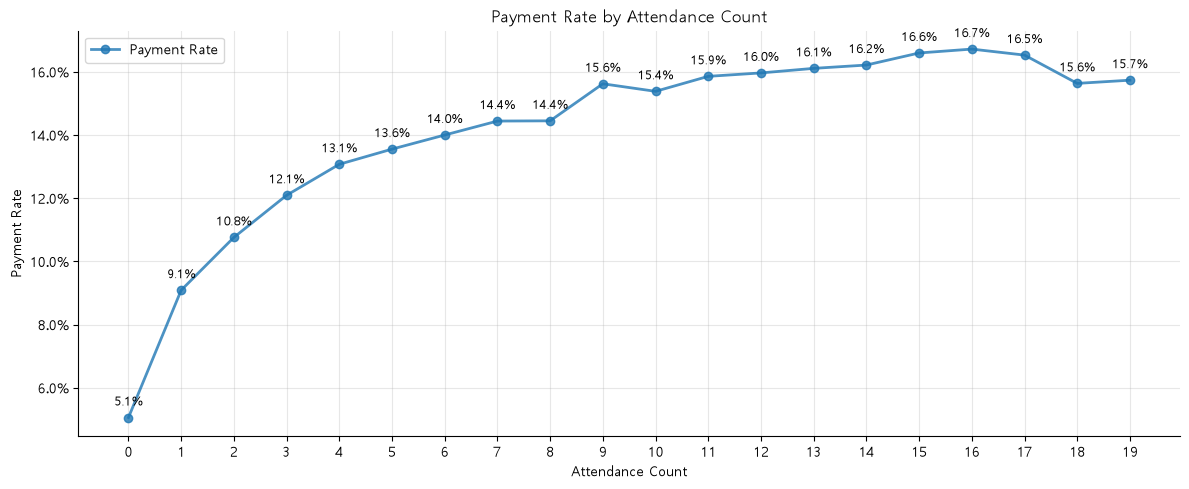

In [206]:
attendance_rate = (
    master.groupby('attendance_count')['is_paid_user']
      .agg(['mean', 'count'])
      .reset_index()
)

attendance_rate = attendance_rate.loc[
    (attendance_rate['count'] >= 100) &
    (attendance_rate['attendance_count'] < 20)
]

attendance_rate = attendance_rate.sort_values('attendance_count')

attendance_rate['diff'] = attendance_rate['mean'].diff()

plt.figure(figsize=(12, 5))

from matplotlib.ticker import PercentFormatter

ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

# Line + Marker
plt.plot(
    attendance_rate['attendance_count'],
    attendance_rate['mean'],
    marker='o',          # 점 추가
    markersize=6,
    linewidth=2,
    alpha=0.8,
    label='Payment Rate'
)

# 각 점에 결제율(%) 표시
for x, y in zip(attendance_rate['attendance_count'], attendance_rate['mean']):
    plt.text(
        x,
        y + 0.003,              # 점보다 약간 위
        f'{y:.1%}',             # % 표시 (예: 12.3%)
        ha='center',
        va='bottom',
        fontsize=9
    )

# x축을 1 단위로 표시
plt.xticks(range(
    int(attendance_rate['attendance_count'].min()),
    int(attendance_rate['attendance_count'].max()) + 1,
    1
))

plt.xlabel('Attendance Count')
plt.ylabel('Payment Rate')
plt.title('Payment Rate by Attendance Count')

plt.legend()
plt.grid(alpha=0.3)

# 위, 오른쪽 테두리 제거
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

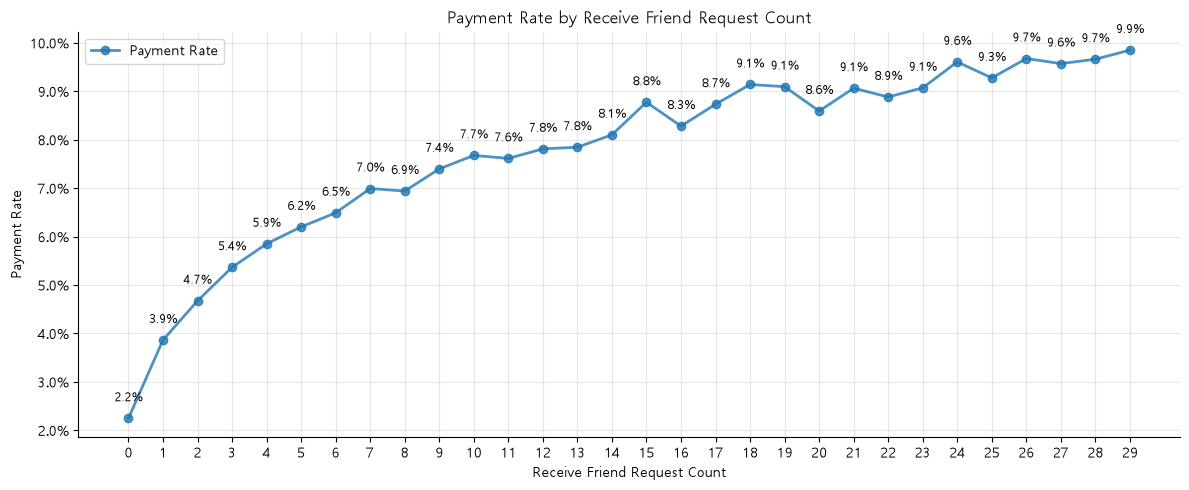

In [207]:
receive_request_rate = (
    master.groupby('receive_request_count')['is_paid_user']
      .agg(['mean', 'count'])
      .reset_index()
)

receive_request_rate = receive_request_rate.loc[
    (receive_request_rate['count'] >= 100) & (receive_request_rate['receive_request_count'] < 30)
]

receive_request_rate = receive_request_rate.sort_values('receive_request_count')

receive_request_rate['diff'] = receive_request_rate['mean'].diff()

plt.figure(figsize=(12, 5))

from matplotlib.ticker import PercentFormatter

ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

# Line + Marker
plt.plot(
    receive_request_rate['receive_request_count'],
    receive_request_rate['mean'],
    marker='o',          # 점 추가
    markersize=6,
    linewidth=2,
    alpha=0.8,
    label='Payment Rate'
)

# 각 점에 결제율(%) 표시
for x, y in zip(receive_request_rate['receive_request_count'], receive_request_rate['mean']):
    plt.text(
        x,
        y + 0.003,              # 점보다 약간 위
        f'{y:.1%}',             # % 표시 (예: 12.3%)
        ha='center',
        va='bottom',
        fontsize=9
    )

# x축을 1 단위로 표시
plt.xticks(range(
    int(receive_request_rate['receive_request_count'].min()),
    int(receive_request_rate['receive_request_count'].max()) + 1,
    1
))

plt.xlabel('Receive Friend Request Count')
plt.ylabel('Payment Rate')
plt.title('Payment Rate by Receive Friend Request Count')

plt.legend()
plt.grid(alpha=0.3)

# 위, 오른쪽 테두리 제거
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [208]:
master.info()

<class 'pandas.DataFrame'>
RangeIndex: 677080 entries, 0 to 677079
Data columns (total 40 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           677080 non-null  int64  
 1   gender                       677080 non-null  str    
 2   point                        677080 non-null  int64  
 3   friend_id_list               677080 non-null  str    
 4   is_push_on                   677080 non-null  int64  
 5   created_at                   677080 non-null  str    
 6   block_user_id_list           677080 non-null  str    
 7   hide_user_id_list            677080 non-null  str    
 8   ban_status                   677080 non-null  str    
 9   report_count                 677080 non-null  int64  
 10  alarm_count                  677080 non-null  int64  
 11  pending_chat                 677080 non-null  int64  
 12  pending_votes                677080 non-null  int64  
 13  group_id  

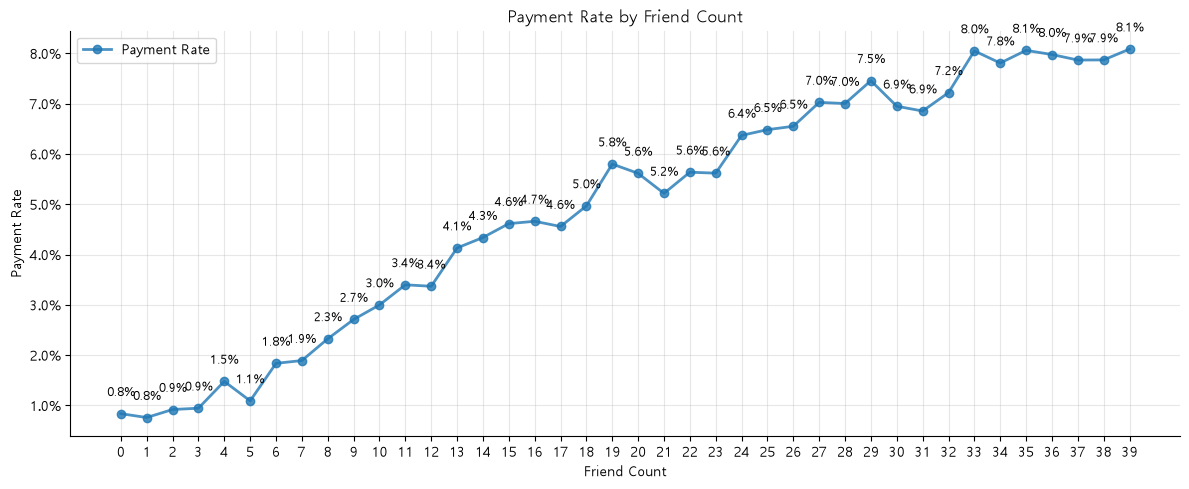

In [209]:
friend_rate = (
    master.groupby('friend_count')['is_paid_user']
      .agg(['mean', 'count'])
      .reset_index()
)

friend_rate = friend_rate.loc[
    (friend_rate['friend_count'] < 40)
]

friend_rate = friend_rate.sort_values('friend_count')

friend_rate['diff'] = friend_rate['mean'].diff()

plt.figure(figsize=(12, 5))

from matplotlib.ticker import PercentFormatter

ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

# Line + Marker
plt.plot(
    friend_rate['friend_count'],
    friend_rate['mean'],
    marker='o',          # 점 추가
    markersize=6,
    linewidth=2,
    alpha=0.8,
    label='Payment Rate'
)

# 각 점에 결제율(%) 표시
for x, y in zip(friend_rate['friend_count'], friend_rate['mean']):
    plt.text(
        x,
        y + 0.003,              # 점보다 약간 위
        f'{y:.1%}',             # % 표시 (예: 12.3%)
        ha='center',
        va='bottom',
        fontsize=9
    )

# x축을 1 단위로 표시
plt.xticks(range(
    int(friend_rate['friend_count'].min()),
    int(friend_rate['friend_count'].max()) + 1,
    1
))

plt.xlabel('Friend Count')
plt.ylabel('Payment Rate')
plt.title('Payment Rate by Friend Count')

plt.legend()
plt.grid(alpha=0.3)

# 위, 오른쪽 테두리 제거
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

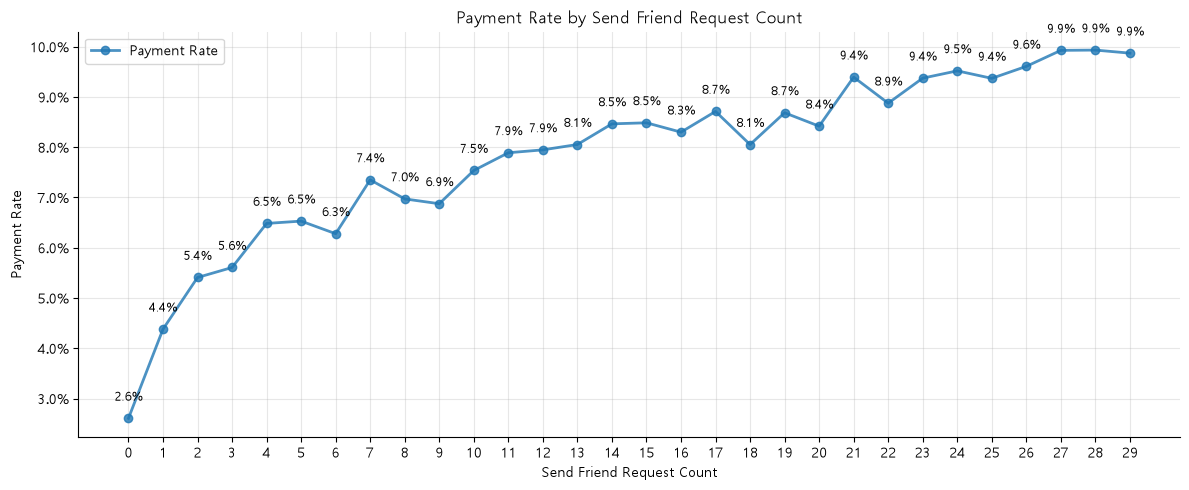

In [210]:
send_request_rate = (
    master.groupby('send_request_count')['is_paid_user']
      .agg(['mean', 'count'])
      .reset_index()
)

send_request_rate = send_request_rate.loc[
    (send_request_rate['send_request_count'] < 30)
]

send_request_rate = send_request_rate.sort_values('send_request_count')

send_request_rate['diff'] = send_request_rate['mean'].diff()

plt.figure(figsize=(12, 5))

from matplotlib.ticker import PercentFormatter

ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

# Line + Marker
plt.plot(
    send_request_rate['send_request_count'],
    send_request_rate['mean'],
    marker='o',          # 점 추가
    markersize=6,
    linewidth=2,
    alpha=0.8,
    label='Payment Rate'
)

# 각 점에 결제율(%) 표시
for x, y in zip(send_request_rate['send_request_count'], send_request_rate['mean']):
    plt.text(
        x,
        y + 0.003,              # 점보다 약간 위
        f'{y:.1%}',             # % 표시 (예: 12.3%)
        ha='center',
        va='bottom',
        fontsize=9
    )

# x축을 1 단위로 표시
plt.xticks(range(
    int(send_request_rate['send_request_count'].min()),
    int(send_request_rate['send_request_count'].max()) + 1,
    1
))

plt.xlabel('Send Friend Request Count')
plt.ylabel('Payment Rate')
plt.title('Payment Rate by Send Friend Request Count')

plt.legend()
plt.grid(alpha=0.3)

# 위, 오른쪽 테두리 제거
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

- 출석일 수 기준으로 결제율이 급격히 증가하기 시작하는 지점 : 4일 or 9일
- 친구 요청 받은 수 기준으로 결제율이 급격히 증가하기 시작하는 지점 : 7회 or 15회

**그래프 형태가 뚜렷한 임계점이 보이지 않는 형태라서 결정하기 어려움**

- 따라서 결제율 차이가 충분히 크고, P-value가 유의하며, 그룹 크기도 균형적인 임계점을 찾아야 한다

In [211]:
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest

def proportion_ztest_by_threshold(df, variable, thresholds, target='is_paid_user'):
    """
    여러 threshold에 대해 비율 Z-test 수행

    Parameters
    ----------
    df : DataFrame
    variable : str
    thresholds : iterable (list, range 등)
    target : str

    Returns
    -------
    DataFrame
    """

    results = []

    for threshold in thresholds:

        low = df[df[variable] < threshold]
        high = df[df[variable] >= threshold]

        # 한쪽 그룹이 비어있는 경우 제외
        if len(low) == 0 or len(high) == 0:
            continue

        success = [
            low[target].sum(),
            high[target].sum()
        ]

        nobs = [
            len(low),
            len(high)
        ]

        z_stat, p_value = proportions_ztest(success, nobs)

        low_rate = success[0] / nobs[0]
        high_rate = success[1] / nobs[1]

        results.append({
            'Threshold': threshold,
            'Low_Count': nobs[0],
            'High_Count': nobs[1],
            'Low_Paid_Rate': low_rate,
            'High_Paid_Rate': high_rate,
            'Difference': high_rate - low_rate,
            'Z_stat': z_stat,
            'P_value': p_value
        })

    return (
        pd.DataFrame(results)
        .sort_values('Difference', ascending=False)
        .reset_index(drop=True)
    )

In [212]:
attendance_result = proportion_ztest_by_threshold(
    master,
    variable='attendance_count',
    thresholds=range(1, 21)
)

attendance_result

,Threshold,Low_Count,High_Count,Low_Paid_Rate,High_Paid_Rate,Difference,Z_stat,P_value
0,9,593923,83157,0.077145,0.160828,0.083684,-80.018168,0.0
1,8,581168,95912,0.075667,0.158656,0.082989,-84.302961,0.0
2,11,614579,62501,0.079765,0.162717,0.082952,-69.951009,0.0
3,10,604997,72083,0.078592,0.161536,0.082944,-74.526547,0.0
4,7,566842,110238,0.073929,0.156806,0.082877,-89.138605,0.0
5,6,549921,127159,0.071896,0.154570,0.082674,-94.065157,0.0
6,12,622613,54467,0.080782,0.163328,0.082546,-65.404277,0.0
7,5,530023,147057,0.069506,0.151995,0.082489,-99.087805,0.0
8,4,505709,171371,0.066562,0.148981,0.082419,-104.394898,0.0
9,13,629390,47690,0.081631,0.163850,0.082218,-61.288139,0.0


- 출석일 수 임계점 후보 : 5일 or 7일

In [213]:
receive_result = proportion_ztest_by_threshold(
    master,
    variable='receive_request_count',
    thresholds=range(1, 21)
)

receive_result

,Threshold,Low_Count,High_Count,Low_Paid_Rate,High_Paid_Rate,Difference,Z_stat,P_value
0,1,16239,660841,0.022477,0.089018,0.066542,-29.658911,2.603212e-193
1,2,32543,644537,0.030575,0.090293,0.059718,-37.212603,4.268241e-303
2,3,49125,627955,0.036031,0.091443,0.055412,-41.875067,0.000000e+00
3,4,66253,610827,0.040587,0.092502,0.051916,-44.935908,0.000000e+00
4,5,83397,593683,0.044270,0.093484,0.049214,-47.116745,0.000000e+00
5,6,100366,576714,0.047267,0.094411,0.047144,-48.801283,0.000000e+00
6,7,117160,559920,0.049795,0.095296,0.045501,-50.142207,0.000000e+00
7,8,133765,543315,0.052293,0.096071,0.043778,-50.779450,0.000000e+00
8,9,150220,526860,0.054167,0.096904,0.042737,-51.730889,0.000000e+00
9,10,166159,510921,0.056067,0.097620,0.041553,-52.092464,0.000000e+00


- 친구 요청 보낸 수 임계점 후보 : 7회 or 10회(?)

In [214]:
# 출석일 수 3일, 친구 요청 보낸 수 7회를 기준으로 유저 그룹 나누기  

conditions = [
    (master['attendance_count'] >= 3) & (master['receive_request_count'] >= 18),
    (master['attendance_count'] >= 3) & (master['receive_request_count'] < 18),
    (master['attendance_count'] < 3) & (master['receive_request_count'] >= 18)
]

choices = ['HH', 'HL', 'LH']

master['user_group'] = np.select(
    conditions,
    choices,
    default='LL'
)

In [215]:
master = pd.merge(master, school_group, left_on='group_id', right_on='id', how='left', suffixes=('_x','_y'))

master = master.drop(columns=['id_y'])

master = master.rename(columns={'id_x':'id'})

In [216]:
paid_df = (
    master[master['is_paid_user'] == 1].copy()
)

non_paid_df = (
    master[master['is_paid_user'] == 0].copy()
)

In [217]:
summary = (
    master.groupby('user_group')
      .agg(
          User_Count=('id', 'count'),
          Paid_User=('is_paid_user', 'sum'),
          Paid_Rate=('is_paid_user', 'mean'),
          Avg_Attendance=('attendance_count', 'mean'),
          Avg_Receive=('receive_request_count', 'mean'),
          Avg_Friend_Count=('friend_count','mean'),
          Avg_Revenue=('revenue','mean')
      )
      .sort_index()
)

non_paid_summary = (
    non_paid_df.groupby('user_group')
      .agg(
          User_Count=('id', 'count'),
          Avg_Attendance=('attendance_count', 'mean'),
          Avg_Send=('send_request_count','mean'),
          Avg_Receive=('receive_request_count', 'mean'),
          Avg_Friend_Count=('friend_count','mean'),
          Avg_Total_Used_Point=('total_used_point','mean'),
          Avg_Total_Get_Point=('total_get_point','mean')
      )
      .sort_index()
)

paid_summary = (
    paid_df.groupby('user_group')
      .agg(
          User_Count=('id', 'count'),
          Avg_Attendance=('attendance_count', 'mean'),
          Avg_Send=('send_request_count','mean'),
          Avg_Receive=('receive_request_count', 'mean'),
          Avg_Friend_Count=('friend_count','mean'),
          Avg_Revenue=('revenue','mean'),
          Avg_Payment_Frequency=('payment_frequency', 'mean'),
          Avg_Payment_Value =('avg_payment_value','mean'),
          Avg_Total_Used_Point=('total_used_point','mean'),
          Avg_Total_Get_Point=('total_get_point','mean')
      )
      .sort_index()
)

In [218]:
summary

,User_Count,Paid_User,Paid_Rate,Avg_Attendance,Avg_Receive,Avg_Friend_Count,Avg_Revenue
user_group,,,,,,,
HH,124946,20122.0,0.161046,9.899757,37.254750,69.543931,603.367055
HL,78485,9286.0,0.118316,10.368058,8.997668,38.457922,398.324521
LH,264897,19957.0,0.075339,0.397037,37.796355,67.959584,242.004251
LL,208752,9827.0,0.047075,0.318469,7.976350,30.646336,141.350023


In [219]:
non_paid_summary

,User_Count,Avg_Attendance,Avg_Send,Avg_Receive,Avg_Friend_Count,Avg_Total_Used_Point,Avg_Total_Get_Point
user_group,,,,,,,
HH,104824,9.766666,29.964588,37.017038,69.110194,40.176963,43.281214
HL,69199,10.284831,27.578780,8.927138,38.146071,23.929248,25.886270
LH,244940,0.381730,26.258116,37.670474,67.579628,39.118886,45.873177
LL,198925,0.306658,19.060003,7.904316,30.202267,12.396280,14.653553


In [220]:
paid_summary

,User_Count,Avg_Attendance,Avg_Send,Avg_Receive,Avg_Friend_Count,Avg_Revenue,Avg_Payment_Frequency,Avg_Payment_Value,Avg_Total_Used_Point,Avg_Total_Get_Point
user_group,,,,,,,,,,
HH,20122,10.593082,31.334410,38.493092,71.803449,3746.560978,0.145144,2024.592287,66.983898,54.495925
HL,9286,10.988262,29.638811,9.523261,40.781822,3366.627181,0.132143,2012.101766,43.495585,39.304114
LH,19957,0.584908,29.711881,39.341334,72.622939,3212.216265,0.127975,2024.165756,60.727564,49.403317
LL,9827,0.557546,27.163020,9.434517,39.635494,3002.655948,0.120323,2017.995319,25.684339,20.024219


### 시각화

In [221]:
sns.set_style("whitegrid")

# Bar Plot 함수
def plot_bar(df, y, title, ylabel, fmt=".2f", color="steelblue"):
    plt.figure(figsize=(6,4))

    ax = sns.barplot(
        data=df,
        x=df.index,
        y=y,
        color=color
    )

    # Label
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            format(height, fmt),
            (p.get_x() + p.get_width()/2, height),
            ha='center',
            va='bottom',
            fontsize=11
        )

    plt.title(title, fontsize=15)
    plt.xlabel("User Group")
    plt.ylabel(ylabel)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

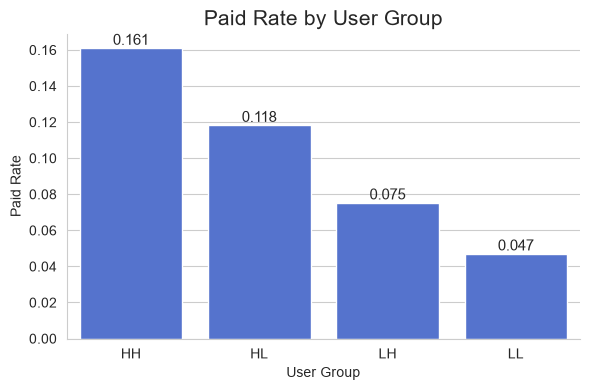

In [222]:
plot_bar(
    summary,
    "Paid_Rate",
    "Paid Rate by User Group",
    "Paid Rate",
    fmt=".3f",
    color="royalblue"
)

**이 그래프에서 전달할 수 있는 메시지**

- 출석 High인 그룹(HH, HL)이 친구 요청 High인 그룹(LH)보다 결제율이 훨씬 높다.

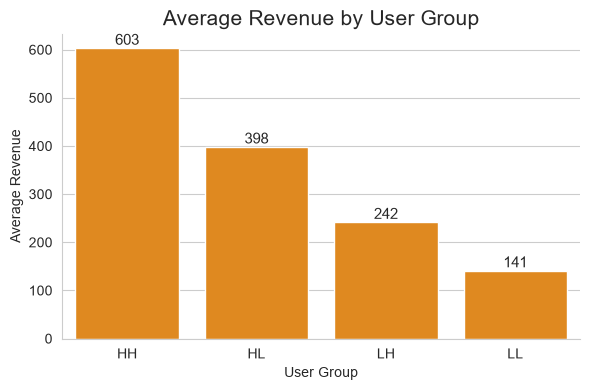

In [223]:
plot_bar(
    summary,
    "Avg_Revenue",
    "Average Revenue by User Group",
    "Average Revenue",
    fmt=".0f",
    color="darkorange"
)

**이 그래프에서 전달할 수 있는 메시지**

- 결제율뿐 아니라 실제 매출도 HH가 가장 높다.

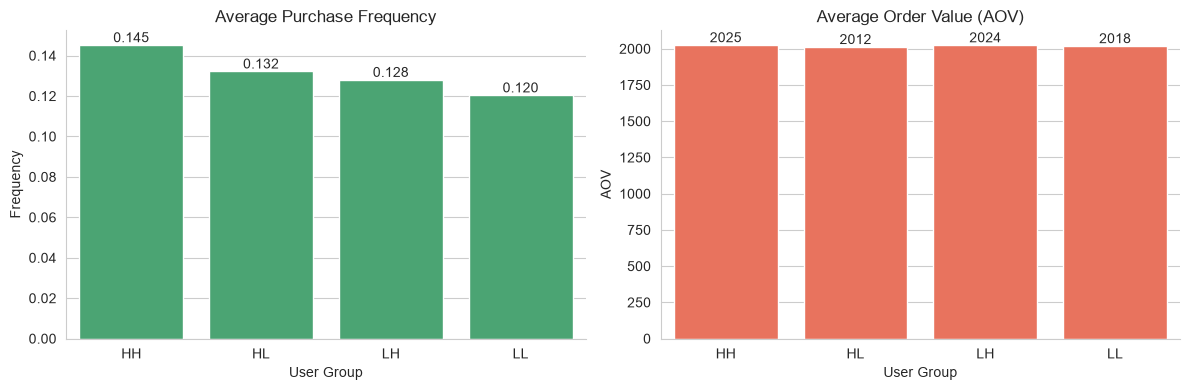

In [224]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

# Purchase Frequency
ax = sns.barplot(
    data=paid_summary,
    x=paid_summary.index,
    y="Avg_Payment_Frequency",
    ax=axes[0],
    color="mediumseagreen"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.3f}",
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

axes[0].set_title("Average Purchase Frequency")
axes[0].set_xlabel("User Group")
axes[0].set_ylabel("Frequency")
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)


# AOV
ax = sns.barplot(
    data=paid_summary,
    x=paid_summary.index,
    y="Avg_Payment_Value",
    ax=axes[1],
    color="tomato"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.0f}",
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

axes[1].set_title("Average Order Value (AOV)")
axes[1].set_xlabel("User Group")
axes[1].set_ylabel("AOV")
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**이 그래프에서 전달할 수 있는 메시지**

- 매출 차이는 건당 결제금액 때문이 아니라 구매 빈도 때문이다.

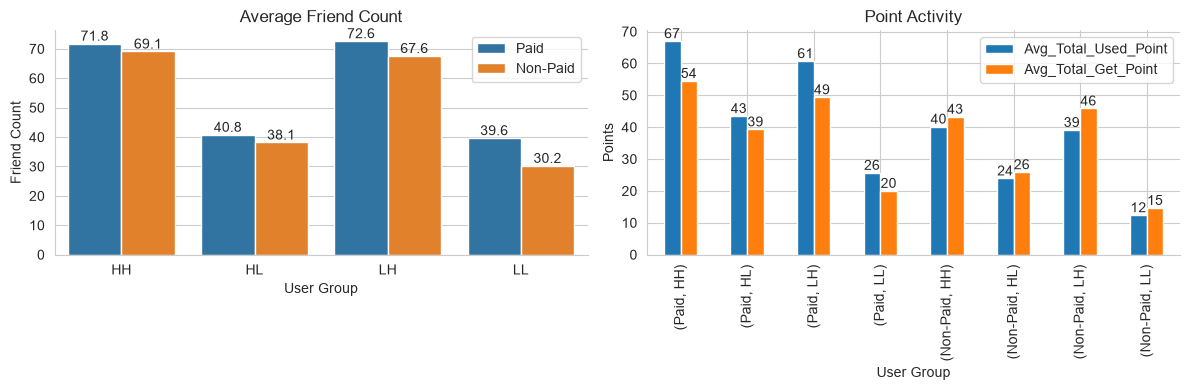

In [228]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

# Friend Count
paid_friend = paid_summary[['Avg_Friend_Count']].copy()
paid_friend['User_Group'] = paid_friend.index
paid_friend['Payment'] = 'Paid'

non_paid_friend = non_paid_summary[['Avg_Friend_Count']].copy()
non_paid_friend['User_Group'] = non_paid_friend.index
non_paid_friend['Payment'] = 'Non-Paid'

friend_df = pd.concat([paid_friend, non_paid_friend], ignore_index=True)

ax = sns.barplot(
    data=friend_df,
    x='User_Group',
    y='Avg_Friend_Count',
    hue='Payment',
    ax=axes[0]
)

# 막대 위 값 표시
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

axes[0].set_title("Average Friend Count")
axes[0].set_xlabel("User Group")
axes[0].set_ylabel("Friend Count")
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# 범례 제목 변경
ax.legend(title="")


# Point Activity

# Paid
paid_point = paid_summary[['Avg_Total_Used_Point',
                           'Avg_Total_Get_Point']].copy()
paid_point['Payment'] = 'Paid'

# Non Paid
non_paid_point = non_paid_summary[['Avg_Total_Used_Point',
                                   'Avg_Total_Get_Point']].copy()
non_paid_point['Payment'] = 'Non-Paid'

# 데이터 합치기
point_df = pd.concat([paid_point, non_paid_point])

# MultiIndex 생성 (결제 여부, 그룹)
point_df = point_df.set_index('Payment', append=True)
point_df = point_df.reorder_levels(['Payment', point_df.index.names[0]])

# 시각화
point_df.plot(
    kind='bar',
    ax=axes[1]
)

axes[1].set_title("Point Activity")
axes[1].set_xlabel("User Group")
axes[1].set_ylabel("Points")

for c in axes[1].containers:
    axes[1].bar_label(c, fmt="%.0f")

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**이 그래프에서 전달할 수 있는 메시지**

왼쪽 그래프
- HH와 LH는 친구 수가 매우 많다.
- 즉, 친구 요청이 많은 그룹은 실제 친구 관계도 많이 형성된다.

오른쪽 그래프
- 모든 그룹에서 결제 사용자가 미결제 사용자보다 포인트 사용량과 획득량이 높다.
- 특히 HH 그룹은 포인트 활동이 가장 활발하다.
- 따라서 친구 활동 → 포인트 활동 → 결제 및 높은 LTV라는 흐름을 시각적으로 뒷받침할 수 있다.
- 그 와중에 결제 사용자는 **사용량 > 획득량** 인 반면, 미결제 사용자는 **사용량 < 획득량** 인 것을 확인할 수 있다.

# 상우님 코드

In [ ]:
import pandas as pd
user = pd.read_csv("C:/gogeup/accounts_user_clean.csv")
friend = pd.read_csv("C:/gogeup/accounts_friendrequest_clean.csv")
payment = pd.read_csv("C:/gogeup/accounts_paymenthistory_clean.csv")
point = pd.read_csv("C:/gogeup/accounts_pointhistory_clean.csv")
group = pd.read_csv("C:/gogeup/accounts_group.csv")
contacts = pd.read_csv("C:/gogeup/accounts_user_contacts_clean.csv")
attendance = pd.read_csv("C:/gogeup/accounts_attendance_clean.csv")
question = pd.read_csv("C:/gogeup/accounts_userquestionrecord.csv")

In [ ]:
import numpy as np

In [ ]:
user = user.rename(columns={"id": "user_id"})

user = user.rename(columns={
    "ban_status": "user_status",
    "point": "current_point",
    "block_user_count": "block_count",
    "hide_user_count": "hide_count"
})

In [ ]:
user["created_at"] = pd.to_datetime(user["created_at"], errors="coerce")
friend["created_at"] = pd.to_datetime(friend["created_at"], errors="coerce")
payment["created_at"] = pd.to_datetime(payment["created_at"], errors="coerce")
point["created_at"] = pd.to_datetime(point["created_at"], errors="coerce")
question["created_at"] = pd.to_datetime(question["created_at"], errors="coerce")

In [ ]:
reference_date = max(
    user["created_at"].max(),
    friend["created_at"].max(),
    payment["created_at"].max(),
    point["created_at"].max(),
    question["created_at"].max()
)

print("reference_date:", reference_date)

reference_date: 2024-05-09 09:21:47


In [ ]:
base = user[[
    "user_id",
    "gender",
    "group_id",
    "user_status",
    "is_superuser",
    "is_staff",
    "current_point",
    "created_at",
    "friend_count",
    "block_count",
    "hide_count"
]].copy()

base["is_normal_user"] = (
    (base["is_superuser"] == 0) 
    & (base["is_staff"] == 0)
).astype(int)

base["user_age_days"] = (reference_date - base["created_at"]).dt.days

print(base.shape)
base.head()

(677080, 13)


,user_id,gender,group_id,user_status,is_superuser,is_staff,current_point,created_at,friend_count,block_count,hide_count,is_normal_user,user_age_days
0,831962,F,12,N,0,0,2248,2023-03-29 05:18:56.162368,43,0,0,1,407
1,832151,M,1,N,0,0,1519,2023-03-29 12:56:34.989468,51,0,0,1,406
2,832340,F,1,N,0,0,57,2023-03-29 12:56:35.020790,57,0,0,1,406
3,832520,M,12,N,0,0,1039,2023-03-29 12:56:35.049311,18,0,0,1,406
4,832614,M,12,N,0,0,1048,2023-03-29 12:56:35.064406,21,0,0,1,406


In [ ]:
payment_label = payment.groupby("user_id").agg(
    payment_count=("user_id", "count"),
    first_payment_at=("created_at", "min"),
    last_payment_at=("created_at", "max")
).reset_index()

payment_label["is_paid"] = 1

print(payment_label.shape)
payment_label.head()

(59192, 5)


,user_id,payment_count,first_payment_at,last_payment_at,is_paid
0,833041,2,2023-05-14 07:59:46,2023-05-15 01:50:06,1
1,834112,1,2023-05-21 23:55:46,2023-05-21 23:55:46,1
2,835815,3,2023-06-10 14:17:45,2023-06-10 14:19:17,1
3,835839,1,2023-05-15 16:37:30,2023-05-15 16:37:30,1
4,835888,2,2023-06-06 04:58:49,2023-06-06 04:59:22,1


In [ ]:
friend_sent = friend.groupby("send_user_id").agg(
    sent_request_count=("send_user_id", "count"),
    accepted_sent_count=("status", lambda x: (x == "A").sum())
).reset_index().rename(columns={"send_user_id": "user_id"})

friend_received = friend.groupby("receive_user_id").agg(
    received_request_count=("receive_user_id", "count"),
    accepted_received_count=("status", lambda x: (x == "A").sum())
).reset_index().rename(columns={"receive_user_id": "user_id"})

friend_feature = friend_sent.merge(
    friend_received,
    on="user_id",
    how="outer"
).fillna(0)

friend_feature["accepted_request_count"] = (
    friend_feature["accepted_sent_count"] 
    + friend_feature["accepted_received_count"]
)

friend_feature["total_request_count"] = (
    friend_feature["sent_request_count"] 
    + friend_feature["received_request_count"]
)

friend_feature["friend_accept_rate"] = (
    friend_feature["accepted_request_count"] 
    / friend_feature["total_request_count"]
).replace([np.inf, -np.inf], 0).fillna(0)

print(friend_feature.shape)
friend_feature.head()

(673705, 8)


,user_id,sent_request_count,accepted_sent_count,received_request_count,accepted_received_count,accepted_request_count,total_request_count,friend_accept_rate
0,831962,1.0,1.0,26.0,0.0,1.0,27.0,0.037037
1,832151,10.0,2.0,35.0,6.0,8.0,45.0,0.177778
2,832340,26.0,7.0,25.0,4.0,11.0,51.0,0.215686
3,832520,0.0,0.0,14.0,0.0,0.0,14.0,0.000000
4,832614,0.0,0.0,12.0,0.0,0.0,12.0,0.000000


In [ ]:
question_feature_given = question.groupby("user_id").agg(
    vote_given_count=("user_id", "count"),
    question_participation_count=("question_id", "nunique"),
    question_open_count=("opened_times", "sum")
).reset_index()

question_feature_received = question.groupby("chosen_user_id").agg(
    vote_received_count=("chosen_user_id", "count")
).reset_index().rename(columns={"chosen_user_id": "user_id"})

question_feature = question_feature_given.merge(
    question_feature_received,
    on="user_id",
    how="outer"
).fillna(0)

print(question_feature.shape)
question_feature.head()

(15452, 5)


,user_id,vote_given_count,question_participation_count,question_open_count,vote_received_count
0,833112,0.0,0.0,0.0,2.0
1,833113,0.0,0.0,0.0,20.0
2,833203,0.0,0.0,0.0,116.0
3,833294,0.0,0.0,0.0,29.0
4,833424,0.0,0.0,0.0,4.0


In [ ]:
point_feature = point.groupby("user_id").agg(
    point_earn_count=("delta_point", lambda x: (x > 0).sum()),
    point_use_count=("delta_point", lambda x: (x < 0).sum()),
    total_earned_point=("delta_point", lambda x: x[x > 0].sum()),
    total_used_point=("delta_point", lambda x: abs(x[x < 0].sum()))
).reset_index()

print(point_feature.shape)
point_feature.head()

(5037, 5)


,user_id,point_earn_count,point_use_count,total_earned_point,total_used_point
0,838023,173,2,1665,600
1,838466,474,13,4748,3800
2,838642,37,1,344,300
3,839357,302,6,3048,1700
4,839670,14,0,139,0


In [ ]:
attendance_feature = attendance.groupby("user_id").agg(
    attendance_count=("attendance_count", "max")
).reset_index()

def get_attendance_period_days(x):
    try:
        dates = ast.literal_eval(x)
        if not dates:
            return 0

        dates = pd.to_datetime(dates, errors="coerce")
        dates = dates.dropna()

        if len(dates) == 0:
            return 0

        return (dates.max() - dates.min()).days
    except:
        return 0

attendance["attendance_period_days"] = attendance["attendance_date_list"].apply(
    get_attendance_period_days
)

attendance_period = attendance.groupby("user_id").agg(
    attendance_period_days=("attendance_period_days", "max")
).reset_index()

attendance_feature = attendance_feature.merge(
    attendance_period,
    on="user_id",
    how="left"
)

print(attendance_feature.shape)
attendance_feature.head()

(349637, 3)


,user_id,attendance_count,attendance_period_days
0,832151,1,0
1,832340,2,0
2,832986,1,0
3,833041,53,0
4,833112,3,0


In [ ]:
master_df_no_hackle = base.copy()

feature_tables = [
    payment_label,
    friend_feature,
    question_feature,
    point_feature,
    attendance_feature
]

for feature in feature_tables:
    master_df_no_hackle = master_df_no_hackle.merge(
        feature,
        on="user_id",
        how="left"
    )

master_df_no_hackle["is_paid"] = (
    master_df_no_hackle["is_paid"]
    .fillna(0)
    .astype(int)
)

master_df_no_hackle["payment_count"] = (
    master_df_no_hackle["payment_count"]
    .fillna(0)
    .astype(int)
)

In [ ]:
fill_zero_cols = [
    "sent_request_count",
    "received_request_count",
    "accepted_sent_count",
    "accepted_received_count",
    "accepted_request_count",
    "total_request_count",
    "friend_accept_rate",
    "vote_given_count",
    "vote_received_count",
    "question_participation_count",
    "question_open_count",
    "point_earn_count",
    "point_use_count",
    "total_earned_point",
    "total_used_point",
    "attendance_count",
    "attendance_period_days"
]

for col in fill_zero_cols:
    if col in master_df_no_hackle.columns:
        master_df_no_hackle[col] = master_df_no_hackle[col].fillna(0)

print(master_df_no_hackle.shape)
master_df_no_hackle.head()

(677080, 34)


,user_id,gender,group_id,user_status,is_superuser,is_staff,current_point,created_at,friend_count,block_count,...,vote_given_count,question_participation_count,question_open_count,vote_received_count,point_earn_count,point_use_count,total_earned_point,total_used_point,attendance_count,attendance_period_days
0,831962,F,12,N,0,0,2248,2023-03-29 05:18:56.162368,43,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,832151,M,1,N,0,0,1519,2023-03-29 12:56:34.989468,51,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,832340,F,1,N,0,0,57,2023-03-29 12:56:35.020790,57,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
3,832520,M,12,N,0,0,1039,2023-03-29 12:56:35.049311,18,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,832614,M,12,N,0,0,1048,2023-03-29 12:56:35.064406,21,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
print("master_df_no_hackle shape:", master_df_no_hackle.shape)
print("user 수:", master_df_no_hackle["user_id"].nunique())
print(master_df_no_hackle["is_paid"].value_counts())
print("결제율:", master_df_no_hackle["is_paid"].mean())

print(master_df_no_hackle.isnull().sum().sort_values(ascending=False).head(30))

master_df_no_hackle shape: (677080, 34)
user 수: 677080
is_paid
0    617888
1     59192
Name: count, dtype: int64
결제율: 0.08742246115673184
last_payment_at                 617888
first_payment_at                617888
user_id                              0
accepted_sent_count                  0
accepted_received_count              0
accepted_request_count               0
total_request_count                  0
friend_accept_rate                   0
vote_given_count                     0
question_participation_count         0
question_open_count                  0
vote_received_count                  0
point_earn_count                     0
point_use_count                      0
total_earned_point                   0
total_used_point                     0
attendance_count                     0
received_request_count               0
sent_request_count                   0
gender                               0
is_paid                              0
payment_count                        0
user

In [ ]:
master_df_no_hackle.to_csv(
    "C:/gogeup/master_payment_prediction_no_hackle.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료:", master_df_no_hackle.shape)

저장 완료: (677080, 34)


In [ ]:
print("user row 수:", len(user))
print("user 고유 user_id 수:", user["user_id"].nunique())
print("user_id 중복 여부:", len(user) != user["user_id"].nunique())

user row 수: 677080
user 고유 user_id 수: 677080
user_id 중복 여부: False


In [ ]:
feature_tables = {
    "payment_label": payment_label,
    "friend_feature": friend_feature,
    "question_feature": question_feature,
    "point_feature": point_feature,
    "attendance_feature": attendance_feature
}

for name, df in feature_tables.items():
    print(name)
    print("row 수:", len(df))
    print("고유 user_id 수:", df["user_id"].nunique())
    print("user_id 중복 여부:", len(df) != df["user_id"].nunique())
    print("-" * 30)

payment_label
row 수: 59192
고유 user_id 수: 59192
user_id 중복 여부: False
------------------------------
friend_feature
row 수: 673705
고유 user_id 수: 673705
user_id 중복 여부: False
------------------------------
question_feature
row 수: 15452
고유 user_id 수: 15452
user_id 중복 여부: False
------------------------------
point_feature
row 수: 5037
고유 user_id 수: 5037
user_id 중복 여부: False
------------------------------
attendance_feature
row 수: 349637
고유 user_id 수: 349637
user_id 중복 여부: False
------------------------------


In [ ]:
print(master_df_no_hackle.shape)
print(master_df_no_hackle["is_paid"].value_counts())
print("결제율:", master_df_no_hackle["is_paid"].mean())

print("유저별 1행 여부:",
      len(master_df_no_hackle) == master_df_no_hackle["user_id"].nunique())

(677080, 34)
is_paid
0    617888
1     59192
Name: count, dtype: int64
결제율: 0.08742246115673184
유저별 1행 여부: True


In [ ]:
exclude_cols = [
    "user_id",
    "created_at",
    "first_payment_at",
    "last_payment_at",
    "payment_count",
    "is_paid",
    "is_superuser",
    "is_staff"
]

# 포인트 관련 변수 자동 탐색
point_cols = [
    col for col in master_df_no_hackle.columns
    if "point" in col.lower()
    or "current_point" in col.lower()
]

print("제외할 포인트 변수:")
print(point_cols)

# 제외 컬럼 합치기
exclude_cols = exclude_cols + point_cols

# 실제 존재하는 컬럼만 제외
exclude_cols = [col for col in exclude_cols if col in master_df_no_hackle.columns]

y = master_df_no_hackle["is_paid"].copy()

X_base = master_df_no_hackle.drop(columns=exclude_cols).copy()

print("X_base shape:", X_base.shape)
print("y 결제율:", y.mean())
print("남은 포인트 관련 컬럼:", [
    col for col in X_base.columns
    if "point" in col.lower()
    or "current_point" in col.lower()
])

제외할 포인트 변수:
['current_point', 'point_earn_count', 'point_use_count', 'total_earned_point', 'total_used_point']
X_base shape: (677080, 21)
y 결제율: 0.08742246115673184
남은 포인트 관련 컬럼: []


In [ ]:
log_target_cols = [
    # 친구
    "friend_count",
    "sent_request_count",
    "received_request_count",
    "accepted_sent_count",
    "accepted_received_count",
    "accepted_request_count",
    "total_request_count",

    # 질문/투표
    "vote_given_count",
    "vote_received_count",
    "question_participation_count",
    "question_open_count",

    # 출석
    "attendance_count",
    "attendance_period_days",

    # 차단/숨김
    "block_count",
    "hide_count"
]

log_target_cols = [col for col in log_target_cols if col in X_base.columns]

X_model = X_base.copy()

for col in log_target_cols:
    X_model[f"log_{col}"] = np.log1p(X_model[col].clip(lower=0))

# 원본 count 변수 제거
X_model = X_model.drop(columns=log_target_cols)

print("X_model shape:", X_model.shape)
print("남은 포인트 관련 컬럼:", [
    col for col in X_model.columns
    if "point" in col.lower()
    or "current_point" in col.lower()
])

X_model shape: (677080, 21)
남은 포인트 관련 컬럼: []


_____ sent receiced attendance___ 변수만 수행

In [ ]:
import numpy as np
import pandas as pd

# 기본 변수 3개
base_small_cols = [
    "sent_request_count",
    "received_request_count",
    "attendance_count"
]

# 존재 여부 확인
missing_base_cols = [col for col in base_small_cols if col not in X_base.columns]

print("없는 변수:", missing_base_cols)

if len(missing_base_cols) > 0:
    raise ValueError(f"없는 변수가 있습니다: {missing_base_cols}")

# 원본 3개 변수만 가져오기
X_small_raw = X_base[base_small_cols].copy()

# 결측 0 처리
X_small_raw = X_small_raw.fillna(0)

# 교호작용 변수 생성
X_small_raw["sent_x_attendance"] = (
    X_small_raw["sent_request_count"] 
    * X_small_raw["attendance_count"]
)

X_small_raw["sent_x_received"] = (
    X_small_raw["sent_request_count"] 
    * X_small_raw["received_request_count"]
)

X_small_raw["received_x_attendance"] = (
    X_small_raw["received_request_count"] 
    * X_small_raw["attendance_count"]
)

print(X_small_raw.shape)
X_small_raw.head()

없는 변수: []
(677080, 6)


,sent_request_count,received_request_count,attendance_count,sent_x_attendance,sent_x_received,received_x_attendance
0,1.0,26.0,0.0,0.0,26.0,0.0
1,10.0,35.0,1.0,10.0,350.0,35.0
2,26.0,25.0,2.0,52.0,650.0,50.0
3,0.0,14.0,0.0,0.0,0.0,0.0
4,0.0,12.0,0.0,0.0,0.0,0.0


In [ ]:
X_small = pd.DataFrame(index=X_small_raw.index)

for col in X_small_raw.columns:
    X_small[f"log_{col}"] = np.log1p(X_small_raw[col].clip(lower=0))

print("최종 사용 변수:")
print(X_small.columns.tolist())

print("X_small shape:", X_small.shape)
print("y 결제율:", y.mean())

X_small.head()

최종 사용 변수:
['log_sent_request_count', 'log_received_request_count', 'log_attendance_count', 'log_sent_x_attendance', 'log_sent_x_received', 'log_received_x_attendance']
X_small shape: (677080, 6)
y 결제율: 0.08742246115673184


,log_sent_request_count,log_received_request_count,log_attendance_count,log_sent_x_attendance,log_sent_x_received,log_received_x_attendance
0,0.693147,3.295837,0.000000,0.000000,3.295837,0.000000
1,2.397895,3.583519,0.693147,2.397895,5.860786,3.583519
2,3.295837,3.258097,1.098612,3.970292,6.478510,3.931826
3,0.000000,2.708050,0.000000,0.000000,0.000000,0.000000
4,0.000000,2.564949,0.000000,0.000000,0.000000,0.000000


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
    classification_report
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

def find_best_threshold(
    y_true,
    proba,
    metric="f1",
    beta=2,
    thresholds=np.arange(0.01, 0.99, 0.01)
):
    results = []

    for th in thresholds:
        pred = (proba >= th).astype(int)

        precision = precision_score(y_true, pred, zero_division=0)
        recall = recall_score(y_true, pred, zero_division=0)
        f1 = f1_score(y_true, pred, zero_division=0)
        fbeta = fbeta_score(y_true, pred, beta=beta, zero_division=0)

        results.append({
            "threshold": th,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            f"f{beta}_score": fbeta
        })

    threshold_df = pd.DataFrame(results)

    if metric == "f1":
        best_idx = threshold_df["f1"].idxmax()
    elif metric == "fbeta":
        best_idx = threshold_df[f"f{beta}_score"].idxmax()
    elif metric == "precision":
        best_idx = threshold_df["precision"].idxmax()
    elif metric == "recall":
        best_idx = threshold_df["recall"].idxmax()
    else:
        raise ValueError("metric은 'f1', 'fbeta', 'precision', 'recall' 중 하나여야 합니다.")

    best_row = threshold_df.loc[best_idx]

    return best_row, threshold_df


def top_percent_summary(y_true, proba, top_pct=0.1):
    temp = pd.DataFrame({
        "y_true": y_true.values if hasattr(y_true, "values") else y_true,
        "proba": proba
    })

    temp = temp.sort_values("proba", ascending=False).reset_index(drop=True)

    top_n = int(len(temp) * top_pct)
    top_df = temp.iloc[:top_n]

    overall_paid_rate = temp["y_true"].mean()
    top_paid_rate = top_df["y_true"].mean()

    return {
        "top_percent": int(top_pct * 100),
        "top_user_count": len(top_df),
        "top_paid_count": int(top_df["y_true"].sum()),
        "top_paid_rate": top_paid_rate,
        "overall_paid_rate": overall_paid_rate,
        "top_lift": top_paid_rate / overall_paid_rate if overall_paid_rate > 0 else np.nan
    }


def evaluate_model(model_name, model, X_train, X_test, y_train, y_test, threshold_metric="f1", beta=2):
    model.fit(X_train, y_train)

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    else:
        proba = model.decision_function(X_test)
        proba = (proba - proba.min()) / (proba.max() - proba.min())

    best_threshold_row, threshold_df = find_best_threshold(
        y_true=y_test,
        proba=proba,
        metric=threshold_metric,
        beta=beta
    )

    best_threshold = best_threshold_row["threshold"]
    pred = (proba >= best_threshold).astype(int)

    top10 = top_percent_summary(y_test, proba, top_pct=0.1)

    result = {
        "model_name": model_name,
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
        "best_threshold": best_threshold,
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        f"f{beta}_score": fbeta_score(y_test, pred, beta=beta, zero_division=0),
        "top10_paid_rate": top10["top_paid_rate"],
        "top10_lift": top10["top_lift"],
        "top10_paid_count": top10["top_paid_count"],
        "top10_user_count": top10["top_user_count"],
        "confusion_matrix": confusion_matrix(y_test, pred),
        "model": model,
        "proba": proba,
        "pred": pred,
        "threshold_df": threshold_df
    }

    return result

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_small,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train 결제율:", y_train.mean())
print("Test 결제율:", y_test.mean())

Train shape: (541664, 6)
Test shape: (135416, 6)
Train 결제율: 0.08742319962190583
Test 결제율: 0.08741950729603593


In [ ]:
models = {}

# 1. 로지스틱 회귀
models["LogisticRegression"] = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

# 2. Decision Tree
models["DecisionTree"] = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

# 3. RandomForest
models["RandomForest"] = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# 4. ExtraTrees
models["ExtraTrees"] = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# 5. GradientBoosting
models["GradientBoosting"] = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# 6. LightGBM 있으면 추가
try:
    from lightgbm import LGBMClassifier

    models["LightGBM"] = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
except Exception as e:
    print("LightGBM 사용 불가:", e)

# 7. CatBoost 있으면 추가
try:
    from catboost import CatBoostClassifier

    models["CatBoost"] = CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=5,
        loss_function="Logloss",
        eval_metric="AUC",
        auto_class_weights="Balanced",
        random_seed=42,
        verbose=0,
        allow_writing_files=False,
        thread_count=-1
    )
except Exception as e:
    print("CatBoost 사용 불가:", e)

In [ ]:
model_results = []

for model_name, model in models.items():
    print("=" * 80)
    print(model_name)

    result = evaluate_model(
        model_name=model_name,
        model=model,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        threshold_metric="f1",
        beta=2
    )

    model_results.append(result)

    print("ROC-AUC:", result["roc_auc"])
    print("PR-AUC:", result["pr_auc"])
    print("Best threshold:", result["best_threshold"])
    print("Precision:", result["precision"])
    print("Recall:", result["recall"])
    print("F1:", result["f1"])
    print("F2:", result["f2_score"])
    print("Top 10% paid_rate:", result["top10_paid_rate"])
    print("Top 10% lift:", result["top10_lift"])
    print("Confusion Matrix:")
    print(result["confusion_matrix"])

LogisticRegression
ROC-AUC: 0.6651468812197934
PR-AUC: 0.14569739622293643
Best threshold: 0.56
Precision: 0.14898431607147503
Recall: 0.48386551782395676
F1: 0.22782141791786814
F2: 0.3338034242823343
Top 10% paid_rate: 0.17554094970829334
Top 10% lift: 2.0080295020863534
Confusion Matrix:
[[90859 32719]
 [ 6110  5728]]
DecisionTree
ROC-AUC: 0.6663095403039733
PR-AUC: 0.14399970541587276
Best threshold: 0.56
Precision: 0.14528127005252275
Recall: 0.5163879033620544
F1: 0.22676435129370306
F2: 0.34177951223875924
Top 10% paid_rate: 0.17554094970829334
Top 10% lift: 2.0080295020863534
Confusion Matrix:
[[87614 35964]
 [ 5725  6113]]
RandomForest
ROC-AUC: 0.6676319774901363
PR-AUC: 0.148146575165625
Best threshold: 0.56
Precision: 0.14726603447014944
Recall: 0.5103057948977868
F1: 0.22857034752833008
F2: 0.3417899132087855
Top 10% paid_rate: 0.17694409570932723
Top 10% lift: 2.0240802217075733
Confusion Matrix:
[[88598 34980]
 [ 5797  6041]]
ExtraTrees
ROC-AUC: 0.6677277146788414
PR-AUC:

In [ ]:
model_selection_df = pd.DataFrame([
    {
        "model_name": r["model_name"],
        "roc_auc": r["roc_auc"],
        "pr_auc": r["pr_auc"],
        "best_threshold": r["best_threshold"],
        "precision": r["precision"],
        "recall": r["recall"],
        "f1": r["f1"],
        "f2_score": r["f2_score"],
        "top10_paid_rate": r["top10_paid_rate"],
        "top10_lift": r["top10_lift"],
        "top10_paid_count": r["top10_paid_count"],
        "top10_user_count": r["top10_user_count"]
    }
    for r in model_results
])

model_selection_df = model_selection_df.sort_values(
    ["pr_auc", "roc_auc", "top10_lift"],
    ascending=False
).reset_index(drop=True)

model_selection_df

,model_name,roc_auc,pr_auc,best_threshold,precision,recall,f1,f2_score,top10_paid_rate,top10_lift,top10_paid_count,top10_user_count
0,CatBoost,0.668009,0.148342,0.55,0.144329,0.546714,0.228370,0.350999,0.176944,2.024080,2396,13541
1,ExtraTrees,0.667728,0.148153,0.58,0.149778,0.475841,0.227840,0.331505,0.177683,2.032528,2406,13541
2,RandomForest,0.667632,0.148147,0.56,0.147266,0.510306,0.228570,0.341790,0.176944,2.024080,2396,13541
3,GradientBoosting,0.667741,0.147839,0.11,0.146821,0.509123,0.227916,0.340886,0.177978,2.035907,2410,13541
4,LightGBM,0.665063,0.146171,0.55,0.144045,0.525511,0.226111,0.343550,0.174802,1.999582,2367,13541
5,LogisticRegression,0.665147,0.145697,0.56,0.148984,0.483866,0.227821,0.333803,0.175541,2.008030,2377,13541
6,DecisionTree,0.666310,0.144000,0.56,0.145281,0.516388,0.226764,0.341780,0.175541,2.008030,2377,13541


In [ ]:
model_selection_df = pd.DataFrame([
    {
        "model_name": r["model_name"],
        "roc_auc": r["roc_auc"],
        "pr_auc": r["pr_auc"],
        "best_threshold": r["best_threshold"],
        "precision": r["precision"],
        "recall": r["recall"],
        "f1": r["f1"],
        "f2_score": r["f2_score"],
        "top10_paid_rate": r["top10_paid_rate"],
        "top10_lift": r["top10_lift"],
        "top10_paid_count": r["top10_paid_count"],
        "top10_user_count": r["top10_user_count"]
    }
    for r in model_results
])

model_selection_df = model_selection_df.sort_values(
    ["pr_auc", "roc_auc", "top10_lift"],
    ascending=False
).reset_index(drop=True)

model_selection_df

,model_name,roc_auc,pr_auc,best_threshold,precision,recall,f1,f2_score,top10_paid_rate,top10_lift,top10_paid_count,top10_user_count
0,CatBoost,0.668009,0.148342,0.55,0.144329,0.546714,0.228370,0.350999,0.176944,2.024080,2396,13541
1,ExtraTrees,0.667728,0.148153,0.58,0.149778,0.475841,0.227840,0.331505,0.177683,2.032528,2406,13541
2,RandomForest,0.667632,0.148147,0.56,0.147266,0.510306,0.228570,0.341790,0.176944,2.024080,2396,13541
3,GradientBoosting,0.667741,0.147839,0.11,0.146821,0.509123,0.227916,0.340886,0.177978,2.035907,2410,13541
4,LightGBM,0.665063,0.146171,0.55,0.144045,0.525511,0.226111,0.343550,0.174802,1.999582,2367,13541
5,LogisticRegression,0.665147,0.145697,0.56,0.148984,0.483866,0.227821,0.333803,0.175541,2.008030,2377,13541
6,DecisionTree,0.666310,0.144000,0.56,0.145281,0.516388,0.226764,0.341780,0.175541,2.008030,2377,13541


In [ ]:
model_selection_display = model_selection_df.copy()

percent_cols = [
    "roc_auc",
    "pr_auc",
    "precision",
    "recall",
    "f1",
    "f2_score",
    "top10_paid_rate"
]

for col in percent_cols:
    model_selection_display[col] = (model_selection_display[col] * 100).round(2)

model_selection_display["top10_lift"] = model_selection_display["top10_lift"].round(2)
model_selection_display["best_threshold"] = model_selection_display["best_threshold"].round(2)

model_selection_display

,model_name,roc_auc,pr_auc,best_threshold,precision,recall,f1,f2_score,top10_paid_rate,top10_lift,top10_paid_count,top10_user_count
0,CatBoost,66.80,14.83,0.55,14.43,54.67,22.84,35.10,17.69,2.02,2396,13541
1,ExtraTrees,66.77,14.82,0.58,14.98,47.58,22.78,33.15,17.77,2.03,2406,13541
2,RandomForest,66.76,14.81,0.56,14.73,51.03,22.86,34.18,17.69,2.02,2396,13541
3,GradientBoosting,66.77,14.78,0.11,14.68,50.91,22.79,34.09,17.80,2.04,2410,13541
4,LightGBM,66.51,14.62,0.55,14.40,52.55,22.61,34.35,17.48,2.00,2367,13541
5,LogisticRegression,66.51,14.57,0.56,14.90,48.39,22.78,33.38,17.55,2.01,2377,13541
6,DecisionTree,66.63,14.40,0.56,14.53,51.64,22.68,34.18,17.55,2.01,2377,13541


In [ ]:
best_model_name = model_selection_df.iloc[0]["model_name"]

best_result = [r for r in model_results if r["model_name"] == best_model_name][0]

print("선정 모델:", best_model_name)
print("ROC-AUC:", best_result["roc_auc"])
print("PR-AUC:", best_result["pr_auc"])
print("Top 10% paid_rate:", best_result["top10_paid_rate"])
print("Top 10% lift:", best_result["top10_lift"])

선정 모델: CatBoost
ROC-AUC: 0.6680090520198734
PR-AUC: 0.1483422358027432
Top 10% paid_rate: 0.17694409570932723
Top 10% lift: 2.0240802217075733


In [ ]:
print("선정 모델:", best_model_name)
print("Best Threshold:", best_result["best_threshold"])
print()
print("Confusion Matrix")
print(best_result["confusion_matrix"])
print()
print(classification_report(
    y_test,
    best_result["pred"],
    zero_division=0
))

선정 모델: CatBoost
Best Threshold: 0.55

Confusion Matrix
[[85208 38370]
 [ 5366  6472]]

              precision    recall  f1-score   support

           0       0.94      0.69      0.80    123578
           1       0.14      0.55      0.23     11838

    accuracy                           0.68    135416
   macro avg       0.54      0.62      0.51    135416
weighted avg       0.87      0.68      0.75    135416



______catboost______

In [ ]:
X_small.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99, 0.999]).T

,count,mean,std,min,50%,75%,90%,95%,99%,99.9%,max
log_sent_request_count,677080.0,2.873560,1.016230,0.0,3.044522,3.555348,3.970292,4.219508,4.682131,5.278115,7.504942
log_received_request_count,677080.0,2.908362,0.978753,0.0,3.091042,3.637586,3.970292,4.158883,4.442651,4.744932,5.389072
log_attendance_count,677080.0,0.808690,1.010168,0.0,0.000000,1.609438,2.397895,2.772589,3.465736,4.369448,5.739793
log_sent_x_attendance,677080.0,2.131264,2.407269,0.0,0.000000,4.343805,5.587249,6.167516,7.125283,8.178720,12.215726
log_sent_x_received,677080.0,5.502689,1.952231,0.0,5.926926,6.803505,7.462215,7.824446,8.476580,9.238150,11.591931
log_received_x_attendance,677080.0,2.086465,2.367520,0.0,0.000000,4.290459,5.509388,6.070738,6.928538,7.809819,9.517163


카운트형 변수와 교호작용 변수는 일부 극단값이 존재하였다. 특히 교호작용 변수는 두 카운트 변수의 곱으로 생성되기 때문에 극단값의 영향이 크게 나타날 수 있다. 

In [ ]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

# Logistic Regression용 데이터
X_logit = X_small.copy()
y_logit = y.copy()

# 상수항 추가
X_logit_const = sm.add_constant(X_logit)

# 로지스틱 회귀 적합
logit_model = sm.Logit(y_logit, X_logit_const)
logit_result = logit_model.fit(maxiter=100)

print(logit_result.summary())

Optimization terminated successfully.
         Current function value: 0.282726
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                is_paid   No. Observations:               677080
Model:                          Logit   Df Residuals:                   677073
Method:                           MLE   Df Model:                            6
Date:                Wed, 08 Jul 2026   Pseudo R-squ.:                 0.04656
Time:                        11:31:16   Log-Likelihood:            -1.9143e+05
converged:                       True   LL-Null:                   -2.0078e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -3.9723      0.027   -145.515      0.000      

In [ ]:
logit_summary = pd.DataFrame({
    "feature": logit_result.params.index,
    "coef": logit_result.params.values,
    "p_value": logit_result.pvalues.values,
    "std_err": logit_result.bse.values
})

# Odds Ratio
logit_summary["odds_ratio"] = np.exp(logit_summary["coef"])

# 95% 신뢰구간
conf = logit_result.conf_int()
logit_summary["or_ci_lower"] = np.exp(conf[0].values)
logit_summary["or_ci_upper"] = np.exp(conf[1].values)

# const 제거
logit_summary = logit_summary[logit_summary["feature"] != "const"].copy()

# 한글 변수명
feature_name_map = {
    "log_sent_request_count": "친구 요청 보낸 수",
    "log_received_request_count": "친구 요청 받은 수",
    "log_attendance_count": "출석 일수",
    "log_sent_x_attendance": "친구 요청 보낸 수 × 출석 일수",
    "log_sent_x_received": "친구 요청 보낸 수 × 친구 요청 받은 수",
    "log_received_x_attendance": "친구 요청 받은 수 × 출석 일수"
}

logit_summary["feature_kr"] = (
    logit_summary["feature"]
    .map(feature_name_map)
    .fillna(logit_summary["feature"])
)

logit_summary = logit_summary.sort_values("odds_ratio", ascending=False)

logit_summary_display = logit_summary.copy()

for col in ["coef", "p_value", "std_err", "odds_ratio", "or_ci_lower", "or_ci_upper"]:
    logit_summary_display[col] = logit_summary_display[col].round(4)

logit_summary_display[[
    "feature",
    "feature_kr",
    "coef",
    "odds_ratio",
    "or_ci_lower",
    "or_ci_upper",
    "p_value"
]]

,feature,feature_kr,coef,odds_ratio,or_ci_lower,or_ci_upper,p_value
1,log_sent_request_count,친구 요청 보낸 수,0.2145,1.2392,1.2003,1.2794,0.0000
3,log_attendance_count,출석 일수,0.2021,1.2239,1.1960,1.2525,0.0000
2,log_received_request_count,친구 요청 받은 수,0.1632,1.1772,1.1416,1.2140,0.0000
6,log_received_x_attendance,친구 요청 받은 수 × 출석 일수,0.1470,1.1583,1.1410,1.1759,0.0000
5,log_sent_x_received,친구 요청 보낸 수 × 친구 요청 받은 수,0.0025,1.0025,0.9789,1.0265,0.8397
4,log_sent_x_attendance,친구 요청 보낸 수 × 출석 일수,-0.0434,0.9575,0.9431,0.9721,0.0000


----오즈비 해석----

In [ ]:
import numpy as np
import pandas as pd

def odds_ratio_original_scale(logit_result, feature, from_value, to_value):
    beta = logit_result.params[feature]
    
    delta_log = np.log1p(to_value) - np.log1p(from_value)
    
    odds_ratio = np.exp(beta * delta_log)
    
    return odds_ratio

In [ ]:
odds_ratio_original_scale(
    logit_result,
    feature="log_attendance_count",
    from_value=0,
    to_value=5
)

np.float64(1.4362510847754955)

In [ ]:
def odds_ratio_interaction_original_scale(logit_result, feature, from_product, to_product):
    beta = logit_result.params[feature]
    delta_log = np.log1p(to_product) - np.log1p(from_product)
    odds_ratio = np.exp(beta * delta_log)
    return odds_ratio

In [ ]:
odds_ratio_interaction_original_scale(
    logit_result,
    feature="log_sent_x_attendance",
    from_product=10 * 3,
    to_product=30 * 10
)

np.float64(0.9059616481855423)

## f로지스틱 로그 제거

In [ ]:
import numpy as np
import pandas as pd

# 로지스틱에서 사용할 원본 변수
base_small_cols = [
    "sent_request_count",
    "received_request_count",
    "attendance_count"
]

# 원본 count 기반 데이터 생성
X_logit_raw = X_base[base_small_cols].copy()
X_logit_raw = X_logit_raw.fillna(0)

# 교호작용 변수 생성
X_logit_raw["sent_x_attendance"] = (
    X_logit_raw["sent_request_count"]
    * X_logit_raw["attendance_count"]
)

X_logit_raw["sent_x_received"] = (
    X_logit_raw["sent_request_count"]
    * X_logit_raw["received_request_count"]
)

X_logit_raw["received_x_attendance"] = (
    X_logit_raw["received_request_count"]
    * X_logit_raw["attendance_count"]
)

X_logit_raw.head()

,sent_request_count,received_request_count,attendance_count,sent_x_attendance,sent_x_received,received_x_attendance
0,1.0,26.0,0.0,0.0,26.0,0.0
1,10.0,35.0,1.0,10.0,350.0,35.0
2,26.0,25.0,2.0,52.0,650.0,50.0
3,0.0,14.0,0.0,0.0,0.0,0.0
4,0.0,12.0,0.0,0.0,0.0,0.0


In [ ]:
X_logit_raw_clip = X_logit_raw.copy()

clip_info = []

for col in X_logit_raw_clip.columns:
    upper = X_logit_raw_clip[col].quantile(0.999)
    
    clip_info.append({
        "feature": col,
        "clip_999": upper,
        "max_before": X_logit_raw_clip[col].max()
    })
    
    X_logit_raw_clip[col] = X_logit_raw_clip[col].clip(upper=upper)

clip_info_df = pd.DataFrame(clip_info)
clip_info_df

,feature,clip_999,max_before
0,sent_request_count,195.000,1816.0
1,received_request_count,114.000,218.0
2,attendance_count,78.000,310.0
3,sent_x_attendance,3563.289,201939.0
4,sent_x_received,10281.000,108220.0
5,received_x_attendance,2463.684,13590.0


In [ ]:
X_logit = X_logit_raw_clip.copy()
y_logit = y.copy()

print(X_logit.shape)
print(y_logit.mean())

(677080, 6)
0.08742246115673184


In [ ]:
import statsmodels.api as sm

# 상수항 추가
X_logit_const = sm.add_constant(X_logit)

# 로지스틱 회귀 적합
logit_model_raw = sm.Logit(y_logit, X_logit_const)
logit_result_raw = logit_model_raw.fit(maxiter=100)

print(logit_result_raw.summary())

Optimization terminated successfully.
         Current function value: 0.288696
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                is_paid   No. Observations:               677080
Model:                          Logit   Df Residuals:                   677073
Method:                           MLE   Df Model:                            6
Date:                Wed, 08 Jul 2026   Pseudo R-squ.:                 0.02643
Time:                        11:31:21   Log-Likelihood:            -1.9547e+05
converged:                       True   LL-Null:                   -2.0078e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -3.1060      0.012   -266.660      0.000      -3.129      

In [ ]:
logit_summary_raw = pd.DataFrame({
    "feature": logit_result_raw.params.index,
    "coef": logit_result_raw.params.values,
    "p_value": logit_result_raw.pvalues.values,
    "std_err": logit_result_raw.bse.values
})

# Odds Ratio
logit_summary_raw["odds_ratio"] = np.exp(logit_summary_raw["coef"])

# 95% 신뢰구간
conf = logit_result_raw.conf_int()
logit_summary_raw["or_ci_lower"] = np.exp(conf[0].values)
logit_summary_raw["or_ci_upper"] = np.exp(conf[1].values)

# const 제거
logit_summary_raw = logit_summary_raw[
    logit_summary_raw["feature"] != "const"
].copy()

# 한글 변수명
feature_name_map_raw = {
    "sent_request_count": "친구 요청 보낸 수",
    "received_request_count": "친구 요청 받은 수",
    "attendance_count": "출석 일수",
    "sent_x_attendance": "친구 요청 보낸 수 × 출석 일수",
    "sent_x_received": "친구 요청 보낸 수 × 친구 요청 받은 수",
    "received_x_attendance": "친구 요청 받은 수 × 출석 일수"
}

logit_summary_raw["feature_kr"] = (
    logit_summary_raw["feature"]
    .map(feature_name_map_raw)
    .fillna(logit_summary_raw["feature"])
)

logit_summary_raw = logit_summary_raw.sort_values(
    "odds_ratio",
    ascending=False
)

logit_summary_raw_display = logit_summary_raw.copy()

for col in ["coef", "p_value", "std_err", "odds_ratio", "or_ci_lower", "or_ci_upper"]:
    logit_summary_raw_display[col] = logit_summary_raw_display[col].round(6)

logit_summary_raw_display[[
    "feature",
    "feature_kr",
    "coef",
    "odds_ratio",
    "or_ci_lower",
    "or_ci_upper",
    "p_value"
]]

,feature,feature_kr,coef,odds_ratio,or_ci_lower,or_ci_upper,p_value
3,attendance_count,출석 일수,0.037882,1.038609,1.036541,1.040682,0.0
2,received_request_count,친구 요청 받은 수,0.014287,1.014390,1.013736,1.015044,0.0
1,sent_request_count,친구 요청 보낸 수,0.013474,1.013565,1.012951,1.014180,0.0
6,received_x_attendance,친구 요청 받은 수 × 출석 일수,0.000280,1.000280,1.000227,1.000333,0.0
5,sent_x_received,친구 요청 보낸 수 × 친구 요청 받은 수,-0.000172,0.999828,0.999812,0.999844,0.0
4,sent_x_attendance,친구 요청 보낸 수 × 출석 일수,-0.000358,0.999642,0.999600,0.999685,0.0


## 머신러닝

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

models = {}

# 1. Logistic Regression
models["LogisticRegression"] = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

# 2. Decision Tree
models["DecisionTree"] = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

# 3. Random Forest
models["RandomForest"] = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# 4. Extra Trees
models["ExtraTrees"] = ExtraTreesClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# 5. Gradient Boosting
models["GradientBoosting"] = GradientBoostingClassifier(
    random_state=42
)

# 6. LightGBM
from lightgbm import LGBMClassifier

models["LightGBM"] = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# 7. CatBoost
from catboost import CatBoostClassifier

models["CatBoost"] = CatBoostClassifier(
    iterations=500,
    depth=5,
    learning_rate=0.05,
    l2_leaf_reg=5,
    random_strength=1,
    bagging_temperature=1,
    border_count=64,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=0,
    allow_writing_files=False,
    thread_count=-1
)

In [ ]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for model_name, model in models.items():
    print(f"{model_name} 학습 중...")

    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_test)[:, 1]

    # F1-score가 가장 높은 threshold 탐색
    thresholds = np.arange(0.01, 1.00, 0.01)

    best_threshold = 0.5
    best_f1 = 0

    for threshold in thresholds:
        y_pred_temp = (y_proba >= threshold).astype(int)
        f1_temp = f1_score(y_test, y_pred_temp)

        if f1_temp > best_f1:
            best_f1 = f1_temp
            best_threshold = threshold

    y_pred = (y_proba >= best_threshold).astype(int)

    results.append({
        "모델명": model_name,
        "ROC-AUC": roc_auc_score(y_test, y_proba) * 100,
        "PR-AUC": average_precision_score(y_test, y_proba) * 100,
        "Best Threshold": best_threshold,
        "Precision": precision_score(y_test, y_pred, zero_division=0) * 100,
        "Recall": recall_score(y_test, y_pred, zero_division=0) * 100,
        "F1-score": f1_score(y_test, y_pred, zero_division=0) * 100
    })

result_df = pd.DataFrame(results)

result_df = result_df.sort_values(
    by="PR-AUC",
    ascending=False
).reset_index(drop=True)

display(result_df.round(2))

LogisticRegression 학습 중...
DecisionTree 학습 중...
RandomForest 학습 중...
ExtraTrees 학습 중...
GradientBoosting 학습 중...
LightGBM 학습 중...
CatBoost 학습 중...


,모델명,ROC-AUC,PR-AUC,Best Threshold,Precision,Recall,F1-score
0,CatBoost,66.79,14.81,0.55,14.42,54.22,22.78
1,GradientBoosting,66.76,14.74,0.11,14.73,50.94,22.85
2,LightGBM,66.61,14.62,0.56,14.58,50.37,22.62
3,LogisticRegression,66.51,14.57,0.56,14.90,48.39,22.78
4,DecisionTree,48.13,10.28,0.56,11.37,26.38,15.89
5,ExtraTrees,48.98,9.96,0.51,10.52,28.57,15.38
6,RandomForest,49.00,9.42,0.01,8.44,81.83,15.31


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_small,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train 결제율:", y_train.mean())
print("Test 결제율:", y_test.mean())

Train shape: (541664, 6)
Test shape: (135416, 6)
Train 결제율: 0.08742319962190583
Test 결제율: 0.08741950729603593


caboost 랜덤서치

In [ ]:
import numpy as np
import pandas as pd

from catboost import CatBoostClassifier
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold
)
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix
)

# =====================================================
# 1. 학습/테스트 데이터 분리
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_small,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train 결제율:", y_train.mean())
print("Test 결제율:", y_test.mean())


# =====================================================
# 2. 클래스 불균형 가중치
# =====================================================

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("scale_pos_weight:", scale_pos_weight)


# =====================================================
# 3. 기본 CatBoost 모델
# =====================================================

cat_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    scale_pos_weight=scale_pos_weight,
    random_seed=42,
    verbose=0,
    allow_writing_files=False,
    thread_count=-1
)


# =====================================================
# 4. 랜덤서치 파라미터 후보
# =====================================================

param_dist = {
    "iterations": [300, 500, 700, 1000],
    "depth": [4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.07, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7, 10],
    "random_strength": [0, 1, 5, 10],
    "bagging_temperature": [0, 1, 3, 5],
    "border_count": [32, 64, 128]
}


# =====================================================
# 5. 교차검증 설정
# =====================================================

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


# =====================================================
# 6. RandomizedSearchCV
# =====================================================

cat_random_search = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=param_dist,
    n_iter=30,
    scoring="average_precision",   # PR-AUC 기준
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

cat_random_search.fit(X_train, y_train)


# =====================================================
# 7. 최적 파라미터 확인
# =====================================================

print("Best PR-AUC CV Score:", cat_random_search.best_score_)
print("Best Parameters:")
print(cat_random_search.best_params_)

best_cat_model = cat_random_search.best_estimator_

In [ ]:
# 예측 확률
y_proba = best_cat_model.predict_proba(X_test)[:, 1]

# 전체 성능
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

In [ ]:
cat_search_result_df = pd.DataFrame(
    cat_random_search.cv_results_
).sort_values(
    "rank_test_score"
)

cat_search_result_df[[
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "param_iterations",
    "param_depth",
    "param_learning_rate",
    "param_l2_leaf_reg",
    "param_random_strength",
    "param_bagging_temperature",
    "param_border_count"
]].head(10)

In [ ]:
precision_values, recall_values, thresholds = precision_recall_curve(
    y_test,
    y_proba
)

# 마지막 precision/recall 값에는 대응되는 threshold가 없어서 제외
f1_values = (
    2 * precision_values[:-1] * recall_values[:-1]
    / (precision_values[:-1] + recall_values[:-1] + 1e-10)
)

best_idx = np.argmax(f1_values)
best_threshold = thresholds[best_idx]

y_pred = (y_proba >= best_threshold).astype(int)

precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
f2 = fbeta_score(y_test, y_pred, beta=2, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("Best Threshold:", best_threshold)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("F2-score:", f2)
print("Confusion Matrix:")
print(cm)

In [ ]:
from catboost import CatBoostClassifier
import numpy as np

best_params = best_params = {
    "random_strength": 10,
    "learning_rate": 0.07,
    "l2_leaf_reg": 5,
    "iterations": 500,
    "depth": 5,
    "border_count": 64,
    "bagging_temperature": 5
}

cat_small_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0,
    allow_writing_files=False,
    thread_count=-1,
    **best_params
)

# 클래스 불균형 보정용 sample_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = float(neg_count / pos_count)

sample_weight = np.where(y_train == 1, scale_pos_weight, 1.0)

print("scale_pos_weight:", scale_pos_weight)

cat_small_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weight
)

scale_pos_weight: 10.438611310554547


CatBoostClassifier(allow_writing_files=False, bagging_temperature=5, border_count=64, depth=5, eval_metric='AUC', iterations=500, l2_leaf_reg=5, learning_rate=0.07, loss_function='Logloss', random_seed=42, random_strength=10, verbose=0)

In [ ]:
proba = cat_small_model.predict_proba(X_test)[:, 1]

print(proba[:10])

[0.51418043 0.37857315 0.42746627 0.66855379 0.68618304 0.45658173
 0.29206184 0.46709775 0.18316858 0.57712985]


In [ ]:
best_threshold_row, threshold_df = find_best_threshold(
    y_true=y_test,
    proba=proba,
    metric="f1",
    beta=2
)

best_threshold = best_threshold_row["threshold"]

best_threshold_row

threshold    0.570000
precision    0.148192
recall       0.491468
f1           0.227719
f2_score     0.335866
Name: 56, dtype: float64

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
    classification_report
)

pred = (proba >= best_threshold).astype(int)

roc_auc = roc_auc_score(y_test, proba)
pr_auc = average_precision_score(y_test, proba)
precision = precision_score(y_test, pred, zero_division=0)
recall = recall_score(y_test, pred, zero_division=0)
f1 = f1_score(y_test, pred, zero_division=0)
f2 = fbeta_score(y_test, pred, beta=2, zero_division=0)
cm = confusion_matrix(y_test, pred)

print("===== CatBoost Small Model Result =====")
print("Best Threshold:", best_threshold)
print()
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("F2-score:", f2)
print()
print("Confusion Matrix")
print(cm)
print()
print(classification_report(y_test, pred, zero_division=0))

===== CatBoost Small Model Result =====
Best Threshold: 0.5700000000000001

ROC-AUC: 0.6670657424541598
PR-AUC: 0.14740907397093145
Precision: 0.14819154355578196
Recall: 0.4914681534042913
F1: 0.22771928451211398
F2-score: 0.33586569990301574

Confusion Matrix
[[90136 33442]
 [ 6020  5818]]

              precision    recall  f1-score   support

           0       0.94      0.73      0.82    123578
           1       0.15      0.49      0.23     11838

    accuracy                           0.71    135416
   macro avg       0.54      0.61      0.52    135416
weighted avg       0.87      0.71      0.77    135416



In [ ]:
cat_small_result = {
    "model": cat_small_model,
    "X_train": X_train,
    "X_test": X_test,
    "y_train": y_train,
    "y_test": y_test,
    "proba": proba,
    "pred": pred,
    "best_threshold": best_threshold,
    "threshold_df": threshold_df,
    "best_threshold_row": best_threshold_row,
    "roc_auc": roc_auc,
    "pr_auc": pr_auc,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "f2_score": f2,
    "confusion_matrix": cm,
    "params": best_params
}

In [ ]:
pd.DataFrame([{
    "model_name": "CatBoost_6vars_log",
    "roc_auc": cat_small_result["roc_auc"],
    "pr_auc": cat_small_result["pr_auc"],
    "best_threshold": cat_small_result["best_threshold"],
    "precision": cat_small_result["precision"],
    "recall": cat_small_result["recall"],
    "f1": cat_small_result["f1"],
    "f2_score": cat_small_result["f2_score"]
}])

,model_name,roc_auc,pr_auc,best_threshold,precision,recall,f1,f2_score
0,CatBoost_6vars_log,0.667066,0.147409,0.57,0.148192,0.491468,0.227719,0.335866


In [ ]:
import pandas as pd
import numpy as np

y_test = cat_small_result["y_test"]
proba = cat_small_result["proba"]

decile_df = pd.DataFrame({
    "y_true": y_test.values,
    "proba": proba
})

# 예측확률 기준 10분위
# 숫자가 클수록 예측확률 높은 구간
decile_df["decile"] = pd.qcut(
    decile_df["proba"],
    q=10,
    labels=False,
    duplicates="drop"
)

decile_summary = decile_df.groupby("decile").agg(
    user_count=("y_true", "count"),
    paid_count=("y_true", "sum"),
    paid_rate=("y_true", "mean"),
    avg_proba=("proba", "mean"),
    min_proba=("proba", "min"),
    max_proba=("proba", "max")
).reset_index()

# 높은 예측확률 구간부터 보기
decile_summary = decile_summary.sort_values(
    "decile",
    ascending=False
).reset_index(drop=True)

overall_paid_rate = decile_df["y_true"].mean()

decile_summary["overall_paid_rate"] = overall_paid_rate
decile_summary["lift"] = decile_summary["paid_rate"] / overall_paid_rate

decile_summary_display = decile_summary.copy()

for col in ["paid_rate", "avg_proba", "min_proba", "max_proba", "overall_paid_rate"]:
    decile_summary_display[col] = (
        decile_summary_display[col] * 100
    ).round(2)

decile_summary_display["lift"] = decile_summary_display["lift"].round(2)

decile_summary_display

,decile,user_count,paid_count,paid_rate,avg_proba,min_proba,max_proba,overall_paid_rate,lift
0,9,13542,2387,17.63,69.58,66.51,80.75,8.74,2.02
1,8,13541,1921,14.19,63.89,61.34,66.51,8.74,1.62
2,7,13542,1664,12.29,58.95,56.41,61.34,8.74,1.41
3,6,13541,1402,10.35,53.71,50.89,56.41,8.74,1.18
4,5,13542,1173,8.66,48.24,45.84,50.89,8.74,0.99
5,4,13538,945,6.98,44.01,42.27,45.84,8.74,0.80
6,3,13522,876,6.48,40.55,38.67,42.27,8.74,0.74
7,2,13554,711,5.25,36.46,34.07,38.67,8.74,0.60
8,1,13546,548,4.05,30.52,25.61,34.06,8.74,0.46
9,0,13548,211,1.56,13.85,1.03,25.52,8.74,0.18


In [ ]:
rank_df = decile_df.sort_values("proba", ascending=False).reset_index(drop=True)

top_summary = []

for top_pct in [0.1, 0.2, 0.3, 0.4, 0.5]:
    top_n = int(len(rank_df) * top_pct)
    temp = rank_df.iloc[:top_n]

    paid_rate = temp["y_true"].mean()

    top_summary.append({
        "top_percent": int(top_pct * 100),
        "user_count": len(temp),
        "paid_count": int(temp["y_true"].sum()),
        "paid_rate": paid_rate,
        "overall_paid_rate": overall_paid_rate,
        "lift": paid_rate / overall_paid_rate
    })

top_summary_df = pd.DataFrame(top_summary)

top_summary_display = top_summary_df.copy()
top_summary_display["paid_rate"] = (
    top_summary_display["paid_rate"] * 100
).round(2)
top_summary_display["overall_paid_rate"] = (
    top_summary_display["overall_paid_rate"] * 100
).round(2)
top_summary_display["lift"] = top_summary_display["lift"].round(2)

top_summary_display

,top_percent,user_count,paid_count,paid_rate,overall_paid_rate,lift
0,10,13541,2386,17.62,8.74,2.02
1,20,27083,4308,15.91,8.74,1.82
2,30,40624,5972,14.70,8.74,1.68
3,40,54166,7374,13.61,8.74,1.56
4,50,67708,8547,12.62,8.74,1.44


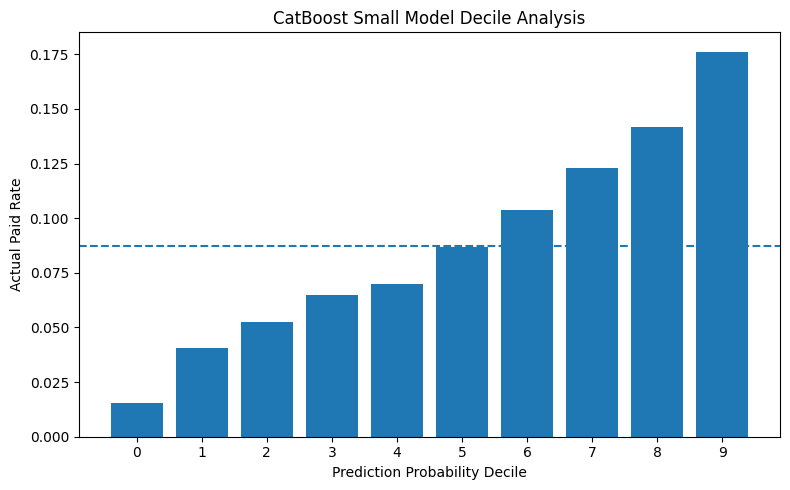

In [ ]:
import matplotlib.pyplot as plt

plot_df = decile_summary.sort_values("decile")

plt.figure(figsize=(8, 5))
plt.bar(plot_df["decile"].astype(str), plot_df["paid_rate"])
plt.axhline(overall_paid_rate, linestyle="--")
plt.xlabel("Prediction Probability Decile")
plt.ylabel("Actual Paid Rate")
plt.title("CatBoost Small Model Decile Analysis")
plt.tight_layout()
plt.show()

CatBoost 모델의 예측 확률을 기준으로 테스트 유저를 10개 구간으로 나누어 Decile 분석을 수행하였다. 분석 결과, 예측 확률이 높은 구간일수록 실제 결제율이 높아지는 경향이 확인되었다. 예측 확률 상위 10% 유저의 실제 결제율은 17.62%로 전체 평균 결제율 8.74% 대비 약 2.02배 높게 나타났다.

또한 상위 20% 유저의 결제율은 15.91%, 상위 30% 유저의 결제율은 14.70%로 나타나, 모델이 결제 가능성이 높은 유저를 상위 구간에 비교적 잘 정렬하고 있음을 확인하였다. 따라서 해당 모델은 개별 유저의 결제 여부를 완벽히 판별하는 모델이라기보다, 결제 가능성이 높은 유저군을 우선 선별하는 타겟팅 모델로 해석할 수 있다.

In [ ]:
import pandas as pd
import numpy as np

cat_model = cat_small_result["model"]
X_train = cat_small_result["X_train"]

feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": cat_model.get_feature_importance()
})

feature_importance_df = feature_importance_df.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df["importance_ratio"] = (
    feature_importance_df["importance"] 
    / feature_importance_df["importance"].sum()
)

feature_importance_df["importance_ratio_percent"] = (
    feature_importance_df["importance_ratio"] * 100
)

feature_importance_df

,feature,importance,importance_ratio,importance_ratio_percent
0,log_attendance_count,20.083607,0.200836,20.083607
1,log_received_x_attendance,19.125737,0.191257,19.125737
2,log_sent_x_received,19.027271,0.190273,19.027271
3,log_sent_request_count,16.125341,0.161253,16.125341
4,log_received_request_count,14.577576,0.145776,14.577576
5,log_sent_x_attendance,11.060468,0.110605,11.060468


In [ ]:
feature_name_map = {
    "log_sent_request_count": "친구 요청 보낸 수",
    "log_received_request_count": "친구 요청 받은 수",
    "log_attendance_count": "출석 일수",
    "log_sent_x_attendance": "친구 요청 보낸 수 × 출석 일수",
    "log_sent_x_received": "친구 요청 보낸 수 × 친구 요청 받은 수",
    "log_received_x_attendance": "친구 요청 받은 수 × 출석 일수"
}

feature_importance_df["feature_kr"] = (
    feature_importance_df["feature"]
    .map(feature_name_map)
    .fillna(feature_importance_df["feature"])
)

feature_importance_display = feature_importance_df.copy()

feature_importance_display["importance"] = (
    feature_importance_display["importance"].round(4)
)

feature_importance_display["importance_ratio_percent"] = (
    feature_importance_display["importance_ratio_percent"].round(2)
)

feature_importance_display[[
    "feature",
    "feature_kr",
    "importance",
    "importance_ratio_percent"
]]

,feature,feature_kr,importance,importance_ratio_percent
0,log_attendance_count,출석 일수,20.0836,20.08
1,log_received_x_attendance,친구 요청 받은 수 × 출석 일수,19.1257,19.13
2,log_sent_x_received,친구 요청 보낸 수 × 친구 요청 받은 수,19.0273,19.03
3,log_sent_request_count,친구 요청 보낸 수,16.1253,16.13
4,log_received_request_count,친구 요청 받은 수,14.5776,14.58
5,log_sent_x_attendance,친구 요청 보낸 수 × 출석 일수,11.0605,11.06


shap

In [ ]:
!pip install shap
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
cat_model = cat_small_result["model"]
X_test = cat_small_result["X_test"]

explainer = shap.TreeExplainer(cat_model)

shap_values = explainer.shap_values(X_test)

# binary classification에서 list로 나오는 경우 처리
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

print("X_test shape:", X_test.shape)
print("SHAP shape:", shap_values_plot.shape)

X_test shape: (135416, 6)
SHAP shape: (135416, 6)


In [ ]:
feature_name_map = {
    "log_sent_request_count": "친구 요청 보낸 수",
    "log_received_request_count": "친구 요청 받은 수",
    "log_attendance_count": "출석 일수",
    "log_sent_x_attendance": "친구 요청 보낸 수 × 출석 일수",
    "log_sent_x_received": "친구 요청 보낸 수 × 친구 요청 받은 수",
    "log_received_x_attendance": "친구 요청 받은 수 × 출석 일수"
}

In [ ]:
shap_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": np.abs(shap_values_plot).mean(axis=0)
})

shap_importance_df = shap_importance_df.sort_values(
    "mean_abs_shap",
    ascending=False
).reset_index(drop=True)

shap_importance_df["importance_ratio"] = (
    shap_importance_df["mean_abs_shap"]
    / shap_importance_df["mean_abs_shap"].sum()
)

shap_importance_df["importance_ratio_percent"] = (
    shap_importance_df["importance_ratio"] * 100
)

shap_importance_df["feature_kr"] = (
    shap_importance_df["feature"]
    .map(feature_name_map)
    .fillna(shap_importance_df["feature"])
)

shap_importance_display = shap_importance_df.copy()
shap_importance_display["mean_abs_shap"] = (
    shap_importance_display["mean_abs_shap"].round(4)
)
shap_importance_display["importance_ratio_percent"] = (
    shap_importance_display["importance_ratio_percent"].round(2)
)

shap_importance_display[[
    "feature",
    "feature_kr",
    "mean_abs_shap",
    "importance_ratio_percent"
]]

,feature,feature_kr,mean_abs_shap,importance_ratio_percent
0,log_received_x_attendance,친구 요청 받은 수 × 출석 일수,0.2009,23.37
1,log_sent_x_attendance,친구 요청 보낸 수 × 출석 일수,0.1585,18.44
2,log_attendance_count,출석 일수,0.1332,15.50
3,log_received_request_count,친구 요청 받은 수,0.1297,15.09
4,log_sent_request_count,친구 요청 보낸 수,0.1244,14.47
5,log_sent_x_received,친구 요청 보낸 수 × 친구 요청 받은 수,0.1128,13.12


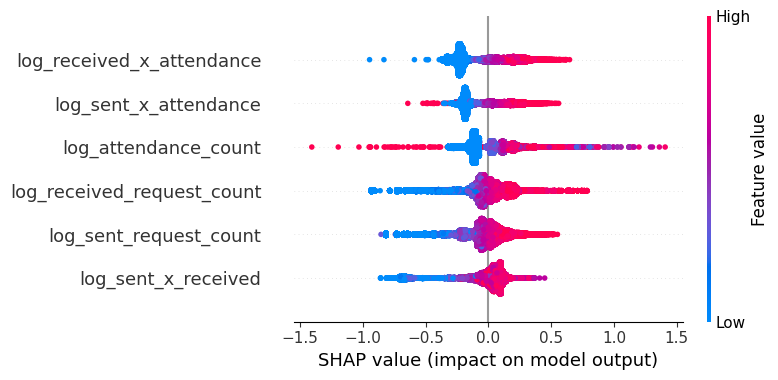

In [ ]:
shap.summary_plot(
    shap_values_plot,
    X_test,
    feature_names=X_test.columns,
    show=True
)

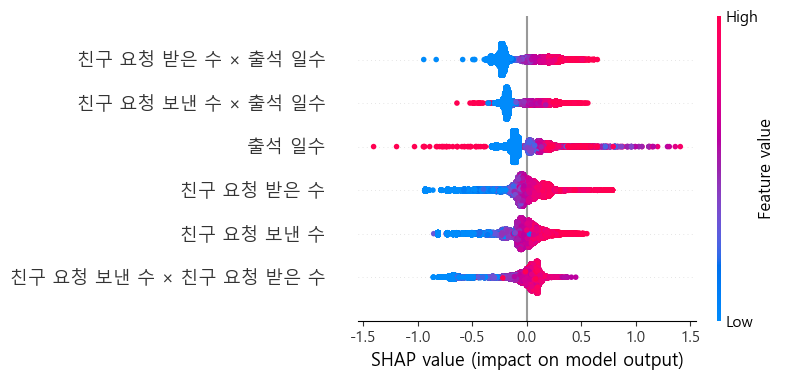

In [ ]:
import shap
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

feature_name_map = {
    "log_received_x_attendance": "친구 요청 받은 수 × 출석 일수",
    "log_sent_x_attendance": "친구 요청 보낸 수 × 출석 일수",
    "log_attendance_count": "출석 일수",
    "log_received_request_count": "친구 요청 받은 수",
    "log_sent_request_count": "친구 요청 보낸 수",
    "log_sent_x_received": "친구 요청 보낸 수 × 친구 요청 받은 수"
}

X_test_kr = X_test.rename(columns=feature_name_map)

shap.summary_plot(
    shap_values,
    X_test_kr,
    plot_type="dot",
    show=True
)

CatBoost 모델에 대해 SHAP Summary Plot을 확인한 결과, 결제 예측에 가장 큰 영향을 미친 변수는 친구 요청 받은 수와 출석 일수의 교호작용 변수였으며, 다음으로 친구 요청 보낸 수와 출석 일수의 교호작용 변수가 중요하게 나타났다. 이는 단순히 친구 요청을 많이 보내거나 출석을 많이 하는 것보다, 소셜 관계 형성 행동과 반복 방문 행동이 함께 나타날 때 결제 가능성이 높게 예측됨을 의미한다.

또한 친구 요청 받은 수와 친구 요청 보낸 수는 값이 높을수록 대체로 양의 SHAP 값을 보여 결제 예측값을 증가시키는 방향으로 작용하였다. 반면 출석 일수는 단독 변수로도 중요하지만, SHAP 값의 분포가 비교적 넓게 나타나 단독 효과보다는 친구 요청 행동과 결합될 때 더 뚜렷한 결제 가능성 증가 신호를 보이는 것으로 해석된다.

따라서 본 분석에서는 친구 요청 행동과 반복 출석 행동의 결합이 결제 전환 가능성을 설명하는 핵심 행동 패턴임을 확인하였다.

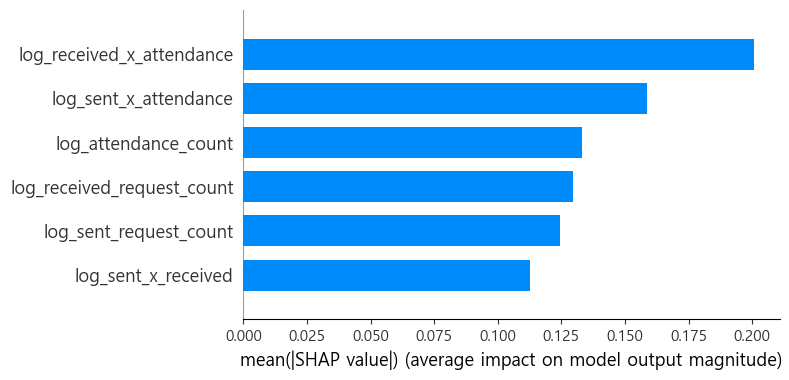

In [ ]:
shap.summary_plot(
    shap_values_plot,
    X_test,
    feature_names=X_test.columns,
    plot_type="bar",
    show=True
)

shap dependence plot

In [ ]:
!pip install koreanize-matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
import koreanize_matplotlib
import matplotlib.pyplot as plt

plt.rcParams["axes.unicode_minus"] = False

In [ ]:
import numpy as np
import pandas as pd

X_test = cat_small_result["X_test"].copy()
y_test = cat_small_result["y_test"].copy()
proba = cat_small_result["proba"]

shap_analysis_df = X_test.copy()

# 원래 횟수 복원
shap_analysis_df["sent_request_count_raw"] = np.expm1(
    shap_analysis_df["log_sent_request_count"]
).round().astype(int)

shap_analysis_df["received_request_count_raw"] = np.expm1(
    shap_analysis_df["log_received_request_count"]
).round().astype(int)

shap_analysis_df["attendance_count_raw"] = np.expm1(
    shap_analysis_df["log_attendance_count"]
).round().astype(int)

# 교호작용 원래 곱값 복원
shap_analysis_df["sent_x_attendance_raw"] = np.expm1(
    shap_analysis_df["log_sent_x_attendance"]
).round().astype(int)

shap_analysis_df["sent_x_received_raw"] = np.expm1(
    shap_analysis_df["log_sent_x_received"]
).round().astype(int)

shap_analysis_df["received_x_attendance_raw"] = np.expm1(
    shap_analysis_df["log_received_x_attendance"]
).round().astype(int)

# 타깃, 예측확률
shap_analysis_df["y_true"] = y_test.values
shap_analysis_df["proba"] = proba

# SHAP 값 붙이기
for i, col in enumerate(X_test.columns):
    shap_analysis_df[f"shap_{col}"] = shap_values_plot[:, i]

shap_analysis_df.head()

,log_sent_request_count,log_received_request_count,log_attendance_count,log_sent_x_attendance,log_sent_x_received,log_received_x_attendance,sent_request_count_raw,received_request_count_raw,attendance_count_raw,sent_x_attendance_raw,sent_x_received_raw,received_x_attendance_raw,y_true,proba,shap_log_sent_request_count,shap_log_received_request_count,shap_log_attendance_count,shap_log_sent_x_attendance,shap_log_sent_x_received,shap_log_received_x_attendance
466376,3.295837,2.890372,0.693147,3.295837,6.093570,2.890372,26,17,1,26,442,17,0,0.514180,-0.007765,-0.043895,0.034945,0.033733,0.048449,0.018190
322424,2.397895,3.583519,0.000000,0.000000,5.860786,0.000000,10,35,0,0,350,0,0,0.378573,-0.098103,0.079925,-0.109127,-0.190402,0.079570,-0.230552
431007,3.044522,4.158883,0.000000,0.000000,7.139660,0.000000,20,63,0,0,1260,0,0,0.427466,-0.065579,0.204224,-0.094273,-0.195983,0.083122,-0.196788
344184,4.060443,2.890372,1.945910,5.837730,6.877296,4.634729,57,17,6,342,969,102,1,0.668554,0.066332,-0.015870,0.151276,0.265695,0.145563,0.115575
403492,3.433987,3.526361,2.302585,5.602119,6.898715,5.697093,30,33,9,270,990,297,1,0.686183,0.017777,0.034490,0.196506,0.242834,0.063804,0.253842


In [ ]:
def get_shap_threshold_summary(
    df,
    raw_col,
    shap_col,
    min_count=100
):
    summary = df.groupby(raw_col).agg(
        user_count=("y_true", "count"),
        paid_count=("y_true", "sum"),
        paid_rate=("y_true", "mean"),
        avg_proba=("proba", "mean"),
        avg_shap=(shap_col, "mean"),
        median_shap=(shap_col, "median")
    ).reset_index()

    # 표본 수 적은 구간 제거
    summary = summary[summary["user_count"] >= min_count].copy()

    summary = summary.sort_values(raw_col).reset_index(drop=True)

    summary["paid_rate_percent"] = (summary["paid_rate"] * 100).round(2)
    summary["avg_proba_percent"] = (summary["avg_proba"] * 100).round(2)
    summary["avg_shap"] = summary["avg_shap"].round(4)
    summary["median_shap"] = summary["median_shap"].round(4)

    summary["avg_shap_diff"] = summary["avg_shap"].diff()
    summary["avg_proba_diff"] = summary["avg_proba"].diff()

    positive_df = summary[summary["avg_shap"] > 0].copy()

    if len(positive_df) > 0:
        positive_threshold = positive_df.iloc[0][raw_col]
        positive_avg_shap = positive_df.iloc[0]["avg_shap"]
        positive_user_count = positive_df.iloc[0]["user_count"]
        positive_paid_rate = positive_df.iloc[0]["paid_rate_percent"]
        positive_avg_proba = positive_df.iloc[0]["avg_proba_percent"]
    else:
        positive_threshold = np.nan
        positive_avg_shap = np.nan
        positive_user_count = np.nan
        positive_paid_rate = np.nan
        positive_avg_proba = np.nan

    jump_df = summary.dropna(subset=["avg_shap_diff"]).sort_values(
        "avg_shap_diff",
        ascending=False
    )

    if len(jump_df) > 0:
        jump_threshold = jump_df.iloc[0][raw_col]
        max_shap_diff = jump_df.iloc[0]["avg_shap_diff"]
        jump_avg_shap = jump_df.iloc[0]["avg_shap"]
        jump_user_count = jump_df.iloc[0]["user_count"]
        jump_paid_rate = jump_df.iloc[0]["paid_rate_percent"]
        jump_avg_proba = jump_df.iloc[0]["avg_proba_percent"]
    else:
        jump_threshold = np.nan
        max_shap_diff = np.nan
        jump_avg_shap = np.nan
        jump_user_count = np.nan
        jump_paid_rate = np.nan
        jump_avg_proba = np.nan

    result = {
        "positive_threshold": positive_threshold,
        "positive_avg_shap": positive_avg_shap,
        "positive_user_count": positive_user_count,
        "positive_paid_rate_percent": positive_paid_rate,
        "positive_avg_proba_percent": positive_avg_proba,
        "jump_threshold": jump_threshold,
        "jump_avg_shap": jump_avg_shap,
        "max_shap_diff": max_shap_diff,
        "jump_user_count": jump_user_count,
        "jump_paid_rate_percent": jump_paid_rate,
        "jump_avg_proba_percent": jump_avg_proba
    }

    return summary, result

In [ ]:
feature_threshold_config = [
    {
        "feature": "log_sent_request_count",
        "feature_kr": "친구 요청 보낸 수",
        "raw_col": "sent_request_count_raw",
        "shap_col": "shap_log_sent_request_count",
        "type": "main"
    },
    {
        "feature": "log_received_request_count",
        "feature_kr": "친구 요청 받은 수",
        "raw_col": "received_request_count_raw",
        "shap_col": "shap_log_received_request_count",
        "type": "main"
    },
    {
        "feature": "log_attendance_count",
        "feature_kr": "출석 횟수",
        "raw_col": "attendance_count_raw",
        "shap_col": "shap_log_attendance_count",
        "type": "main"
    },
    {
        "feature": "log_sent_x_attendance",
        "feature_kr": "친구 요청 보낸 수 × 출석 횟수",
        "raw_col": "sent_x_attendance_raw",
        "shap_col": "shap_log_sent_x_attendance",
        "type": "interaction"
    },
    {
        "feature": "log_sent_x_received",
        "feature_kr": "친구 요청 보낸 수 × 친구 요청 받은 수",
        "raw_col": "sent_x_received_raw",
        "shap_col": "shap_log_sent_x_received",
        "type": "interaction"
    },
    {
        "feature": "log_received_x_attendance",
        "feature_kr": "친구 요청 받은 수 × 출석 횟수",
        "raw_col": "received_x_attendance_raw",
        "shap_col": "shap_log_received_x_attendance",
        "type": "interaction"
    }
]

In [ ]:
threshold_results = []
summary_dict = {}

for config in feature_threshold_config:
    summary, result = get_shap_threshold_summary(
        df=shap_analysis_df,
        raw_col=config["raw_col"],
        shap_col=config["shap_col"],
        min_count=100
    )

    summary_dict[config["feature"]] = summary

    threshold_results.append({
        "feature": config["feature"],
        "feature_kr": config["feature_kr"],
        "type": config["type"],
        "positive_threshold": result["positive_threshold"],
        "positive_avg_shap": result["positive_avg_shap"],
        "positive_user_count": result["positive_user_count"],
        "positive_paid_rate_percent": result["positive_paid_rate_percent"],
        "positive_avg_proba_percent": result["positive_avg_proba_percent"],
        "jump_threshold": result["jump_threshold"],
        "jump_avg_shap": result["jump_avg_shap"],
        "max_shap_diff": result["max_shap_diff"],
        "jump_user_count": result["jump_user_count"],
        "jump_paid_rate_percent": result["jump_paid_rate_percent"],
        "jump_avg_proba_percent": result["jump_avg_proba_percent"]
    })

threshold_summary_df = pd.DataFrame(threshold_results)

threshold_summary_display = threshold_summary_df.copy()

for col in [
    "positive_threshold",
    "jump_threshold",
    "positive_user_count",
    "jump_user_count"
]:
    threshold_summary_display[col] = threshold_summary_display[col].round(0).astype("Int64")

for col in [
    "positive_avg_shap",
    "jump_avg_shap",
    "max_shap_diff",
    "positive_paid_rate_percent",
    "positive_avg_proba_percent",
    "jump_paid_rate_percent",
    "jump_avg_proba_percent"
]:
    threshold_summary_display[col] = threshold_summary_display[col].round(4)

threshold_summary_display

,feature,feature_kr,type,positive_threshold,positive_avg_shap,positive_user_count,positive_paid_rate_percent,positive_avg_proba_percent,jump_threshold,jump_avg_shap,max_shap_diff,jump_user_count,jump_paid_rate_percent,jump_avg_proba_percent
0,log_sent_request_count,친구 요청 보낸 수,main,21,0.0082,2974,9.18,48.62,1,-0.4068,0.1256,2580,4.73,25.90
1,log_received_request_count,친구 요청 받은 수,main,24,0.0328,2514,8.75,49.33,1,-0.4537,0.1605,3185,3.58,24.72
2,log_attendance_count,출석 횟수,main,1,0.0555,15807,9.43,49.90,1,0.0555,0.1812,15807,9.43,49.90
3,log_sent_x_attendance,친구 요청 보낸 수 × 출석 횟수,interaction,24,0.0296,917,9.27,54.03,1,-0.0995,0.0868,210,10.00,44.92
4,log_sent_x_received,친구 요청 보낸 수 × 친구 요청 받은 수,interaction,102,0.0039,216,6.02,43.90,10,-0.2696,0.2598,325,5.85,22.44
5,log_received_x_attendance,친구 요청 받은 수 × 출석 횟수,interaction,13,0.0322,373,12.06,49.45,1,-0.1302,0.1080,307,4.56,34.89


In [ ]:
for config in feature_threshold_config:
    feature = config["feature"]
    feature_kr = config["feature_kr"]
    raw_col = config["raw_col"]

    print("=" * 100)
    print(feature_kr)

    temp = summary_dict[feature].copy()

    display(temp[[
        raw_col,
        "user_count",
        "paid_count",
        "paid_rate_percent",
        "avg_proba_percent",
        "avg_shap",
        "median_shap",
        "avg_shap_diff"
    ]].head(50))

친구 요청 보낸 수


,sent_request_count_raw,user_count,paid_count,paid_rate_percent,avg_proba_percent,avg_shap,median_shap,avg_shap_diff
0,0,5694,151,2.65,16.65,-0.5324,-0.5368,NaN
1,1,2580,122,4.73,25.90,-0.4068,-0.4110,0.1256
2,2,2369,111,4.69,31.36,-0.3001,-0.2869,0.1067
3,3,2548,134,5.26,33.95,-0.2587,-0.2278,0.0414
4,4,2750,184,6.69,36.10,-0.2019,-0.1793,0.0568
5,5,2935,185,6.30,37.85,-0.2018,-0.1941,0.0001
6,6,2909,171,5.88,38.51,-0.1870,-0.1819,0.0148
7,7,3152,240,7.61,40.82,-0.1489,-0.1473,0.0381
8,8,3318,240,7.23,40.20,-0.1766,-0.1837,-0.0277
9,9,3473,268,7.72,40.26,-0.2023,-0.2085,-0.0257


친구 요청 받은 수


,received_request_count_raw,user_count,paid_count,paid_rate_percent,avg_proba_percent,avg_shap,median_shap,avg_shap_diff
0,0,3251,77,2.37,16.43,-0.6142,-0.5339,NaN
1,1,3185,114,3.58,24.72,-0.4537,-0.4027,0.1605
2,2,3233,136,4.21,28.91,-0.3951,-0.3484,0.0586
3,3,3388,198,5.84,32.50,-0.3161,-0.2521,0.0790
4,4,3548,219,6.17,34.88,-0.1952,-0.1535,0.1209
5,5,3325,216,6.50,37.89,-0.1425,-0.1137,0.0527
6,6,3414,221,6.47,38.22,-0.1292,-0.1168,0.0133
7,7,3320,216,6.51,39.55,-0.1172,-0.1055,0.0120
8,8,3337,243,7.28,41.06,-0.0754,-0.0717,0.0418
9,9,3101,248,8.00,42.54,-0.0727,-0.0704,0.0027


출석 횟수


...

,sent_x_attendance_raw,user_count,paid_count,paid_rate_percent,avg_proba_percent,avg_shap,median_shap,avg_shap_diff
0,0,70523,3611,5.12,34.33,-0.1863,-0.1849,NaN
1,1,210,21,10.00,44.92,-0.0995,-0.1043,0.0868
2,2,312,29,9.29,47.26,-0.0943,-0.0944,0.0052
3,3,275,22,8.00,47.08,-0.0971,-0.0982,-0.0028
4,4,431,39,9.05,47.29,-0.0979,-0.1024,-0.0008
5,5,363,27,7.44,45.76,-0.1071,-0.1107,-0.0092
6,6,566,55,9.72,47.49,-0.1077,-0.1088,-0.0006
7,7,403,38,9.43,45.83,-0.1083,-0.1144,-0.0006
8,8,601,53,8.82,46.43,-0.1273,-0.1411,-0.0190
9,9,518,53,10.23,44.96,-0.1287,-0.1295,-0.0014


친구 요청 보낸 수 × 친구 요청 받은 수


,sent_x_received_raw,user_count,paid_count,paid_rate_percent,avg_proba_percent,avg_shap,median_shap,avg_shap_diff
0,0,8286,223,2.69,17.52,-0.5901,-0.6660,NaN
1,1,175,3,1.71,8.94,-0.6600,-0.6831,-0.0699
2,2,255,2,0.78,9.32,-0.6623,-0.6809,-0.0023
3,3,240,3,1.25,11.30,-0.5838,-0.6055,0.0785
4,4,355,12,3.38,12.78,-0.5940,-0.6329,-0.0102
5,5,173,6,3.47,15.05,-0.5732,-0.6035,0.0208
6,6,398,6,1.51,15.97,-0.5610,-0.6205,0.0122
7,7,171,9,5.26,18.65,-0.5376,-0.5862,0.0234
8,8,336,11,3.27,17.09,-0.5585,-0.5920,-0.0209
9,9,238,10,4.20,18.57,-0.5294,-0.5920,0.0291


친구 요청 받은 수 × 출석 횟수


,received_x_attendance_raw,user_count,paid_count,paid_rate_percent,avg_proba_percent,avg_shap,median_shap,avg_shap_diff
0,0,70722,3574,5.05,34.13,-0.2382,-0.2284,NaN
1,1,307,14,4.56,34.89,-0.1302,-0.1405,0.1080
2,2,514,29,5.64,37.67,-0.1474,-0.1443,-0.0172
3,3,421,38,9.03,42.47,-0.0678,-0.0707,0.0796
4,4,617,44,7.13,43.70,-0.0852,-0.0885,-0.0174
5,5,412,29,7.04,46.91,-0.0342,-0.0396,0.0510
6,6,710,59,8.31,47.00,-0.0284,-0.0393,0.0058
7,7,388,28,7.22,47.50,-0.0259,-0.0356,0.0025
8,8,706,58,8.22,48.00,-0.0267,-0.0373,-0.0008
9,9,511,61,11.94,47.86,-0.0314,-0.0400,-0.0047


In [ ]:
for config in feature_threshold_config:
    feature = config["feature"]
    feature_kr = config["feature_kr"]
    raw_col = config["raw_col"]

    print("=" * 100)
    print(feature_kr, "급증 구간 Top 10")

    temp = summary_dict[feature].copy()

    jump_top10 = temp.dropna(subset=["avg_shap_diff"]).sort_values(
        "avg_shap_diff",
        ascending=False
    ).head(10)

    display(jump_top10[[
        raw_col,
        "user_count",
        "paid_count",
        "paid_rate_percent",
        "avg_proba_percent",
        "avg_shap",
        "avg_shap_diff",
        "avg_proba_diff"
    ]])

친구 요청 보낸 수 급증 구간 Top 10


,sent_request_count_raw,user_count,paid_count,paid_rate_percent,avg_proba_percent,avg_shap,avg_shap_diff,avg_proba_diff
1,1,2580,122,4.73,25.90,-0.4068,0.1256,0.092497
10,10,3384,259,7.65,42.27,-0.0838,0.1185,0.020106
2,2,2369,111,4.69,31.36,-0.3001,0.1067,0.054614
51,51,705,96,13.62,54.70,0.1107,0.0585,0.019982
4,4,2750,184,6.69,36.10,-0.2019,0.0568,0.021522
21,21,2974,273,9.18,48.62,0.0082,0.0424,0.017299
3,3,2548,134,5.26,33.95,-0.2587,0.0414,0.025819
83,83,128,13,10.16,57.34,0.2506,0.0385,-0.001436
7,7,3152,240,7.61,40.82,-0.1489,0.0381,0.023083
14,14,3504,293,8.36,45.65,-0.0269,0.0368,0.009813


친구 요청 받은 수 급증 구간 Top 10


,received_request_count_raw,user_count,paid_count,paid_rate_percent,avg_proba_percent,avg_shap,avg_shap_diff,avg_proba_diff
1,1,3185,114,3.58,24.72,-0.4537,0.1605,0.082893
4,4,3548,219,6.17,34.88,-0.1952,0.1209,0.023865
3,3,3388,198,5.84,32.50,-0.3161,0.0790,0.035892
2,2,3233,136,4.21,28.91,-0.3951,0.0586,0.041845
5,5,3325,216,6.50,37.89,-0.1425,0.0527,0.030044
24,24,2514,220,8.75,49.33,0.0328,0.0487,0.007590
8,8,3337,243,7.28,41.06,-0.0754,0.0418,0.015173
83,83,116,11,9.48,53.24,0.1869,0.0411,-0.001486
62,62,461,64,13.88,56.50,0.2138,0.0272,0.009780
40,40,1525,164,10.75,53.18,0.1377,0.0237,0.000835


출석 횟수 급증 구간 Top 10


...

,sent_x_attendance_raw,user_count,paid_count,paid_rate_percent,avg_proba_percent,avg_shap,avg_shap_diff,avg_proba_diff
1,1,210,21,10.00,44.92,-0.0995,0.0868,0.105873
58,62,220,30,13.64,55.45,0.0926,0.0827,-0.017467
146,270,182,29,15.93,65.37,0.2552,0.0530,0.002429
24,24,917,85,9.27,54.03,0.0296,0.0467,0.031399
98,124,112,18,16.07,60.05,0.1474,0.0456,-0.010605
14,14,687,61,8.88,49.94,-0.0226,0.0401,0.031886
20,20,850,83,9.76,51.48,-0.0073,0.0344,0.027663
38,38,385,43,11.17,53.71,0.0549,0.0305,0.003079
32,32,646,70,10.84,54.57,0.0383,0.0285,0.029228
12,12,815,84,10.31,49.03,-0.0711,0.0271,0.027382


친구 요청 보낸 수 × 친구 요청 받은 수 급증 구간 Top 10


,sent_x_received_raw,user_count,paid_count,paid_rate_percent,avg_proba_percent,avg_shap,avg_shap_diff,avg_proba_diff
10,10,325,19,5.85,22.44,-0.2696,0.2598,0.038716
47,56,367,23,6.27,36.91,-0.0907,0.1235,0.033430
63,81,156,11,7.05,40.03,-0.0248,0.0850,0.011826
3,3,240,3,1.25,11.30,-0.5838,0.0785,0.019741
24,25,150,3,2.00,33.38,-0.1206,0.0756,0.046486
73,99,254,19,7.48,39.83,-0.0072,0.0628,0.014748
13,13,121,5,4.13,29.65,-0.2245,0.0509,0.080498
40,46,111,5,4.50,41.92,-0.0623,0.0398,0.065501
17,17,116,7,6.03,31.95,-0.2188,0.0394,0.062205
48,57,148,11,7.43,38.14,-0.0516,0.0391,0.012347


친구 요청 받은 수 × 출석 횟수 급증 구간 Top 10


,received_x_attendance_raw,user_count,paid_count,paid_rate_percent,avg_proba_percent,avg_shap,avg_shap_diff,avg_proba_diff
1,1,307,14,4.56,34.89,-0.1302,0.1080,0.007589
3,3,421,38,9.03,42.47,-0.0678,0.0796,0.048047
73,78,372,43,11.56,59.52,0.1957,0.0664,0.009036
13,13,373,45,12.06,49.45,0.0322,0.0570,0.001119
100,124,138,20,14.49,62.91,0.2571,0.0511,0.009613
5,5,412,29,7.04,46.91,-0.0342,0.0510,0.032097
31,31,255,24,9.41,52.54,0.0626,0.0492,0.002546
48,48,751,91,12.12,56.53,0.1006,0.0382,0.006781
94,111,101,13,12.87,62.40,0.2308,0.0305,0.010317
159,420,129,24,18.60,69.01,0.3104,0.0288,0.005465


출석 횟수는 1회부터 평균 SHAP 값이 양수로 전환되었고, 3회 이상부터 실제 결제율이 12% 수준으로 전체 평균 결제율 8.74%를 뚜렷하게 상회하였다. 이후 7~9회 이상 구간에서는 결제율이 약 13~15% 수준으로 증가하였다.

친구 요청 받은 수는 낮은 구간에서는 평균 SHAP 값이 음수로 나타났으나, 약 24회부터 양수로 전환되었다. 이는 친구 요청을 일정 수준 이상 받은 유저에서 해당 변수가 결제 예측값을 증가시키는 방향으로 작용함을 의미한다.

친구 요청 보낸 수는 약 21회부터 평균 SHAP 값이 양수로 전환되었으며, 51회 구간에서는 결제율 13.62%, 평균 SHAP 0.1107로 더 뚜렷한 양의 영향이 확인되었다.


shap dependence >100, 교호제외

In [ ]:
single_feature_config = [
    {
        "feature": "log_sent_request_count",
        "feature_kr": "친구 요청 보낸 수",
        "raw_col": "sent_request_count_raw",
        "shap_col": "shap_log_sent_request_count"
    },
    {
        "feature": "log_received_request_count",
        "feature_kr": "친구 요청 받은 수",
        "raw_col": "received_request_count_raw",
        "shap_col": "shap_log_received_request_count"
    },
    {
        "feature": "log_attendance_count",
        "feature_kr": "출석 횟수",
        "raw_col": "attendance_count_raw",
        "shap_col": "shap_log_attendance_count"
    }
]

In [ ]:
def get_single_shap_dependence_summary(
    df,
    raw_col,
    shap_col,
    min_user_count=100
):
    summary = df.groupby(raw_col).agg(
        user_count=("y_true", "count"),
        paid_count=("y_true", "sum"),
        paid_rate=("y_true", "mean"),
        avg_proba=("proba", "mean"),
        avg_shap=(shap_col, "mean"),
        median_shap=(shap_col, "median")
    ).reset_index()

    # user_count 100 이하 제외
    summary = summary[summary["user_count"] > min_user_count].copy()

    # 원래 횟수 순서로 정렬
    summary = summary.sort_values(raw_col).reset_index(drop=True)

    summary["paid_rate_percent"] = (summary["paid_rate"] * 100).round(2)
    summary["avg_proba_percent"] = (summary["avg_proba"] * 100).round(2)
    summary["avg_shap"] = summary["avg_shap"].round(4)
    summary["median_shap"] = summary["median_shap"].round(4)

    # 직전 횟수 대비 평균 SHAP 변화량
    summary["avg_shap_diff"] = summary["avg_shap"].diff()
    summary["avg_proba_diff"] = summary["avg_proba"].diff()

    # SHAP 양수 전환 지점
    positive_df = summary[summary["avg_shap"] > 0].copy()

    if len(positive_df) > 0:
        positive_row = positive_df.iloc[0]
    else:
        positive_row = None

    # SHAP 급증 지점
    jump_df = summary.dropna(subset=["avg_shap_diff"]).sort_values(
        "avg_shap_diff",
        ascending=False
    )

    if len(jump_df) > 0:
        jump_row = jump_df.iloc[0]
    else:
        jump_row = None

    return summary, positive_row, jump_row

In [ ]:
single_summary_dict = {}
single_threshold_rows = []

for config in single_feature_config:
    summary, positive_row, jump_row = get_single_shap_dependence_summary(
        df=shap_analysis_df,
        raw_col=config["raw_col"],
        shap_col=config["shap_col"],
        min_user_count=100
    )

    single_summary_dict[config["feature"]] = summary

    single_threshold_rows.append({
        "feature": config["feature"],
        "feature_kr": config["feature_kr"],

        "positive_threshold": positive_row[config["raw_col"]] if positive_row is not None else np.nan,
        "positive_user_count": positive_row["user_count"] if positive_row is not None else np.nan,
        "positive_paid_rate_percent": positive_row["paid_rate_percent"] if positive_row is not None else np.nan,
        "positive_avg_proba_percent": positive_row["avg_proba_percent"] if positive_row is not None else np.nan,
        "positive_avg_shap": positive_row["avg_shap"] if positive_row is not None else np.nan,

        "jump_threshold": jump_row[config["raw_col"]] if jump_row is not None else np.nan,
        "jump_user_count": jump_row["user_count"] if jump_row is not None else np.nan,
        "jump_paid_rate_percent": jump_row["paid_rate_percent"] if jump_row is not None else np.nan,
        "jump_avg_proba_percent": jump_row["avg_proba_percent"] if jump_row is not None else np.nan,
        "jump_avg_shap": jump_row["avg_shap"] if jump_row is not None else np.nan,
        "jump_avg_shap_diff": jump_row["avg_shap_diff"] if jump_row is not None else np.nan
    })

single_shap_threshold_df = pd.DataFrame(single_threshold_rows)

single_shap_threshold_display = single_shap_threshold_df.copy()

for col in [
    "positive_threshold",
    "positive_user_count",
    "jump_threshold",
    "jump_user_count"
]:
    single_shap_threshold_display[col] = (
        single_shap_threshold_display[col].round(0).astype("Int64")
    )

for col in [
    "positive_paid_rate_percent",
    "positive_avg_proba_percent",
    "positive_avg_shap",
    "jump_paid_rate_percent",
    "jump_avg_proba_percent",
    "jump_avg_shap",
    "jump_avg_shap_diff"
]:
    single_shap_threshold_display[col] = (
        single_shap_threshold_display[col].round(4)
    )

single_shap_threshold_display

,feature,feature_kr,positive_threshold,positive_user_count,positive_paid_rate_percent,positive_avg_proba_percent,positive_avg_shap,jump_threshold,jump_user_count,jump_paid_rate_percent,jump_avg_proba_percent,jump_avg_shap,jump_avg_shap_diff
0,log_sent_request_count,친구 요청 보낸 수,21,2974,9.18,48.62,0.0082,1,2580,4.73,25.90,-0.4068,0.1256
1,log_received_request_count,친구 요청 받은 수,24,2514,8.75,49.33,0.0328,1,3185,3.58,24.72,-0.4537,0.1605
2,log_attendance_count,출석 횟수,1,15807,9.43,49.90,0.0555,1,15807,9.43,49.90,0.0555,0.1812


In [ ]:
for config in single_feature_config:
    feature = config["feature"]
    feature_kr = config["feature_kr"]
    raw_col = config["raw_col"]

    print("=" * 100)
    print(feature_kr)

    temp = single_summary_dict[feature].copy()

    display(temp[[
        raw_col,
        "user_count",
        "paid_count",
        "paid_rate_percent",
        "avg_proba_percent",
        "avg_shap",
        "median_shap",
        "avg_shap_diff",
        "avg_proba_diff"
    ]].head(50))

친구 요청 보낸 수


,sent_request_count_raw,user_count,paid_count,paid_rate_percent,avg_proba_percent,avg_shap,median_shap,avg_shap_diff,avg_proba_diff
0,0,5694,151,2.65,16.65,-0.5324,-0.5368,NaN,NaN
1,1,2580,122,4.73,25.90,-0.4068,-0.4110,0.1256,0.092497
2,2,2369,111,4.69,31.36,-0.3001,-0.2869,0.1067,0.054614
3,3,2548,134,5.26,33.95,-0.2587,-0.2278,0.0414,0.025819
4,4,2750,184,6.69,36.10,-0.2019,-0.1793,0.0568,0.021522
5,5,2935,185,6.30,37.85,-0.2018,-0.1941,0.0001,0.017544
6,6,2909,171,5.88,38.51,-0.1870,-0.1819,0.0148,0.006590
7,7,3152,240,7.61,40.82,-0.1489,-0.1473,0.0381,0.023083
8,8,3318,240,7.23,40.20,-0.1766,-0.1837,-0.0277,-0.006175
9,9,3473,268,7.72,40.26,-0.2023,-0.2085,-0.0257,0.000541


친구 요청 받은 수


,received_request_count_raw,user_count,paid_count,paid_rate_percent,avg_proba_percent,avg_shap,median_shap,avg_shap_diff,avg_proba_diff
0,0,3251,77,2.37,16.43,-0.6142,-0.5339,NaN,NaN
1,1,3185,114,3.58,24.72,-0.4537,-0.4027,0.1605,0.082893
2,2,3233,136,4.21,28.91,-0.3951,-0.3484,0.0586,0.041845
3,3,3388,198,5.84,32.50,-0.3161,-0.2521,0.0790,0.035892
4,4,3548,219,6.17,34.88,-0.1952,-0.1535,0.1209,0.023865
5,5,3325,216,6.50,37.89,-0.1425,-0.1137,0.0527,0.030044
6,6,3414,221,6.47,38.22,-0.1292,-0.1168,0.0133,0.003345
7,7,3320,216,6.51,39.55,-0.1172,-0.1055,0.0120,0.013232
8,8,3337,243,7.28,41.06,-0.0754,-0.0717,0.0418,0.015173
9,9,3101,248,8.00,42.54,-0.0727,-0.0704,0.0027,0.014738


출석 횟수


,attendance_count_raw,user_count,paid_count,paid_rate_percent,avg_proba_percent,avg_shap,median_shap,avg_shap_diff,avg_proba_diff
0,0,69766,3518,5.04,34.13,-0.1257,-0.1112,NaN,NaN
1,1,15807,1490,9.43,49.90,0.0555,0.0370,0.1812,0.157668
2,2,9290,1051,11.31,54.17,0.0572,0.0394,0.0017,0.042736
3,3,6293,755,12.00,58.57,0.1431,0.1192,0.0859,0.044020
4,4,4958,666,13.43,60.27,0.1427,0.1206,-0.0004,0.016998
5,5,3903,510,13.07,61.44,0.1402,0.1193,-0.0025,0.011633
6,6,3319,440,13.26,62.45,0.1470,0.1259,0.0068,0.010121
7,7,2835,387,13.65,63.18,0.1841,0.1640,0.0371,0.007312
8,8,2508,354,14.11,63.67,0.1912,0.1689,0.0071,0.004947
9,9,2202,321,14.58,65.12,0.2404,0.2140,0.0492,0.014439


In [ ]:
for config in single_feature_config:
    feature = config["feature"]
    feature_kr = config["feature_kr"]
    raw_col = config["raw_col"]

    print("=" * 100)
    print(feature_kr, "SHAP 급증 구간 Top 10")

    temp = single_summary_dict[feature].copy()

    jump_top10 = temp.dropna(subset=["avg_shap_diff"]).sort_values(
        "avg_shap_diff",
        ascending=False
    ).head(10)

    display(jump_top10[[
        raw_col,
        "user_count",
        "paid_count",
        "paid_rate_percent",
        "avg_proba_percent",
        "avg_shap",
        "avg_shap_diff",
        "avg_proba_diff"
    ]])

친구 요청 보낸 수 SHAP 급증 구간 Top 10


,sent_request_count_raw,user_count,paid_count,paid_rate_percent,avg_proba_percent,avg_shap,avg_shap_diff,avg_proba_diff
1,1,2580,122,4.73,25.90,-0.4068,0.1256,0.092497
10,10,3384,259,7.65,42.27,-0.0838,0.1185,0.020106
2,2,2369,111,4.69,31.36,-0.3001,0.1067,0.054614
51,51,705,96,13.62,54.70,0.1107,0.0585,0.019982
4,4,2750,184,6.69,36.10,-0.2019,0.0568,0.021522
21,21,2974,273,9.18,48.62,0.0082,0.0424,0.017299
3,3,2548,134,5.26,33.95,-0.2587,0.0414,0.025819
83,83,128,13,10.16,57.34,0.2506,0.0385,-0.001436
7,7,3152,240,7.61,40.82,-0.1489,0.0381,0.023083
14,14,3504,293,8.36,45.65,-0.0269,0.0368,0.009813


친구 요청 받은 수 SHAP 급증 구간 Top 10


,received_request_count_raw,user_count,paid_count,paid_rate_percent,avg_proba_percent,avg_shap,avg_shap_diff,avg_proba_diff
1,1,3185,114,3.58,24.72,-0.4537,0.1605,0.082893
4,4,3548,219,6.17,34.88,-0.1952,0.1209,0.023865
3,3,3388,198,5.84,32.50,-0.3161,0.0790,0.035892
2,2,3233,136,4.21,28.91,-0.3951,0.0586,0.041845
5,5,3325,216,6.50,37.89,-0.1425,0.0527,0.030044
24,24,2514,220,8.75,49.33,0.0328,0.0487,0.007590
8,8,3337,243,7.28,41.06,-0.0754,0.0418,0.015173
83,83,116,11,9.48,53.24,0.1869,0.0411,-0.001486
62,62,461,64,13.88,56.50,0.2138,0.0272,0.009780
40,40,1525,164,10.75,53.18,0.1377,0.0237,0.000835


출석 횟수 SHAP 급증 구간 Top 10


,attendance_count_raw,user_count,paid_count,paid_rate_percent,avg_proba_percent,avg_shap,avg_shap_diff,avg_proba_diff
1,1,15807,1490,9.43,49.90,0.0555,0.1812,0.157668
3,3,6293,755,12.00,58.57,0.1431,0.0859,0.044020
9,9,2202,321,14.58,65.12,0.2404,0.0492,0.014439
7,7,2835,387,13.65,63.18,0.1841,0.0371,0.007312
30,30,106,14,13.21,66.04,0.2761,0.0261,0.000951
23,23,268,42,15.67,66.57,0.3017,0.0216,0.005303
20,20,399,65,16.29,66.70,0.2796,0.0197,-0.000216
16,16,796,134,16.83,66.11,0.2566,0.0134,-0.000042
11,11,1626,249,15.31,65.35,0.2352,0.0085,0.002911
13,13,1153,182,15.78,65.81,0.2453,0.0080,0.002657


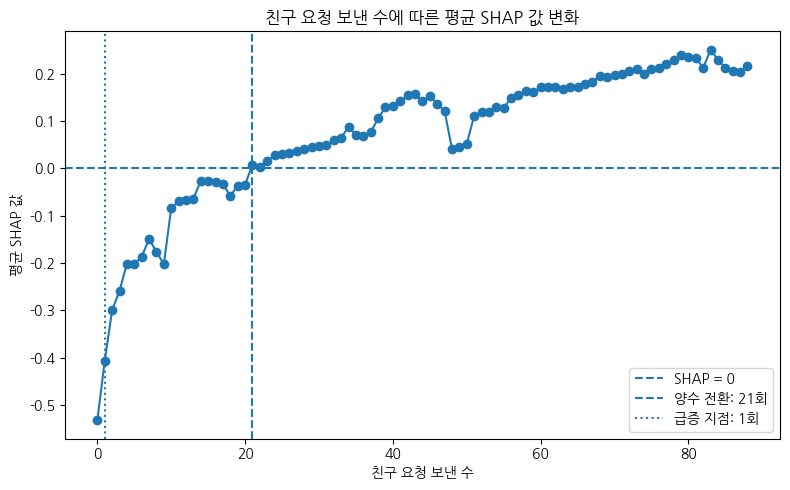

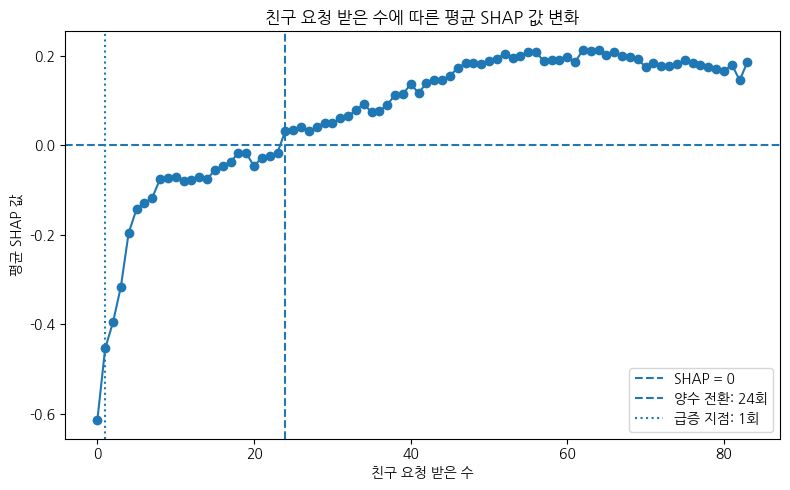

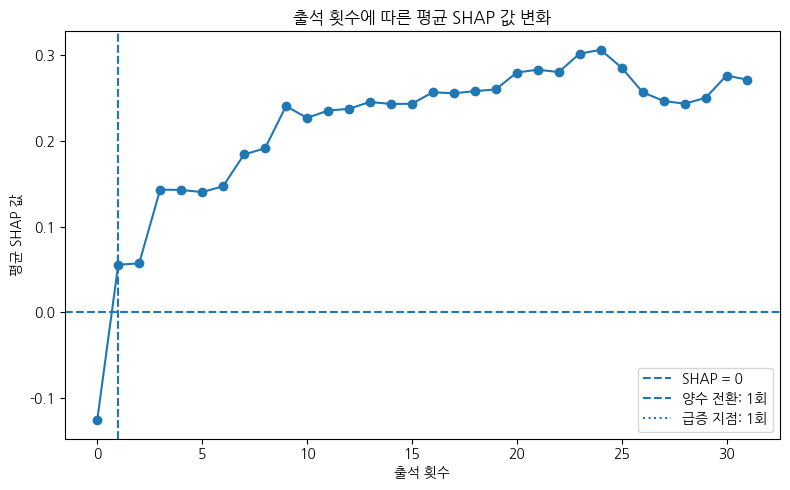

In [ ]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

plt.rcParams["axes.unicode_minus"] = False

for config in single_feature_config:
    feature = config["feature"]
    feature_kr = config["feature_kr"]
    raw_col = config["raw_col"]

    plot_df = single_summary_dict[feature].copy()

    positive_threshold = single_shap_threshold_df.loc[
        single_shap_threshold_df["feature"] == feature,
        "positive_threshold"
    ].iloc[0]

    jump_threshold = single_shap_threshold_df.loc[
        single_shap_threshold_df["feature"] == feature,
        "jump_threshold"
    ].iloc[0]

    plt.figure(figsize=(8, 5))
    plt.plot(
        plot_df[raw_col],
        plot_df["avg_shap"],
        marker="o"
    )

    plt.axhline(0, linestyle="--", label="SHAP = 0")

    if pd.notna(positive_threshold):
        plt.axvline(
            positive_threshold,
            linestyle="--",
            label=f"양수 전환: {int(positive_threshold)}회"
        )

    if pd.notna(jump_threshold):
        plt.axvline(
            jump_threshold,
            linestyle=":",
            label=f"급증 지점: {int(jump_threshold)}회"
        )

    plt.xlabel(feature_kr)
    plt.ylabel("평균 SHAP 값")
    plt.title(f"{feature_kr}에 따른 평균 SHAP 값 변화")
    plt.legend()
    plt.tight_layout()
    plt.show()

## ------------------일단 kmeans---------------------------------  

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

# KMeans 입력 변수: 받은 친구 요청 수 + 출석 일수
cluster_cols = [
    "log_received_request_count",
    "log_attendance_count"
]

X_cluster = X_small[cluster_cols].copy()

# 표준화
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

print("클러스터링 입력 데이터:", X_cluster.shape)

클러스터링 입력 데이터: (677080, 2)


In [ ]:
from sklearn.metrics import silhouette_score

k_results = []

for k in range(2, 8):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_cluster_scaled)
    
    # silhouette는 전체 데이터가 크면 오래 걸리므로 샘플링
    sil = silhouette_score(
        X_cluster_scaled,
        labels,
        sample_size=50000,
        random_state=42
    )
    
    k_results.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette_score": sil
    })

k_result_df = pd.DataFrame(k_results)
k_result_df

,k,inertia,silhouette_score
0,2,817177.172016,0.424008
1,3,450317.738854,0.466991
2,4,359522.141522,0.418110
3,5,281593.256033,0.400395
4,6,227491.979850,0.422476
5,7,196292.891173,0.396043


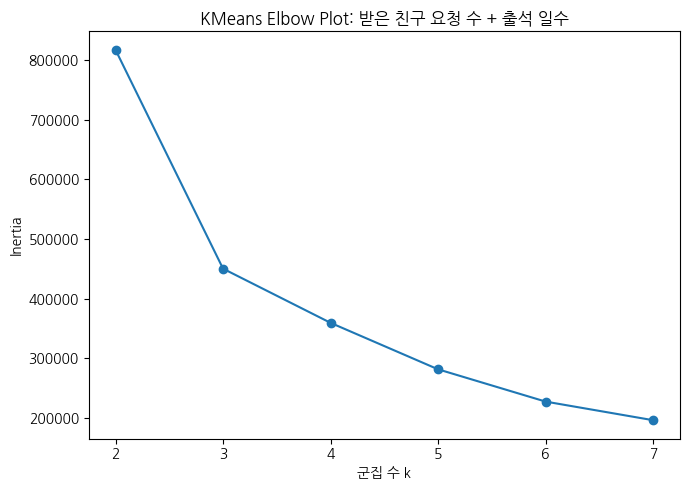

In [ ]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(7, 5))
plt.plot(k_result_df["k"], k_result_df["inertia"], marker="o")
plt.xlabel("군집 수 k")
plt.ylabel("Inertia")
plt.title("KMeans Elbow Plot: 받은 친구 요청 수 + 출석 일수")
plt.tight_layout()
plt.show()

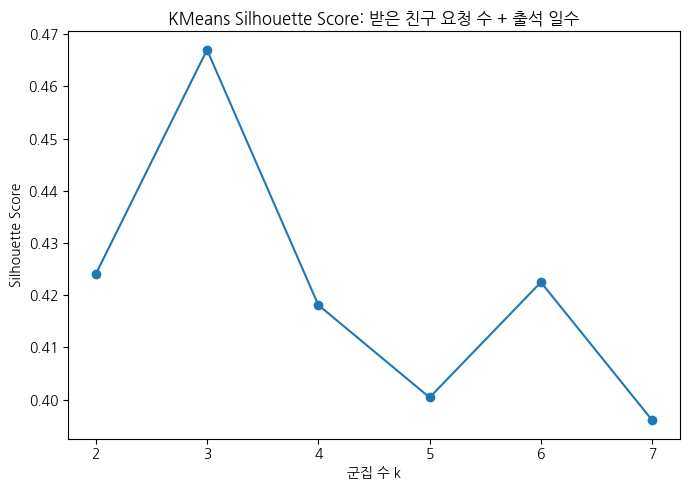

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(k_result_df["k"], k_result_df["silhouette_score"], marker="o")
plt.xlabel("군집 수 k")
plt.ylabel("Silhouette Score")
plt.title("KMeans Silhouette Score: 받은 친구 요청 수 + 출석 일수")
plt.tight_layout()
plt.show()

In [ ]:
final_k = 3

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_cluster_scaled)

cluster_df = X_small.copy()
cluster_df["cluster"] = cluster_labels
cluster_df["is_paid"] = y.values

In [ ]:
cluster_df["received_request_count_raw"] = np.expm1(
    cluster_df["log_received_request_count"]
).round().astype(int)

cluster_df["attendance_days_raw"] = np.expm1(
    cluster_df["log_attendance_count"]
).round().astype(int)

cluster_df["received_x_attendance_raw"] = np.expm1(
    cluster_df["log_received_x_attendance"]
).round().astype(int)

In [ ]:
cat_model = cat_small_result["model"]

cluster_df["catboost_proba"] = cat_model.predict_proba(X_small)[:, 1]

In [ ]:
cluster_summary = cluster_df.groupby("cluster").agg(
    user_count=("is_paid", "count"),
    paid_count=("is_paid", "sum"),
    paid_rate=("is_paid", "mean"),
    avg_catboost_proba=("catboost_proba", "mean"),
    
    avg_received_request=("received_request_count_raw", "mean"),
    median_received_request=("received_request_count_raw", "median"),
    
    avg_attendance_days=("attendance_days_raw", "mean"),
    median_attendance_days=("attendance_days_raw", "median"),
    
    avg_received_x_attendance=("received_x_attendance_raw", "mean"),
    median_received_x_attendance=("received_x_attendance_raw", "median")
).reset_index()

overall_paid_rate = cluster_df["is_paid"].mean()
cluster_summary["lift"] = cluster_summary["paid_rate"] / overall_paid_rate

cluster_summary_display = cluster_summary.copy()

for col in ["paid_rate", "avg_catboost_proba"]:
    cluster_summary_display[col] = (
        cluster_summary_display[col] * 100
    ).round(2)

for col in [
    "avg_received_request",
    "median_received_request",
    "avg_attendance_days",
    "median_attendance_days",
    "avg_received_x_attendance",
    "median_received_x_attendance",
    "lift"
]:
    cluster_summary_display[col] = cluster_summary_display[col].round(2)

cluster_summary_display = cluster_summary_display.sort_values(
    "paid_rate",
    ascending=False
).reset_index(drop=True)

cluster_summary_display

,cluster,user_count,paid_count,paid_rate,avg_catboost_proba,avg_received_request,median_received_request,avg_attendance_days,median_attendance_days,avg_received_x_attendance,median_received_x_attendance,lift
0,2,187482,27909,14.89,63.92,28.52,25.0,10.49,7.0,282.62,172.0,1.70
1,0,337244,24289,7.20,43.27,32.89,29.0,0.39,0.0,13.07,0.0,0.82
2,1,152354,6994,4.59,30.03,4.65,4.0,0.82,0.0,2.80,0.0,0.53


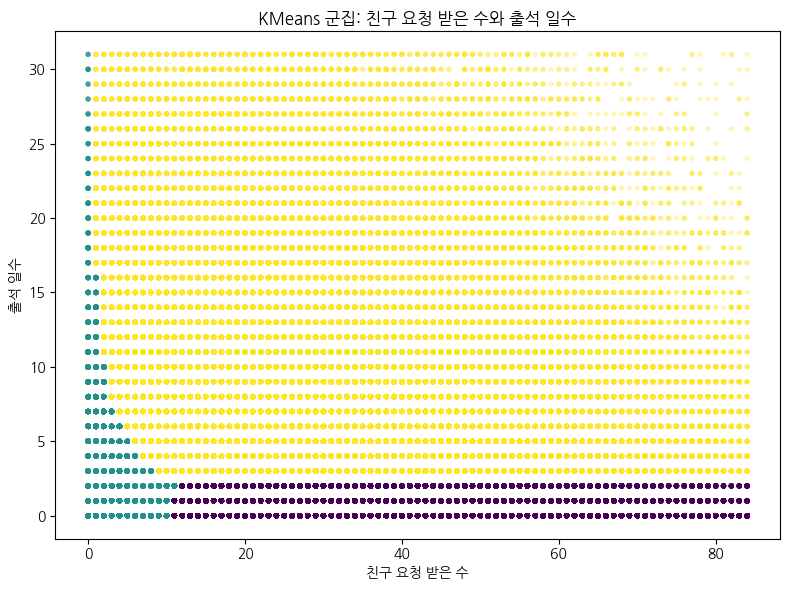

In [ ]:
plot_df = cluster_df.copy()

received_upper = plot_df["received_request_count_raw"].quantile(0.99)
attendance_upper = plot_df["attendance_days_raw"].quantile(0.99)

plot_df = plot_df[
    (plot_df["received_request_count_raw"] <= received_upper)
    & (plot_df["attendance_days_raw"] <= attendance_upper)
].copy()

plt.figure(figsize=(8, 6))

plt.scatter(
    plot_df["received_request_count_raw"],
    plot_df["attendance_days_raw"],
    c=plot_df["cluster"],
    alpha=0.25,
    s=8
)

plt.xlabel("친구 요청 받은 수")
plt.ylabel("출석 일수")
plt.title("KMeans 군집: 친구 요청 받은 수와 출석 일수")
plt.tight_layout()
plt.show()

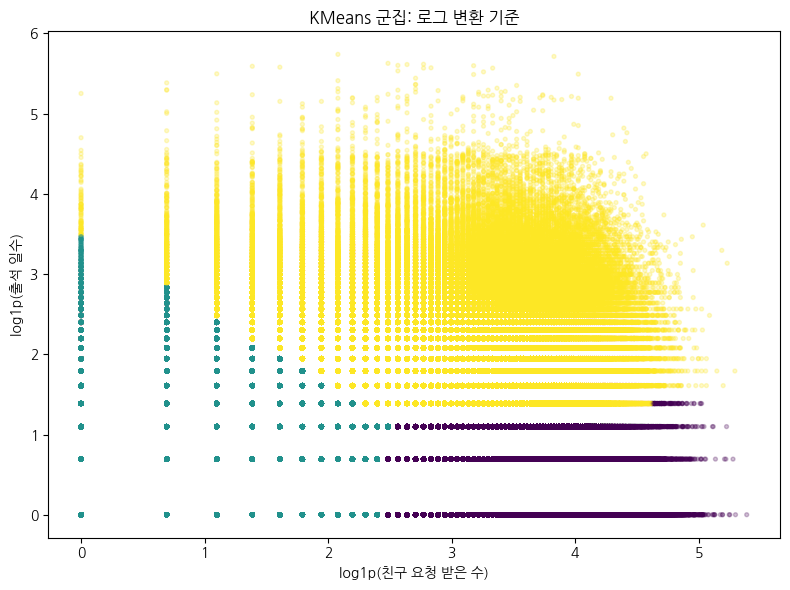

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    cluster_df["log_received_request_count"],
    cluster_df["log_attendance_count"],
    c=cluster_df["cluster"],
    alpha=0.25,
    s=8
)

plt.xlabel("log1p(친구 요청 받은 수)")
plt.ylabel("log1p(출석 일수)")
plt.title("KMeans 군집: 로그 변환 기준")
plt.tight_layout()
plt.show()

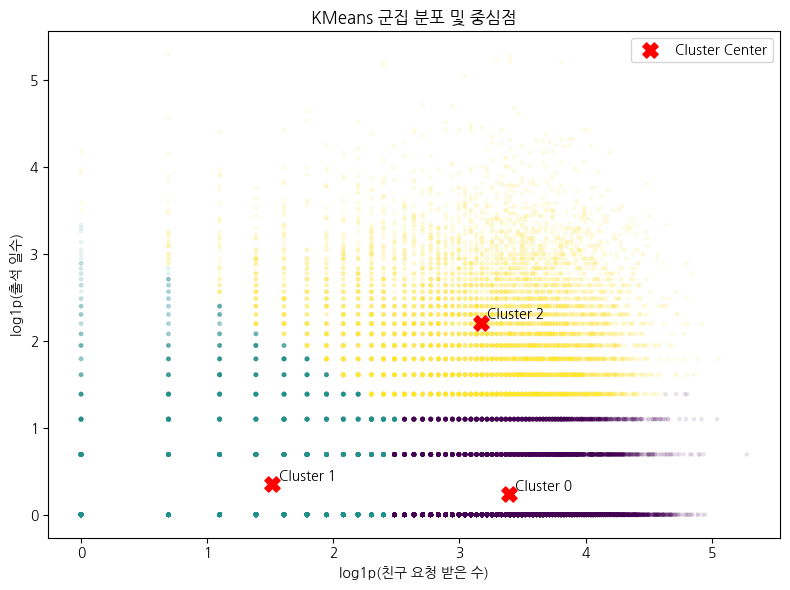

In [ ]:
plot_df = cluster_df.sample(n=30000, random_state=42).copy()

centers = cluster_df.groupby("cluster")[
    ["log_received_request_count", "log_attendance_count"]
].mean().reset_index()

plt.figure(figsize=(8, 6))

plt.scatter(
    plot_df["log_received_request_count"],
    plot_df["log_attendance_count"],
    c=plot_df["cluster"],
    alpha=0.08,
    s=6
)

plt.scatter(
    centers["log_received_request_count"],
    centers["log_attendance_count"],
    c="red",
    s=120,
    marker="X",
    label="Cluster Center"
)

for _, row in centers.iterrows():
    plt.text(
        row["log_received_request_count"] + 0.05,
        row["log_attendance_count"] + 0.05,
        f"Cluster {int(row['cluster'])}",
        fontsize=10
    )

plt.xlabel("log1p(친구 요청 받은 수)")
plt.ylabel("log1p(출석 일수)")
plt.title("KMeans 군집 분포 및 중심점")
plt.legend()
plt.tight_layout()
plt.show()

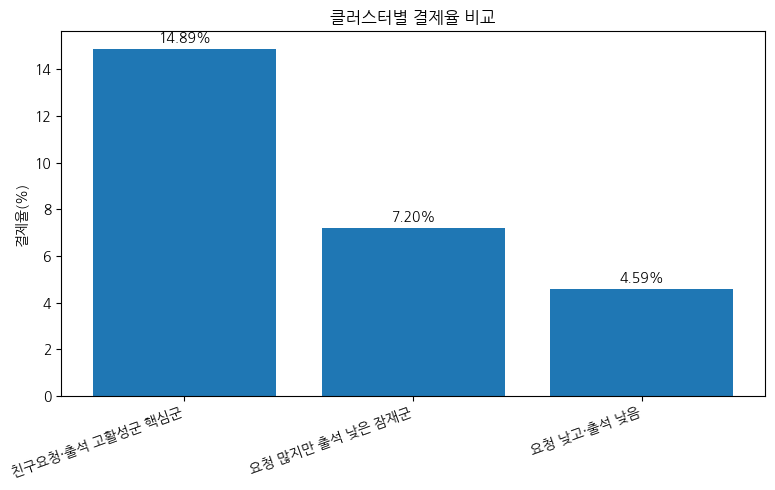

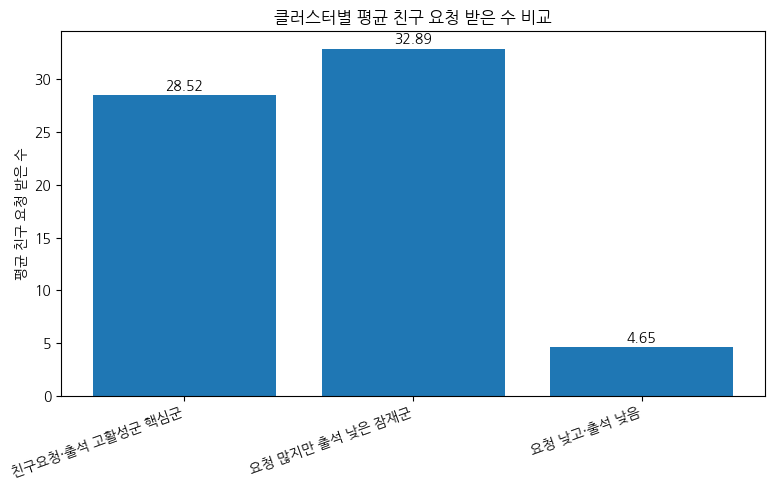

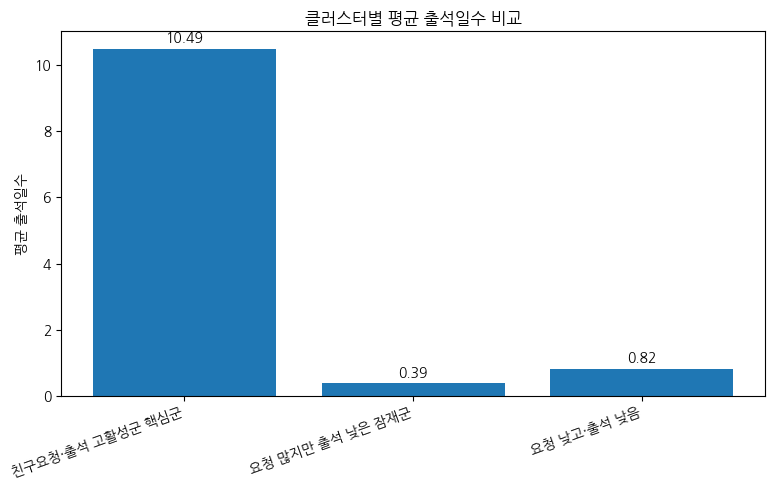

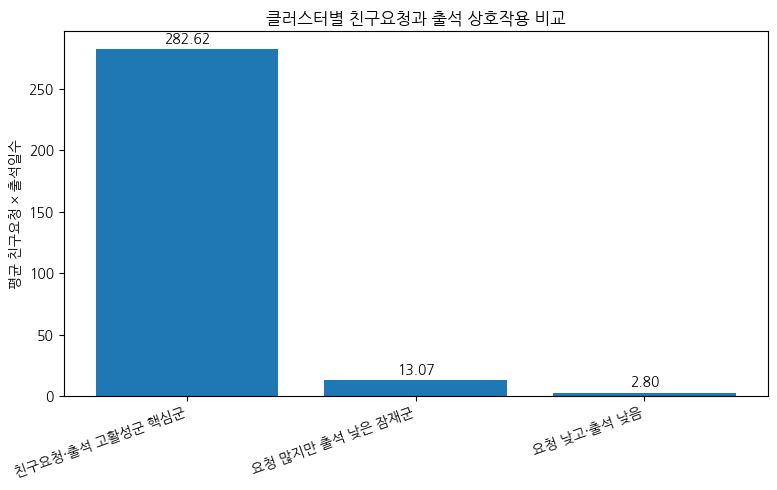

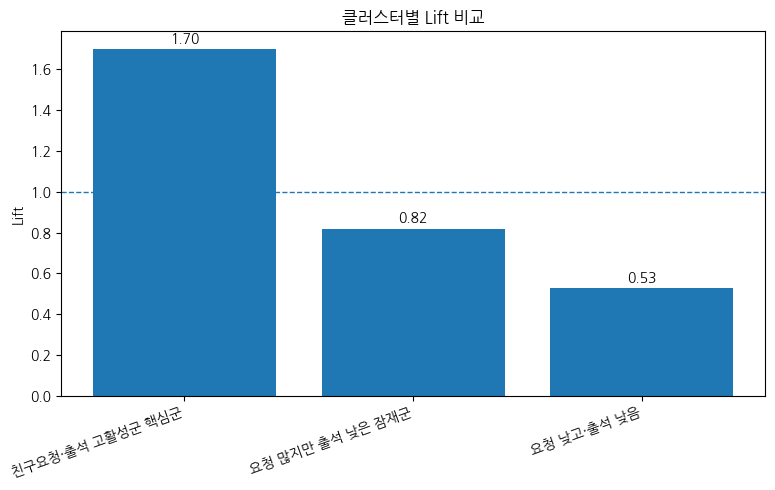

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 클러스터 요약 데이터
cluster_plot_df = pd.DataFrame({
    "cluster_name": [
        "친구요청·출석 고활성군 핵심군",
        "요청 많지만 출석 낮은 잠재군",
        "요청 낮고·출석 낮음"
    ],
    "paid_rate": [14.89, 7.20, 4.59],
    "avg_received_request": [28.52, 32.89, 4.65],
    "avg_attendance_days": [10.49, 0.39, 0.82],
    "avg_received_x_attendance": [282.62, 13.07, 2.80],
    "lift": [1.70, 0.82, 0.53]
})

# 1. 결제율 비교
plt.figure(figsize=(8, 5))
plt.bar(cluster_plot_df["cluster_name"], cluster_plot_df["paid_rate"])
plt.ylabel("결제율(%)")
plt.title("클러스터별 결제율 비교")
plt.xticks(rotation=20, ha="right")

for i, v in enumerate(cluster_plot_df["paid_rate"]):
    plt.text(i, v + 0.3, f"{v:.2f}%", ha="center")

plt.tight_layout()
plt.show()


# 2. 평균 친구 요청 수 비교
plt.figure(figsize=(8, 5))
plt.bar(cluster_plot_df["cluster_name"], cluster_plot_df["avg_received_request"])
plt.ylabel("평균 친구 요청 받은 수")
plt.title("클러스터별 평균 친구 요청 받은 수 비교")
plt.xticks(rotation=20, ha="right")

for i, v in enumerate(cluster_plot_df["avg_received_request"]):
    plt.text(i, v + 0.5, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()


# 3. 평균 출석일수 비교
plt.figure(figsize=(8, 5))
plt.bar(cluster_plot_df["cluster_name"], cluster_plot_df["avg_attendance_days"])
plt.ylabel("평균 출석일수")
plt.title("클러스터별 평균 출석일수 비교")
plt.xticks(rotation=20, ha="right")

for i, v in enumerate(cluster_plot_df["avg_attendance_days"]):
    plt.text(i, v + 0.2, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()


# 4. 평균 친구요청 × 출석일수 비교
plt.figure(figsize=(8, 5))
plt.bar(cluster_plot_df["cluster_name"], cluster_plot_df["avg_received_x_attendance"])
plt.ylabel("평균 친구요청 × 출석일수")
plt.title("클러스터별 친구요청과 출석 상호작용 비교")
plt.xticks(rotation=20, ha="right")

for i, v in enumerate(cluster_plot_df["avg_received_x_attendance"]):
    plt.text(i, v + 5, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()


# 5. Lift 비교
plt.figure(figsize=(8, 5))
plt.bar(cluster_plot_df["cluster_name"], cluster_plot_df["lift"])
plt.axhline(1, linestyle="--", linewidth=1)
plt.ylabel("Lift")
plt.title("클러스터별 Lift 비교")
plt.xticks(rotation=20, ha="right")

for i, v in enumerate(cluster_plot_df["lift"]):
    plt.text(i, v + 0.03, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.show()

In [ ]:
cluster_profile = cluster_summary.copy()

received_median_all = cluster_df["received_request_count_raw"].median()
attendance_median_all = cluster_df["attendance_days_raw"].median()

def assign_cluster_name(row):
    received_level = "수신 높음" if row["median_received_request"] > received_median_all else "수신 낮음"
    attendance_level = "출석 높음" if row["median_attendance_days"] > attendance_median_all else "출석 낮음"
    return f"{received_level}·{attendance_level}군"

cluster_profile["cluster_name"] = cluster_profile.apply(assign_cluster_name, axis=1)

cluster_name_map = dict(zip(
    cluster_profile["cluster"],
    cluster_profile["cluster_name"]
))

cluster_df["cluster_name"] = cluster_df["cluster"].map(cluster_name_map)

cluster_profile[[
    "cluster",
    "cluster_name",
    "user_count",
    "paid_rate",
    "avg_catboost_proba",
    "median_received_request",
    "median_attendance_days",
    "lift"
]]

,cluster,cluster_name,user_count,paid_rate,avg_catboost_proba,median_received_request,median_attendance_days,lift
0,0,수신 높음·출석 낮음군,337244,0.072022,0.432716,29.0,0.0,0.823839
1,1,수신 낮음·출석 낮음군,152354,0.045906,0.300277,4.0,0.0,0.525108
2,2,수신 높음·출석 높음군,187482,0.148862,0.639216,25.0,7.0,1.702792


In [ ]:
cluster_profile_display = cluster_profile.copy()

cluster_profile_display["paid_rate"] = (
    cluster_profile_display["paid_rate"] * 100
).round(2)

cluster_profile_display["avg_catboost_proba"] = (
    cluster_profile_display["avg_catboost_proba"] * 100
).round(2)

cluster_profile_display["lift"] = cluster_profile_display["lift"].round(2)

cluster_profile_display[[
    "cluster",
    "cluster_name",
    "user_count",
    "paid_count",
    "paid_rate",
    "avg_catboost_proba",
    "median_received_request",
    "median_attendance_days",
    "median_received_x_attendance",
    "lift"
]].sort_values("paid_rate", ascending=False)

,cluster,cluster_name,user_count,paid_count,paid_rate,avg_catboost_proba,median_received_request,median_attendance_days,median_received_x_attendance,lift
2,2,수신 높음·출석 높음군,187482,27909,14.89,63.92,25.0,7.0,172.0,1.70
0,0,수신 높음·출석 낮음군,337244,24289,7.20,43.27,29.0,0.0,0.0,0.82
1,1,수신 낮음·출석 낮음군,152354,6994,4.59,30.03,4.0,0.0,0.0,0.53


-----가격 칼럼----

In [ ]:
# 결제 성공 상품 ID 분포
payment_df = payment.copy()

payment_df["productId"].value_counts(dropna=False).sort_index()

productId
heart.1000    19189
heart.200     15722
heart.4000     2130
heart.777     57568
Name: count, dtype: int64

In [ ]:
payment_df.head(5)

,id,productId,phone_type,created_at,user_id
0,20,heart.1000,A,2023-05-13 21:47:04,1000165
1,31,heart.1000,A,2023-05-13 21:56:51,1211364
2,37,heart.1000,A,2023-05-13 22:06:26,1191594
3,41,heart.1000,A,2023-05-13 22:07:39,1088440
4,56,heart.1000,A,2023-05-13 22:21:31,1178580


-------군집별 다른특징 비교-------

In [ ]:
# productId별 가격 매핑
price_map = {
    "heart.200": 900,
    "heart.777": 1900,
    "heart.1000": 2900,
    "heart.4000": 9900
}

payment_df = payment.copy()

payment_df["revenue"] = payment_df["productId"].map(price_map)

# 매핑 안 된 productId 확인
payment_df[payment_df["revenue"].isna()]["productId"].value_counts()

Series([], Name: count, dtype: int64)

In [ ]:
payment_user_summary = payment_df.groupby("user_id").agg(
    purchase_count=("productId", "count"),
    total_revenue=("revenue", "sum"),
    avg_revenue_per_purchase=("revenue", "mean")
).reset_index()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# =====================================================
# 1. KMeans 입력 변수
# =====================================================

cluster_cols = [
    "log_received_request_count",
    "log_attendance_count"
]

X_cluster = X_small[cluster_cols].copy()

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

print("클러스터링 입력 데이터:", X_cluster.shape)

# =====================================================
# 2. k별 결과 확인
# =====================================================

k_results = []

for k in range(2, 8):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_cluster_scaled)
    
    sil = silhouette_score(
        X_cluster_scaled,
        labels,
        sample_size=min(50000, len(X_cluster_scaled)),
        random_state=42
    )
    
    k_results.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette_score": sil
    })

k_result_df = pd.DataFrame(k_results)
display(k_result_df)

# =====================================================
# 3. 최종 KMeans
# =====================================================

final_k = 3

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_cluster_scaled)

# =====================================================
# 4. cluster_df 생성
# =====================================================

cluster_df = X_small.copy()

# ipynb 기준 X_small은 master_df_no_hackle에서 만들어졌으므로 user_id 여기서 가져옴
cluster_df["user_id"] = master_df_no_hackle["user_id"].values

cluster_df["cluster"] = cluster_labels
cluster_df["is_paid"] = y.values

cluster_df["received_request_count_raw"] = np.expm1(
    cluster_df["log_received_request_count"]
).round().astype(int)

cluster_df["attendance_days_raw"] = np.expm1(
    cluster_df["log_attendance_count"]
).round().astype(int)

cluster_df["received_x_attendance_raw"] = np.expm1(
    cluster_df["log_received_x_attendance"]
).round().astype(int)

cat_model = cat_small_result["model"]
cluster_df["catboost_proba"] = cat_model.predict_proba(X_small)[:, 1]

# friend_count도 master_df_no_hackle에 있음
cluster_df["friend_count"] = master_df_no_hackle["friend_count"].values

# =====================================================
# 5. 결제 테이블에서 매출 생성
# =====================================================

price_map = {
    "heart.200": 900,
    "heart.777": 1900,
    "heart.1000": 2900,
    "heart.4000": 9900
}

payment_df = payment.copy()

payment_df["revenue"] = payment_df["productId"].map(price_map)

print("매핑 안 된 productId:")
display(payment_df[payment_df["revenue"].isna()]["productId"].value_counts())

payment_user_summary = payment_df.groupby("user_id").agg(
    purchase_count=("productId", "count"),
    total_revenue=("revenue", "sum"),
    avg_revenue_per_purchase=("revenue", "mean")
).reset_index()

# =====================================================
# 6. cluster_df에 매출 정보 붙이기
# =====================================================

cluster_df = cluster_df.merge(
    payment_user_summary,
    on="user_id",
    how="left"
)

cluster_df[[
    "purchase_count",
    "total_revenue",
    "avg_revenue_per_purchase"
]] = cluster_df[[
    "purchase_count",
    "total_revenue",
    "avg_revenue_per_purchase"
]].fillna(0)

# =====================================================
# 7. 군집 요약표
# =====================================================

cluster_summary = cluster_df.groupby("cluster").agg(
    user_count=("is_paid", "count"),
    paid_count=("is_paid", "sum"),
    paid_rate=("is_paid", "mean"),
    
    avg_catboost_proba=("catboost_proba", "mean"),
    
    total_revenue=("total_revenue", "sum"),
    avg_revenue_per_user=("total_revenue", "mean"),
    avg_revenue_per_paid_user=("total_revenue", lambda x: x[x > 0].mean()),
    avg_purchase_count=("purchase_count", "mean"),
    avg_revenue_per_purchase=("avg_revenue_per_purchase", lambda x: x[x > 0].mean()),
    
    avg_friend_count=("friend_count", "mean"),
    
    avg_received_request=("received_request_count_raw", "mean"),
    median_received_request=("received_request_count_raw", "median"),
    
    avg_attendance_days=("attendance_days_raw", "mean"),
    median_attendance_days=("attendance_days_raw", "median"),
    
    avg_received_x_attendance=("received_x_attendance_raw", "mean"),
    median_received_x_attendance=("received_x_attendance_raw", "median")
).reset_index()

overall_paid_rate = cluster_df["is_paid"].mean()
cluster_summary["lift"] = cluster_summary["paid_rate"] / overall_paid_rate

# =====================================================
# 8. 군집 이름 붙이기
# =====================================================

received_median_all = cluster_df["received_request_count_raw"].median()
attendance_median_all = cluster_df["attendance_days_raw"].median()

def assign_cluster_name(row):
    received_level = "수신 높음" if row["median_received_request"] > received_median_all else "수신 낮음"
    attendance_level = "출석 높음" if row["median_attendance_days"] > attendance_median_all else "출석 낮음"
    return f"{received_level}·{attendance_level}군"

cluster_summary["cluster_name"] = cluster_summary.apply(assign_cluster_name, axis=1)

cluster_name_map = dict(zip(
    cluster_summary["cluster"],
    cluster_summary["cluster_name"]
))

cluster_df["cluster_name"] = cluster_df["cluster"].map(cluster_name_map)

# =====================================================
# 9. 발표용 표
# =====================================================

cluster_summary_display = cluster_summary.copy()

for col in ["paid_rate", "avg_catboost_proba"]:
    cluster_summary_display[col] = (
        cluster_summary_display[col] * 100
    ).round(2)

round_cols = [
    "total_revenue",
    "avg_revenue_per_user",
    "avg_revenue_per_paid_user",
    "avg_purchase_count",
    "avg_revenue_per_purchase",
    "avg_friend_count",
    "avg_received_request",
    "median_received_request",
    "avg_attendance_days",
    "median_attendance_days",
    "avg_received_x_attendance",
    "median_received_x_attendance",
    "lift"
]

for col in round_cols:
    cluster_summary_display[col] = cluster_summary_display[col].round(2)

cluster_summary_display = cluster_summary_display[[
    "cluster",
    "cluster_name",
    "user_count",
    "paid_count",
    "paid_rate",
    "lift",
    "avg_catboost_proba",
    "total_revenue",
    "avg_revenue_per_user",
    "avg_revenue_per_paid_user",
    "avg_purchase_count",
    "avg_revenue_per_purchase",
    "avg_friend_count",
    "avg_received_request",
    "median_received_request",
    "avg_attendance_days",
    "median_attendance_days",
    "avg_received_x_attendance",
    "median_received_x_attendance"
]].sort_values("paid_rate", ascending=False).reset_index(drop=True)

cluster_summary_display

클러스터링 입력 데이터: (677080, 2)


,k,inertia,silhouette_score
0,2,817177.172016,0.424008
1,3,450317.738854,0.466991
2,4,359522.141522,0.418110
3,5,281593.256033,0.400395
4,6,227491.979850,0.422476
5,7,196292.891173,0.396043


매핑 안 된 productId:


Series([], Name: count, dtype: int64)

,cluster,cluster_name,user_count,paid_count,paid_rate,lift,avg_catboost_proba,total_revenue,avg_revenue_per_user,avg_revenue_per_paid_user,avg_purchase_count,avg_revenue_per_purchase,avg_friend_count,avg_received_request,median_received_request,avg_attendance_days,median_attendance_days,avg_received_x_attendance,median_received_x_attendance
0,2,수신 높음·출석 높음군,187482,27909,14.89,1.70,63.92,102216200.0,545.21,3662.48,0.25,2020.31,59.75,28.52,25.0,10.49,7.0,282.62,172.0
1,0,수신 높음·출석 낮음군,337244,24289,7.20,0.82,43.27,77458800.0,229.68,3189.05,0.11,2023.62,62.08,32.89,29.0,0.39,0.0,13.07,0.0
2,1,수신 낮음·출석 낮음군,152354,6994,4.59,0.53,30.03,20589100.0,135.14,2943.82,0.06,2018.17,26.05,4.65,4.0,0.82,0.0,2.80,0.0


In [ ]:
# =====================================================
# k=4 기준 KMeans
# =====================================================

final_k = 4

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_cluster_scaled)

# =====================================================
# cluster_df 생성
# =====================================================

cluster_df = X_small.copy()

cluster_df["user_id"] = master_df_no_hackle["user_id"].values
cluster_df["cluster"] = cluster_labels
cluster_df["is_paid"] = y.values

cluster_df["received_request_count_raw"] = np.expm1(
    cluster_df["log_received_request_count"]
).round().astype(int)

cluster_df["attendance_days_raw"] = np.expm1(
    cluster_df["log_attendance_count"]
).round().astype(int)

cluster_df["received_x_attendance_raw"] = np.expm1(
    cluster_df["log_received_x_attendance"]
).round().astype(int)

cat_model = cat_small_result["model"]
cluster_df["catboost_proba"] = cat_model.predict_proba(X_small)[:, 1]

cluster_df["friend_count"] = master_df_no_hackle["friend_count"].values

# =====================================================
# 매출 생성
# =====================================================

price_map = {
    "heart.200": 900,
    "heart.777": 1900,
    "heart.1000": 2900,
    "heart.4000": 9900
}

payment_df = payment.copy()
payment_df["revenue"] = payment_df["productId"].map(price_map)

print("매핑 안 된 productId:")
display(payment_df[payment_df["revenue"].isna()]["productId"].value_counts())

payment_user_summary = payment_df.groupby("user_id").agg(
    purchase_count=("productId", "count"),
    total_revenue=("revenue", "sum"),
    avg_revenue_per_purchase=("revenue", "mean")
).reset_index()

cluster_df = cluster_df.merge(
    payment_user_summary,
    on="user_id",
    how="left"
)

cluster_df[[
    "purchase_count",
    "total_revenue",
    "avg_revenue_per_purchase"
]] = cluster_df[[
    "purchase_count",
    "total_revenue",
    "avg_revenue_per_purchase"
]].fillna(0)

# =====================================================
# 군집 요약표
# =====================================================

cluster_summary = cluster_df.groupby("cluster").agg(
    user_count=("is_paid", "count"),
    paid_count=("is_paid", "sum"),
    paid_rate=("is_paid", "mean"),
    
    avg_catboost_proba=("catboost_proba", "mean"),
    
    total_revenue=("total_revenue", "sum"),
    avg_revenue_per_user=("total_revenue", "mean"),
    avg_revenue_per_paid_user=("total_revenue", lambda x: x[x > 0].mean()),
    avg_purchase_count=("purchase_count", "mean"),
    avg_revenue_per_purchase=("avg_revenue_per_purchase", lambda x: x[x > 0].mean()),
    
    avg_friend_count=("friend_count", "mean"),
    
    avg_received_request=("received_request_count_raw", "mean"),
    median_received_request=("received_request_count_raw", "median"),
    
    avg_attendance_days=("attendance_days_raw", "mean"),
    median_attendance_days=("attendance_days_raw", "median"),
    
    avg_received_x_attendance=("received_x_attendance_raw", "mean"),
    median_received_x_attendance=("received_x_attendance_raw", "median")
).reset_index()

overall_paid_rate = cluster_df["is_paid"].mean()
cluster_summary["lift"] = cluster_summary["paid_rate"] / overall_paid_rate

# =====================================================
# 군집 이름 붙이기
# =====================================================

received_median_all = cluster_df["received_request_count_raw"].median()
attendance_median_all = cluster_df["attendance_days_raw"].median()

def assign_cluster_name(row):
    received_level = "수신 높음" if row["median_received_request"] > received_median_all else "수신 낮음"
    attendance_level = "출석 높음" if row["median_attendance_days"] > attendance_median_all else "출석 낮음"
    return f"{received_level}·{attendance_level}군"

cluster_summary["cluster_name"] = cluster_summary.apply(assign_cluster_name, axis=1)

cluster_name_map = dict(zip(
    cluster_summary["cluster"],
    cluster_summary["cluster_name"]
))

cluster_df["cluster_name"] = cluster_df["cluster"].map(cluster_name_map)

# =====================================================
# 발표용 표
# =====================================================

cluster_summary_display = cluster_summary.copy()

for col in ["paid_rate", "avg_catboost_proba"]:
    cluster_summary_display[col] = (
        cluster_summary_display[col] * 100
    ).round(2)

round_cols = [
    "total_revenue",
    "avg_revenue_per_user",
    "avg_revenue_per_paid_user",
    "avg_purchase_count",
    "avg_revenue_per_purchase",
    "avg_friend_count",
    "avg_received_request",
    "median_received_request",
    "avg_attendance_days",
    "median_attendance_days",
    "avg_received_x_attendance",
    "median_received_x_attendance",
    "lift"
]

for col in round_cols:
    cluster_summary_display[col] = cluster_summary_display[col].round(2)

cluster_summary_display = cluster_summary_display[[
    "cluster",
    "cluster_name",
    "user_count",
    "paid_count",
    "paid_rate",
    "lift",
    "avg_catboost_proba",
    "total_revenue",
    "avg_revenue_per_user",
    "avg_revenue_per_paid_user",
    "avg_purchase_count",
    "avg_revenue_per_purchase",
    "avg_friend_count",
    "avg_received_request",
    "median_received_request",
    "avg_attendance_days",
    "median_attendance_days",
    "avg_received_x_attendance",
    "median_received_x_attendance"
]].sort_values("paid_rate", ascending=False).reset_index(drop=True)

cluster_summary_display

매핑 안 된 productId:


Series([], Name: count, dtype: int64)

,cluster,cluster_name,user_count,paid_count,paid_rate,lift,avg_catboost_proba,total_revenue,avg_revenue_per_user,avg_revenue_per_paid_user,avg_purchase_count,avg_revenue_per_purchase,avg_friend_count,avg_received_request,median_received_request,avg_attendance_days,median_attendance_days,avg_received_x_attendance,median_received_x_attendance
0,1,수신 높음·출석 높음군,182969,27293,14.92,1.71,63.91,100019800.0,546.65,3664.67,0.25,2020.06,58.94,27.80,25.0,10.63,8.0,285.29,172.0
1,2,수신 높음·출석 낮음군,251936,19499,7.74,0.89,45.38,63207800.0,250.89,3241.59,0.12,2025.61,69.99,39.78,36.0,0.45,0.0,18.86,0.0
2,3,수신 낮음·출석 낮음군,173288,9579,5.53,0.63,35.71,28814100.0,166.28,3008.05,0.08,2021.22,36.10,11.09,11.0,0.36,0.0,3.99,0.0
3,0,수신 낮음·출석 낮음군,68887,2821,4.10,0.47,26.66,8222400.0,119.36,2914.71,0.06,2006.21,20.84,1.70,2.0,1.49,0.0,2.60,0.0


In [ ]:
# ==============================
# 미결제 사용자만
# ==============================

unpaid_cluster = (
    cluster_df[cluster_df["is_paid"] == 0]
    .groupby(["cluster", "cluster_name"])
    .agg(
        user_count=("user_id", "count"),

        avg_attendance_days=("attendance_days_raw", "mean"),
        avg_received_request=("received_request_count_raw", "mean"),
        avg_friend_count=("friend_count", "mean"),

        avg_purchase_count=("purchase_count", "mean"),
        avg_revenue=("total_revenue", "mean")
    )
    .reset_index()
)

# 보기 좋게 반올림
for col in [
    "avg_attendance_days",
    "avg_received_request",
    "avg_friend_count",
    "avg_purchase_count",
    "avg_revenue"
]:
    unpaid_cluster[col] = unpaid_cluster[col].round(2)

unpaid_cluster = unpaid_cluster.rename(columns={
    "cluster_name":"클러스터",
    "user_count":"유저 수",
    "avg_attendance_days":"평균 출석일 수",
    "avg_received_request":"평균 친구 요청 받은 수",
    "avg_friend_count":"평균 친구 수",
    "avg_purchase_count":"평균 구매 횟수",
    "avg_revenue":"평균 매출"
})

unpaid_cluster

,cluster,클러스터,유저 수,평균 출석일 수,평균 친구 요청 받은 수,평균 친구 수,평균 구매 횟수,평균 매출
0,0,수신 낮음·출석 낮음군,66066,1.42,1.68,20.46,0.0,0.0
1,1,수신 높음·출석 높음군,155676,10.53,27.36,58.28,0.0,0.0
2,2,수신 높음·출석 낮음군,232437,0.43,39.63,69.58,0.0,0.0
3,3,수신 낮음·출석 낮음군,163709,0.35,11.06,35.71,0.0,0.0


In [ ]:
# ==============================
# 결제 사용자만
# ==============================

paid_cluster = (
    cluster_df[cluster_df["is_paid"] == 1]
    .groupby(["cluster", "cluster_name"])
    .agg(
        user_count=("user_id", "count"),

        avg_attendance_days=("attendance_days_raw", "mean"),
        avg_received_request=("received_request_count_raw", "mean"),
        avg_friend_count=("friend_count", "mean"),

        avg_revenue=("total_revenue", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_aov=("avg_revenue_per_purchase", "mean")
    )
    .reset_index()
)

for col in [
    "avg_attendance_days",
    "avg_received_request",
    "avg_friend_count",
    "avg_revenue",
    "avg_purchase_count",
    "avg_aov"
]:
    paid_cluster[col] = paid_cluster[col].round(2)

paid_cluster = paid_cluster.rename(columns={
    "cluster_name":"클러스터",
    "user_count":"유저 수",
    "avg_attendance_days":"평균 출석일 수",
    "avg_received_request":"평균 친구 요청 받은 수",
    "avg_friend_count":"평균 친구 수",
    "avg_revenue":"평균 매출",
    "avg_purchase_count":"평균 구매 횟수",
    "avg_aov":"평균 건단가(AOV)"
})

paid_cluster

,cluster,클러스터,유저 수,평균 출석일 수,평균 친구 요청 받은 수,평균 친구 수,평균 매출,평균 구매 횟수,평균 건단가(AOV)
0,0,수신 낮음·출석 낮음군,2821,3.14,2.15,29.81,2914.71,1.42,2006.21
1,1,수신 높음·출석 높음군,27293,11.17,30.34,62.70,3664.67,1.71,2020.06
2,2,수신 높음·출석 낮음군,19499,0.67,41.55,74.80,3241.59,1.55,2025.61
3,3,수신 낮음·출석 낮음군,9579,0.59,11.65,42.63,3008.05,1.44,2021.22


결제 사용자맘ㄴ 에서 포인트와 구매주기 포함

In [ ]:
# =====================================================
# 1. 포인트 사용량 / 획득량 유저별 집계
# =====================================================

point_df = point.copy()

point_user_summary = point_df.groupby("user_id").agg(
    total_point_used=("delta_point", lambda x: x[x < 0].abs().sum()),
    total_point_earned=("delta_point", lambda x: x[x > 0].sum())
).reset_index()

cluster_df = cluster_df.merge(
    point_user_summary,
    on="user_id",
    how="left"
)

cluster_df[["total_point_used", "total_point_earned"]] = (
    cluster_df[["total_point_used", "total_point_earned"]].fillna(0)
)

In [ ]:
# =====================================================
# 2. 평균 구매 주기 계산
# =====================================================

payment_df = payment.copy()

price_map = {
    "heart.200": 900,
    "heart.777": 1900,
    "heart.1000": 2900,
    "heart.4000": 9900
}

payment_df["revenue"] = payment_df["productId"].map(price_map)
payment_df["created_at"] = pd.to_datetime(payment_df["created_at"])

purchase_cycle_user = (
    payment_df
    .sort_values(["user_id", "created_at"])
    .groupby("user_id")
    .agg(
        purchase_count=("productId", "count"),
        first_purchase_at=("created_at", "min"),
        last_purchase_at=("created_at", "max")
    )
    .reset_index()
)

purchase_cycle_user["purchase_period_days"] = (
    purchase_cycle_user["last_purchase_at"] - purchase_cycle_user["first_purchase_at"]
).dt.days

purchase_cycle_user["avg_purchase_cycle_days"] = np.where(
    purchase_cycle_user["purchase_count"] >= 2,
    purchase_cycle_user["purchase_period_days"] / (purchase_cycle_user["purchase_count"] - 1),
    np.nan
)

cluster_df = cluster_df.merge(
    purchase_cycle_user[["user_id", "avg_purchase_cycle_days"]],
    on="user_id",
    how="left"
)

In [ ]:
# ==============================
# 결제 사용자만
# ==============================

paid_cluster = (
    cluster_df[cluster_df["is_paid"] == 1]
    .groupby(["cluster", "cluster_name"])
    .agg(
        user_count=("user_id", "count"),

        avg_attendance_days=("attendance_days_raw", "mean"),
        avg_received_request=("received_request_count_raw", "mean"),
        avg_friend_count=("friend_count", "mean"),

        avg_point_used=("total_point_used", "mean"),
        avg_point_earned=("total_point_earned", "mean"),

        avg_revenue=("total_revenue", "mean"),
        avg_purchase_cycle=("avg_purchase_cycle_days", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_aov=("avg_revenue_per_purchase", "mean")
    )
    .reset_index()
)

for col in [
    "avg_attendance_days",
    "avg_received_request",
    "avg_friend_count",
    "avg_point_used",
    "avg_point_earned",
    "avg_revenue",
    "avg_purchase_cycle",
    "avg_purchase_count",
    "avg_aov"
]:
    paid_cluster[col] = paid_cluster[col].round(2)

paid_cluster = paid_cluster.rename(columns={
    "cluster_name": "클러스터",
    "user_count": "유저 수",
    "avg_attendance_days": "평균 출석일 수",
    "avg_received_request": "평균 친구 요청 받은 수",
    "avg_friend_count": "평균 친구 수",
    "avg_point_used": "평균 포인트 사용량",
    "avg_point_earned": "평균 포인트 얻은량",
    "avg_revenue": "평균 매출",
    "avg_purchase_cycle": "평균 구매 주기",
    "avg_purchase_count": "평균 구매 횟수",
    "avg_aov": "평균 건단가(AOV)"
})

paid_cluster = paid_cluster[[
    "cluster",
    "클러스터",
    "유저 수",
    "평균 출석일 수",
    "평균 친구 요청 받은 수",
    "평균 친구 수",
    "평균 포인트 사용량",
    "평균 포인트 얻은량",
    "평균 매출",
    "평균 구매 주기",
    "평균 구매 횟수",
    "평균 건단가(AOV)"
]]

paid_cluster

,cluster,클러스터,유저 수,평균 출석일 수,평균 친구 요청 받은 수,평균 친구 수,평균 포인트 사용량,평균 포인트 얻은량,평균 매출,평균 구매 주기,평균 구매 횟수,평균 건단가(AOV)
0,0,수신 낮음·출석 낮음군,2821,3.14,2.15,29.81,20.12,16.43,2914.71,6.81,1.42,2006.21
1,1,수신 높음·출석 높음군,27293,11.17,30.34,62.70,60.24,50.09,3664.67,5.82,1.71,2020.06
2,2,수신 높음·출석 낮음군,19499,0.67,41.55,74.80,62.92,51.82,3241.59,4.33,1.55,2025.61
3,3,수신 낮음·출석 낮음군,9579,0.59,11.65,42.63,30.10,23.01,3008.05,4.83,1.44,2021.22


미결제에서 포인트  추가

In [ ]:
# ==============================
# 미결제 사용자만
# ==============================

unpaid_cluster = (
    cluster_df[cluster_df["is_paid"] == 0]
    .groupby(["cluster", "cluster_name"])
    .agg(
        user_count=("user_id", "count"),

        avg_attendance_days=("attendance_days_raw", "mean"),
        avg_received_request=("received_request_count_raw", "mean"),
        avg_friend_count=("friend_count", "mean"),

        avg_point_used=("total_point_used", "mean"),
        avg_point_earned=("total_point_earned", "mean")
    )
    .reset_index()
)

for col in [
    "avg_attendance_days",
    "avg_received_request",
    "avg_friend_count",
    "avg_point_used",
    "avg_point_earned"
]:
    unpaid_cluster[col] = unpaid_cluster[col].round(2)

unpaid_cluster = unpaid_cluster.rename(columns={
    "cluster_name": "클러스터",
    "user_count": "유저 수",
    "avg_attendance_days": "평균 출석일 수",
    "avg_received_request": "평균 친구 요청 받은 수",
    "avg_friend_count": "평균 친구 수",
    "avg_point_used": "평균 포인트 사용량",
    "avg_point_earned": "평균 포인트 얻은량"
})

unpaid_cluster = unpaid_cluster[[
    "cluster",
    "클러스터",
    "유저 수",
    "평균 출석일 수",
    "평균 친구 요청 받은 수",
    "평균 친구 수",
    "평균 포인트 사용량",
    "평균 포인트 얻은량"
]]

cluster_name_manual = {
    0: "저수신·중출석군",
    1: "고수신·고출석군",
    2: "고수신·저출석군",
    3: "중수신·저출석군"
}

unpaid_cluster["클러스터"] = unpaid_cluster["cluster"].map(cluster_name_manual)

unpaid_cluster

,cluster,클러스터,유저 수,평균 출석일 수,평균 친구 요청 받은 수,평균 친구 수,평균 포인트 사용량,평균 포인트 얻은량
0,0,저수신·중출석군,66066,1.42,1.68,20.46,6.32,8.28
1,1,고수신·고출석군,155676,10.53,27.36,58.28,35.07,37.45
2,2,고수신·저출석군,232437,0.43,39.63,69.58,40.42,47.53
3,3,중수신·저출석군,163709,0.35,11.06,35.71,16.13,18.66


SHAP 분석에서 친구 요청 받은 수와 출석 일수의 교호작용 변수가 결제 예측에 가장 중요한 변수로 나타났기 때문에, 두 변수를 기준으로 KMeans 군집분석을 수행하였다. 군집 생성에는 log1p 변환한 친구 요청 받은 수와 출석 일수를 사용하였으며, 군집 수는 k별 실루엣 점수를 비교한 결과 가장 해석 가능성이 높은 k=3으로 설정하였다.

군집분석 결과, 친구 요청 받은 수와 출석 일수가 모두 높은 ‘수신·출석 고활성군’의 결제율은 14.89%로 전체 평균 결제율 8.74% 대비 약 1.70배 높게 나타났다. 반면 친구 요청을 많이 받았지만 출석 일수가 낮은 군집의 결제율은 7.20%로 전체 평균보다 낮았다. 이는 결제 가능성이 단순히 친구 요청을 많이 받은 것만으로 높아지는 것이 아니라, 친구 요청을 받은 유저가 반복적으로 출석하는 행동이 함께 나타날 때 더 높아짐을 의미한다.

## -----의사결정나무 ----

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import koreanize_matplotlib

plt.rcParams["axes.unicode_minus"] = False

# 의사결정나무 입력 변수
tree_cols = [
    "log_received_request_count",
    "log_attendance_count"
]

X_tree = X_small[tree_cols].copy()
y_tree = y.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_tree,
    y_tree,
    test_size=0.2,
    stratify=y_tree,
    random_state=42
)

tree_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=1000,
    class_weight="balanced",
    random_state=42
)

tree_model.fit(X_train, y_train)

proba_tree = tree_model.predict_proba(X_test)[:, 1]
pred_tree = tree_model.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, proba_tree))
print("PR-AUC:", average_precision_score(y_test, proba_tree))
print("Confusion Matrix")
print(confusion_matrix(y_test, pred_tree))
print(classification_report(y_test, pred_tree, zero_division=0))

ROC-AUC: 0.6535025972954391
PR-AUC: 0.13246320271001244
Confusion Matrix
[[68677 54901]
 [ 3679  8159]]
              precision    recall  f1-score   support

           0       0.95      0.56      0.70    123578
           1       0.13      0.69      0.22     11838

    accuracy                           0.57    135416
   macro avg       0.54      0.62      0.46    135416
weighted avg       0.88      0.57      0.66    135416



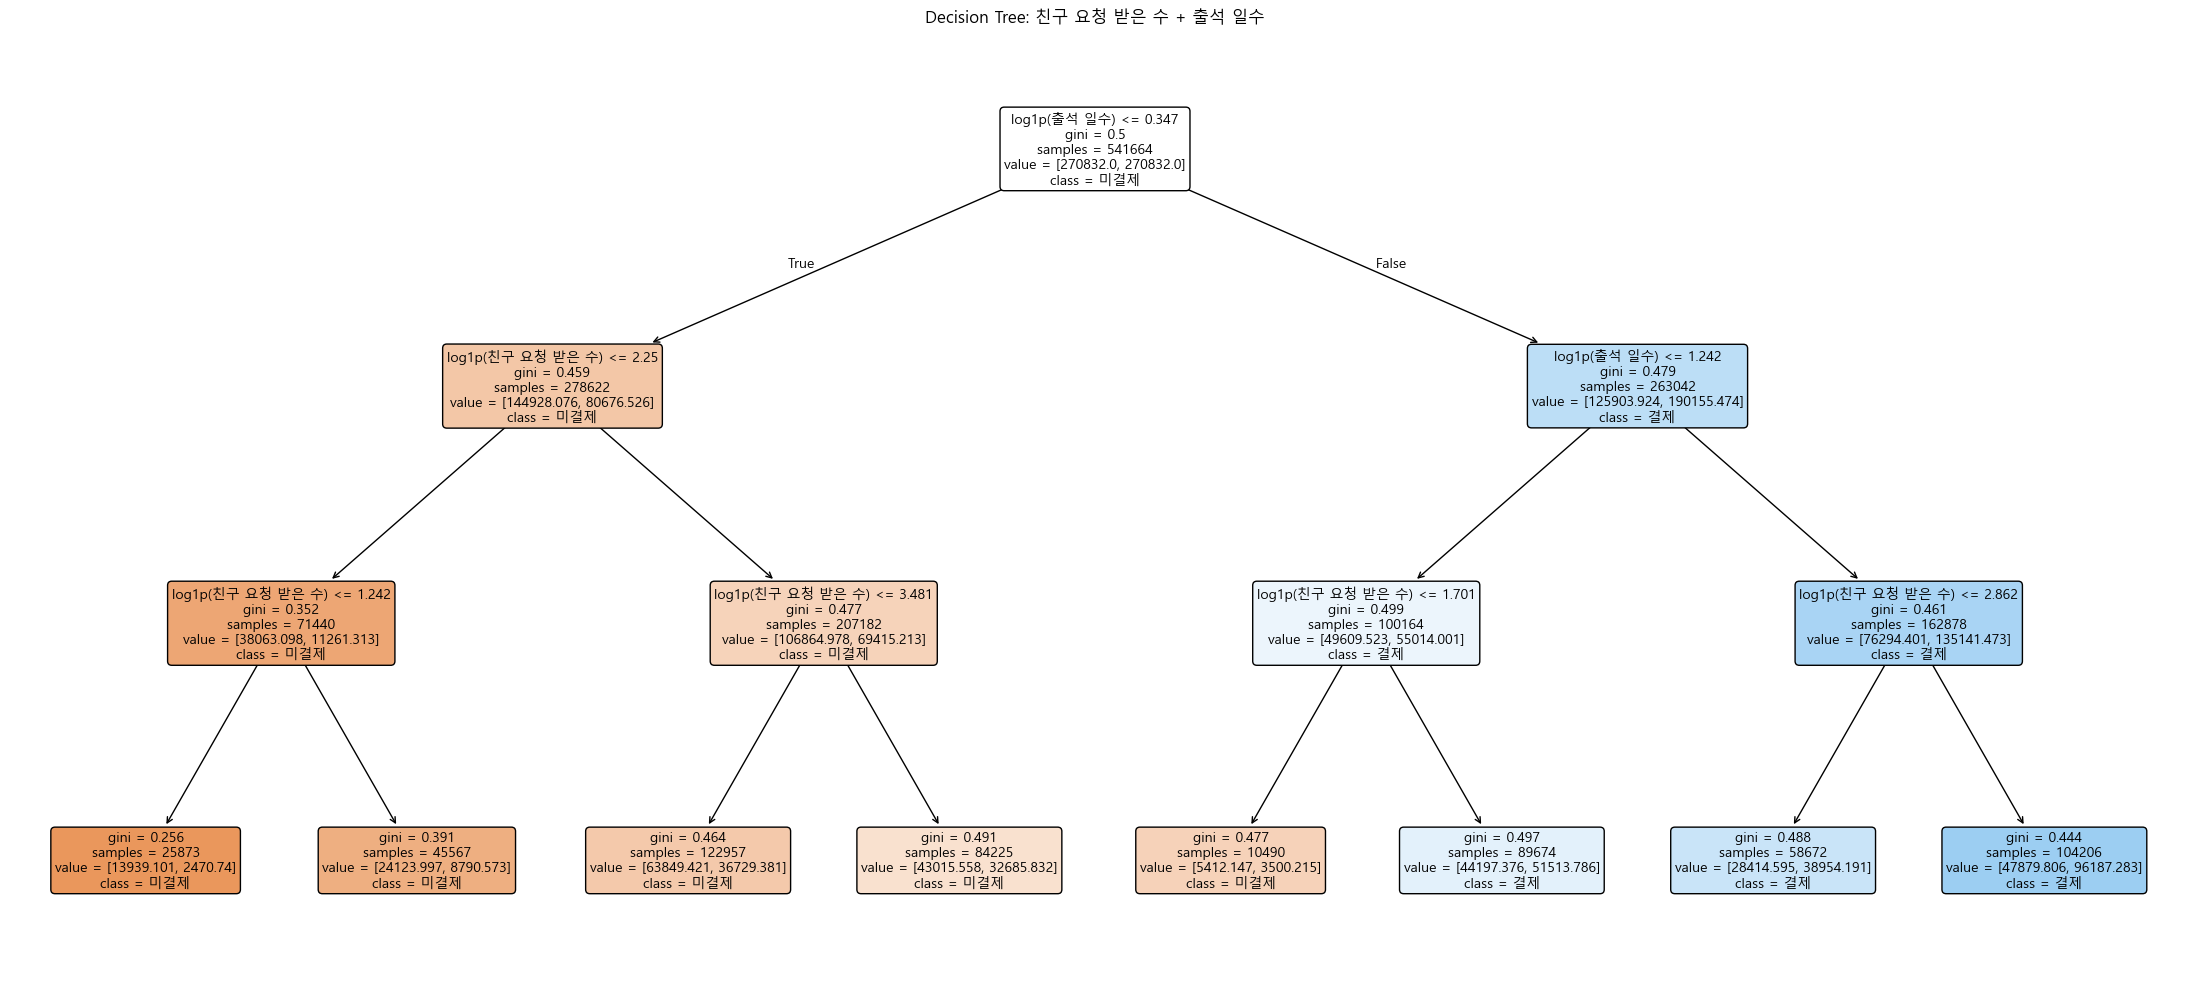

In [ ]:
plt.figure(figsize=(22, 10))

plot_tree(
    tree_model,
    feature_names=[
        "log1p(친구 요청 받은 수)",
        "log1p(출석 일수)"
    ],
    class_names=["미결제", "결제"],
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=False
)

plt.title("Decision Tree: 친구 요청 받은 수 + 출석 일수")
plt.tight_layout()
plt.show()

In [ ]:
tree_rules = export_text(
    tree_model,
    feature_names=[
        "log_received_request_count",
        "log_attendance_count"
    ]
)

print(tree_rules)

|--- log_attendance_count <= 0.35
|   |--- log_received_request_count <= 2.25
|   |   |--- log_received_request_count <= 1.24
|   |   |   |--- class: 0
|   |   |--- log_received_request_count >  1.24
|   |   |   |--- class: 0
|   |--- log_received_request_count >  2.25
|   |   |--- log_received_request_count <= 3.48
|   |   |   |--- class: 0
|   |   |--- log_received_request_count >  3.48
|   |   |   |--- class: 0
|--- log_attendance_count >  0.35
|   |--- log_attendance_count <= 1.24
|   |   |--- log_received_request_count <= 1.70
|   |   |   |--- class: 0
|   |   |--- log_received_request_count >  1.70
|   |   |   |--- class: 1
|   |--- log_attendance_count >  1.24
|   |   |--- log_received_request_count <= 2.86
|   |   |   |--- class: 1
|   |   |--- log_received_request_count >  2.86
|   |   |   |--- class: 1



In [ ]:
tree_ = tree_model.tree_
feature_names = np.array(tree_cols)

threshold_rows = []

for node_id in range(tree_.node_count):
    feature_idx = tree_.feature[node_id]
    threshold = tree_.threshold[node_id]

    # leaf node는 feature_idx == -2
    if feature_idx != -2:
        feature = feature_names[feature_idx]
        raw_threshold = np.expm1(threshold)

        threshold_rows.append({
            "node_id": node_id,
            "feature": feature,
            "threshold_log": threshold,
            "threshold_raw": raw_threshold
        })

tree_threshold_df = pd.DataFrame(threshold_rows)

feature_name_map = {
    "log_received_request_count": "친구 요청 받은 수",
    "log_attendance_count": "출석 일수"
}

tree_threshold_df["feature_kr"] = (
    tree_threshold_df["feature"]
    .map(feature_name_map)
)

tree_threshold_display = tree_threshold_df.copy()
tree_threshold_display["threshold_log"] = tree_threshold_display["threshold_log"].round(4)
tree_threshold_display["threshold_raw"] = tree_threshold_display["threshold_raw"].round(2)

tree_threshold_display[[
    "node_id",
    "feature",
    "feature_kr",
    "threshold_log",
    "threshold_raw"
]]

,node_id,feature,feature_kr,threshold_log,threshold_raw
0,0,log_attendance_count,출석 일수,0.3466,0.41
1,1,log_received_request_count,친구 요청 받은 수,2.2499,8.49
2,2,log_received_request_count,친구 요청 받은 수,1.2425,2.46
3,5,log_received_request_count,친구 요청 받은 수,3.4811,31.50
4,8,log_attendance_count,출석 일수,1.2425,2.46
5,9,log_received_request_count,친구 요청 받은 수,1.7006,4.48
6,12,log_received_request_count,친구 요청 받은 수,2.8618,16.49


In [ ]:
# 전체 데이터 기준으로 leaf 배정
tree_leaf = tree_model.apply(X_tree)

tree_leaf_df = X_tree.copy()
tree_leaf_df["leaf"] = tree_leaf
tree_leaf_df["is_paid"] = y_tree.values

# 원래 단위 복원
tree_leaf_df["received_request_count_raw"] = np.expm1(
    tree_leaf_df["log_received_request_count"]
).round().astype(int)

tree_leaf_df["attendance_days_raw"] = np.expm1(
    tree_leaf_df["log_attendance_count"]
).round().astype(int)

leaf_summary = tree_leaf_df.groupby("leaf").agg(
    user_count=("is_paid", "count"),
    paid_count=("is_paid", "sum"),
    paid_rate=("is_paid", "mean"),
    avg_received_request=("received_request_count_raw", "mean"),
    median_received_request=("received_request_count_raw", "median"),
    avg_attendance_days=("attendance_days_raw", "mean"),
    median_attendance_days=("attendance_days_raw", "median")
).reset_index()

overall_paid_rate = tree_leaf_df["is_paid"].mean()
leaf_summary["lift"] = leaf_summary["paid_rate"] / overall_paid_rate

leaf_summary_display = leaf_summary.copy()

leaf_summary_display["paid_rate"] = (
    leaf_summary_display["paid_rate"] * 100
).round(2)

for col in [
    "avg_received_request",
    "median_received_request",
    "avg_attendance_days",
    "median_attendance_days",
    "lift"
]:
    leaf_summary_display[col] = leaf_summary_display[col].round(2)

leaf_summary_display = leaf_summary_display.sort_values(
    "paid_rate",
    ascending=False
).reset_index(drop=True)

leaf_summary_display

,leaf,user_count,paid_count,paid_rate,avg_received_request,median_received_request,avg_attendance_days,median_attendance_days,lift
0,14,130010,20862,16.05,36.79,33.0,9.92,7.0,1.84
1,13,73421,8546,11.64,8.51,9.0,10.37,7.0,1.33
2,11,112181,11387,10.15,29.63,26.0,1.37,1.0,1.16
3,7,105173,7130,6.78,48.80,45.0,0.00,0.0,0.78
4,10,13080,773,5.91,2.03,2.0,1.35,1.0,0.68
5,6,153852,8022,5.21,18.96,18.0,0.00,0.0,0.60
6,4,57100,1943,3.40,5.42,5.0,0.00,0.0,0.39
7,3,32263,529,1.64,0.96,1.0,0.00,0.0,0.19


In [ ]:
tree_leaf_df["catboost_proba"] = cat_small_result["model"].predict_proba(X_small)[:, 1]

leaf_summary_with_proba = tree_leaf_df.groupby("leaf").agg(
    user_count=("is_paid", "count"),
    paid_count=("is_paid", "sum"),
    paid_rate=("is_paid", "mean"),
    avg_catboost_proba=("catboost_proba", "mean"),
    avg_received_request=("received_request_count_raw", "mean"),
    median_received_request=("received_request_count_raw", "median"),
    avg_attendance_days=("attendance_days_raw", "mean"),
    median_attendance_days=("attendance_days_raw", "median")
).reset_index()

leaf_summary_with_proba["lift"] = (
    leaf_summary_with_proba["paid_rate"] / overall_paid_rate
)

leaf_summary_with_proba_display = leaf_summary_with_proba.copy()

leaf_summary_with_proba_display["paid_rate"] = (
    leaf_summary_with_proba_display["paid_rate"] * 100
).round(2)

leaf_summary_with_proba_display["avg_catboost_proba"] = (
    leaf_summary_with_proba_display["avg_catboost_proba"] * 100
).round(2)

for col in [
    "avg_received_request",
    "median_received_request",
    "avg_attendance_days",
    "median_attendance_days",
    "lift"
]:
    leaf_summary_with_proba_display[col] = (
        leaf_summary_with_proba_display[col].round(2)
    )

leaf_summary_with_proba_display = leaf_summary_with_proba_display.sort_values(
    "paid_rate",
    ascending=False
).reset_index(drop=True)

leaf_summary_with_proba_display

,leaf,user_count,paid_count,paid_rate,avg_catboost_proba,avg_received_request,median_received_request,avg_attendance_days,median_attendance_days,lift
0,14,130010,20862,16.05,66.19,36.79,33.0,9.92,7.0,1.84
1,13,73421,8546,11.64,57.15,8.51,9.0,10.37,7.0,1.33
2,11,112181,11387,10.15,53.06,29.63,26.0,1.37,1.0,1.16
3,7,105173,7130,6.78,42.70,48.80,45.0,0.00,0.0,0.78
4,10,13080,773,5.91,38.08,2.03,2.0,1.35,1.0,0.68
5,6,153852,8022,5.21,35.78,18.96,18.0,0.00,0.0,0.60
6,4,57100,1943,3.40,25.53,5.42,5.0,0.00,0.0,0.39
7,3,32263,529,1.64,13.87,0.96,1.0,0.00,0.0,0.19


In [ ]:
from sklearn.tree import _tree

def get_tree_rules_as_dataframe(tree_model, feature_names):
    tree_ = tree_model.tree_
    feature_names = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]

    paths = []

    def recurse(node, conditions):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_names[node]
            threshold = tree_.threshold[node]

            left_conditions = conditions + [
                {
                    "feature": name,
                    "operator": "<=",
                    "threshold_log": threshold,
                    "threshold_raw": np.expm1(threshold)
                }
            ]
            recurse(tree_.children_left[node], left_conditions)

            right_conditions = conditions + [
                {
                    "feature": name,
                    "operator": ">",
                    "threshold_log": threshold,
                    "threshold_raw": np.expm1(threshold)
                }
            ]
            recurse(tree_.children_right[node], right_conditions)

        else:
            paths.append({
                "leaf": node,
                "conditions": conditions
            })

    recurse(0, [])

    rows = []

    for path in paths:
        condition_texts = []

        for cond in path["conditions"]:
            feature_kr = feature_name_map.get(cond["feature"], cond["feature"])
            raw_value = cond["threshold_raw"]

            if feature_kr == "출석 일수":
                unit = "일"
            else:
                unit = "회"

            condition_texts.append(
                f'{feature_kr} {cond["operator"]} {raw_value:.1f}{unit}'
            )

        rows.append({
            "leaf": path["leaf"],
            "rule": " AND ".join(condition_texts)
        })

    return pd.DataFrame(rows)

tree_rule_df = get_tree_rules_as_dataframe(
    tree_model,
    feature_names=tree_cols
)

tree_rule_df

,leaf,rule
0,3,출석 일수 <= 0.4일 AND 친구 요청 받은 수 <= 8.5회 AND 친구 요청...
1,4,출석 일수 <= 0.4일 AND 친구 요청 받은 수 <= 8.5회 AND 친구 요청...
2,6,출석 일수 <= 0.4일 AND 친구 요청 받은 수 > 8.5회 AND 친구 요청 ...
3,7,출석 일수 <= 0.4일 AND 친구 요청 받은 수 > 8.5회 AND 친구 요청 ...
4,10,출석 일수 > 0.4일 AND 출석 일수 <= 2.5일 AND 친구 요청 받은 수 ...
5,11,출석 일수 > 0.4일 AND 출석 일수 <= 2.5일 AND 친구 요청 받은 수 ...
6,13,출석 일수 > 0.4일 AND 출석 일수 > 2.5일 AND 친구 요청 받은 수 <...
7,14,출석 일수 > 0.4일 AND 출석 일수 > 2.5일 AND 친구 요청 받은 수 >...


In [ ]:
tree_rule_summary = tree_rule_df.merge(
    leaf_summary_with_proba_display,
    on="leaf",
    how="left"
)

tree_rule_summary = tree_rule_summary.sort_values(
    "paid_rate",
    ascending=False
).reset_index(drop=True)

tree_rule_summary

의사결정나무 분석 결과, 결제율이 가장 높은 leaf는 출석 일수가 3일 이상이고 친구 요청 받은 수가 32회 이상인 유저군으로 나타났다. 해당 유저군은 총 130,010명이며, 이 중 결제 유저는 20,862명으로 실제 결제율은 16.05%였다. 이는 전체 평균 결제율 8.74% 대비 약 1.84배 높은 수준이다.

해당 유저군의 친구 요청 받은 수 평균은 36.79회, 중앙값은 33회였으며, 출석 일수 평균은 9.92일, 중앙값은 7일로 나타났다. 따라서 본 분석에서는 친구 요청 받은 수가 약 32회 이상이고 출석 일수가 3일 이상인 유저를 소셜 반응성과 반복 방문 행동이 모두 높은 핵심 결제 가능군으로 해석하였다.

## -----의사결정나무 log x ----

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report
from sklearn.tree import _tree

plt.rcParams["axes.unicode_minus"] = False

# 실제값 기준 데이터
X_tree_raw = pd.DataFrame({
    "received_request_count": np.expm1(X_small["log_received_request_count"]).round().astype(int),
    "attendance_count": np.expm1(X_small["log_attendance_count"]).round().astype(int)
})

y_tree = y.copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_tree_raw,
    y_tree,
    test_size=0.2,
    stratify=y_tree,
    random_state=42
)

tree_model_raw = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=1000,
    class_weight="balanced",
    random_state=42
)

tree_model_raw.fit(X_train_raw, y_train)

proba_raw = tree_model_raw.predict_proba(X_test_raw)[:, 1]
pred_raw = tree_model_raw.predict(X_test_raw)

print("ROC-AUC:", roc_auc_score(y_test, proba_raw))
print("PR-AUC:", average_precision_score(y_test, proba_raw))
print("Confusion Matrix")
print(confusion_matrix(y_test, pred_raw))
print(classification_report(y_test, pred_raw, zero_division=0))

ROC-AUC: 0.6535025972954391
PR-AUC: 0.13246320271001244
Confusion Matrix
[[68677 54901]
 [ 3679  8159]]
              precision    recall  f1-score   support

           0       0.95      0.56      0.70    123578
           1       0.13      0.69      0.22     11838

    accuracy                           0.57    135416
   macro avg       0.54      0.62      0.46    135416
weighted avg       0.88      0.57      0.66    135416



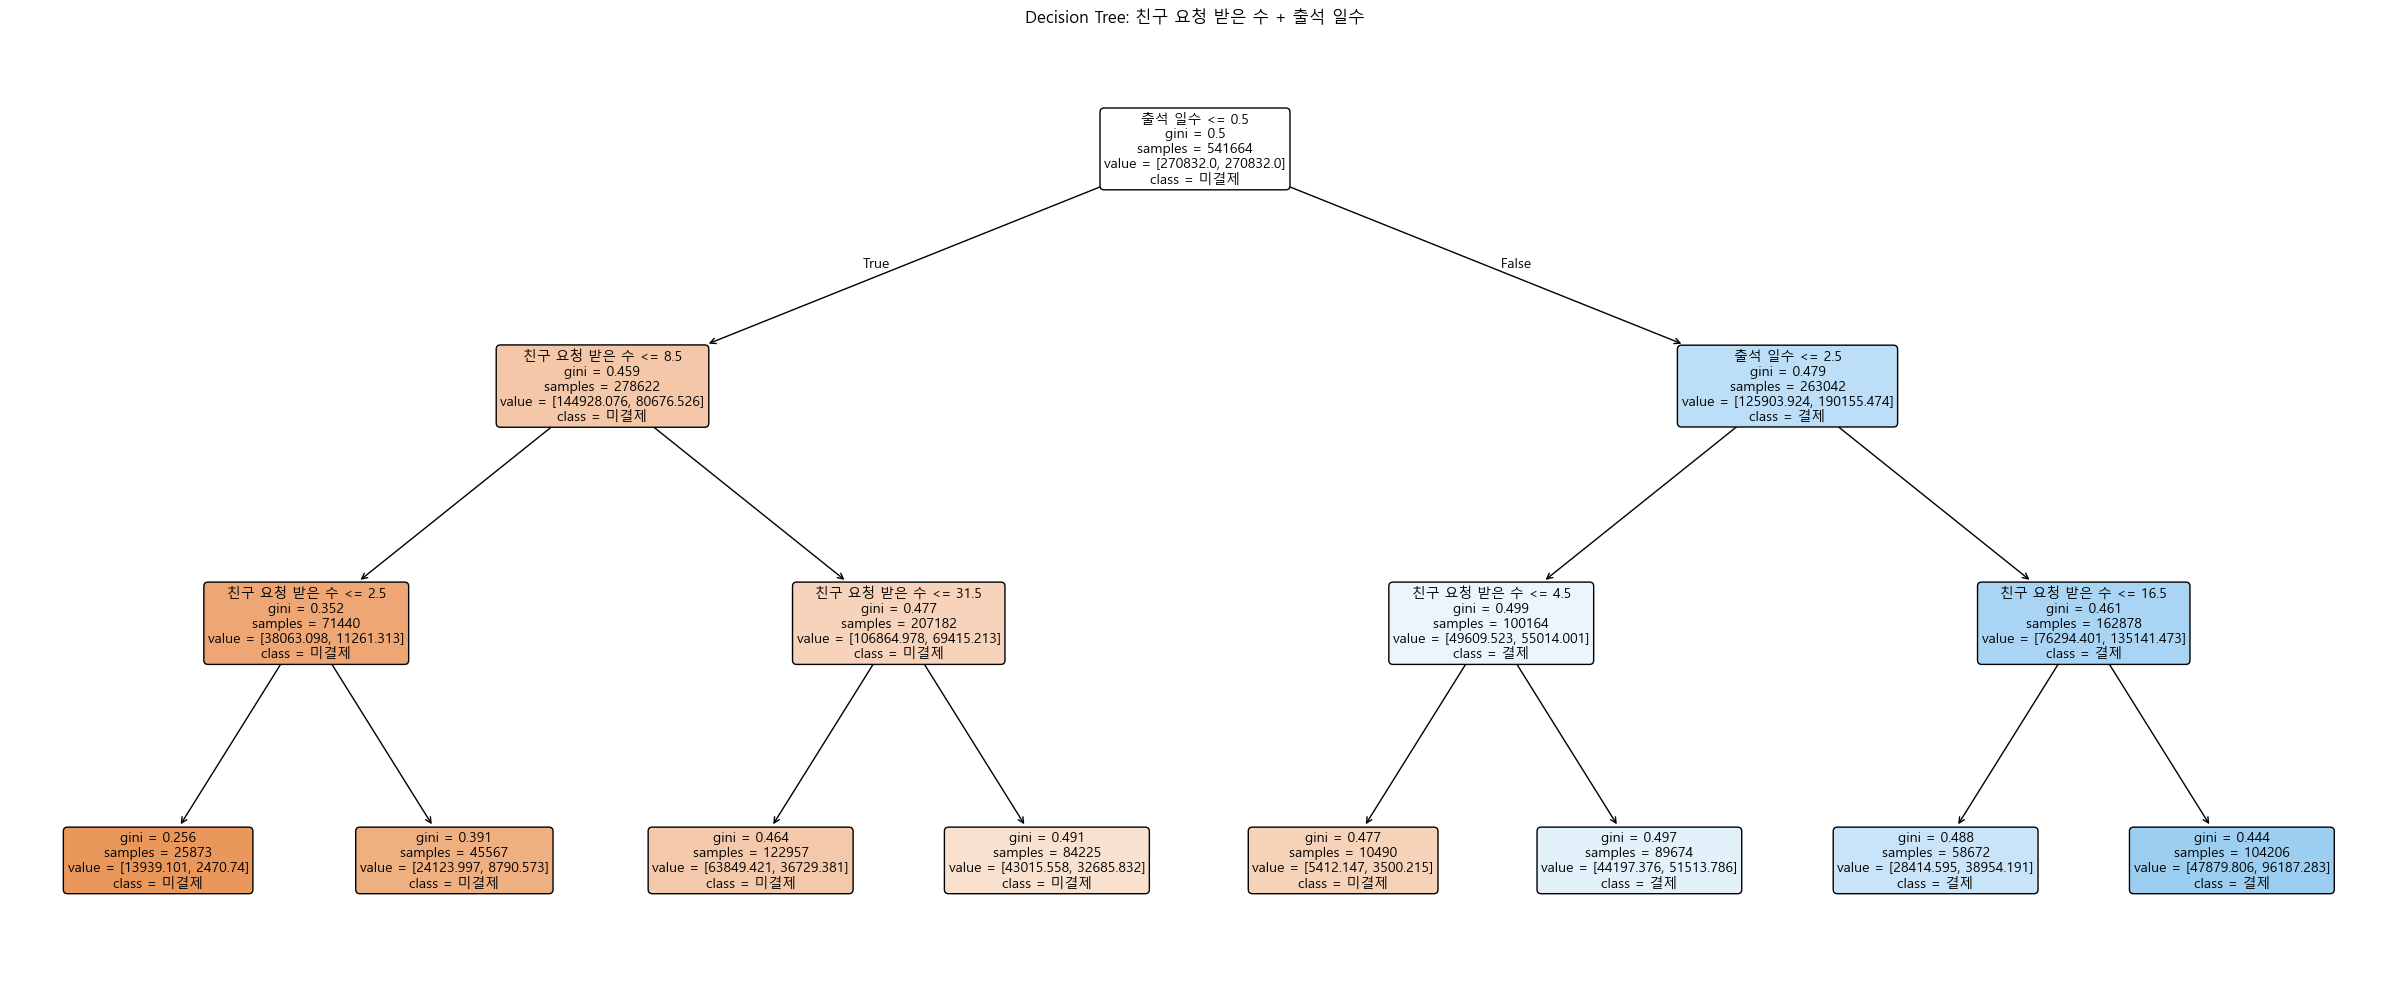

In [ ]:
plt.figure(figsize=(24, 10))

plot_tree(
    tree_model_raw,
    feature_names=["친구 요청 받은 수", "출석 일수"],
    class_names=["미결제", "결제"],
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=False
)

plt.title("Decision Tree: 친구 요청 받은 수 + 출석 일수")
plt.tight_layout()
plt.show()

In [ ]:
def get_tree_rules_as_dataframe_raw(tree_model, feature_names):
    tree_ = tree_model.tree_
    paths = []

    def recurse(node, conditions):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            feature_name = feature_names[tree_.feature[node]]
            threshold = tree_.threshold[node]

            left_conditions = conditions + [
                f"{feature_name} <= {threshold:.1f}"
            ]
            recurse(tree_.children_left[node], left_conditions)

            right_conditions = conditions + [
                f"{feature_name} > {threshold:.1f}"
            ]
            recurse(tree_.children_right[node], right_conditions)

        else:
            paths.append({
                "leaf": node,
                "rule": " AND ".join(conditions)
            })

    recurse(0, [])
    return pd.DataFrame(paths)

tree_rule_df_raw = get_tree_rules_as_dataframe_raw(
    tree_model_raw,
    feature_names=["친구 요청 받은 수", "출석 일수"]
)

pd.set_option("display.max_colwidth", None)

tree_rule_df_raw

,leaf,rule
0,3,출석 일수 <= 0.5 AND 친구 요청 받은 수 <= 8.5 AND 친구 요청 받은 수 <= 2.5
1,4,출석 일수 <= 0.5 AND 친구 요청 받은 수 <= 8.5 AND 친구 요청 받은 수 > 2.5
2,6,출석 일수 <= 0.5 AND 친구 요청 받은 수 > 8.5 AND 친구 요청 받은 수 <= 31.5
3,7,출석 일수 <= 0.5 AND 친구 요청 받은 수 > 8.5 AND 친구 요청 받은 수 > 31.5
4,10,출석 일수 > 0.5 AND 출석 일수 <= 2.5 AND 친구 요청 받은 수 <= 4.5
5,11,출석 일수 > 0.5 AND 출석 일수 <= 2.5 AND 친구 요청 받은 수 > 4.5
6,13,출석 일수 > 0.5 AND 출석 일수 > 2.5 AND 친구 요청 받은 수 <= 16.5
7,14,출석 일수 > 0.5 AND 출석 일수 > 2.5 AND 친구 요청 받은 수 > 16.5


In [ ]:
def convert_rule_to_readable(rule):
    replacements = {
        "출석 일수 <= 0.5": "출석 0일",
        "출석 일수 > 0.5": "출석 1일 이상",
        "출석 일수 <= 2.5": "출석 1~2일",
        "출석 일수 > 2.5": "출석 3일 이상",

        "친구 요청 받은 수 <= 2.5": "친구 요청 받은 수 2회 이하",
        "친구 요청 받은 수 > 2.5": "친구 요청 받은 수 3회 이상",

        "친구 요청 받은 수 <= 4.5": "친구 요청 받은 수 4회 이하",
        "친구 요청 받은 수 > 4.5": "친구 요청 받은 수 5회 이상",

        "친구 요청 받은 수 <= 8.5": "친구 요청 받은 수 8회 이하",
        "친구 요청 받은 수 > 8.5": "친구 요청 받은 수 9회 이상",

        "친구 요청 받은 수 <= 16.5": "친구 요청 받은 수 16회 이하",
        "친구 요청 받은 수 > 16.5": "친구 요청 받은 수 17회 이상",

        "친구 요청 받은 수 <= 31.5": "친구 요청 받은 수 31회 이하",
        "친구 요청 받은 수 > 31.5": "친구 요청 받은 수 32회 이상",
    }

    readable = rule
    for old, new in replacements.items():
        readable = readable.replace(old, new)

    readable = readable.replace(" AND ", " + ")
    return readable

tree_rule_df_raw["rule_readable"] = tree_rule_df_raw["rule"].apply(convert_rule_to_readable)

tree_rule_df_raw

,leaf,rule,rule_readable
0,3,출석 일수 <= 0.5 AND 친구 요청 받은 수 <= 8.5 AND 친구 요청 받은 수 <= 2.5,출석 0일 + 친구 요청 받은 수 8회 이하 + 친구 요청 받은 수 2회 이하
1,4,출석 일수 <= 0.5 AND 친구 요청 받은 수 <= 8.5 AND 친구 요청 받은 수 > 2.5,출석 0일 + 친구 요청 받은 수 8회 이하 + 친구 요청 받은 수 3회 이상
2,6,출석 일수 <= 0.5 AND 친구 요청 받은 수 > 8.5 AND 친구 요청 받은 수 <= 31.5,출석 0일 + 친구 요청 받은 수 9회 이상 + 친구 요청 받은 수 31회 이하
3,7,출석 일수 <= 0.5 AND 친구 요청 받은 수 > 8.5 AND 친구 요청 받은 수 > 31.5,출석 0일 + 친구 요청 받은 수 9회 이상 + 친구 요청 받은 수 32회 이상
4,10,출석 일수 > 0.5 AND 출석 일수 <= 2.5 AND 친구 요청 받은 수 <= 4.5,출석 1일 이상 + 출석 1~2일 + 친구 요청 받은 수 4회 이하
5,11,출석 일수 > 0.5 AND 출석 일수 <= 2.5 AND 친구 요청 받은 수 > 4.5,출석 1일 이상 + 출석 1~2일 + 친구 요청 받은 수 5회 이상
6,13,출석 일수 > 0.5 AND 출석 일수 > 2.5 AND 친구 요청 받은 수 <= 16.5,출석 1일 이상 + 출석 3일 이상 + 친구 요청 받은 수 16회 이하
7,14,출석 일수 > 0.5 AND 출석 일수 > 2.5 AND 친구 요청 받은 수 > 16.5,출석 1일 이상 + 출석 3일 이상 + 친구 요청 받은 수 17회 이상


In [ ]:
def make_leaf_summary(tree_model, X_data, y_data, rule_df, data_name="train"):
    leaf_ids = tree_model.apply(X_data)

    temp = X_data.copy()
    temp["leaf"] = leaf_ids
    temp["is_paid"] = y_data.values

    summary = temp.groupby("leaf").agg(
        user_count=("is_paid", "count"),
        paid_count=("is_paid", "sum"),
        paid_rate=("is_paid", "mean"),

        avg_received_request=("received_request_count", "mean"),
        median_received_request=("received_request_count", "median"),

        avg_attendance_days=("attendance_count", "mean"),
        median_attendance_days=("attendance_count", "median")
    ).reset_index()

    overall_paid_rate = temp["is_paid"].mean()
    summary["lift"] = summary["paid_rate"] / overall_paid_rate

    summary["paid_rate"] = (summary["paid_rate"] * 100).round(2)

    for col in [
        "avg_received_request",
        "median_received_request",
        "avg_attendance_days",
        "median_attendance_days",
        "lift"
    ]:
        summary[col] = summary[col].round(2)

    summary = rule_df.merge(
        summary,
        on="leaf",
        how="left"
    )

    summary["data 기준"] = data_name

    summary = summary.sort_values(
        "paid_rate",
        ascending=False
    ).reset_index(drop=True)

    return summary

leaf_summary_train = make_leaf_summary(
    tree_model=tree_model_raw,
    X_data=X_train_raw,
    y_data=y_train,
    rule_df=tree_rule_df_raw,
    data_name="train"
)

leaf_summary_train

,leaf,rule,rule_readable,user_count,paid_count,paid_rate,avg_received_request,median_received_request,avg_attendance_days,median_attendance_days,lift,data 기준
0,14,출석 일수 > 0.5 AND 출석 일수 > 2.5 AND 친구 요청 받은 수 > 16.5,출석 1일 이상 + 출석 3일 이상 + 친구 요청 받은 수 17회 이상,104206,16818,16.14,36.75,33.0,9.91,7.0,1.85,train
1,13,출석 일수 > 0.5 AND 출석 일수 > 2.5 AND 친구 요청 받은 수 <= 16.5,출석 1일 이상 + 출석 3일 이상 + 친구 요청 받은 수 16회 이하,58672,6811,11.61,8.50,9.0,10.40,7.0,1.33,train
2,11,출석 일수 > 0.5 AND 출석 일수 <= 2.5 AND 친구 요청 받은 수 > 4.5,출석 1일 이상 + 출석 1~2일 + 친구 요청 받은 수 5회 이상,89674,9007,10.04,29.64,26.0,1.37,1.0,1.15,train
3,7,출석 일수 <= 0.5 AND 친구 요청 받은 수 > 8.5 AND 친구 요청 받은 수 > 31.5,출석 0일 + 친구 요청 받은 수 9회 이상 + 친구 요청 받은 수 32회 이상,84225,5715,6.79,48.82,45.0,0.00,0.0,0.78,train
4,10,출석 일수 > 0.5 AND 출석 일수 <= 2.5 AND 친구 요청 받은 수 <= 4.5,출석 1일 이상 + 출석 1~2일 + 친구 요청 받은 수 4회 이하,10490,612,5.83,2.03,2.0,1.35,1.0,0.67,train
5,6,출석 일수 <= 0.5 AND 친구 요청 받은 수 > 8.5 AND 친구 요청 받은 수 <= 31.5,출석 0일 + 친구 요청 받은 수 9회 이상 + 친구 요청 받은 수 31회 이하,122957,6422,5.22,18.94,18.0,0.00,0.0,0.60,train
6,4,출석 일수 <= 0.5 AND 친구 요청 받은 수 <= 8.5 AND 친구 요청 받은 수 > 2.5,출석 0일 + 친구 요청 받은 수 8회 이하 + 친구 요청 받은 수 3회 이상,45567,1537,3.37,5.42,5.0,0.00,0.0,0.39,train
7,3,출석 일수 <= 0.5 AND 친구 요청 받은 수 <= 8.5 AND 친구 요청 받은 수 <= 2.5,출석 0일 + 친구 요청 받은 수 8회 이하 + 친구 요청 받은 수 2회 이하,25873,432,1.67,0.96,1.0,0.00,0.0,0.19,train


In [ ]:
leaf_summary_all = make_leaf_summary(
    tree_model=tree_model_raw,
    X_data=X_tree_raw,
    y_data=y_tree,
    rule_df=tree_rule_df_raw,
    data_name="all"
)

leaf_summary_all

,leaf,rule,rule_readable,user_count,paid_count,paid_rate,avg_received_request,median_received_request,avg_attendance_days,median_attendance_days,lift,data 기준
0,14,출석 일수 > 0.5 AND 출석 일수 > 2.5 AND 친구 요청 받은 수 > 16.5,출석 1일 이상 + 출석 3일 이상 + 친구 요청 받은 수 17회 이상,130010,20862,16.05,36.79,33.0,9.92,7.0,1.84,all
1,13,출석 일수 > 0.5 AND 출석 일수 > 2.5 AND 친구 요청 받은 수 <= 16.5,출석 1일 이상 + 출석 3일 이상 + 친구 요청 받은 수 16회 이하,73421,8546,11.64,8.51,9.0,10.37,7.0,1.33,all
2,11,출석 일수 > 0.5 AND 출석 일수 <= 2.5 AND 친구 요청 받은 수 > 4.5,출석 1일 이상 + 출석 1~2일 + 친구 요청 받은 수 5회 이상,112181,11387,10.15,29.63,26.0,1.37,1.0,1.16,all
3,7,출석 일수 <= 0.5 AND 친구 요청 받은 수 > 8.5 AND 친구 요청 받은 수 > 31.5,출석 0일 + 친구 요청 받은 수 9회 이상 + 친구 요청 받은 수 32회 이상,105173,7130,6.78,48.80,45.0,0.00,0.0,0.78,all
4,10,출석 일수 > 0.5 AND 출석 일수 <= 2.5 AND 친구 요청 받은 수 <= 4.5,출석 1일 이상 + 출석 1~2일 + 친구 요청 받은 수 4회 이하,13080,773,5.91,2.03,2.0,1.35,1.0,0.68,all
5,6,출석 일수 <= 0.5 AND 친구 요청 받은 수 > 8.5 AND 친구 요청 받은 수 <= 31.5,출석 0일 + 친구 요청 받은 수 9회 이상 + 친구 요청 받은 수 31회 이하,153852,8022,5.21,18.96,18.0,0.00,0.0,0.60,all
6,4,출석 일수 <= 0.5 AND 친구 요청 받은 수 <= 8.5 AND 친구 요청 받은 수 > 2.5,출석 0일 + 친구 요청 받은 수 8회 이하 + 친구 요청 받은 수 3회 이상,57100,1943,3.40,5.42,5.0,0.00,0.0,0.39,all
7,3,출석 일수 <= 0.5 AND 친구 요청 받은 수 <= 8.5 AND 친구 요청 받은 수 <= 2.5,출석 0일 + 친구 요청 받은 수 8회 이하 + 친구 요청 받은 수 2회 이하,32263,529,1.64,0.96,1.0,0.00,0.0,0.19,all


In [ ]:
leaf_summary_test = make_leaf_summary(
    tree_model=tree_model_raw,
    X_data=X_test_raw,
    y_data=y_test,
    rule_df=tree_rule_df_raw,
    data_name="test"
)

leaf_summary_test

,leaf,rule,rule_readable,user_count,paid_count,paid_rate,avg_received_request,median_received_request,avg_attendance_days,median_attendance_days,lift,data 기준
0,14,출석 일수 > 0.5 AND 출석 일수 > 2.5 AND 친구 요청 받은 수 > 16.5,출석 1일 이상 + 출석 3일 이상 + 친구 요청 받은 수 17회 이상,25804,4044,15.67,36.93,33.0,9.97,7.0,1.79,test
1,13,출석 일수 > 0.5 AND 출석 일수 > 2.5 AND 친구 요청 받은 수 <= 16.5,출석 1일 이상 + 출석 3일 이상 + 친구 요청 받은 수 16회 이하,14749,1735,11.76,8.55,9.0,10.24,7.0,1.35,test
2,11,출석 일수 > 0.5 AND 출석 일수 <= 2.5 AND 친구 요청 받은 수 > 4.5,출석 1일 이상 + 출석 1~2일 + 친구 요청 받은 수 5회 이상,22507,2380,10.57,29.59,26.0,1.37,1.0,1.21,test
3,7,출석 일수 <= 0.5 AND 친구 요청 받은 수 > 8.5 AND 친구 요청 받은 수 > 31.5,출석 0일 + 친구 요청 받은 수 9회 이상 + 친구 요청 받은 수 32회 이상,20948,1415,6.75,48.72,45.0,0.00,0.0,0.77,test
4,10,출석 일수 > 0.5 AND 출석 일수 <= 2.5 AND 친구 요청 받은 수 <= 4.5,출석 1일 이상 + 출석 1~2일 + 친구 요청 받은 수 4회 이하,2590,161,6.22,2.04,2.0,1.35,1.0,0.71,test
5,6,출석 일수 <= 0.5 AND 친구 요청 받은 수 > 8.5 AND 친구 요청 받은 수 <= 31.5,출석 0일 + 친구 요청 받은 수 9회 이상 + 친구 요청 받은 수 31회 이하,30895,1600,5.18,19.02,19.0,0.00,0.0,0.59,test
6,4,출석 일수 <= 0.5 AND 친구 요청 받은 수 <= 8.5 AND 친구 요청 받은 수 > 2.5,출석 0일 + 친구 요청 받은 수 8회 이하 + 친구 요청 받은 수 3회 이상,11533,406,3.52,5.42,5.0,0.00,0.0,0.40,test
7,3,출석 일수 <= 0.5 AND 친구 요청 받은 수 <= 8.5 AND 친구 요청 받은 수 <= 2.5,출석 0일 + 친구 요청 받은 수 8회 이하 + 친구 요청 받은 수 2회 이하,6390,97,1.52,0.95,1.0,0.00,0.0,0.17,test


## -------eda------

In [ ]:
import pandas as pd
import numpy as np

received_dist = master_df_no_hackle[["user_id", "received_request_count", "is_paid"]].copy()

received_dist["received_request_count"] = (
    received_dist["received_request_count"]
    .fillna(0)
    .round()
    .astype(int)
)

# 기본 통계
received_dist["received_request_count"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999]
)

count    677080.00000
mean         25.32509
std          19.63998
min           0.00000
25%          10.00000
50%          21.00000
75%          37.00000
90%          52.00000
95%          63.00000
99%          84.00000
99.9%       114.00000
max         218.00000
Name: received_request_count, dtype: float64

In [ ]:
received_count_summary = received_dist.groupby("received_request_count").agg(
    user_count=("user_id", "count"),
    paid_count=("is_paid", "sum"),
    paid_rate=("is_paid", "mean")
).reset_index()

received_count_summary["user_ratio_percent"] = (
    received_count_summary["user_count"] / len(received_dist) * 100
).round(2)

received_count_summary["paid_rate_percent"] = (
    received_count_summary["paid_rate"] * 100
).round(2)

received_count_summary = received_count_summary.sort_values(
    "received_request_count"
).reset_index(drop=True)

received_count_summary.head(50)

,received_request_count,user_count,paid_count,paid_rate,user_ratio_percent,paid_rate_percent
0,0,16239,365,0.022477,2.40,2.25
1,1,16255,629,0.038696,2.40,3.87
2,2,16537,767,0.046381,2.44,4.64
3,3,17064,909,0.053270,2.52,5.33
4,4,17097,998,0.058373,2.53,5.84
5,5,16881,1045,0.061904,2.49,6.19
6,6,16711,1089,0.065167,2.47,6.52
7,7,16517,1150,0.069625,2.44,6.96
8,8,16384,1141,0.069641,2.42,6.96
9,9,15844,1164,0.073466,2.34,7.35


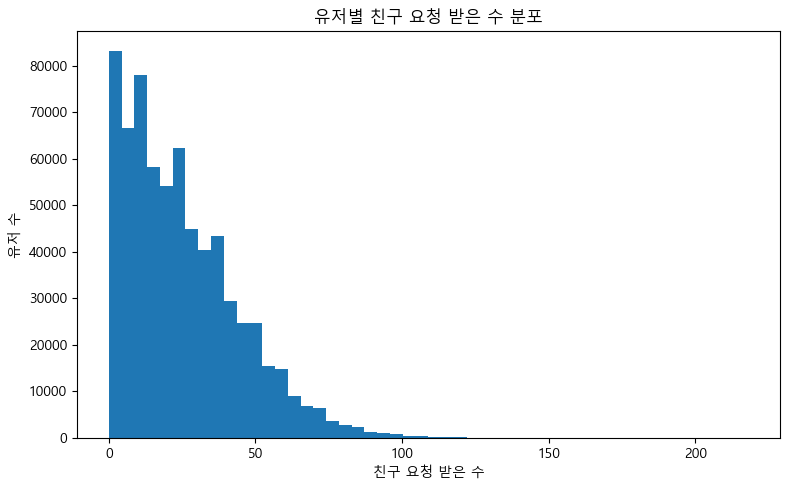

In [ ]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(8, 5))
plt.hist(
    received_dist["received_request_count"],
    bins=50
)
plt.xlabel("친구 요청 받은 수")
plt.ylabel("유저 수")
plt.title("유저별 친구 요청 받은 수 분포")
plt.tight_layout()
plt.show()

## --------------aha moment 다시찾기 ------------------

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

plt.rcParams["axes.unicode_minus"] = False


# =========================
# 0. 기본 설정
# =========================

df = master_df_no_hackle.copy()
target = "is_paid"

plot_config = {
    "friend_count": {
        "label": "친구 수",
        "unit": "명",
        "graph_max": 40
    },
    "attendance_count": {
        "label": "출석일 수",
        "unit": "일",
        "graph_max": 30
    },
    "received_request_count": {
        "label": "친구 요청 받은 수",
        "unit": "회",
        "graph_max": 30
    },
    "sent_request_count": {
        "label": "친구 요청 보낸 수",
        "unit": "회",
        "graph_max": 30
    },
    "vote_given_count": {
        "label": "질문 응답 수",
        "unit": "회",
        "graph_max": 30
    },
    "vote_received_count": {
        "label": "선택 받은 수",
        "unit": "회",
        "graph_max": 30
    },
    "question_open_count": {
        "label": "질문 열람 수",
        "unit": "회",
        "graph_max": 30
    }
}

In [ ]:
# =========================
# 1. 변수별 min / max / 분위수 확인
# =========================

range_summary = []

for col, info in plot_config.items():
    if col not in df.columns:
        print(f"컬럼 없음: {col}")
        continue

    s = df[col].fillna(0)

    range_summary.append({
        "변수명": col,
        "변수명_한글": info["label"],
        "단위": info["unit"],
        "min": s.min(),
        "q25": s.quantile(0.25),
        "median": s.quantile(0.50),
        "q75": s.quantile(0.75),
        "q90": s.quantile(0.90),
        "q95": s.quantile(0.95),
        "q99": s.quantile(0.99),
        "max": s.max(),
        "고유값수": s.nunique()
    })

range_summary_df = pd.DataFrame(range_summary)
range_summary_df

,변수명,변수명_한글,단위,min,q25,median,q75,q90,q95,q99,max,고유값수
0,friend_count,친구 수,명,0.0,31.0,49.0,70.0,94.0,111.0,152.0,1373.0,410
1,attendance_count,출석일 수,일,0.0,0.0,0.0,4.0,10.0,15.0,31.0,310.0,209
2,received_request_count,친구 요청 받은 수,회,0.0,10.0,21.0,37.0,52.0,63.0,84.0,218.0,181
3,sent_request_count,친구 요청 보낸 수,회,0.0,10.0,20.0,34.0,52.0,67.0,107.0,1816.0,401
4,vote_given_count,질문 응답 수,회,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2786.0,845
5,vote_received_count,선택 받은 수,회,0.0,0.0,0.0,0.0,0.0,0.0,22.0,1239.0,679
6,question_open_count,질문 열람 수,회,0.0,0.0,0.0,0.0,0.0,0.0,0.0,174.0,123


In [ ]:
# =========================
# 2. 변수별 전체 횟수 기준 결제율 표 생성
# =========================

def make_exact_count_summary(df, col, col_label, unit, target="is_paid"):
    temp = df[["user_id", col, target]].copy()

    temp[col] = temp[col].fillna(0)
    temp[col] = np.floor(temp[col]).astype(int)

    summary = (
        temp.groupby(col)
        .agg(
            user_count=("user_id", "count"),
            paid_count=(target, "sum"),
            paid_rate=(target, "mean")
        )
        .reset_index()
        .rename(columns={col: "count_value"})
        .sort_values("count_value")
        .reset_index(drop=True)
    )

    summary["paid_rate_percent"] = (summary["paid_rate"] * 100).round(2)
    summary["변수명"] = col
    summary["변수명_한글"] = col_label
    summary["단위"] = unit
    summary["구간"] = summary["count_value"].astype(str) + unit

    summary = summary[
        [
            "변수명",
            "변수명_한글",
            "count_value",
            "구간",
            "user_count",
            "paid_count",
            "paid_rate_percent",
            "단위"
        ]
    ]

    return summary


exact_summary_dict = {}
exact_summary_all = []

for col, info in plot_config.items():
    if col in df.columns:
        summary = make_exact_count_summary(
            df=df,
            col=col,
            col_label=info["label"],
            unit=info["unit"],
            target=target
        )

        exact_summary_dict[col] = summary
        exact_summary_all.append(summary)

exact_summary_all = pd.concat(exact_summary_all, ignore_index=True)
exact_summary_all

,변수명,변수명_한글,count_value,구간,user_count,paid_count,paid_rate_percent,단위
0,friend_count,친구 수,0,0명,2870,24,0.84,명
1,friend_count,친구 수,1,1명,2239,17,0.76,명
2,friend_count,친구 수,2,2명,2395,22,0.92,명
3,friend_count,친구 수,3,3명,2647,25,0.94,명
4,friend_count,친구 수,4,4명,2977,44,1.48,명
...,...,...,...,...,...,...,...,...
2843,question_open_count,질문 열람 수,150,150회,1,0,0.00,회
2844,question_open_count,질문 열람 수,156,156회,2,0,0.00,회
2845,question_open_count,질문 열람 수,157,157회,1,0,0.00,회
2846,question_open_count,질문 열람 수,165,165회,1,0,0.00,회


In [ ]:
# =========================
# 3. 초반 구간 그래프 함수
# =========================

def plot_early_paid_rate(
    summary_df,
    max_count_value=30,
    min_user_count=100
):
    plot_df = summary_df[
        (summary_df["count_value"] <= max_count_value) &
        (summary_df["user_count"] >= min_user_count)
    ].copy()

    plot_df = plot_df.sort_values("count_value").reset_index(drop=True)

    col_label = plot_df["변수명_한글"].iloc[0]
    unit = plot_df["단위"].iloc[0]

    x_pos = range(len(plot_df))
    x_label = plot_df["구간"]
    y = plot_df["paid_rate_percent"]

    plt.figure(figsize=(16, 5))
    plt.plot(x_pos, y, marker="o", linewidth=2)

    y_range = y.max() - y.min()
    offset = max(y_range * 0.04, 0.2)

    for i, v in enumerate(y):
        plt.text(
            i,
            v + offset,
            f"{v:.2f}%",
            ha="center",
            fontsize=8
        )

    plt.title(
        f"{col_label} 구간별 결제 전환율 추이 "
        f"| {max_count_value}{unit} 이하, 유저 수 {min_user_count}명 이상"
    )
    plt.xlabel(f"{col_label} ({unit})")
    plt.ylabel("결제 전환율 (%)")
    plt.grid(True, linestyle="--", alpha=0.4)

    plt.xticks(
        ticks=list(x_pos),
        labels=x_label,
        rotation=45,
        ha="right"
    )

    plt.ylim(0, y.max() + offset * 5)
    plt.tight_layout()
    plt.show()

    return plot_df

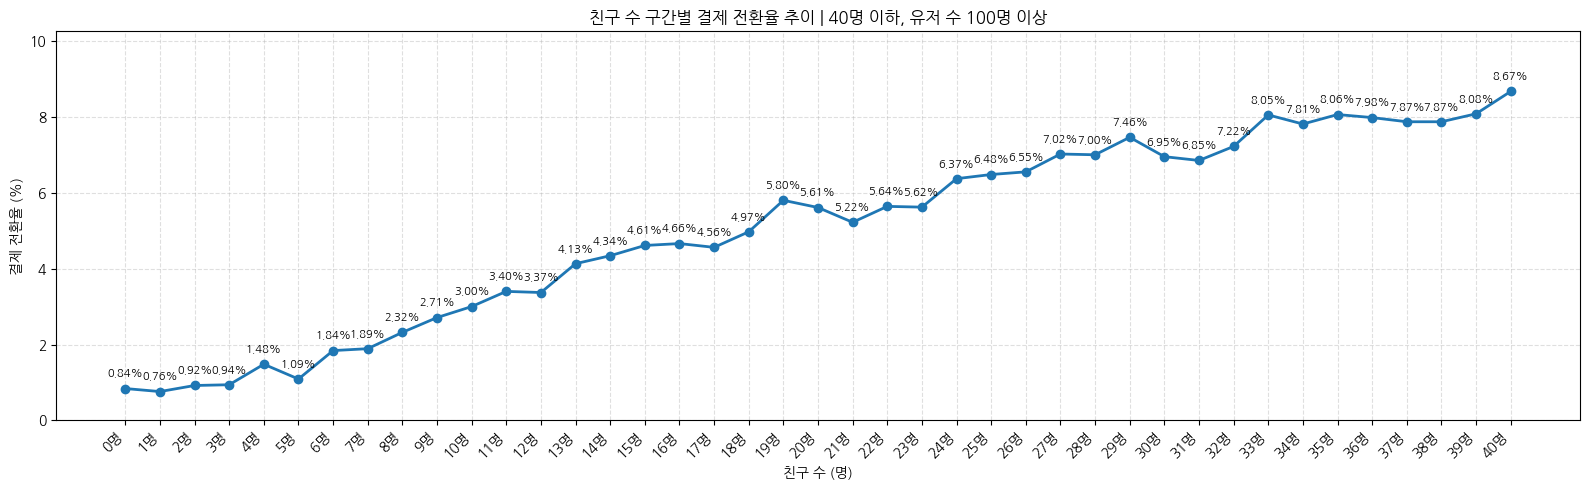

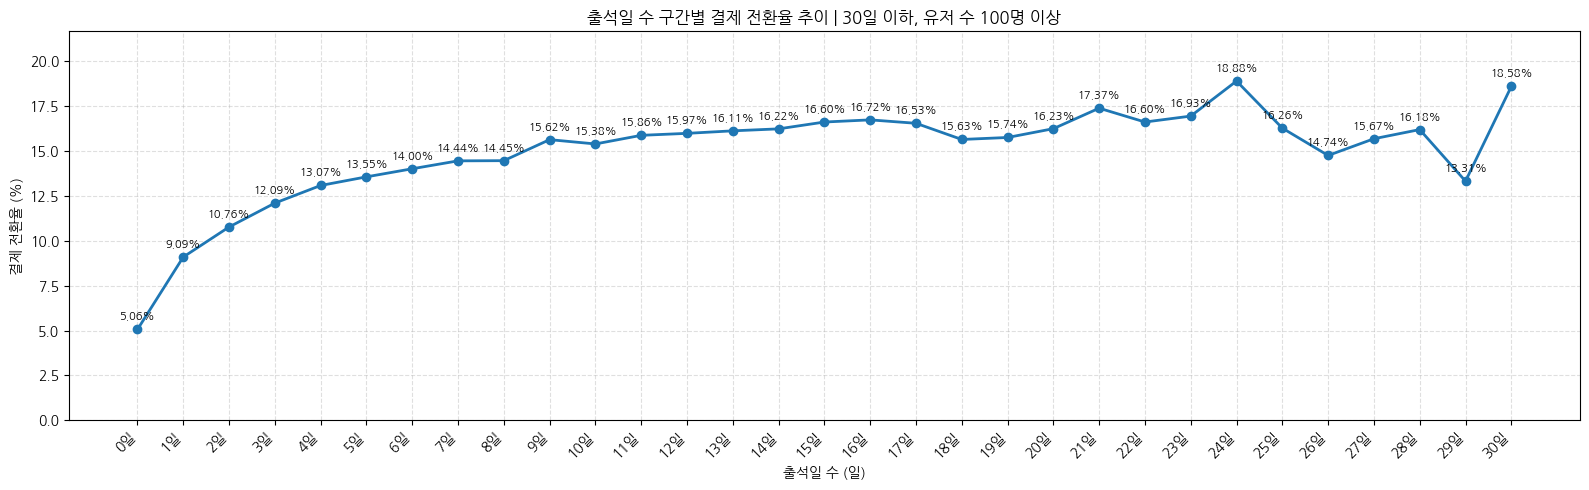

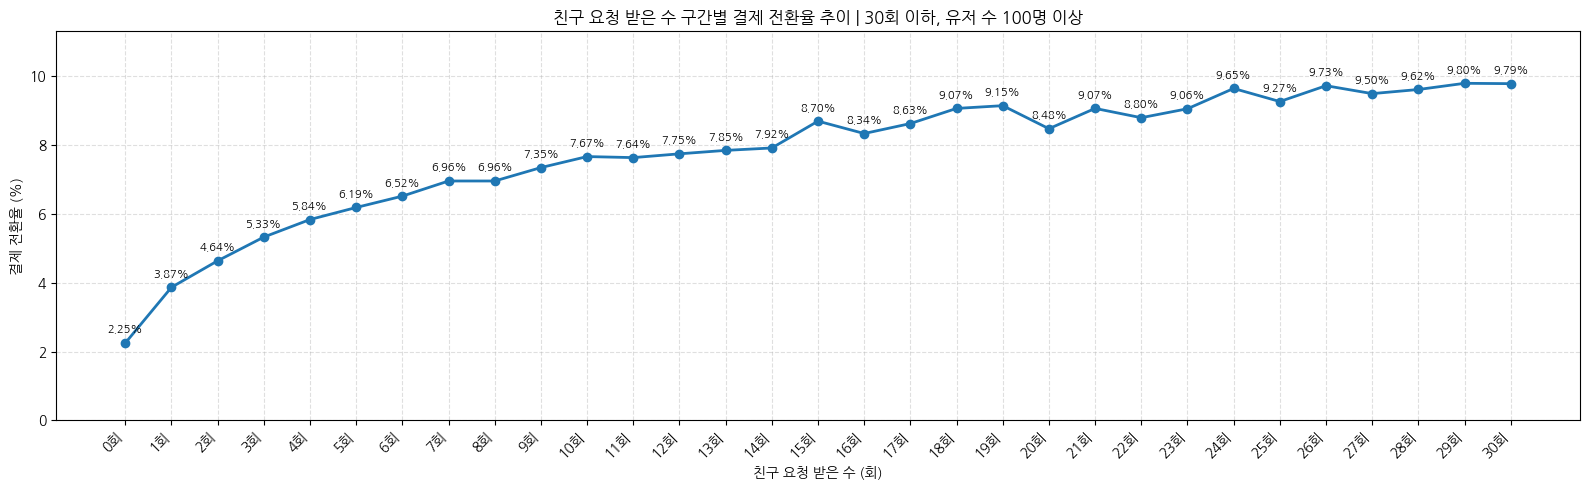

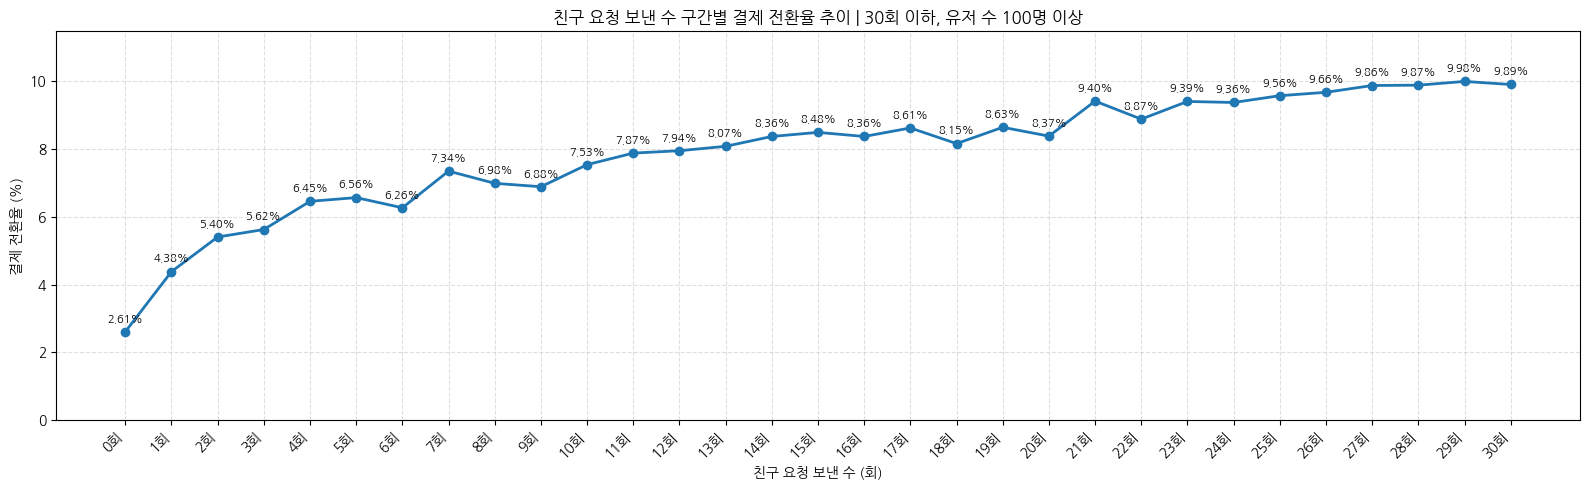

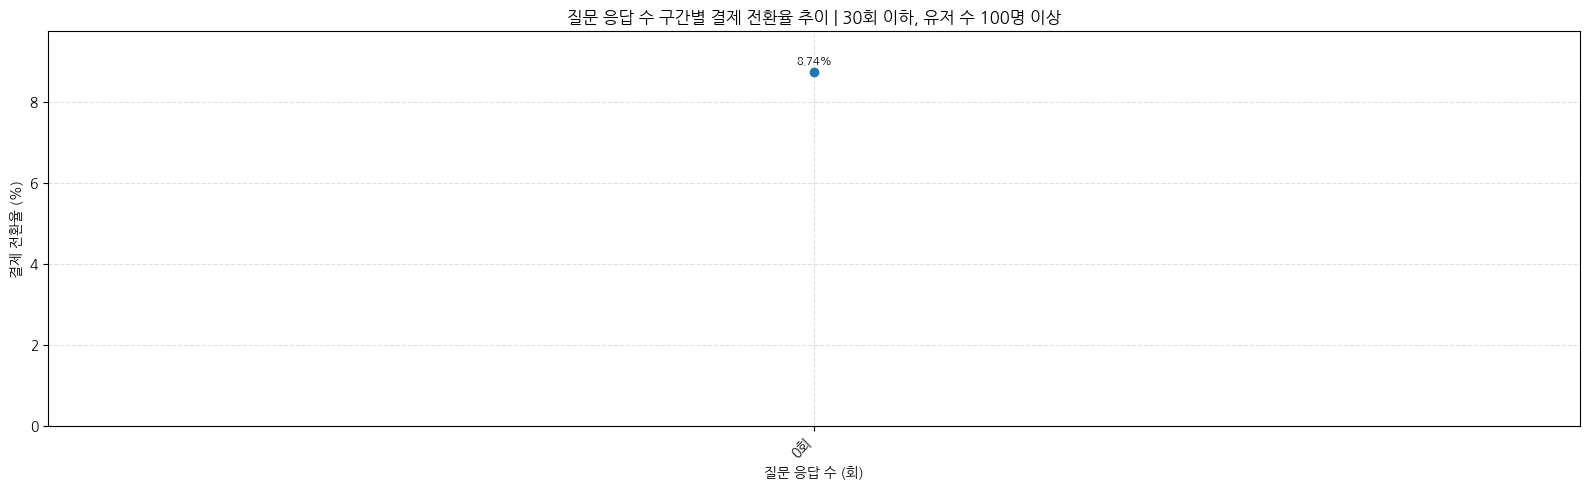

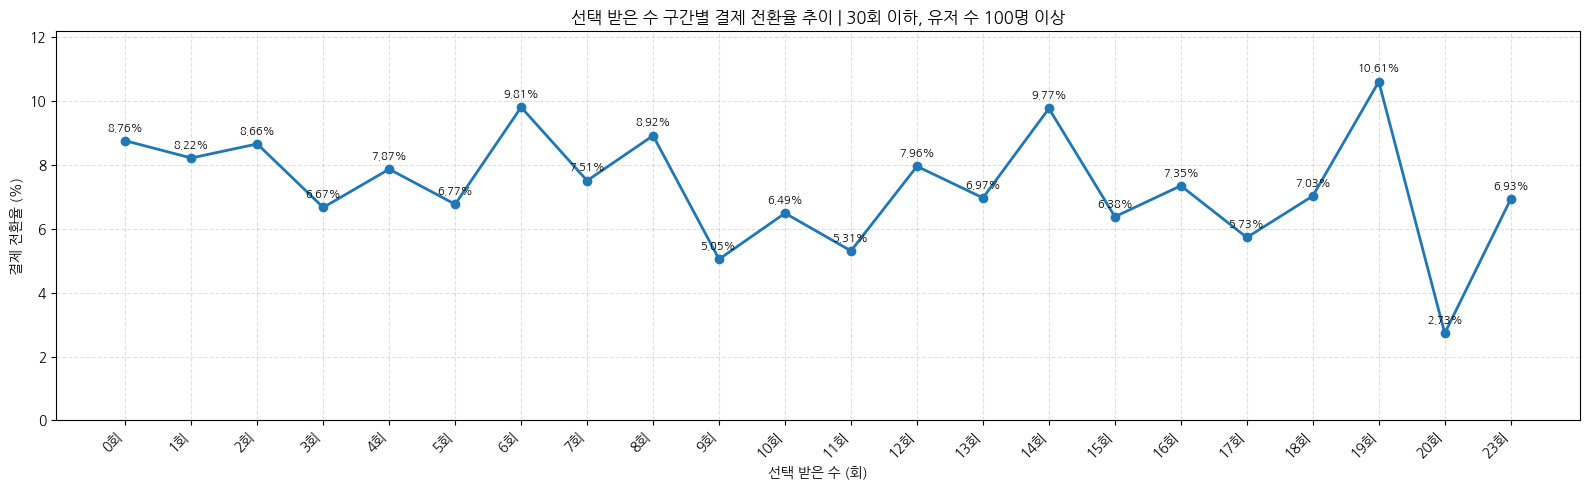

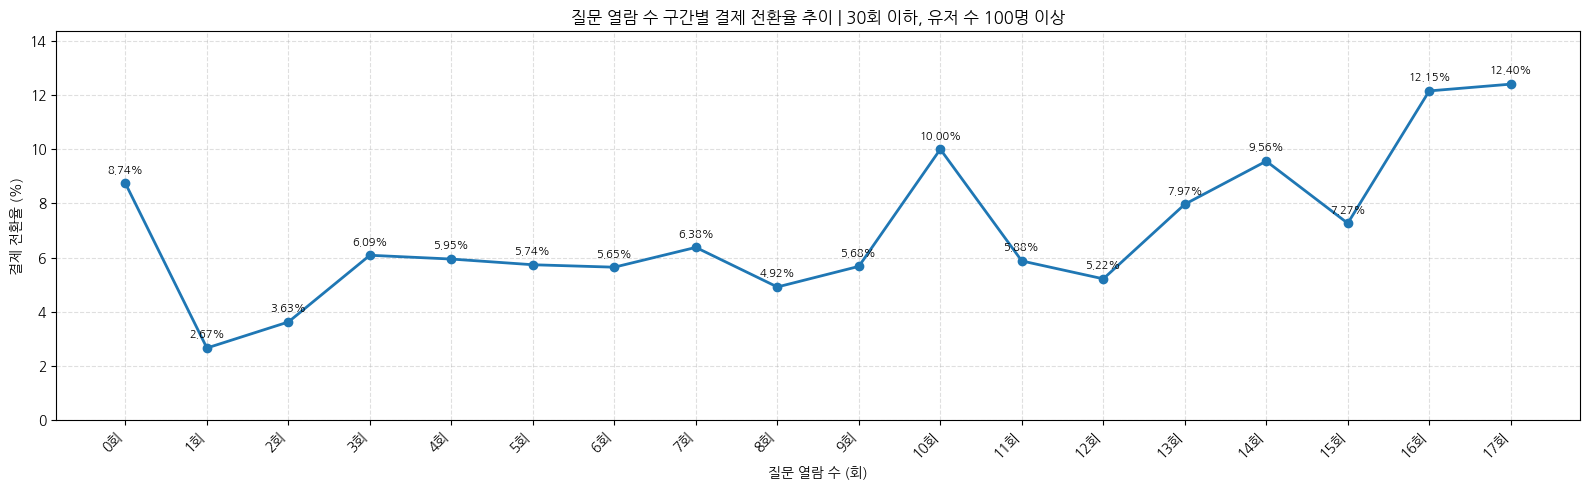

In [ ]:
# =========================
# 4. 변수별 그래프 그리기
# 친구 수는 40명까지, 나머지는 30까지
# =========================

early_plot_dict = {}

for col, summary in exact_summary_dict.items():
    graph_max = plot_config[col]["graph_max"]

    early_plot_dict[col] = plot_early_paid_rate(
        summary_df=summary,
        max_count_value=graph_max,
        min_user_count=100
    )

---다시

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

plt.rcParams["axes.unicode_minus"] = False

df = master_df_no_hackle.copy()
target = "is_paid"

plot_config = {
    "friend_count": {"label": "친구 수", "unit": "명", "graph_max": 40},
    "attendance_count": {"label": "출석일 수", "unit": "일", "graph_max": 20},
    "received_request_count": {"label": "친구 요청 받은 수", "unit": "회", "graph_max": 40},
    "sent_request_count": {"label": "친구 요청 보낸 수", "unit": "회", "graph_max": 40},
}

In [ ]:
def make_exact_count_summary(df, col, col_label, unit, target="is_paid"):
    temp = df[["user_id", col, target]].copy()
    temp[col] = temp[col].fillna(0).astype(int)

    summary = (
        temp.groupby(col)
        .agg(
            user_count=("user_id", "count"),
            paid_count=(target, "sum"),
            paid_rate=(target, "mean")
        )
        .reset_index()
        .rename(columns={col: "count_value"})
        .sort_values("count_value")
        .reset_index(drop=True)
    )

    summary["paid_rate_percent"] = (summary["paid_rate"] * 100).round(2)
    summary["paid_rate_diff"] = summary["paid_rate_percent"].diff().round(2)
    summary["변수명"] = col
    summary["변수명_한글"] = col_label
    summary["단위"] = unit
    summary["구간"] = summary["count_value"].astype(str) + unit

    return summary

In [ ]:
exact_summary_dict = {}

for col, info in plot_config.items():
    exact_summary_dict[col] = make_exact_count_summary(
        df=df,
        col=col,
        col_label=info["label"],
        unit=info["unit"],
        target=target
    )

In [ ]:
def plot_early_summary(summary_df, graph_max, min_user_count=1000):
    plot_df = summary_df[
        (summary_df["count_value"] <= graph_max) &
        (summary_df["user_count"] >= min_user_count)
    ].copy()

    col_label = plot_df["변수명_한글"].iloc[0]
    unit = plot_df["단위"].iloc[0]

    x = range(len(plot_df))
    y = plot_df["paid_rate_percent"]

    plt.figure(figsize=(16, 5))
    plt.plot(x, y, marker="o", linewidth=2)

    offset = max((y.max() - y.min()) * 0.04, 0.2)

    for i, v in enumerate(y):
        plt.text(i, v + offset, f"{v:.2f}%", ha="center", fontsize=8)

    plt.title(f"{col_label} 초반 구간별 결제율 | 유저 수 {min_user_count}명 이상")
    plt.xlabel(f"{col_label} ({unit})")
    plt.ylabel("결제율 (%)")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.xticks(x, plot_df["구간"], rotation=45, ha="right")
    plt.ylim(0, y.max() + offset * 5)
    plt.tight_layout()
    plt.show()

    return plot_df

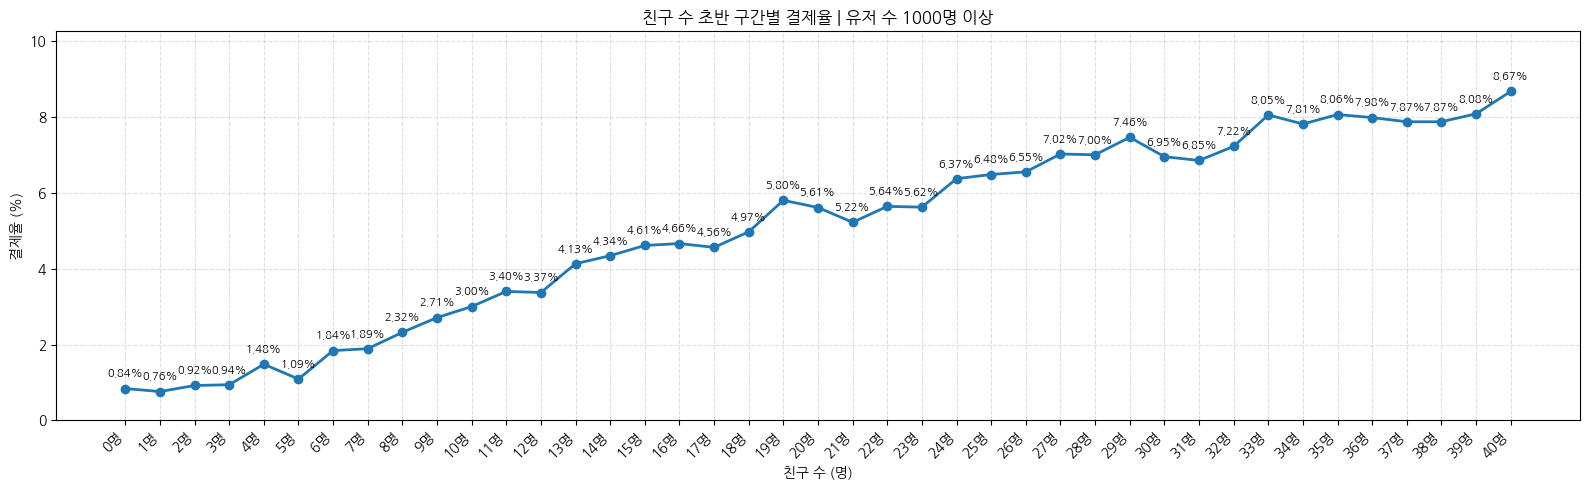

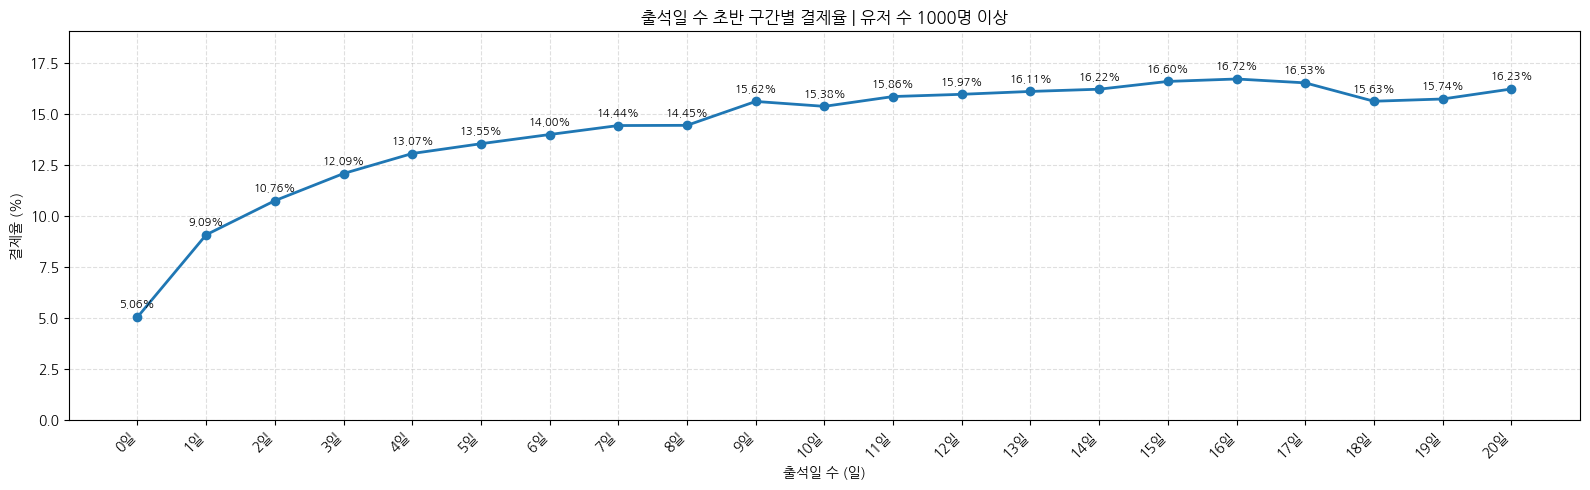

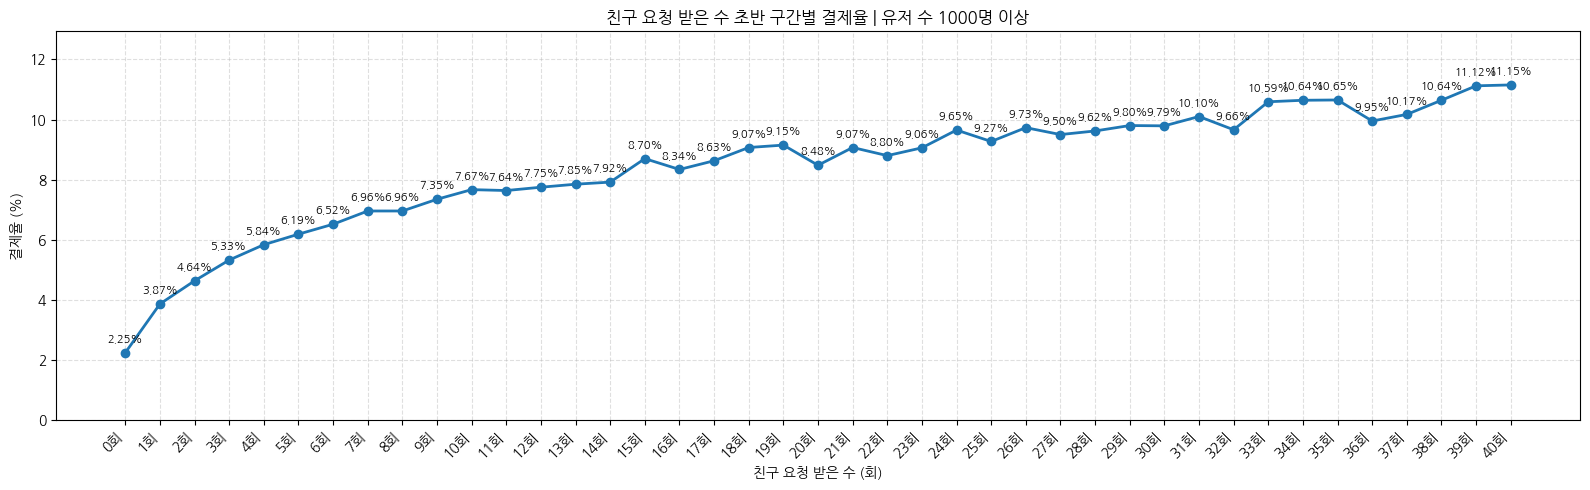

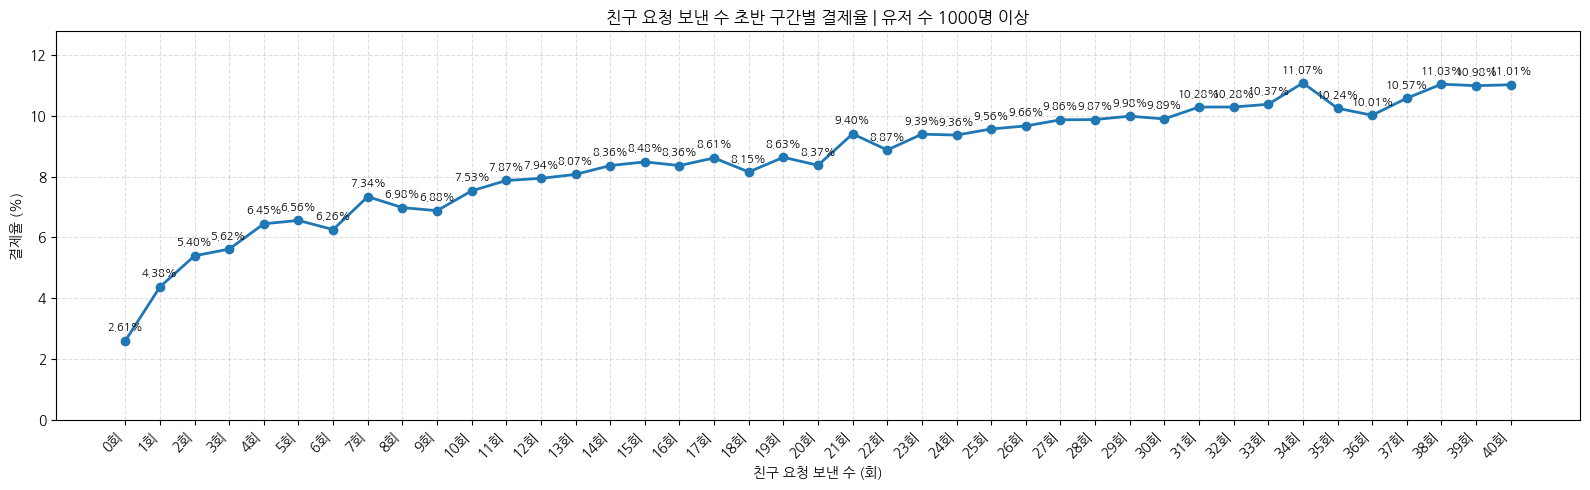

In [ ]:
early_plot_dict = {}

for col, summary in exact_summary_dict.items():
    early_plot_dict[col] = plot_early_summary(
        summary_df=summary,
        graph_max=plot_config[col]["graph_max"],
        min_user_count=1000
    )

In [ ]:
def make_valid_growth_table(summary_df, min_user_count=1000, top_n=10):
    temp = summary_df[summary_df["user_count"] >= min_user_count].copy()
    temp = temp.sort_values("count_value").reset_index(drop=True)

    temp["prev_count_value"] = temp["count_value"].shift(1)
    temp["prev_paid_rate_percent"] = temp["paid_rate_percent"].shift(1)
    temp["prev_user_count"] = temp["user_count"].shift(1)

    temp["paid_rate_diff"] = (
        temp["paid_rate_percent"] - temp["prev_paid_rate_percent"]
    ).round(2)

    temp["from_to"] = (
        temp["prev_count_value"].astype("Int64").astype(str)
        + temp["단위"]
        + " → "
        + temp["count_value"].astype(str)
        + temp["단위"]
    )

    result = temp[
        [
            "변수명",
            "변수명_한글",
            "from_to",
            "prev_user_count",
            "user_count",
            "prev_paid_rate_percent",
            "paid_rate_percent",
            "paid_rate_diff"
        ]
    ].dropna()

    return result.sort_values("paid_rate_diff", ascending=False).head(top_n)

In [ ]:
growth_valid_dict = {}

for col, summary in exact_summary_dict.items():
    growth_valid_dict[col] = make_valid_growth_table(
        summary_df=summary,
        min_user_count=1000,
        top_n=10
    )

growth_valid_all = pd.concat(growth_valid_dict.values(), ignore_index=True)
growth_valid_all.sort_values("paid_rate_diff", ascending=False)

In [ ]:
growth_valid_dict["friend_count"]

,변수명,변수명_한글,from_to,prev_user_count,user_count,prev_paid_rate_percent,paid_rate_percent,paid_rate_diff
114,friend_count,친구 수,113명 → 114명,1190.0,1193,11.43,14.08,2.65
85,friend_count,친구 수,84명 → 85명,3932.0,3851,9.77,12.23,2.46
112,friend_count,친구 수,111명 → 112명,1363.0,1323,10.79,13.23,2.44
97,friend_count,친구 수,96명 → 97명,2439.0,2371,11.11,13.12,2.01
93,friend_count,친구 수,92명 → 93명,2871.0,2718,11.35,13.28,1.93
109,friend_count,친구 수,108명 → 109명,1582.0,1442,12.71,14.29,1.58
117,friend_count,친구 수,116명 → 117명,1112.0,1093,10.61,12.08,1.47
104,friend_count,친구 수,103명 → 104명,1925.0,1803,11.43,12.65,1.22
87,friend_count,친구 수,86명 → 87명,3701.0,3479,10.94,12.13,1.19
99,friend_count,친구 수,98명 → 99명,2271.0,2285,10.96,11.90,0.94


In [ ]:
growth_valid_dict["attendance_count"]


,변수명,변수명_한글,from_to,prev_user_count,user_count,prev_paid_rate_percent,paid_rate_percent,paid_rate_diff
1,attendance_count,출석일 수,0일 → 1일,348388.0,78867,5.06,9.09,4.03
24,attendance_count,출석일 수,23일 → 24일,1412.0,1266,16.93,18.88,1.95
2,attendance_count,출석일 수,1일 → 2일,78867.0,46394,9.09,10.76,1.67
3,attendance_count,출석일 수,2일 → 3일,46394.0,32060,10.76,12.09,1.33
9,attendance_count,출석일 수,8일 → 9일,12755.0,11074,14.45,15.62,1.17
21,attendance_count,출석일 수,20일 → 21일,2039.0,1790,16.23,17.37,1.14
4,attendance_count,출석일 수,3일 → 4일,32060.0,24314,12.09,13.07,0.98
20,attendance_count,출석일 수,19일 → 20일,2453.0,2039,15.74,16.23,0.49
5,attendance_count,출석일 수,4일 → 5일,24314.0,19898,13.07,13.55,0.48
11,attendance_count,출석일 수,10일 → 11일,9582.0,8034,15.38,15.86,0.48


In [ ]:
growth_valid_dict["received_request_count"]


,변수명,변수명_한글,from_to,prev_user_count,user_count,prev_paid_rate_percent,paid_rate_percent,paid_rate_diff
74,received_request_count,친구 요청 받은 수,73회 → 74회,1147.0,1101,10.55,12.26,1.71
1,received_request_count,친구 요청 받은 수,0회 → 1회,16239.0,16255,2.25,3.87,1.62
52,received_request_count,친구 요청 받은 수,51회 → 52회,4823.0,4389,11.47,12.69,1.22
45,received_request_count,친구 요청 받은 수,44회 → 45회,6632.0,6283,10.31,11.52,1.21
71,received_request_count,친구 요청 받은 수,70회 → 71회,1491.0,1400,11.60,12.79,1.19
49,received_request_count,친구 요청 받은 수,48회 → 49회,5416.0,5256,10.84,12.02,1.18
62,received_request_count,친구 요청 받은 수,61회 → 62회,2645.0,2418,11.34,12.32,0.98
33,received_request_count,친구 요청 받은 수,32회 → 33회,10133.0,10018,9.66,10.59,0.93
15,received_request_count,친구 요청 받은 수,14회 → 15회,14919.0,14791,7.92,8.70,0.78
2,received_request_count,친구 요청 받은 수,1회 → 2회,16255.0,16537,3.87,4.64,0.77


In [ ]:
growth_valid_dict["sent_request_count"]

,변수명,변수명_한글,from_to,prev_user_count,user_count,prev_paid_rate_percent,paid_rate_percent,paid_rate_diff
55,sent_request_count,친구 요청 보낸 수,54회 → 55회,2990.0,2828,10.03,12.84,2.81
51,sent_request_count,친구 요청 보낸 수,50회 → 51회,3755.0,3574,10.04,11.92,1.88
1,sent_request_count,친구 요청 보낸 수,0회 → 1회,28008.0,13002,2.61,4.38,1.77
69,sent_request_count,친구 요청 보낸 수,68회 → 69회,1370.0,1428,12.12,13.52,1.40
73,sent_request_count,친구 요청 보낸 수,72회 → 73회,1228.0,1113,11.48,12.67,1.19
67,sent_request_count,친구 요청 보낸 수,66회 → 67회,1635.0,1566,11.31,12.39,1.08
7,sent_request_count,친구 요청 보낸 수,6회 → 7회,15041.0,15830,6.26,7.34,1.08
21,sent_request_count,친구 요청 보낸 수,20회 → 21회,17292.0,15017,8.37,9.40,1.03
2,sent_request_count,친구 요청 보낸 수,1회 → 2회,13002.0,12122,4.38,5.40,1.02
61,sent_request_count,친구 요청 보낸 수,60회 → 61회,2130.0,2100,10.89,11.81,0.92


## 임계점 검정

카이제곱

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

df = master_df_no_hackle.copy()

# 임계점 설정
attendance_threshold = 3
received_threshold = 18

# 그룹 생성
df["attendance_high"] = df["attendance_count"] >= attendance_threshold
df["received_high"] = df["received_request_count"] >= received_threshold

df["HH"] = df["attendance_high"] & df["received_high"]

In [ ]:
def chi_square_test(df, group_col, target="is_paid"):
    table = pd.crosstab(df[group_col], df[target])

    chi2, p, dof, expected = chi2_contingency(table)

    result = pd.DataFrame({
        "구분": table.index,
        "미결제자 수": table[0].values,
        "결제자 수": table[1].values,
        "전체 유저 수": table.sum(axis=1).values,
        "결제율(%)": (table[1].values / table.sum(axis=1).values * 100).round(2)
    })

    print("교차표")
    display(result)

    print(f"카이제곱 통계량: {chi2:.4f}")
    print(f"p-value: {p:.6f}")

    if p < 0.05:
        print("결론: 그룹 간 결제율 차이는 통계적으로 유의함")
    else:
        print("결론: 그룹 간 결제율 차이는 통계적으로 유의하지 않음")

    return result, table, chi2, p

In [ ]:
attendance_result = chi_square_test(
    df=df,
    group_col="attendance_high",
    target="is_paid"
)

교차표


,구분,미결제자 수,결제자 수,전체 유저 수,결제율(%)
0,False,443865,29784,473649,6.29
1,True,174023,29408,203431,14.46


카이제곱 통계량: 11899.1100
p-value: 0.000000
결론: 그룹 간 결제율 차이는 통계적으로 유의함


In [ ]:
received_result = chi_square_test(
    df=df,
    group_col="received_high",
    target="is_paid"
)

교차표


,구분,미결제자 수,결제자 수,전체 유저 수,결제율(%)
0,False,266963,18948,285911,6.63
1,True,350925,40244,391169,10.29


카이제곱 통계량: 2774.3818
p-value: 0.000000
결론: 그룹 간 결제율 차이는 통계적으로 유의함


In [ ]:
hh_result = chi_square_test(
    df=df,
    group_col="HH",
    target="is_paid"
)

교차표


,구분,미결제자 수,결제자 수,전체 유저 수,결제율(%)
0,False,512563,38971,551534,7.07
1,True,105325,20221,125546,16.11


카이제곱 통계량: 10475.6759
p-value: 0.000000
결론: 그룹 간 결제율 차이는 통계적으로 유의함


z-test


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

df = master_df_no_hackle.copy()

target = "is_paid"

attendance_threshold = 3
received_threshold = 18

In [ ]:
# =========================
# 1. 두 집단 비율검정 함수
# =========================

def proportion_ztest_by_threshold(df, col, threshold, target="is_paid", label=None, unit="회"):
    temp = df[[col, target]].copy()
    temp[col] = temp[col].fillna(0)

    temp["group"] = np.where(
        temp[col] >= threshold,
        f"{threshold}{unit} 이상",
        f"{threshold}{unit} 미만"
    )

    summary = (
        temp.groupby("group")
        .agg(
            user_count=(target, "count"),
            paid_count=(target, "sum"),
            paid_rate=(target, "mean")
        )
        .reset_index()
    )

    summary["paid_rate_percent"] = (summary["paid_rate"] * 100).round(2)

    # 이상 그룹, 미만 그룹 순서 맞추기
    high = summary[summary["group"] == f"{threshold}{unit} 이상"]
    low = summary[summary["group"] == f"{threshold}{unit} 미만"]

    count = np.array([
        high["paid_count"].values[0],
        low["paid_count"].values[0]
    ])

    nobs = np.array([
        high["user_count"].values[0],
        low["user_count"].values[0]
    ])

    # 대립가설: 이상 그룹 결제율 > 미만 그룹 결제율
    z_stat, p_value = proportions_ztest(
        count=count,
        nobs=nobs,
        alternative="larger"
    )

    summary["변수"] = label if label else col
    summary["기준"] = f"{threshold}{unit}"

    summary = summary[
        ["변수", "기준", "group", "user_count", "paid_count", "paid_rate_percent"]
    ]

    print(f"\n[{label}] {threshold}{unit} 이상 vs 미만")
    display(summary)

    print(f"z-statistic: {z_stat:.4f}")
    print(f"p-value: {p_value:.6f}")

    if p_value < 0.05:
        print(f"결론: {threshold}{unit} 이상 그룹의 결제율이 유의하게 높다.")
    else:
        print(f"결론: {threshold}{unit} 이상 그룹의 결제율이 유의하게 높다고 보기 어렵다.")

    return summary, z_stat, p_value

In [ ]:
# =========================
# 2. 출석일 수 3일 이상 검정
# =========================

attendance_test = proportion_ztest_by_threshold(
    df=df,
    col="attendance_count",
    threshold=3,
    target="is_paid",
    label="출석일 수",
    unit="일"
)


[출석일 수] 3일 이상 vs 미만


,변수,기준,group,user_count,paid_count,paid_rate_percent
0,출석일 수,3일,3일 미만,473649,29784,6.29
1,출석일 수,3일,3일 이상,203431,29408,14.46


z-statistic: 109.0877
p-value: 0.000000
결론: 3일 이상 그룹의 결제율이 유의하게 높다.


In [ ]:
# =========================
# 3. 친구 요청 받은 수 18회 이상 검정
# =========================

received_test = proportion_ztest_by_threshold(
    df=df,
    col="received_request_count",
    threshold=18,
    target="is_paid",
    label="친구 요청 받은 수",
    unit="회"
)


[친구 요청 받은 수] 18회 이상 vs 미만


,변수,기준,group,user_count,paid_count,paid_rate_percent
0,친구 요청 받은 수,18회,18회 미만,285911,18948,6.63
1,친구 요청 받은 수,18회,18회 이상,391169,40244,10.29


z-statistic: 52.6768
p-value: 0.000000
결론: 18회 이상 그룹의 결제율이 유의하게 높다.


In [ ]:
# =========================
# 4. 둘 다 만족하는 HH 그룹 검정
# =========================

df["HH"] = (
    (df["attendance_count"].fillna(0) >= attendance_threshold) &
    (df["received_request_count"].fillna(0) >= received_threshold)
)

hh_summary = (
    df.groupby("HH")
    .agg(
        user_count=(target, "count"),
        paid_count=(target, "sum"),
        paid_rate=(target, "mean")
    )
    .reset_index()
)

hh_summary["group"] = np.where(
    hh_summary["HH"] == True,
    "출석 3일 이상 & 친구 요청 받은 수 18회 이상",
    "그 외 유저"
)

hh_summary["paid_rate_percent"] = (hh_summary["paid_rate"] * 100).round(2)

high = hh_summary[hh_summary["HH"] == True]
low = hh_summary[hh_summary["HH"] == False]

count = np.array([
    high["paid_count"].values[0],
    low["paid_count"].values[0]
])

nobs = np.array([
    high["user_count"].values[0],
    low["user_count"].values[0]
])

z_stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative="larger"
)

hh_result = hh_summary[
    ["group", "user_count", "paid_count", "paid_rate_percent"]
]

display(hh_result)

print(f"z-statistic: {z_stat:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("결론: HH 그룹의 결제율이 그 외 유저보다 유의하게 높다.")
else:
    print("결론: HH 그룹의 결제율이 그 외 유저보다 유의하게 높다고 보기 어렵다.")

,group,user_count,paid_count,paid_rate_percent
0,그 외 유저,551534,38971,7.07
1,출석 3일 이상 & 친구 요청 받은 수 18회 이상,125546,20221,16.11


z-statistic: 102.3563
p-value: 0.000000
결론: HH 그룹의 결제율이 그 외 유저보다 유의하게 높다.


---사분면 재정의 ----

In [ ]:
import numpy as np
import pandas as pd

# 기준값
attendance_threshold = 3
received_threshold = 18

# 기본 유저 데이터
df = master_df_no_hackle.copy()

In [ ]:
# accounts_pointhistory 컬럼:
# user_id, delta_point

point_summary = (
    point
    .assign(
        point_gain=lambda x: np.where(x["delta_point"] > 0, x["delta_point"], 0),
        point_spent=lambda x: np.where(x["delta_point"] < 0, -x["delta_point"], 0)
    )
    .groupby("user_id")
    .agg(
        포인트_획득량=("point_gain", "sum"),
        포인트_사용량=("point_spent", "sum")
    )
    .reset_index()
)

point_summary.head()

,user_id,포인트_획득량,포인트_사용량
0,838023,1665,600
1,838466,4748,3800
2,838642,344,300
3,839357,3048,1700
4,839670,139,0


In [ ]:
# accounts_userquestionrecord 컬럼:
# user_id, opened_times, answer_status, has_read

question_summary = (
    question
    .groupby("user_id")
    .agg(
        평균_질문_열람_횟수=("opened_times", "mean"),
        답변_완료_수=("answer_status", lambda x: (x.notna() & (x != "미답변")).sum()),
        질문_읽음_수=("has_read", lambda x: (x == True).sum())
    )
    .reset_index()
)

question_summary.head()

,user_id,평균_질문_열람_횟수,답변_완료_수,질문_읽음_수
0,838023,0.000000,22,4
1,838466,0.007634,131,27
2,838642,0.000000,10,1
3,839357,0.103774,212,50
4,840293,0.023529,170,75


In [ ]:
# accounts_user 컬럼:
# user_id, alarm_count, pending_votes

user_extra = user[
    ["user_id", "alarm_count", "pending_votes"]
].copy()

user_extra = user_extra.rename(columns={
    "alarm_count": "알림_수",
    "pending_votes": "미확인_투표_수"
})

user_extra.head()

,user_id,알림_수,미확인_투표_수
0,831962,40878,110
1,832151,37,47
2,832340,19,21
3,832520,29,15
4,832614,28,14


In [ ]:
df = (
    df
    .merge(point_summary, on="user_id", how="left")
    .merge(question_summary, on="user_id", how="left")
    .merge(user_extra, on="user_id", how="left")
)

# 결측값 0 처리
add_cols = [
    "포인트_획득량",
    "포인트_사용량",
    "평균_질문_열람_횟수",
    "답변_완료_수",
    "질문_읽음_수",
    "알림_수",
    "미확인_투표_수"
]

df[add_cols] = df[add_cols].fillna(0)

In [ ]:
df["출석_높음"] = df["attendance_count"].fillna(0) >= attendance_threshold
df["친구요청받은수_높음"] = df["received_request_count"].fillna(0) >= received_threshold

df["유저군"] = np.select(
    [
        df["출석_높음"] & df["친구요청받은수_높음"],
        df["출석_높음"] & ~df["친구요청받은수_높음"],
        ~df["출석_높음"] & df["친구요청받은수_높음"],
        ~df["출석_높음"] & ~df["친구요청받은수_높음"]
    ],
    ["HH", "HL", "LH", "LL"],
    default="기타"
)

In [ ]:
feature_cols = [
    "attendance_count",
    "received_request_count",
    "sent_request_count",
    "friend_count",
    "포인트_획득량",
    "포인트_사용량",
    "평균_질문_열람_횟수",
    "답변_완료_수",
    "질문_읽음_수",
    "알림_수",
    "미확인_투표_수"
]

전체_유저군_특징 = (
    df.groupby("유저군")
    .agg(
        유저_수=("user_id", "count"),
        결제_유저_수=("is_paid", "sum"),
        결제율=("is_paid", "mean"),
        평균_출석일수=("attendance_count", "mean"),
        평균_친구요청받은수=("received_request_count", "mean"),
        평균_친구요청보낸수=("sent_request_count", "mean"),
        평균_친구수=("friend_count", "mean"),
        평균_포인트획득량=("포인트_획득량", "mean"),
        평균_포인트사용량=("포인트_사용량", "mean"),
        #평균_답변완료수=("답변_완료_수", "mean"),
        #평균_질문읽음수=("질문_읽음_수", "mean"),
        평균_알림수=("알림_수", "mean"),
        평균_미확인투표수=("미확인_투표_수", "mean")
    )
    .reset_index()
)

전체_유저군_특징["결제율"] = (전체_유저군_특징["결제율"] * 100).round(2)

num_cols = 전체_유저군_특징.select_dtypes(include="number").columns
전체_유저군_특징[num_cols] = 전체_유저군_특징[num_cols].round(2)

전체_유저군_특징

,유저군,유저_수,결제_유저_수,결제율,평균_출석일수,평균_친구요청받은수,평균_친구요청보낸수,평균_친구수,평균_포인트획득량,평균_포인트사용량,평균_알림수,평균_미확인투표수
0,HH,125546,20221,16.11,9.91,37.49,30.45,69.42,44.91,44.33,0.70,79.62
1,HL,77885,9187,11.80,10.36,8.99,28.05,38.42,27.63,26.37,0.73,23.26
2,LH,265623,20023,7.54,0.40,37.95,26.67,67.90,46.06,40.66,1.14,141.41
3,LL,208026,9761,4.69,0.32,7.97,19.50,30.60,14.90,13.04,0.93,38.13


In [ ]:
미결제_유저군_특징 = (
    df[df["is_paid"] == 0]
    .groupby("유저군")
    .agg(
        유저_수=("user_id", "count"),
        평균_출석일수=("attendance_count", "mean"),
        평균_친구요청받은수=("received_request_count", "mean"),
        평균_친구요청보낸수=("sent_request_count", "mean"),
        평균_친구수=("friend_count", "mean"),
        평균_포인트획득량=("포인트_획득량", "mean"),
        평균_포인트사용량=("포인트_사용량", "mean"),
        #평균_답변완료수=("답변_완료_수", "mean"),
        #평균_질문읽음수=("질문_읽음_수", "mean"),
        평균_알림수=("알림_수", "mean"),
        평균_미확인투표수=("미확인_투표_수", "mean")
    )
    .reset_index()
)

num_cols = 미결제_유저군_특징.select_dtypes(include="number").columns
미결제_유저군_특징[num_cols] = 미결제_유저군_특징[num_cols].round(2)

미결제_유저군_특징

,유저군,유저_수,평균_출석일수,평균_친구요청받은수,평균_친구요청보낸수,평균_친구수,평균_포인트획득량,평균_포인트사용량,평균_알림수,평균_미확인투표수
0,HH,105325,9.78,37.24,30.23,68.99,43.12,40.04,0.70,80.85
1,HL,68698,10.27,8.92,27.80,38.11,26.01,24.02,0.74,23.34
2,LH,245600,0.38,37.82,26.40,67.52,45.78,39.03,1.08,142.39
3,LL,198265,0.31,7.90,19.11,30.15,14.66,12.42,0.93,38.10


In [ ]:
결제_유저군_특징 = (
    df[df["is_paid"] == 1]
    .groupby("유저군")
    .agg(
        유저_수=("user_id", "count"),
        평균_출석일수=("attendance_count", "mean"),
        평균_친구요청받은수=("received_request_count", "mean"),
        평균_친구요청보낸수=("sent_request_count", "mean"),
        평균_친구수=("friend_count", "mean"),
        평균_포인트획득량=("포인트_획득량", "mean"),
        평균_포인트사용량=("포인트_사용량", "mean"),
        #평균_답변완료수=("답변_완료_수", "mean"),
       # 평균_질문읽음수=("질문_읽음_수", "mean"),
        평균_알림수=("알림_수", "mean"),
        평균_미확인투표수=("미확인_투표_수", "mean")
    )
    .reset_index()
)

num_cols = 결제_유저군_특징.select_dtypes(include="number").columns
결제_유저군_특징[num_cols] = 결제_유저군_특징[num_cols].round(2)

결제_유저군_특징

,유저군,유저_수,평균_출석일수,평균_친구요청받은수,평균_친구요청보낸수,평균_친구수,평균_포인트획득량,평균_포인트사용량,평균_알림수,평균_미확인투표수
0,HH,20221,10.60,38.81,31.60,71.67,54.23,66.66,0.66,73.26
1,HL,9187,10.97,9.51,29.93,40.74,39.73,43.96,0.66,22.61
2,LH,20023,0.59,39.55,29.90,72.54,49.50,60.64,1.92,129.32
3,LL,9761,0.56,9.42,27.32,39.58,19.62,25.64,0.83,38.94


전체에 평균매출 결제율 추가 결제 사용자에 평균매출, 구매주기,평균 건단가 추가

In [ ]:
import numpy as np
import pandas as pd

# =========================
# 0. 기본 데이터
# =========================

df = master_df_no_hackle.copy()

df["user_id"] = df["user_id"].astype(str)

attendance_threshold = 3
received_threshold = 18

In [ ]:
# =========================
# 1. 결제 데이터 매출 계산
# =========================

payment_df = payment.copy()
payment_df["user_id"] = payment_df["user_id"].astype(str)

# 날짜 컬럼
payment_df["created_at"] = pd.to_datetime(payment_df["created_at"], errors="coerce")

# projectId 숫자 추출
payment_df["project_num"] = (
    payment_df["productId"]
    .astype(str)
    .str.extract(r"(200|777|1000|4000)")[0]
)

# 가격 매핑
price_map = {
    "200": 900,
    "777": 1900,
    "1000": 2900,
    "4000": 9900
}

payment_df["가격"] = payment_df["project_num"].map(price_map)

# 매핑 확인
print("가격 매핑 안 된 결제 row 수:", payment_df["가격"].isna().sum())
display(payment_df[["user_id", "productId", "project_num", "가격"]].head())

가격 매핑 안 된 결제 row 수: 0


,user_id,productId,project_num,가격
0,1000165,heart.1000,1000,2900
1,1211364,heart.1000,1000,2900
2,1191594,heart.1000,1000,2900
3,1088440,heart.1000,1000,2900
4,1178580,heart.1000,1000,2900


In [ ]:
# 유저별 결제 요약
payment_summary = (
    payment_df
    .dropna(subset=["가격"])
    .groupby("user_id")
    .agg(
        총매출=("가격", "sum"),
        구매횟수=("가격", "count"),
        첫구매일=("created_at", "min"),
        마지막구매일=("created_at", "max")
    )
    .reset_index()
)

payment_summary["평균건단가"] = (
    payment_summary["총매출"] / payment_summary["구매횟수"]
)

payment_summary["구매주기"] = np.where(
    payment_summary["구매횟수"] >= 2,
    (payment_summary["마지막구매일"] - payment_summary["첫구매일"]).dt.days / (payment_summary["구매횟수"] - 1),
    np.nan
)

print("결제 요약 유저 수:", payment_summary["user_id"].nunique())
print("master 결제 유저 수:", df[df["is_paid"] == 1]["user_id"].nunique())
print("겹치는 유저 수:", len(set(payment_summary["user_id"]) & set(df["user_id"])))

결제 요약 유저 수: 59192
master 결제 유저 수: 59192
겹치는 유저 수: 59192


In [ ]:
# master에 결제 요약 병합
df = df.merge(payment_summary, on="user_id", how="left")

for col in ["총매출", "구매횟수", "평균건단가"]:
    df[col] = df[col].fillna(0)

# 확인
df[df["is_paid"] == 1][["user_id", "총매출", "구매횟수", "평균건단가"]].head()

,user_id,총매출,구매횟수,평균건단가
11,833041,19800.0,2.0,9900.000000
44,834112,1900.0,1.0,1900.000000
75,835815,3700.0,3.0,1233.333333
76,835839,1900.0,1.0,1900.000000
81,835888,2800.0,2.0,1400.000000


In [ ]:
# =========================
# 2. 포인트 획득량 / 사용량
# =========================

point_df = point.copy()
point_df["user_id"] = point_df["user_id"].astype(str)

# delta_point 기준
point_df["delta_point"] = pd.to_numeric(point_df["delta_point"], errors="coerce").fillna(0)

point_df["포인트획득량"] = np.where(point_df["delta_point"] > 0, point_df["delta_point"], 0)
point_df["포인트사용량"] = np.where(point_df["delta_point"] < 0, -point_df["delta_point"], 0)

point_summary = (
    point_df
    .groupby("user_id")
    .agg(
        포인트획득량=("포인트획득량", "sum"),
        포인트사용량=("포인트사용량", "sum")
    )
    .reset_index()
)

df = df.merge(point_summary, on="user_id", how="left")

df["포인트획득량"] = df["포인트획득량"].fillna(0)
df["포인트사용량"] = df["포인트사용량"].fillna(0)

In [ ]:
# =========================
# 3. 질문 관련 변수
# =========================

question_df = question.copy()
question_df["user_id"] = question_df["user_id"].astype(str)

# 없는 컬럼 방어
if "opened_times" not in question_df.columns:
    question_df["opened_times"] = 0

if "answer_status" not in question_df.columns:
    question_df["answer_status"] = np.nan

if "has_read" not in question_df.columns:
    question_df["has_read"] = False

question_summary = (
    question_df
    .groupby("user_id")
    .agg(
        평균질문열람횟수=("opened_times", "mean"),
        답변완료수=("answer_status", lambda x: x.notna().sum()),
        질문읽음수=("has_read", lambda x: (x == True).sum())
    )
    .reset_index()
)

df = df.merge(question_summary, on="user_id", how="left")

for col in ["평균질문열람횟수", "답변완료수", "질문읽음수"]:
    df[col] = df[col].fillna(0)

In [ ]:
# =========================
# 4. 알림 수 / 미확인 투표 수
# =========================

user_df = user.copy()
user_df["user_id"] = user_df["user_id"].astype(str)

user_df["알림수"] = user_df["alarm_count"] if "alarm_count" in user_df.columns else 0
user_df["미확인투표수"] = user_df["pending_votes"] if "pending_votes" in user_df.columns else 0

user_extra = user_df[["user_id", "알림수", "미확인투표수"]].copy()

df = df.merge(user_extra, on="user_id", how="left")

df["알림수"] = df["알림수"].fillna(0)
df["미확인투표수"] = df["미확인투표수"].fillna(0)

In [ ]:
# =========================
# 5. HH / HL / LH / LL 생성
# =========================

df["출석높음"] = df["attendance_count"].fillna(0) >= attendance_threshold
df["친구요청받은수높음"] = df["received_request_count"].fillna(0) >= received_threshold

df["유저군"] = np.select(
    [
        df["출석높음"] & df["친구요청받은수높음"],
        df["출석높음"] & ~df["친구요청받은수높음"],
        ~df["출석높음"] & df["친구요청받은수높음"],
        ~df["출석높음"] & ~df["친구요청받은수높음"]
    ],
    ["HH", "HL", "LH", "LL"],
    default="기타"
)

df["유저군"].value_counts()

유저군
LH    265623
LL    208026
HH    125546
HL     77885
Name: count, dtype: int64

In [ ]:
# =========================
# 6. 전체 유저군 특징
# =========================

전체_유저군_특징 = (
    df.groupby("유저군")
    .agg(
        유저수=("user_id", "count"),
        결제유저수=("is_paid", "sum"),
        결제율=("is_paid", "mean"),
        평균매출=("총매출", "mean"),
        평균출석일수=("attendance_count", "mean"),
        평균친구요청받은수=("received_request_count", "mean"),
        평균친구요청보낸수=("sent_request_count", "mean"),
        평균친구수=("friend_count", "mean"),
        평균포인트획득량=("포인트획득량", "mean"),
        평균포인트사용량=("포인트사용량", "mean"),
        평균질문열람횟수=("평균질문열람횟수", "mean"),
        평균답변완료수=("답변완료수", "mean"),
        평균질문읽음수=("질문읽음수", "mean"),
        평균알림수=("알림수", "mean"),
        평균미확인투표수=("미확인투표수", "mean")
    )
    .reset_index()
)

전체_유저군_특징["결제율"] = 전체_유저군_특징["결제율"] * 100

num_cols = 전체_유저군_특징.select_dtypes(include="number").columns
전체_유저군_특징[num_cols] = 전체_유저군_특징[num_cols].round(2)

전체_유저군_특징

,유저군,유저수,결제유저수,결제율,평균매출,평균출석일수,평균친구요청받은수,평균친구요청보낸수,평균친구수,평균포인트획득량,평균포인트사용량,평균질문열람횟수,평균답변완료수,평균질문읽음수,평균알림수,평균미확인투표수
0,HH,125546,20221,16.11,602.94,9.91,37.49,30.45,69.42,44.91,44.33,0.0,2.57,1.47,0.70,79.62
1,HL,77885,9187,11.80,397.43,10.36,8.99,28.05,38.42,27.63,26.37,0.0,1.75,1.04,0.73,23.26
2,LH,265623,20023,7.54,242.34,0.40,37.95,26.67,67.90,46.06,40.66,0.0,2.18,1.17,1.14,141.41
3,LL,208026,9761,4.69,140.57,0.32,7.97,19.50,30.60,14.90,13.04,0.0,0.86,0.48,0.93,38.13


In [ ]:
# =========================
# 7. 미결제 유저군 특징
# =========================

미결제_유저군_특징 = (
    df[df["is_paid"] == 0]
    .groupby("유저군")
    .agg(
        유저수=("user_id", "count"),
        평균출석일수=("attendance_count", "mean"),
        평균친구요청받은수=("received_request_count", "mean"),
        평균친구요청보낸수=("sent_request_count", "mean"),
        평균친구수=("friend_count", "mean"),
        평균포인트획득량=("포인트획득량", "mean"),
        평균포인트사용량=("포인트사용량", "mean"),
        평균답변완료수=("답변완료수", "mean"),
        평균질문읽음수=("질문읽음수", "mean"),
        평균알림수=("알림수", "mean"),
        평균미확인투표수=("미확인투표수", "mean")
    )
    .reset_index()
)

num_cols = 미결제_유저군_특징.select_dtypes(include="number").columns
미결제_유저군_특징[num_cols] = 미결제_유저군_특징[num_cols].round(2)

미결제_유저군_특징

,유저군,유저수,평균출석일수,평균친구요청받은수,평균친구요청보낸수,평균친구수,평균포인트획득량,평균포인트사용량,평균답변완료수,평균질문읽음수,평균알림수,평균미확인투표수
0,HH,105325,9.78,37.24,30.23,68.99,43.12,40.04,2.47,1.41,0.70,80.85
1,HL,68698,10.27,8.92,27.80,38.11,26.01,24.02,1.64,0.97,0.74,23.34
2,LH,245600,0.38,37.82,26.40,67.52,45.78,39.03,2.15,1.15,1.08,142.39
3,LL,198265,0.31,7.90,19.11,30.15,14.66,12.42,0.84,0.47,0.93,38.10


In [ ]:
# =========================
# 8. 결제 유저군 특징
# =========================

결제_유저군_특징 = (
    df[df["is_paid"] == 1]
    .groupby("유저군")
    .agg(
        유저수=("user_id", "count"),
        평균매출=("총매출", "mean"),
        평균구매횟수=("구매횟수", "mean"),
        평균구매주기=("구매주기", "mean"),
        평균건단가=("평균건단가", "mean"),
        평균출석일수=("attendance_count", "mean"),
        평균친구요청받은수=("received_request_count", "mean"),
        평균친구요청보낸수=("sent_request_count", "mean"),
        평균친구수=("friend_count", "mean"),
        평균포인트획득량=("포인트획득량", "mean"),
        평균포인트사용량=("포인트사용량", "mean"),
        
        평균질문읽음수=("질문읽음수", "mean"),
        평균알림수=("알림수", "mean"),
        평균미확인투표수=("미확인투표수", "mean")
    )
    .reset_index()
)

num_cols = 결제_유저군_특징.select_dtypes(include="number").columns
결제_유저군_특징[num_cols] = 결제_유저군_특징[num_cols].round(2)

결제_유저군_특징

,유저군,유저수,평균매출,평균구매횟수,평균구매주기,평균건단가,평균출석일수,평균친구요청받은수,평균친구요청보낸수,평균친구수,평균포인트획득량,평균포인트사용량,평균질문읽음수,평균알림수,평균미확인투표수
0,HH,20221,3743.48,1.74,5.93,2024.29,10.60,38.81,31.60,71.67,54.23,66.66,1.75,0.66,73.26
1,HL,9187,3369.32,1.59,5.63,2012.73,10.97,9.51,29.93,40.74,39.73,43.96,1.56,0.66,22.61
2,LH,20023,3214.83,1.54,4.32,2023.82,0.59,39.55,29.90,72.54,49.50,60.64,1.46,1.92,129.32
3,LL,9761,2995.87,1.44,5.13,2018.74,0.56,9.42,27.32,39.58,19.62,25.64,0.66,0.83,38.94


HH 특

In [ ]:
hh_paid = df[
    (df["유저군"] == "HH") &
    (df["is_paid"] == 1)
].copy()

hh_paid_features = [
    "총매출",
    "구매횟수",
    "구매주기",
    "평균건단가",
    "attendance_count",
    "received_request_count",
    "sent_request_count",
    "friend_count",
    "포인트획득량",
    "포인트사용량",
    "질문읽음수",
    "알림수",
    "미확인투표수"
]

hh_paid_description = (
    hh_paid[hh_paid_features]
    .describe(
        percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]
    )
    .T
    .rename(columns={
        "count": "유저수",
        "mean": "평균",
        "std": "표준편차",
        "min": "최솟값",
        "25%": "25%",
        "50%": "중앙값",
        "75%": "75%",
        "90%": "90%",
        "95%": "95%",
        "max": "최댓값"
    })
    .round(2)
)

hh_paid_description

,유저수,평균,표준편차,최솟값,25%,중앙값,75%,90%,95%,최댓값
총매출,20221.0,3743.48,5700.58,900.0,1900.0,1900.0,2800.0,7700.0,11500.00,196500.0
구매횟수,20221.0,1.74,1.90,1.0,1.0,1.0,2.0,3.0,5.00,60.0
구매주기,6037.0,5.93,20.84,0.0,0.0,1.0,3.0,11.0,26.07,356.0
평균건단가,20221.0,2024.29,775.73,900.0,1900.0,1900.0,1900.0,2400.0,2650.00,9900.0
attendance_count,20221.0,10.60,10.05,3.0,5.0,8.0,13.0,20.0,28.00,241.0
received_request_count,20221.0,38.81,16.69,18.0,26.0,35.0,48.0,62.0,71.00,149.0
sent_request_count,20221.0,31.60,26.39,0.0,15.0,26.0,41.0,61.0,77.00,1050.0
friend_count,20221.0,71.67,30.99,6.0,50.0,66.0,87.0,110.0,128.00,778.0
포인트획득량,20221.0,54.23,751.38,0.0,0.0,0.0,0.0,0.0,0.00,22495.0
포인트사용량,20221.0,66.66,923.41,0.0,0.0,0.0,0.0,0.0,0.00,26180.0


In [ ]:
hh_paid_ids = set(hh_paid["user_id"])

hh_payment_product = payment_df[
    payment_df["user_id"].isin(hh_paid_ids)
].copy()

hh_product_summary = (
    hh_payment_product.groupby(["project_num", "가격"])
    .agg(
        구매건수=("user_id", "count"),
        구매유저수=("user_id", "nunique"),
        매출=("가격", "sum")
    )
    .reset_index()
)

hh_product_summary["구매건수비율(%)"] = (
    hh_product_summary["구매건수"]
    / hh_product_summary["구매건수"].sum()
    * 100
).round(2)

hh_product_summary["매출비율(%)"] = (
    hh_product_summary["매출"]
    / hh_product_summary["매출"].sum()
    * 100
).round(2)

hh_product_summary.sort_values("가격")

,project_num,가격,구매건수,구매유저수,매출,구매건수비율(%),매출비율(%)
1,200,900,6428,3616,5785200,18.26,7.64
3,777,1900,19823,19774,37663700,56.31,49.76
0,1000,2900,8051,4164,23347900,22.87,30.84
2,4000,9900,899,592,8900100,2.55,11.76


In [ ]:
# 전체 유저 수
total_users = df["user_id"].nunique()

# 결제 유저 수
paid_users = df.loc[df["is_paid"] == 1, "user_id"].nunique()

# 전체 결제율
paid_rate = paid_users / total_users * 100

print(f"전체 유저 수 : {total_users:,}명")
print(f"결제 유저 수 : {paid_users:,}명")
print(f"전체 결제율 : {paid_rate:.2f}%")

전체 유저 수 : 677,080명
결제 유저 수 : 59,192명
전체 결제율 : 8.74%


# 장열님 코드

In [ ]:
import os
import shutil
from google.colab import drive

# 1. 구글 드라이브 마운트
drive.mount('/content/drive')

# 2. 'hard_project' 작업 폴더 경로 설정
project_path = '/content/drive/MyDrive/hard_project'
if not os.path.exists(project_path):
    os.makedirs(project_path)

# 3. 코랩 파일 탭에 업로드한 수정 최종본 파일 경로
local_sql_path = '/content/테이블 전처리 수정 최종본1.sql'
drive_sql_path = os.path.join(project_path, '테이블_전처리_수정_최종본1.sql')

# 4. 파일 백업 실행
if os.path.exists(local_sql_path):
    shutil.copy(local_sql_path, drive_sql_path)
    print(f"✅ [SQL 백업 성공] 수정 최종본이 구글 드라이브에 저장되었습니다.")
    print(f"   경로: {drive_sql_path}")
else:
    print("❌ [오류] 코랩 파일 탭에 '테이블 전처리 수정 최종본1.sql' 파일이 있는지 확인해 주세요.")

Mounted at /content/drive
❌ [오류] 코랩 파일 탭에 '테이블 전처리 수정 최종본1.sql' 파일이 있는지 확인해 주세요.


In [ ]:
# 1. 나눔 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 2. 설치 후 실행 (런타임 재시작 없이 설정 반영)
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (19.6 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and direct

### '핵클 데이터 기간' 확인 안 한 투표갯수


📝 [보고서용 카피-페이스트 텍스트] 아래 마크다운 표를 복사해서 장표나 노션에 붙여넣으세요
| 득표수 구간 (Segment) | 총 유저 수 (명) | 실제 결제자 수 (명) | 결제 전환율 (%) | 비즈니스 해석 요약 |
| :---: | :---: | :---: | :---: | :--- |
| **하위 90% 일반 대중** | 203,870명 | 24,242명 | **11.89%** | 전체 결제 규모의 91.5%를 지배하는 핵심 펀더멘탈 소비층 (박리다매 집중 타겟) |
| **상위 10%~5% 활성층** | 11,242명 | 1,195명 | **10.63%** | 전체 평균 수준의 전환율을 유지하는 미드 레벨 유저군 |
| **상위 5%~1% 코어 VIP** | 8,991명 | 961명 | **10.69%** | 높은 소셜 활동성 대비 결제 피로도가 발생하기 시작하는 정체 구간 |
| **상위 1% 헤비 인싸층** | 2,262명 | 202명 | **8.93%** | 유기적 보상 자급자족으로 인해 기능성 결제 의향이 가장 낮은 과시형 타겟팅 대상 |



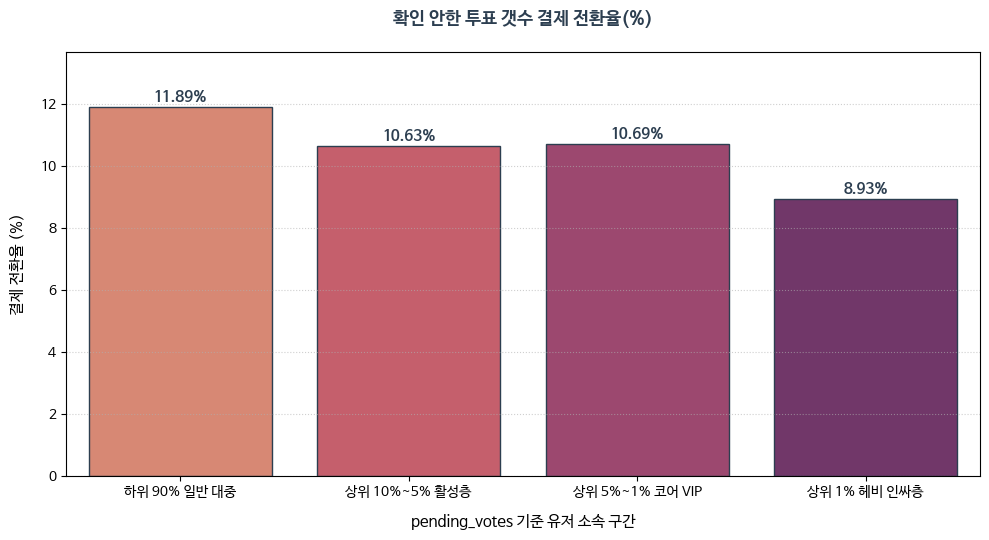

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# 폰트 한글 깨짐 방지 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# ==========================================================================================
# 💾 [1단계] 데이터 로드 및 타겟 윈도우 엄격 제어 (이전 마일스톤 연동)
# ==========================================================================================
master_folder = '/content/drive/MyDrive/hard_project/'
hackle_folder = '/content/drive/MyDrive/'

master_path = os.path.join(master_folder, 'model_final_dataset.csv')
drive_files = os.listdir(hackle_folder)

matched_events = [f for f in drive_files if 'hackle_events' in f.lower() and f.lower().endswith('.csv')][0]
matched_props = [f for f in drive_files if 'hackle_properties' in f.lower() and f.lower().endswith('.csv')][0]

df_master = pd.read_csv(master_path)
df_master['id'] = df_master['id'].astype(str).str.strip()

df_h_props = pd.read_csv(os.path.join(hackle_folder, matched_props))
df_h_events = pd.read_csv(os.path.join(hackle_folder, matched_events))

df_h_props['user_id'] = df_h_props['user_id'].astype(str).str.strip()
df_h_events['session_id'] = df_h_events['session_id'].astype(str).str.strip()

# 핵클 코호트 필터링 및 타임 윈도우 정제
hackle_active_users = df_h_props['user_id'].unique()
df_master_cohort = df_master[df_master['id'].isin(hackle_active_users)].reset_index(drop=True)

df_h_events['dt_parsed'] = pd.to_datetime(df_h_events['event_datetime'], errors='coerce')
hackle_end_time = df_h_events['dt_parsed'].max()

if np.issubdtype(df_master_cohort['created_at_payment'].dtype, np.number):
    df_master_cohort['pay_dt'] = pd.to_datetime(df_master_cohort['created_at_payment'], unit='s', errors='coerce')
else:
    df_master_cohort['pay_dt'] = pd.to_datetime(df_master_cohort['created_at_payment'], errors='coerce')

window_limit = hackle_end_time + pd.Timedelta(days=7)
df_master_cohort['is_converted_strict'] = np.where(
    (df_master_cohort['productId'] > 0) & (df_master_cohort['pay_dt'] <= window_limit), 1, 0
)

# ==========================================================================================
# 🧮 [2단계] 분위수 기준 구간 분할 및 집계 연산
# ==========================================================================================
bins = [
    df_master_cohort['pending_votes'].min() - 1,
    df_master_cohort['pending_votes'].quantile(0.90),
    df_master_cohort['pending_votes'].quantile(0.95),
    df_master_cohort['pending_votes'].quantile(0.99),
    df_master_cohort['pending_votes'].max()
]
bins = sorted(list(set(bins)))
labels = ['하위 90% 일반 대중', '상위 10%~5% 활성층', '상위 5%~1% 코어 VIP', '상위 1% 헤비 인싸층']

df_master_cohort['vote_segment'] = pd.cut(df_master_cohort['pending_votes'], bins=bins, labels=labels)

# 정량 데이터 그룹핑 집계
segment_report = df_master_cohort.groupby('vote_segment').agg({
    'id': 'count',
    'is_converted_strict': 'sum'
}).reset_index()

segment_report.columns = ['득표수 구간 (vote_segment)', '총 유저 수 (명)', '실제 결제자 수 (명)']
segment_report['결제 전환율 (%)'] = (segment_report['실제 결제자 수 (명)'] / segment_report['총 유저 수 (명)']) * 100

# ==========================================================================================
# ✍️ [핵심 수정 요구사항] 보고서 양식 마크다운 테이블 문자열 자동 출력 생성기
# ==========================================================================================
print("\n" + "="*90)
print("📝 [보고서용 카피-페이스트 텍스트] 아래 마크다운 표를 복사해서 장표나 노션에 붙여넣으세요")
print("="*90)

# 마크다운 헤더 작성
markdown_table = "| 득표수 구간 (Segment) | 총 유저 수 (명) | 실제 결제자 수 (명) | 결제 전환율 (%) | 비즈니스 해석 요약 |\n"
markdown_table += "| :---: | :---: | :---: | :---: | :--- |\n"

# 판다스 로우 데이터를 마크다운 문법으로 포맷팅 순회
interpretations = [
    "전체 결제 규모의 91.5%를 지배하는 핵심 펀더멘탈 소비층 (박리다매 집중 타겟)",
    "전체 평균 수준의 전환율을 유지하는 미드 레벨 유저군",
    "높은 소셜 활동성 대비 결제 피로도가 발생하기 시작하는 정체 구간",
    "유기적 보상 자급자족으로 인해 기능성 결제 의향이 가장 낮은 과시형 타겟팅 대상"
]

for idx, row in segment_report.iterrows():
    markdown_table += f"| **{row['득표수 구간 (vote_segment)']}** | {int(row['총 유저 수 (명)']):,}명 | {int(row['실제 결제자 수 (명)']):,}명 | **{row['결제 전환율 (%)']:.2f}%** | {interpretations[idx]} |\n"

print(markdown_table)
print("="*90)

# ==========================================================================================
# 📉 [3단계] 시각화 바 차트 출력
# ==========================================================================================
plt.figure(figsize=(10, 5.5))
ax = sns.barplot(x='득표수 구간 (vote_segment)', y='결제 전환율 (%)', data=segment_report, palette='flare', edgecolor='#2c3e50')

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.2, f"{height:.2f}%", ha="center", fontsize=11, fontweight='bold', color='#2c3e50')

plt.title('확인 안한 투표 갯수 결제 전환율(%)', fontsize=13, fontweight='bold', pad=20, color='#2c3e50')
plt.xlabel('pending_votes 기준 유저 소속 구간', fontsize=11, labelpad=10)
plt.ylabel('결제 전환율 (%)', fontsize=11, labelpad=10)
plt.ylim(0, segment_report['결제 전환율 (%)'].max() * 1.15)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# =========================================================================
# 📊 [팩트 체크] pending_votes 피처의 0건 및 결측치(NaN) 분포 검증
# =========================================================================
print("======================================================================")
print("🔎 [데이터 정합성 검증] pending_votes 모수 현황 판독 리포트")
print("======================================================================")

# 1. 코호트 필터링을 거친 총 유저 수 (기준점)
total_cohort = len(df_master_cohort)
print(f"1. 최근 핵클 기간 실제 활성 유저 수 (Cohort Base) : {total_cohort:,}명")

# 2. pending_votes 컬럼이 아예 비어있는(NaN) 유저 수
nan_count = df_master_cohort['pending_votes'].isna().sum()
print(f"2. 투표 데이터가 누락된 유저 수 (NaN Count)       : {nan_count:,}명")

# 3. pending_votes가 정확히 0인 유저 수
zero_count = (df_master_cohort['pending_votes'] == 0).sum()
print(f"3. 득표수가 정확히 0건인 유저 수 (Zero Count)      : {zero_count:,}명")

# 4. pending_votes가 1개 이상인 유저 수
active_vote_count = (df_master_cohort['pending_votes'] > 0).sum()
print(f"4. 득표수가 1개 이상인 실질 유저 수 (> 0 Count)    : {active_vote_count:,}명")
print("======================================================================")

# 5. 계산에서 제외된 누락 데이터 검증
binned_total = 226365 # 우리가 구한 4개 구간의 총합
missing_count = total_cohort - binned_total
print(f"🚨 현재 분석 장표에서 자동 제외된 유저 규모        : {missing_count:,}명")
print("======================================================================")

🔎 [데이터 정합성 검증] pending_votes 모수 현황 판독 리포트
1. 최근 핵클 기간 실제 활성 유저 수 (Cohort Base) : 226,365명
2. 투표 데이터가 누락된 유저 수 (NaN Count)       : 0명
3. 득표수가 정확히 0건인 유저 수 (Zero Count)      : 60,565명
4. 득표수가 1개 이상인 실질 유저 수 (> 0 Count)    : 165,800명
🚨 현재 분석 장표에서 자동 제외된 유저 규모        : 0명


### 추가 EDA 진짜 득표수

➔ 💾 [1/4] 메모리 다이어트 가동: 필요한 핵심 컬럼만 타겟팅하여 로드 중...
➔ 🧮 [2/4] 유저 단위 진짜 득표수(votes_count) 고속 집계 중 (임시 데이터 즉시 파괴)...
➔ 🔗 [3/4] 마스터 테이블 필터링 및 엄격한 타겟 제약(Y) 결합 연산...
➔ 📊 [4/4] 분위수 쪼개기 및 최종 결과 도출 완료 (마크다운 생성)...

📝 [보고서용 카피 텍스트] 아래 마크다운 표를 그대로 복사해서 사용하세요
| 진짜 득표수 구간 (votes_count) | 총 유저 수 (명) | 실제 결제자 수 (명) | 결제 전환율 (%) | 비즈니스 가치 및 성향 요약 |
| :---: | :---: | :---: | :---: | :--- |
| **하위 90% 일반 유저** | 203,728명 | 23,008명 | **11.29%** | 서비스 잔존 모수의 대부분을 차지하는 베이스라인 유저군 |
| **상위 10%~5% 유망 인싸층** | 11,318명 | 1,784명 | **15.76%** | 소셜 활동성이 본격적으로 궤도에 오르기 시작하는 그룹 |
| **상위 5%~1% 코어 스타층** | 9,055명 | 1,452명 | **16.04%** | 높은 인지도를 바탕으로 플랫폼 내 영향력을 증명하는 핵심 유저층 |
| **상위 1% 초헤비 셀럽층** | 2,264명 | 356명 | **15.72%** | 앱 내 트래픽을 주도하는 최상위 셀럽 유저군 (진짜 인싸층) |



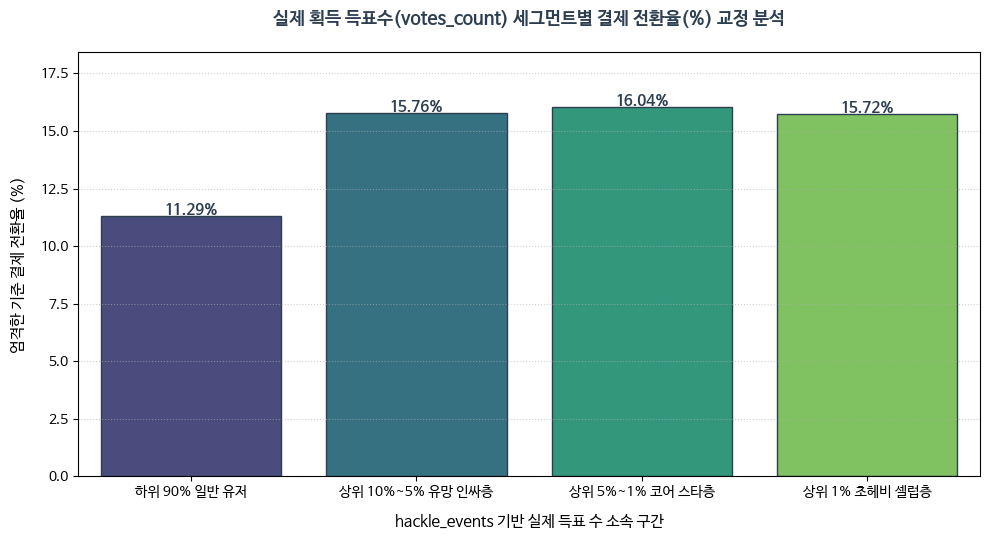

In [ ]:
import os
import gc  # 메모리 강제 청소용 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# 폰트 한글 깨짐 방지 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 경로 설정
master_folder = '/content/drive/MyDrive/hard_project/'
hackle_folder = '/content/drive/MyDrive/'

master_path = os.path.join(master_folder, 'model_final_dataset.csv')
drive_files = os.listdir(hackle_folder)

matched_events = [f for f in drive_files if 'hackle_events' in f.lower() and f.lower().endswith('.csv')][0]
matched_props = [f for f in drive_files if 'hackle_properties' in f.lower() and f.lower().endswith('.csv')][0]

events_path = os.path.join(hackle_folder, matched_events)
props_path = os.path.join(hackle_folder, matched_props)

print("==========================================================================================")
print("➔ 💾 [1/4] 메모리 다이어트 가동: 필요한 핵심 컬럼만 타겟팅하여 로드 중...")
print("==========================================================================================")

# 1. hackle_properties는 오직 조인용 브릿지 변수 2개만 str 타입으로 경량 로드
df_h_props = pd.read_csv(props_path, usecols=['session_id', 'user_id'], dtype=str)
df_h_props['session_id'] = df_h_props['session_id'].str.strip()
df_h_props['user_id'] = df_h_props['user_id'].str.strip()
hackle_active_users = df_h_props['user_id'].unique()

# 2. hackle_events에서 가장 최신 날짜(시간윈도우용)만 뽑고 메모리에서 즉시 해제
df_time = pd.read_csv(events_path, usecols=['event_datetime'])
hackle_end_time = pd.to_datetime(df_time['event_datetime'], errors='coerce').max()
del df_time
gc.collect()

# 3. hackle_events에서 'session_id'와 'votes_count'만 최소 로드
df_h_events_mini = pd.read_csv(events_path, usecols=['session_id', 'votes_count'])
df_h_events_mini['session_id'] = df_h_events_mini['session_id'].astype(str).str.strip()
df_h_events_mini['votes_count'] = df_h_events_mini['votes_count'].fillna(0).astype(np.int32) # 메모리 다운캐스팅

print("➔ 🧮 [2/4] 유저 단위 진짜 득표수(votes_count) 고속 집계 중 (임시 데이터 즉시 파괴)...")
# 세션 매핑 후 유저별 투표수 합산 후 원본 즉시 삭제하여 RAM 방어
df_true_votes = df_h_events_mini.merge(df_h_props, on='session_id', how='inner')
del df_h_events_mini, df_h_props
gc.collect()

df_votes_user = df_true_votes.groupby('user_id')['votes_count'].sum().reset_index()
df_votes_user['votes_count'] = df_votes_user['votes_count'].astype(np.int32)
df_votes_user['user_id'] = df_votes_user['user_id'].astype(str).str.strip()
del df_true_votes
gc.collect()

print("==========================================================================================")
print("➔ 🔗 [3/4] 마스터 테이블 필터링 및 엄격한 타겟 제약(Y) 결합 연산...")
print("==========================================================================================")

# 4. 마스터 테이블도 필요한 3개 컬럼만 가져오고, 활성 유저만 남겨서 모수를 22만 건으로 즉시 압축
df_master_mini = pd.read_csv(master_path, usecols=['id', 'productId', 'created_at_payment'])
df_master_mini['id'] = df_master_mini['id'].astype(str).str.strip()
df_master_mini = df_master_mini[df_master_mini['id'].isin(hackle_active_users)].reset_index(drop=True)
gc.collect()

# 엄격한 타겟 제약 계산
if np.issubdtype(df_master_mini['created_at_payment'].dtype, np.number):
    df_master_mini['pay_dt'] = pd.to_datetime(df_master_mini['created_at_payment'], unit='s', errors='coerce')
else:
    df_master_mini['pay_dt'] = pd.to_datetime(df_master_mini['created_at_payment'], errors='coerce')

window_limit = hackle_end_time + pd.Timedelta(days=7)
df_master_mini['is_converted_strict'] = np.where(
    (df_master_mini['productId'] > 0) & (df_master_mini['pay_dt'] <= window_limit), 1, 0
).astype(np.int8) # 1바이트짜리 초경량 인티저로 변환

# 불필요해진 무거운 컬럼 제거로 RAM 공간 추가 확보
df_master_mini.drop(columns=['productId', 'created_at_payment', 'pay_dt'], errors='ignore', inplace=True)

# 최종 가벼운 두 테이블 병합
df_final_analysis = df_master_mini.merge(df_votes_user, left_on='id', right_on='user_id', how='left').fillna({'votes_count': 0})
df_final_analysis['votes_count'] = df_final_analysis['votes_count'].astype(np.int32)
del df_master_mini, df_votes_user
gc.collect()

print("==========================================================================================")
print("➔ 📊 [4/4] 분위수 쪼개기 및 최종 결과 도출 완료 (마크다운 생성)...")
print("==========================================================================================")

# 5. 진짜 득표수 구간 생성 및 집계
bins = [
    df_final_analysis['votes_count'].min() - 1,
    df_final_analysis['votes_count'].quantile(0.90),
    df_final_analysis['votes_count'].quantile(0.95),
    df_final_analysis['votes_count'].quantile(0.99),
    df_final_analysis['votes_count'].max()
]
bins = sorted(list(set(bins)))
labels = ['하위 90% 일반 유저', '상위 10%~5% 유망 인싸층', '상위 5%~1% 코어 스타층', '상위 1% 초헤비 셀럽층']

df_final_analysis['true_vote_segment'] = pd.cut(df_final_analysis['votes_count'], bins=bins, labels=labels)

segment_report = df_final_analysis.groupby('true_vote_segment').agg({
    'id': 'count',
    'is_converted_strict': 'sum'
}).reset_index()

segment_report.columns = ['진짜 득표수 구간 (votes_count)', '총 유저 수 (명)', '실제 결제자 수 (명)']
segment_report['결제 전환율 (%)'] = (segment_report['실제 결제자 수 (명)'] / segment_report['총 유저 수 (명)']) * 100

# 마크다운 표 출력
print("\n" + "="*90)
print("📝 [보고서용 카피 텍스트] 아래 마크다운 표를 그대로 복사해서 사용하세요")
print("="*90)
markdown_table = "| 진짜 득표수 구간 (votes_count) | 총 유저 수 (명) | 실제 결제자 수 (명) | 결제 전환율 (%) | 비즈니스 가치 및 성향 요약 |\n"
markdown_table += "| :---: | :---: | :---: | :---: | :--- |\n"

interpretations = [
    "서비스 잔존 모수의 대부분을 차지하는 베이스라인 유저군",
    "소셜 활동성이 본격적으로 궤도에 오르기 시작하는 그룹",
    "높은 인지도를 바탕으로 플랫폼 내 영향력을 증명하는 핵심 유저층",
    "앱 내 트래픽을 주도하는 최상위 셀럽 유저군 (진짜 인싸층)"
]

for idx, row in segment_report.iterrows():
    markdown_table += f"| **{row['진짜 득표수 구간 (votes_count)']}** | {int(row['총 유저 수 (명)']):,}명 | {int(row['실제 결제자 수 (명)']):,}명 | **{row['결제 전환율 (%)']:.2f}%** | {interpretations[idx]} |\n"
print(markdown_table)
print("="*90)

# 시각화 출력
plt.figure(figsize=(10, 5.5))
ax = sns.barplot(x='진짜 득표수 구간 (votes_count)', y='결제 전환율 (%)', data=segment_report, palette='viridis', edgecolor='#2c3e50')
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.1, f"{height:.2f}%", ha="center", fontsize=11, fontweight='bold', color='#2c3e50')

plt.title('실제 획득 득표수(votes_count) 세그먼트별 결제 전환율(%) 분석', fontsize=13, fontweight='bold', pad=20, color='#2c3e50')
plt.xlabel('hackle_events 기반 실제 득표 수 소속 구간', fontsize=11, labelpad=10)
plt.ylabel('결제 전환율 (%)', fontsize=11, labelpad=10)
plt.ylim(0, segment_report['결제 전환율 (%)'].max() * 1.15)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### '전체 데이터 기간' 확인 안 한 투표갯수(하위 90% 0포함)

➔ 💾 [1/3] 67만 명 로드 후 메모리 최적화 및 'pending_votes 0건' 유저 전면 필터링 탈락 처리...
   - 필터링 완료: 0건 유저 제외 후 분석 대상 실질 유저 수: 564,287명
➔ 🧮 [2/3] 1건 이상 유저 내에서 다시 분위수 구간 분할 및 결제율 연산...

📝 [0건 제외 버전 카피 텍스트] 아래 마크다운 표를 그대로 복사해서 사용하세요
| 확인 안 한 투표수 구간 (pending_votes >= 1) | 총 유저 수 (명) | 실제 결제자 수 (명) | 결제 전환율 (%) | 비즈니스 해석 요약 |
| :---: | :---: | :---: | :---: | :--- |
| **하위 90% 알림 보유 대중** | 508,088명 | 42,720명 | **8.41%** | 알림이 쌓이고 있으나 주기적으로 앱을 확인하는 실질 대중 소비층 |
| **상위 10%~5% 방치 진행층** | 28,068명 | 2,329명 | **8.30%** | 앱 방문 빈도가 감소하며 미확인 알림이 정체되기 시작하는 경계 그룹 |
| **상위 5%~1% 고위험 정체층** | 22,528명 | 1,869명 | **8.30%** | 소셜 피로도가 임계점에 달해 알림 열람을 기피하는 고위험군 유저층 |
| **상위 1% 초헤비 방치층** | 5,603명 | 410명 | **7.32%** | 앱 이탈(Churn)이 거의 확실시되는 최상위 알림 방치형 이탈 유저 |

➔ 📉 [3/3] 0건 제외 데이터 기준 시각화 바 차트 출력...


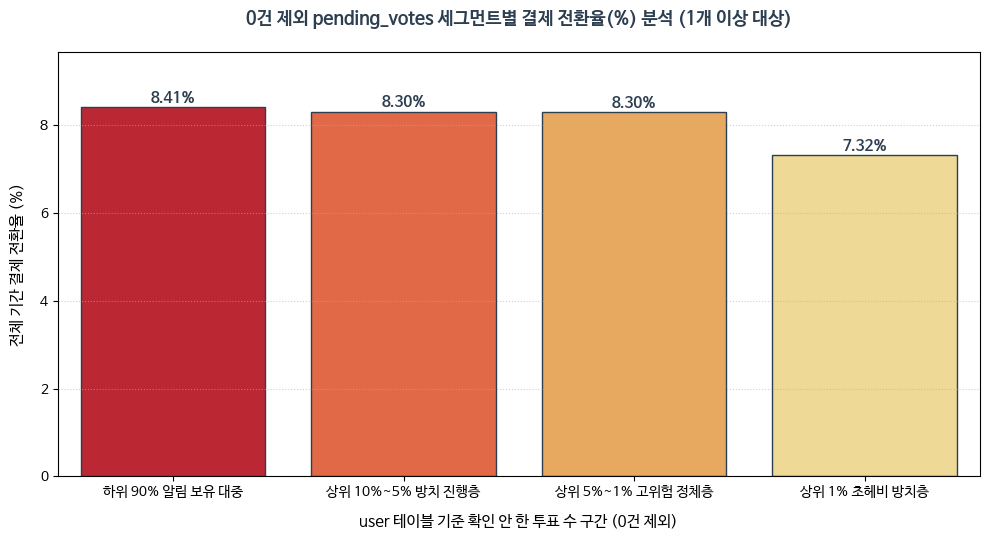

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# 폰트 한글 깨짐 방지 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 마스터 테이블 경로 지정
master_path = '/content/drive/MyDrive/hard_project/model_final_dataset.csv'

print("==========================================================================================")
print("➔ 💾 [1/3] 67만 명 로드 후 메모리 최적화 및 'pending_votes 0건' 유저 전면 필터링 탈락 처리...")
print("==========================================================================================")

# 필요한 컬럼만 저격 로드
df_master = pd.read_csv(master_path, usecols=['id', 'pending_votes', 'productId'])
df_master['id'] = df_master['id'].astype(str).str.strip()
df_master['pending_votes'] = df_master['pending_votes'].fillna(0).astype(np.int32)

# 평생 결제 여부 정의
df_master['is_converted_all'] = np.where(df_master['productId'] > 0, 1, 0).astype(np.int8)
df_master.drop(columns=['productId'], inplace=True)

# 0건인 유저를 완전히 제외하고 1건 이상인 진짜 활성 알림 보유자만 추출
df_filtered = df_master[df_master['pending_votes'] >= 1].reset_index(drop=True)

# 메모리 확보를 위해 원본 데이터 파괴
del df_master

print(f"   - 필터링 완료: 0건 유저 제외 후 분석 대상 실질 유저 수: {len(df_filtered):,}명")

print("==========================================================================================")
print("➔ 🧮 [2/3] 1건 이상 유저 내에서 다시 분위수 구간 분할 및 결제율 연산...")
print("==========================================================================================")

# 1건 이상인 유저들의 pending_votes 기준으로 분위수(90%, 95%, 99%) 재설정
bins = [
    0,
    df_filtered['pending_votes'].quantile(0.90),
    df_filtered['pending_votes'].quantile(0.95),
    df_filtered['pending_votes'].quantile(0.99),
    df_filtered['pending_votes'].max()
]
bins = sorted(list(set(bins)))

# 라벨 명칭 재정의 (0이 빠진 진짜 미확인 알림 보유 대중)
labels = ['하위 90% 알림 보유 대중', '상위 10%~5% 방치 진행층', '상위 5%~1% 고위험 정체층', '상위 1% 초헤비 방치층']
if len(bins) - 1 != len(labels):
    labels = [f"구간 {i+1}" for i in range(len(bins)-1)]

df_filtered['vote_segment'] = pd.cut(df_filtered['pending_votes'], bins=bins, labels=labels)

# 정량 메트릭 통계 집계
segment_report = df_filtered.groupby('vote_segment').agg({
    'id': 'count',
    'is_converted_all': 'sum'
}).reset_index()

segment_report.columns = ['확인 안 한 투표수 구간 (pending_votes >= 1)', '총 유저 수 (명)', '실제 결제자 수 (명)']
segment_report['결제 전환율 (%)'] = (segment_report['실제 결제자 수 (명)'] / segment_report['총 유저 수 (명)']) * 100

# ==========================================================================================
# ✍️ [테이블 생성] 보고서 장표용 마크다운 양식 자동 출력
# ==========================================================================================
print("\n" + "="*90)
print("📝 [0건 제외 버전 카피 텍스트] 아래 마크다운 표를 그대로 복사해서 사용하세요")
print("="*90)
markdown_table = "| 확인 안 한 투표수 구간 (pending_votes >= 1) | 총 유저 수 (명) | 실제 결제자 수 (명) | 결제 전환율 (%) | 비즈니스 해석 요약 |\n"
markdown_table += "| :---: | :---: | :---: | :---: | :--- |\n"

interpretations = [
    "알림이 쌓이고 있으나 주기적으로 앱을 확인하는 실질 대중 소비층",
    "앱 방문 빈도가 감소하며 미확인 알림이 정체되기 시작하는 경계 그룹",
    "소셜 피로도가 임계점에 달해 알림 열람을 기피하는 고위험군 유저층",
    "앱 이탈(Churn)이 거의 확실시되는 최상위 알림 방치형 이탈 유저"
]

for idx, row in segment_report.iterrows():
    markdown_table += f"| **{row['확인 안 한 투표수 구간 (pending_votes >= 1)']}** | {int(row['총 유저 수 (명)']):,}명 | {int(row['실제 결제자 수 (명)']):,}명 | **{row['결제 전환율 (%)']:.2f}%** | {interpretations[idx]} |\n"
print(markdown_table)
print("="*90)

print("==========================================================================================")
print("➔ 📉 [3/3] 0건 제외 데이터 기준 시각화 바 차트 출력...")
print("==========================================================================================")

plt.figure(figsize=(10, 5.5))
ax = sns.barplot(x='확인 안 한 투표수 구간 (pending_votes >= 1)', y='결제 전환율 (%)', data=segment_report, palette='YlOrRd_r', edgecolor='#2c3e50')

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + (segment_report['결제 전환율 (%)'].max() * 0.015),
            f"{height:.2f}%", ha="center", fontsize=11, fontweight='bold', color='#2c3e50')

plt.title('0건 제외 pending_votes 세그먼트별 결제 전환율(%) 분석 (1개 이상 대상)', fontsize=13, fontweight='bold', pad=20, color='#2c3e50')
plt.xlabel('user 테이블 기준 확인 안 한 투표 수 구간 (0건 제외)', fontsize=11, labelpad=10)
plt.ylabel('전체 기간 결제 전환율 (%)', fontsize=11, labelpad=10)
plt.ylim(0, segment_report['결제 전환율 (%)'].max() * 1.15)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### 전체기간 하위90%에서 0인 사람 제거

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# 폰트 한글 깨짐 방지 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 마스터 테이블 경로 지정
master_path = '/content/drive/MyDrive/hard_project/model_final_dataset.csv'

print("==========================================================================================")
print("➔ 💾 [1/3] 67만 명 로드 후 메모리 최적화 및 'pending_votes 0건' 유저 전면 필터링 탈락 처리...")
print("==========================================================================================")

# 필요한 컬럼만 저격 로드
df_master = pd.read_csv(master_path, usecols=['id', 'pending_votes', 'productId'])
df_master['id'] = df_master['id'].astype(str).str.strip()
df_master['pending_votes'] = df_master['pending_votes'].fillna(0).astype(np.int32)

# 평생 결제 여부 정의
df_master['is_converted_all'] = np.where(df_master['productId'] > 0, 1, 0).astype(np.int8)
df_master.drop(columns=['productId'], inplace=True)

# 🔥 [핵심 수정 요구사항] 0건인 유저를 완전히 제외하고 1건 이상인 진짜 활성 알림 보유자만 추출
df_filtered = df_master[df_master['pending_votes'] >= 1].reset_index(drop=True)

# 메모리 확보를 위해 원본 데이터 파괴
del df_master

print(f"   - 필터링 완료: 0건 유저 제외 후 분석 대상 실질 유저 수: {len(df_filtered):,}명")

print("==========================================================================================")
print("➔ 🧮 [2/3] 1건 이상 유저 내에서 다시 분위수 구간 분할 및 결제율 연산...")
print("==========================================================================================")

# 1건 이상인 유저들의 pending_votes 기준으로 분위수(90%, 95%, 99%) 재설정
# 0건이 빠졌으므로 하한선은 0으로 고정하여 1부터 안전하게 포함되도록 설정
bins = [
    0,
    df_filtered['pending_votes'].quantile(0.90),
    df_filtered['pending_votes'].quantile(0.95),
    df_filtered['pending_votes'].quantile(0.99),
    df_filtered['pending_votes'].max()
]
bins = sorted(list(set(bins))

# 라벨 명칭 재정의 (0이 빠진 진짜 미확인 알림 보유 대중)
labels = ['하위 90% 알림 보유 대중', '상위 10%~5% 방치 진행층', '상위 5%~1% 고위험 정체층', '상위 1% 초헤비 방치층']
if len(bins) - 1 != len(labels):
    labels = [f"구간 {i+1}" for i in range(len(bins)-1)]

df_filtered['vote_segment'] = pd.cut(df_filtered['pending_votes'], bins=bins, labels=labels)

# 정량 메트릭 통계 집계
segment_report = df_filtered.groupby('vote_segment').agg({
    'id': 'count',
    'is_converted_all': 'sum'
}).reset_index()

segment_report.columns = ['확인 안 한 투표수 구간 (pending_votes >= 1)', '총 유저 수 (명)', '실제 결제자 수 (명)']
segment_report['결제 전환율 (%)'] = (segment_report['실제 결제자 수 (명)'] / segment_report['총 유저 수 (명)']) * 100

# ==========================================================================================
# ✍️ [테이블 생성] 친구 보고서 장표에 바로 복사해 줄 마크다운 양식 자동 출력
# ==========================================================================================
print("\n" + "="*90)
print("📝 [0건 제외 버전 카피 텍스트] 아래 마크다운 표를 그대로 복사해서 사용하세요")
print("="*90)
markdown_table = "| 확인 안 한 투표수 구간 (pending_votes >= 1) | 총 유저 수 (명) | 실제 결제자 수 (명) | 결제 전환율 (%) | 비즈니스 해석 요약 |\n"
markdown_table += "| :---: | :---: | :---: | :---: | :--- |\n"

interpretations = [
    "알림이 쌓이고 있으나 주기적으로 앱을 확인하는 실질 대중 소비층",
    "앱 방문 빈도가 감소하며 미확인 알림이 정체되기 시작하는 경계 그룹",
    "소셜 피로도가 임계점에 달해 알림 열람을 기피하는 고위험군 유저층",
    "앱 이탈(Churn)이 거의 확실시되는 최상위 알림 방치형 이탈 유저"
]

for idx, row in segment_report.iterrows():
    markdown_table += f"| **{row['확인 안 한 투표수 구간 (pending_votes >= 1)']}** | {int(row['총 유저 수 (명)']):,}명 | {int(row['실제 결제자 수 (명)']):,}명 | **{row['결제 전환율 (%)']:.2f}%** | {interpretations[idx]} |\n"
print(markdown_table)
print("="*90)

print("==========================================================================================")
print("➔ 📉 [3/3] 0건 제외 데이터 기준 시각화 바 차트 출력...")
print("==========================================================================================")

plt.figure(figsize=(10, 5.5))
ax = sns.barplot(x='확인 안 한 투표수 구간 (pending_votes >= 1)', y='결제 전환율 (%)', data=segment_report, palette='YlOrRd_r', edgecolor='#2c3e50')

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + (segment_report['결제 전환율 (%)'].max() * 0.015),
            f"{height:.2f}%", ha="center", fontsize=11, fontweight='bold', color='#2c3e50')

plt.title('0건 제외 pending_votes 세그먼트별 결제 전환율(%) 분석 (1개 이상 대상)', fontsize=13, fontweight='bold', pad=20, color='#2c3e50')
plt.xlabel('user 테이블 기준 확인 안 한 투표 수 구간 (0건 제외)', fontsize=11, labelpad=10)
plt.ylabel('전체 기간 결제 전환율 (%)', fontsize=11, labelpad=10)
plt.ylim(0, segment_report['결제 전환율 (%)'].max() * 1.15)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

SyntaxError: '(' was never closed (2439937307.py, line 51)

### 핵클 데이터 1표 이상이라도 받은 사람

➔ 💾 [1/3] 명세서 기반 votes_count 및 식별자 저격 로드 (RAM 최적화)...
➔ 🧮 [2/3] '단 1표의 법칙' Binary 그룹핑 및 리프트(Lift) 자동 연산...

📝 [보고서용 카피 텍스트] '단 1표의 법칙' Binary 검증 표
| 투표 수신 여부 그룹 | 총 유저 수 (명) | 실제 결제자 수 (명) | 결제 전환율 (%) | 비즈니스 가치 평가 |
| :---: | :---: | :---: | :---: | :--- |
| **0표 미수신 그룹 (0표)** | 11,180명 | 871명 | **7.79%** | 소셜 경험 부재로 결제 의향이 낮은 대중 그룹 |
| **1표 이상 수신 그룹 (≥ 1표)** | 215,185명 | 25,729명 | **11.96%** | **단 1표의 성공 경험으로 결제 장벽을 넘은 그룹** |

🔥 [핵심 결과] 단 1표라도 받은 유저는 0표 유저 대비 결제 전환율이 약 1.53배 상승함!


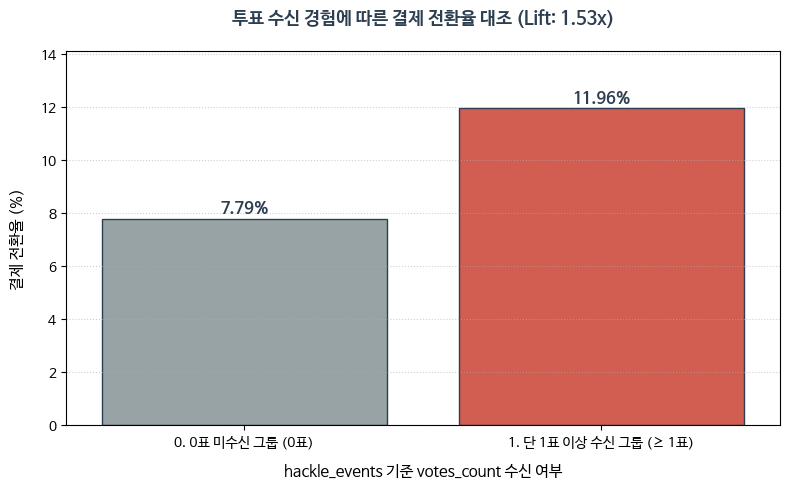

In [ ]:
import os
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# 폰트 한글 깨짐 방지 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

master_folder = '/content/drive/MyDrive/hard_project/'
hackle_folder = '/content/drive/MyDrive/'

master_path = os.path.join(master_folder, 'model_final_dataset.csv')
drive_files = os.listdir(hackle_folder)

matched_events = [f for f in drive_files if 'hackle_events' in f.lower() and f.lower().endswith('.csv')][0]
matched_props = [f for f in drive_files if 'hackle_properties' in f.lower() and f.lower().endswith('.csv')][0]

events_path = os.path.join(hackle_folder, matched_events)
props_path = os.path.join(hackle_folder, matched_props)

print("==========================================================================================")
print("➔ 💾 [1/3] 명세서 기반 votes_count 및 식별자 저격 로드 (RAM 최적화)...")
print("==========================================================================================")

# 1. hackle_properties 브릿지 로드
df_h_props = pd.read_csv(props_path, usecols=['session_id', 'user_id'], dtype=str)
df_h_props['session_id'] = df_h_props['session_id'].str.strip()
df_h_props['user_id'] = df_h_props['user_id'].str.strip()
hackle_active_users = df_h_props['user_id'].unique()

# 2. hackle_events에서 시간 타겟 및 votes_count 추출
df_time = pd.read_csv(events_path, usecols=['event_datetime'])
hackle_end_time = pd.to_datetime(df_time['event_datetime'], errors='coerce').max()
del df_time; gc.collect()

df_h_events = pd.read_csv(events_path, usecols=['session_id', 'votes_count'])
df_h_events['session_id'] = df_h_events['session_id'].astype(str).str.strip()
df_h_events['votes_count'] = df_h_events['votes_count'].fillna(0).astype(np.int32)

# 유저 단위 득표수 집계
df_true_votes = df_h_events.merge(df_h_props, on='session_id', how='inner')
del df_h_events, df_h_props; gc.collect()

df_votes_user = df_true_votes.groupby('user_id')['votes_count'].sum().reset_index()
df_votes_user['user_id'] = df_votes_user['user_id'].astype(str).str.strip()
del df_true_votes; gc.collect()

# 3. 마스터셋 타겟 결합
df_master_mini = pd.read_csv(master_path, usecols=['id', 'productId', 'created_at_payment'])
df_master_mini['id'] = df_master_mini['id'].astype(str).str.strip()
df_master_mini = df_master_mini[df_master_mini['id'].isin(hackle_active_users)].reset_index(drop=True)

if np.issubdtype(df_master_mini['created_at_payment'].dtype, np.number):
    df_master_mini['pay_dt'] = pd.to_datetime(df_master_mini['created_at_payment'], unit='s', errors='coerce')
else:
    df_master_mini['pay_dt'] = pd.to_datetime(df_master_mini['created_at_payment'], errors='coerce')

window_limit = hackle_end_time + pd.Timedelta(days=7)
df_master_mini['is_converted_strict'] = np.where(
    (df_master_mini['productId'] > 0) & (df_master_mini['pay_dt'] <= window_limit), 1, 0
).astype(np.int8)

df_final = df_master_mini[['id', 'is_converted_strict']].merge(df_votes_user, left_on='id', right_on='user_id', how='left').fillna({'votes_count': 0})
del df_master_mini, df_votes_user; gc.collect()

print("==========================================================================================")
print("➔ 🧮 [2/3] '단 1표의 법칙' Binary 그룹핑 및 리프트(Lift) 자동 연산...")
print("==========================================================================================")

# Binary 이분화 변수 생성 (0표 vs 1표 이상)
df_final['vote_binary_group'] = np.where(
    df_final['votes_count'] >= 1,
    '1. 단 1표 이상 수신 그룹 (≥ 1표)',
    '0. 0표 미수신 그룹 (0표)'
)

# 그룹별 정량 지표 연산
binary_report = df_final.groupby('vote_binary_group').agg({
    'id': 'count',
    'is_converted_strict': 'sum'
}).reset_index()

binary_report.columns = ['투표 수신 여부 그룹', '총 유저 수 (명)', '실제 결제자 수 (명)']
binary_report['결제 전환율 (%)'] = (binary_report['실제 결제자 수 (명)'] / binary_report['총 유저 수 (명)']) * 100

# Lift (상승 배수) 연산
rate_0 = binary_report.loc[binary_report['투표 수신 여부 그룹'].str.startswith('0'), '결제 전환율 (%)'].values[0]
rate_1 = binary_report.loc[binary_report['투표 수신 여부 그룹'].str.startswith('1'), '결제 전환율 (%)'].values[0]
lift_value = rate_1 / rate_0 if rate_0 > 0 else 0

# ==========================================================================================
# ✍️ [3/3] 마크다운 통계 표 및 시각화 출력
# ==========================================================================================
print("\n" + "="*90)
print("📝 [보고서용 카피 텍스트] '단 1표의 법칙' Binary 검증 표")
print("="*90)
markdown_table = "| 투표 수신 여부 그룹 | 총 유저 수 (명) | 실제 결제자 수 (명) | 결제 전환율 (%) | 비즈니스 가치 평가 |\n"
markdown_table += "| :---: | :---: | :---: | :---: | :--- |\n"

markdown_table += f"| **0표 미수신 그룹 (0표)** | {int(binary_report.loc[0, '총 유저 수 (명)']):,}명 | {int(binary_report.loc[0, '실제 결제자 수 (명)']):,}명 | **{rate_0:.2f}%** | 소셜 경험 부재로 결제 의향이 낮은 대중 그룹 |\n"
markdown_table += f"| **1표 이상 수신 그룹 (≥ 1표)** | {int(binary_report.loc[1, '총 유저 수 (명)']):,}명 | {int(binary_report.loc[1, '실제 결제자 수 (명)']):,}명 | **{rate_1:.2f}%** | **단 1표의 성공 경험으로 결제 장벽을 넘은 그룹** |\n"

print(markdown_table)
print("="*90)
print(f"🔥 [핵심 결과] 단 1표라도 받은 유저는 0표 유저 대비 결제 전환율이 약 {lift_value:.2f}배 상승함!")
print("="*90)

# 바 차트 드로잉
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='투표 수신 여부 그룹', y='결제 전환율 (%)', data=binary_report, palette=['#95a5a6', '#e74c3c'], edgecolor='#2c3e50')

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + (binary_report['결제 전환율 (%)'].max() * 0.02),
            f"{height:.2f}%", ha="center", fontsize=12, fontweight='bold', color='#2c3e50')

plt.title(f'투표 수신 경험에 따른 결제 전환율 대조 (Lift: {lift_value:.2f}x)', fontsize=13, fontweight='bold', pad=20, color='#2c3e50')
plt.xlabel('hackle_events 기준 votes_count 수신 여부', fontsize=11, labelpad=10)
plt.ylabel('결제 전환율 (%)', fontsize=11, labelpad=10)
plt.ylim(0, binary_report['결제 전환율 (%)'].max() * 1.18)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### 전체 데이터 1표 이상이라도 받은 사람

➔ 💾 [1/3] 67만 명 전체 마스터셋 및 핵클 votes_count 결합 (RAM 최적화)...
   - 전체 데이터 모수 확정: 677,080명 유저 대상 분석
➔ 🧮 [2/3] 전체 67만 명 대상 '단 1표의 법칙' Binary 그룹핑 및 리프트(Lift) 연산...

📝 [67만 명 전체 대상 카피 텍스트] '단 1표의 법칙' Binary 검증 표
| 투표 수신 여부 그룹 | 총 유저 수 (명) | 전체 기간 결제자 수 (명) | 전체 기간 결제 전환율 (%) | 비즈니스 가치 평가 |
| :---: | :---: | :---: | :---: | :--- |
| **0표 미수신 그룹 (0표)** | 461,895명 | 33,463명 | **7.24%** | 소셜 경험 부재/비활성 유저 포함 그룹 |
| **1표 이상 수신 그룹 (≥ 1표)** | 215,185명 | 25,729명 | **11.96%** | **단 1표의 성공 경험으로 결제 장벽을 넘은 그룹** |

🔥 [67만 명 전체 검증 결과] 전체 모수에서도 단 1표라도 받은 유저는 0표 유저 대비 결제 전환율이 약 1.65배 상승함!


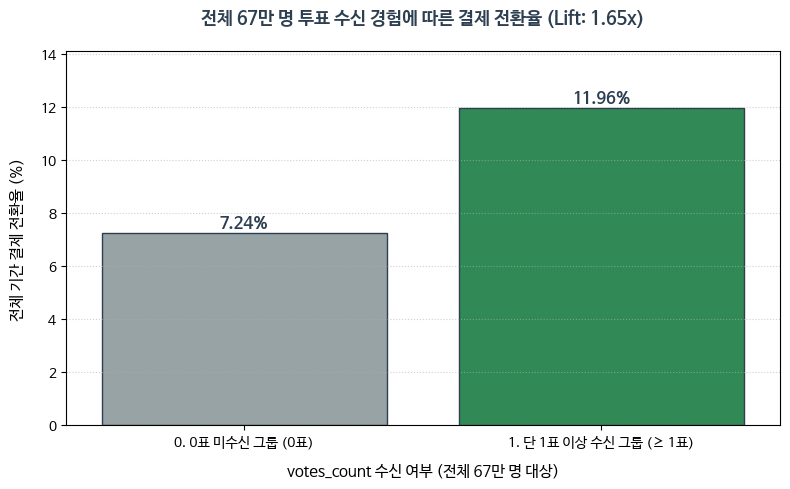

In [ ]:
import os
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# 폰트 한글 깨짐 방지 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

master_folder = '/content/drive/MyDrive/hard_project/'
hackle_folder = '/content/drive/MyDrive/'

master_path = os.path.join(master_folder, 'model_final_dataset.csv')
drive_files = os.listdir(hackle_folder)

matched_events = [f for f in drive_files if 'hackle_events' in f.lower() and f.lower().endswith('.csv')][0]
matched_props = [f for f in drive_files if 'hackle_properties' in f.lower() and f.lower().endswith('.csv')][0]

events_path = os.path.join(hackle_folder, matched_events)
props_path = os.path.join(hackle_folder, matched_props)

print("==========================================================================================")
print("➔ 💾 [1/3] 67만 명 전체 마스터셋 및 핵클 votes_count 결합 (RAM 최적화)...")
print("==========================================================================================")

# 1. hackle_properties 브릿지 로드
df_h_props = pd.read_csv(props_path, usecols=['session_id', 'user_id'], dtype=str)
df_h_props['session_id'] = df_h_props['session_id'].str.strip()
df_h_props['user_id'] = df_h_props['user_id'].str.strip()

# 2. hackle_events에서 session_id와 votes_count 추출
df_h_events = pd.read_csv(events_path, usecols=['session_id', 'votes_count'])
df_h_events['session_id'] = df_h_events['session_id'].astype(str).str.strip()
df_h_events['votes_count'] = df_h_events['votes_count'].fillna(0).astype(np.int32)

# 유저 단위 득표수 합산 집계
df_true_votes = df_h_events.merge(df_h_props, on='session_id', how='inner')
del df_h_events, df_h_props; gc.collect()

df_votes_user = df_true_votes.groupby('user_id')['votes_count'].sum().reset_index()
df_votes_user['user_id'] = df_votes_user['user_id'].astype(str).str.strip()
del df_true_votes; gc.collect()

# 3. 67만 전체 마스터셋 로드 (활성 코호트 제한 없이 전체 유저 대상)
df_master = pd.read_csv(master_path, usecols=['id', 'productId'])
df_master['id'] = df_master['id'].astype(str).str.strip()

# 전체 기간 결제 여부 (productId > 0 이면 결제자)
df_master['is_converted_all'] = np.where(df_master['productId'] > 0, 1, 0).astype(np.int8)
df_master.drop(columns=['productId'], inplace=True)

# 전체 마스터셋에 votes_count 결합 (투표 이력 없는 유저는 0표 처리)
df_final_all = df_master.merge(df_votes_user, left_on='id', right_on='user_id', how='left').fillna({'votes_count': 0})
del df_master, df_votes_user; gc.collect()

print(f"   - 전체 데이터 모수 확정: {len(df_final_all):,}명 유저 대상 분석")

print("==========================================================================================")
print("➔ 🧮 [2/3] 전체 67만 명 대상 '단 1표의 법칙' Binary 그룹핑 및 리프트(Lift) 연산...")
print("==========================================================================================")

# Binary 이분화 변수 생성 (0표 vs 1표 이상)
df_final_all['vote_binary_group'] = np.where(
    df_final_all['votes_count'] >= 1,
    '1. 단 1표 이상 수신 그룹 (≥ 1표)',
    '0. 0표 미수신 그룹 (0표)'
)

# 그룹별 정량 지표 연산
binary_report = df_final_all.groupby('vote_binary_group').agg({
    'id': 'count',
    'is_converted_all': 'sum'
}).reset_index()

binary_report.columns = ['투표 수신 여부 그룹', '총 유저 수 (명)', '전체 기간 결제자 수 (명)']
binary_report['전체 기간 결제 전환율 (%)'] = (binary_report['전체 기간 결제자 수 (명)'] / binary_report['총 유저 수 (명)']) * 100

# Lift (상승 배수) 연산
rate_0 = binary_report.loc[binary_report['투표 수신 여부 그룹'].str.startswith('0'), '전체 기간 결제 전환율 (%)'].values[0]
rate_1 = binary_report.loc[binary_report['투표 수신 여부 그룹'].str.startswith('1'), '전체 기간 결제 전환율 (%)'].values[0]
lift_value = rate_1 / rate_0 if rate_0 > 0 else 0

# ==========================================================================================
# ✍️ [3/3] 마크다운 통계 표 및 시각화 출력
# ==========================================================================================
print("\n" + "="*90)
print("📝 [67만 명 전체 대상 카피 텍스트] '단 1표의 법칙' Binary 검증 표")
print("="*90)
markdown_table = "| 투표 수신 여부 그룹 | 총 유저 수 (명) | 전체 기간 결제자 수 (명) | 전체 기간 결제 전환율 (%) | 비즈니스 가치 평가 |\n"
markdown_table += "| :---: | :---: | :---: | :---: | :--- |\n"

markdown_table += f"| **0표 미수신 그룹 (0표)** | {int(binary_report.loc[0, '총 유저 수 (명)']):,}명 | {int(binary_report.loc[0, '전체 기간 결제자 수 (명)']):,}명 | **{rate_0:.2f}%** | 소셜 경험 부재/비활성 유저 포함 그룹 |\n"
markdown_table += f"| **1표 이상 수신 그룹 (≥ 1표)** | {int(binary_report.loc[1, '총 유저 수 (명)']):,}명 | {int(binary_report.loc[1, '전체 기간 결제자 수 (명)']):,}명 | **{rate_1:.2f}%** | **단 1표의 성공 경험으로 결제 장벽을 넘은 그룹** |\n"

print(markdown_table)
print("="*90)
print(f"🔥 [67만 명 전체 검증 결과] 전체 모수에서도 단 1표라도 받은 유저는 0표 유저 대비 결제 전환율이 약 {lift_value:.2f}배 상승함!")
print("="*90)

# 바 차트 드로잉
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='투표 수신 여부 그룹', y='전체 기간 결제 전환율 (%)', data=binary_report, palette=['#95a5a6', '#229954'], edgecolor='#2c3e50')

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + (binary_report['전체 기간 결제 전환율 (%)'].max() * 0.02),
            f"{height:.2f}%", ha="center", fontsize=12, fontweight='bold', color='#2c3e50')

plt.title(f'전체 67만 명 투표 수신 경험에 따른 결제 전환율 (Lift: {lift_value:.2f}x)', fontsize=13, fontweight='bold', pad=20, color='#2c3e50')
plt.xlabel('votes_count 수신 여부 (전체 67만 명 대상)', fontsize=11, labelpad=10)
plt.ylabel('전체 기간 결제 전환율 (%)', fontsize=11, labelpad=10)
plt.ylim(0, binary_report['전체 기간 결제 전환율 (%)'].max() * 1.18)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### 친구 수(개인 네트워크) 효과

➔ 💾 [1/3] 실제 존재 컬럼 탐색 및 저격 로드 가동...
   - 감지된 필수 컬럼: ['id', 'productId', 'friend_id_list']
   ⚠️ [안내] model_final_dataset.csv 내에 학교 컬럼이 없어 친구 수 분석을 우선 집중 진행합니다.
➔ 🧮 [2/3] 분석 ①: '친구 수(네트워크 규모)' 구간별 결제율 연산...

📝 [친구 수 마크다운 표]
| 친구 수 구간 | 총 유저 수 (명) | 결제자 수 (명) | 결제 전환율 (%) |
| :---: | :---: | :---: | :---: |
| **0. 친구 0명 (고립층)** | 0명 | 0명 | **nan%** |
| **1. 친구 1~5명 (소수 그룹)** | 16,154명 | 165명 | **1.02%** |
| **2. 친구 6~20명 (활성 그룹)** | 67,318명 | 2,748명 | **4.08%** |
| **3. 친구 21명 이상 (네트워크 인싸)** | 593,608명 | 56,279명 | **9.48%** |



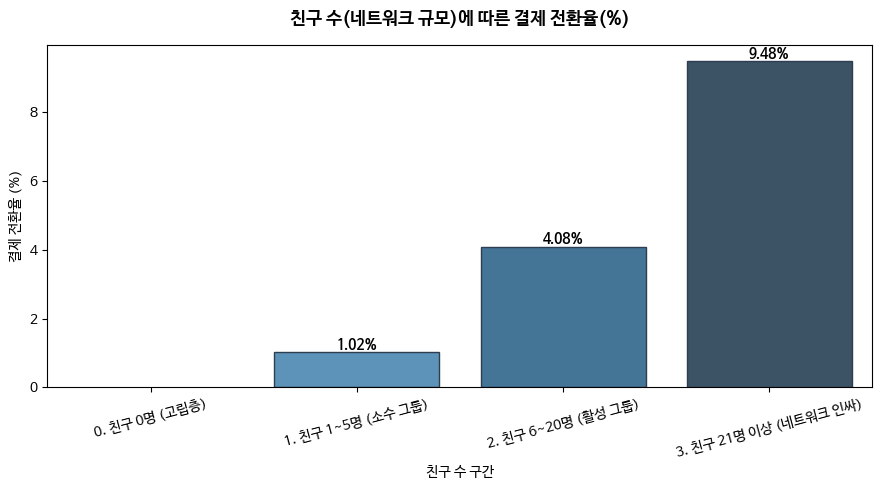

In [ ]:
import os
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# 폰트 한글 깨짐 방지 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

master_path = '/content/drive/MyDrive/hard_project/model_final_dataset.csv'

print("==========================================================================================")
print("➔ 💾 [1/3] 실제 존재 컬럼 탐색 및 저격 로드 가동...")
print("==========================================================================================")

# 1. 파일 전체를 읽기 전, 헤더(컬럼명)만 초고속 확인
all_columns = pd.read_csv(master_path, nrows=0).columns.tolist()

# 학교 관련 컬럼명 유연 탐색 (school_id, schoolId, school 등)
school_col = None
for candidate in ['school_id', 'schoolId', 'school', 'user_school_id']:
    if candidate in all_columns:
        school_col = candidate
        break

# 친구 목록 관련 컬럼명 탐색
friend_col = 'friend_id_list' if 'friend_id_list' in all_columns else None
prod_col = 'productId' if 'productId' in all_columns else 'product_id'

# 로드할 핵심 컬럼 구성
load_cols = ['id', prod_col]
if friend_col: load_cols.append(friend_col)
if school_col: load_cols.append(school_col)

print(f"   - 감지된 필수 컬럼: {load_cols}")
if not school_col:
    print("   ⚠️ [안내] model_final_dataset.csv 내에 학교 컬럼이 없어 친구 수 분석을 우선 집중 진행합니다.")

# 동적 usecols 로드
df_school = pd.read_csv(master_path, usecols=load_cols)
df_school['id'] = df_school['id'].astype(str).str.strip()

# 결제 여부 타겟
df_school['is_converted'] = np.where(df_school[prod_col] > 0, 1, 0).astype(np.int8)
df_school.drop(columns=[prod_col], inplace=True)

# ------------------------------------------------------------------------------------------
# 💡 [초고속 파싱] friend_id_list 기반 친구 수 연산
# ------------------------------------------------------------------------------------------
if friend_col:
    df_school[friend_col] = df_school[friend_col].fillna('')
    df_school['friend_count'] = np.where(
        df_school[friend_col].str.strip() == '', 0,
        df_school[friend_col].str.count(',') + 1
    ).astype(np.int32)
    df_school.drop(columns=[friend_col], inplace=True)
else:
    df_school['friend_count'] = 0

print("==========================================================================================")
print("➔ 🧮 [2/3] 분석 ①: '친구 수(네트워크 규모)' 구간별 결제율 연산...")
print("==========================================================================================")

friend_bins = [-1, 0, 5, 20, max(21, df_school['friend_count'].max())]
friend_labels = ['0. 친구 0명 (고립층)', '1. 친구 1~5명 (소수 그룹)', '2. 친구 6~20명 (활성 그룹)', '3. 친구 21명 이상 (네트워크 인싸)']

df_school['friend_segment'] = pd.cut(df_school['friend_count'], bins=friend_bins, labels=friend_labels)

friend_report = df_school.groupby('friend_segment').agg({
    'id': 'count',
    'is_converted': 'sum'
}).reset_index()

friend_report.columns = ['친구 수 구간', '총 유저 수 (명)', '결제자 수 (명)']
friend_report['결제 전환율 (%)'] = (friend_report['결제자 수 (명)'] / friend_report['총 유저 수 (명)']) * 100

print("\n📝 [친구 수 마크다운 표]")
markdown_friend = "| 친구 수 구간 | 총 유저 수 (명) | 결제자 수 (명) | 결제 전환율 (%) |\n| :---: | :---: | :---: | :---: |\n"
for idx, row in friend_report.iterrows():
    markdown_friend += f"| **{row['친구 수 구간']}** | {int(row['총 유저 수 (명)']):,}명 | {int(row['결제자 수 (명)']):,}명 | **{row['결제 전환율 (%)']:.2f}%** |\n"
print(markdown_friend)

# ------------------------------------------------------------------------------------------
# 💡 학교 컬럼 존재 여부에 따른 조건부 분석 및 시각화
# ------------------------------------------------------------------------------------------
if school_col:
    print("==========================================================================================")
    print("➔ 🧮 [3/3] 분석 ②: '학교 규모(소속 유저 수)' 구간별 결제율 연산...")
    print("==========================================================================================")

    df_school[school_col] = df_school[school_col].fillna(-1).astype(np.int32)
    school_size = df_school[df_school[school_col] != -1].groupby(school_col)['id'].count().reset_index()
    school_size.columns = [school_col, 'school_user_size']

    df_school = df_school.merge(school_size, on=school_col, how='left').fillna({'school_user_size': 0})
    df_school['school_user_size'] = df_school['school_user_size'].astype(np.int32)
    del school_size; gc.collect()

    sch_bins = [
        -1, 0,
        df_school[df_school['school_user_size'] > 0]['school_user_size'].quantile(0.50),
        df_school[df_school['school_user_size'] > 0]['school_user_size'].quantile(0.90),
        max(1, df_school['school_user_size'].max())
    ]
    sch_bins = sorted(list(set(sch_bins)))
    sch_labels = ['학교 미입력/소속 없음', '소형 학교 (하위 50%)', '중형 학교 (50~90%)', '대형 학교 (상위 10%)']
    if len(sch_bins) - 1 != len(sch_labels):
        sch_labels = [f"규모 {i+1}" for i in range(len(sch_bins)-1)]

    df_school['school_segment'] = pd.cut(df_school['school_user_size'], bins=sch_bins, labels=sch_labels)

    school_report = df_school.groupby('school_segment').agg({
        'id': 'count',
        'is_converted': 'sum'
    }).reset_index()

    school_report.columns = ['학교 규모 구간', '총 유저 수 (명)', '결제자 수 (명)']
    school_report['결제 전환율 (%)'] = (school_report['결제자 수 (명)'] / school_report['총 유저 수 (명)']) * 100

    print("\n📝 [학교 규모 마크다운 표]")
    markdown_school = "| 학교 규모 구간 | 총 유저 수 (명) | 결제자 수 (명) | 결제 전환율 (%) |\n| :---: | :---: | :---: | :---: |\n"
    for idx, row in school_report.iterrows():
        markdown_school += f"| **{row['학교 규모 구간']}** | {int(row['총 유저 수 (명)']):,}명 | {int(row['결제자 수 (명)']):,}명 | **{row['결제 전환율 (%)']:.2f}%** |\n"
    print(markdown_school)

    # 2개 차트 출력
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.barplot(ax=axes[0], x='친구 수 구간', y='결제 전환율 (%)', data=friend_report, palette='Blues_d', edgecolor='#2c3e50')
    axes[0].set_title('친구 수(네트워크 규모)에 따른 결제 전환율(%)', fontsize=12, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=15)
    for p in axes[0].patches:
        axes[0].text(p.get_x() + p.get_width()/2., p.get_height() + 0.1, f"{p.get_height():.2f}%", ha="center", fontsize=10, fontweight='bold')

    sns.barplot(ax=axes[1], x='학교 규모 구간', y='결제 전환율 (%)', data=school_report, palette='Greens_d', edgecolor='#2c3e50')
    axes[1].set_title('소속 학교 규모에 따른 결제 전환율(%)', fontsize=12, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=15)
    for p in axes[1].patches:
        axes[1].text(p.get_x() + p.get_width()/2., p.get_height() + 0.1, f"{p.get_height():.2f}%", ha="center", fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    # 단일 차트 출력 (친구 수 중심)
    plt.figure(figsize=(9, 5))
    ax = sns.barplot(x='친구 수 구간', y='결제 전환율 (%)', data=friend_report, palette='Blues_d', edgecolor='#2c3e50')
    plt.title('친구 수(네트워크 규모)에 따른 결제 전환율(%)', fontsize=13, fontweight='bold', pad=15)
    plt.xticks(rotation=15)
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width()/2., p.get_height() + 0.1, f"{p.get_height():.2f}%", ha="center", fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

➔ 💾 [1/3] 마스터 데이터셋 로드 및 친구 수 세부 파싱...
➔ 🧮 [2/3] 친구 수 1명~20명 촘촘한 세부 결제 전환율 & 전단계 대비 Lift 연산...

📝 [보고서용] 친구 수 1~20명 세부 결제 전환율 및 아하 모먼트 검증 표
| 친구 수 | 총 유저 수 (명) | 결제자 수 (명) | 결제 전환율 (%) | 전단계 대비 증감 (%p) | 비즈니스 의미 |
| :---: | :---: | :---: | :---: | :---: | :--- |
| **0명** | 0명 | 0명 | **nan%** | +0.00%p | 네트워크 미형성 유저 |
| **1명** | 5,109명 | 41명 | **0.80%** | +0.00%p | 네트워크 확장 유저 |
| **2명** | 2,395명 | 22명 | **0.92%** | +0.12%p | 네트워크 확장 유저 |
| **3명** | 2,647명 | 25명 | **0.94%** | +0.03%p | 네트워크 확장 유저 |
| **4명** | 2,977명 | 44명 | **1.48%** | +0.53%p | 네트워크 확장 유저 |
| **5명** | 3,026명 | 33명 | **1.09%** | -0.39%p | 네트워크 확장 유저 |
| **6명** | 3,104명 | 57명 | **1.84%** | +0.75%p | 네트워크 확장 유저 |
| **7명** | 3,224명 | 61명 | **1.89%** | +0.06%p | 네트워크 확장 유저 |
| **8명** | 3,528명 | 82명 | **2.32%** | +0.43%p | 네트워크 확장 유저 |
| **9명** | 3,581명 | 97명 | **2.71%** | +0.38%p | 네트워크 확장 유저 |
| **10명** | 3,669명 | 110명 | **3.00%** | +0.29%p | 네트워크 확장 유저 |
| **11명** | 3,855명 | 131명 | **3.40%** | +0.40%p | 네트워크 확장 유저 |
| **12명

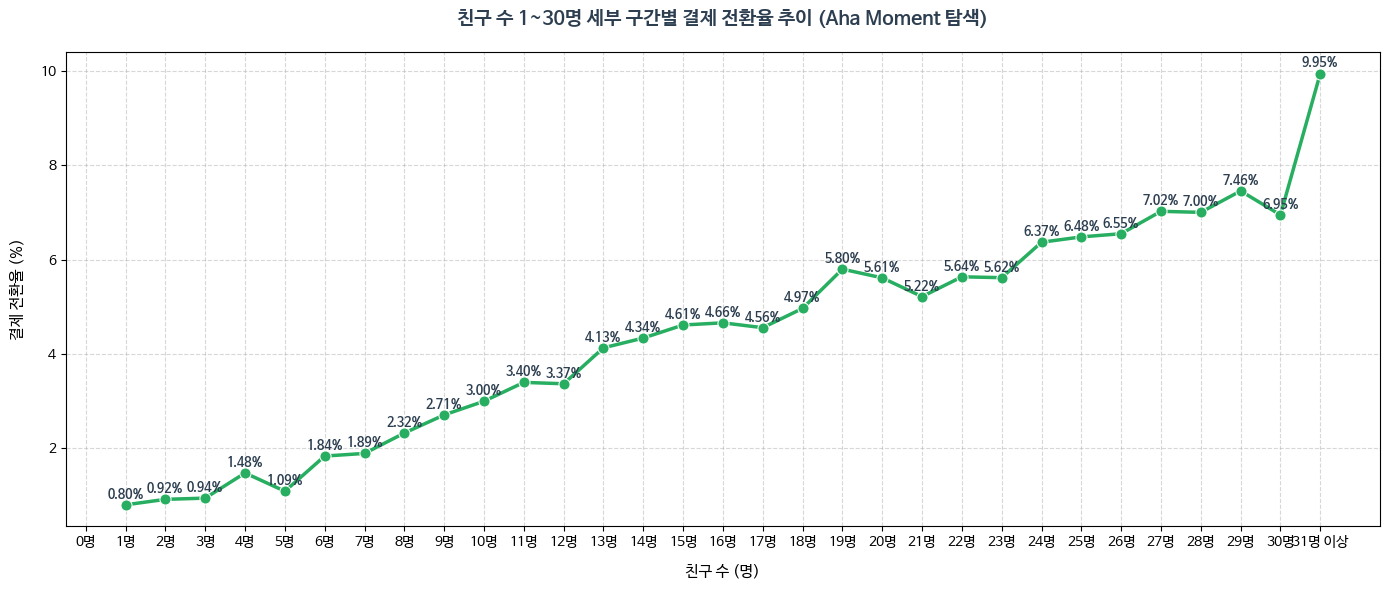

In [ ]:
import os
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# 폰트 한글 깨짐 방지 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

master_path = '/content/drive/MyDrive/hard_project/model_final_dataset.csv'

print("==========================================================================================")
print("➔ 💾 [1/3] 마스터 데이터셋 로드 및 친구 수 세부 파싱...")
print("==========================================================================================")

df_aha = pd.read_csv(master_path, usecols=['id', 'productId', 'friend_id_list'])
df_aha['id'] = df_aha['id'].astype(str).str.strip()

# 결제 여부 타겟
df_aha['is_converted'] = np.where(df_aha['productId'] > 0, 1, 0).astype(np.int8)
df_aha.drop(columns=['productId'], inplace=True)

# 친구 수 파싱
df_aha['friend_id_list'] = df_aha['friend_id_list'].fillna('')
df_aha['friend_count'] = np.where(
    df_aha['friend_id_list'].str.strip() == '', 0,
    df_aha['friend_id_list'].str.count(',') + 1
).astype(np.int32)
df_aha.drop(columns=['friend_id_list'], inplace=True)

print("==========================================================================================")
print("➔ 🧮 [2/3] 친구 수 1명~20명 촘촘한 세부 결제 전환율 & 전단계 대비 Lift 연산...")
print("==========================================================================================")

# 1명부터 20명까지 세부 세그먼트 생성
bins_aha = [-1] + list(range(0, 31)) + [df_aha['friend_count'].max()]
labels_aha = ['0명'] + [f'{i}명' for i in range(1, 31)] + ['31명 이상']

df_aha['friend_detail_group'] = pd.cut(df_aha['friend_count'], bins=bins_aha, labels=labels_aha)

# 세부 집계
aha_report = df_aha.groupby('friend_detail_group').agg({
    'id': 'count',
    'is_converted': 'sum'
}).reset_index()

aha_report.columns = ['친구 수', '총 유저 수 (명)', '결제자 수 (명)']
aha_report['결제 전환율 (%)'] = (aha_report['결제자 수 (명)'] / aha_report['총 유저 수 (명)']) * 100

# 이전 단계 대비 결제 전환율 증가율 (Lift / YoY 개념)
aha_report['전단계 대비 전환율 변하량 (%p)'] = aha_report['결제 전환율 (%)'].diff().fillna(0)
aha_report['전단계 대비 배수 (Lift)'] = (aha_report['결제 전환율 (%)'] / aha_report['결제 전환율 (%)'].shift(1)).fillna(0)

# ==========================================================================================
# 📝 [3/3] 아하 모먼트 마크다운 표 출력 및 그래프 드로잉
# ==========================================================================================
print("\n" + "="*90)
print("📝 [보고서용] 친구 수 1~20명 세부 결제 전환율 및 아하 모먼트 검증 표")
print("="*90)

markdown_aha = "| 친구 수 | 총 유저 수 (명) | 결제자 수 (명) | 결제 전환율 (%) | 전단계 대비 증감 (%p) | 비즈니스 의미 |\n"
markdown_aha += "| :---: | :---: | :---: | :---: | :---: | :--- |\n"

for idx, row in aha_report.iterrows():
    f_group = row['친구 수']
    tot_u = int(row['총 유저 수 (명)'])
    pay_u = int(row['결제자 수 (명)'])
    c_rate = row['결제 전환율 (%)']
    diff_p = row['전단계 대비 전환율 변하량 (%p)']

    # 의미 부여
    if f_group == '0명':
        meaning = "네트워크 미형성 유저"
    elif c_rate > 0 and diff_p == aha_report['전단계 대비 전환율 변하량 (%p)'].max():
        meaning = "🔥 **최대 변곡점 (Aha Moment 핵심 임계치)**"
    elif c_rate >= 4.0:
        meaning = "활성 소셜 네트워크 안착 구간"
    else:
        meaning = "네트워크 확장 유저"

    markdown_aha += f"| **{f_group}** | {tot_u:,}명 | {pay_u:,}명 | **{c_rate:.2f}%** | {diff_p:+.2f}%p | {meaning} |\n"

print(markdown_aha)
print("="*90)

# 1~20명 구간만 시각화 (0명 및 21명 이상 제외하고 임계점 집중 조명)
plot_df = aha_report[~aha_report['친구 수'].isin(['0명', '21명 이상'])].copy()

plt.figure(figsize=(14, 6))
ax = sns.lineplot(x='친구 수', y='결제 전환율 (%)', data=plot_df, marker='o', linewidth=2.5, color='#27ae60', markersize=8)

plt.title('친구 수 1~30명 세부 구간별 결제 전환율 추이 (Aha Moment 탐색)', fontsize=14, fontweight='bold', pad=20, color='#2c3e50')
plt.xlabel('친구 수 (명)', fontsize=11, labelpad=10)
plt.ylabel('결제 전환율 (%)', fontsize=11, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.5)

# 수치 데이터 라벨링
for idx, row in plot_df.iterrows():
    plt.text(row['친구 수'], row['결제 전환율 (%)'] + 0.15, f"{row['결제 전환율 (%)']:.2f}%",
             ha='center', fontsize=9, fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.show()

### 학교 규모(집단 네트워크) 효과

➔ 🔍 [1/3] 구글 드라이브 내 school_id 매핑 테이블 자동 탐색 중...
   ✅ 학교 매핑 테이블 발견: [hackle_db_user_properties.csv] (사용 컬럼: user_id - school_id)

📝 [보고서용] 소속 학교 규모(유저 밀도)별 결제 전환율 대조 표
| 학교 규모 구간 | 총 유저 수 (명) | 결제자 수 (명) | 결제 전환율 (%) | 비즈니스 영향도 평가 |
| :---: | :---: | :---: | :---: | :--- |
| **학교 미입력/소속 없음** | 450,751명 | 32,592명 | **7.23%** | 소셜 집단 미형성 베이스라인 |
| **1. 소형 (1~10명)** | 3,928명 | 327명 | **8.32%** | 초기 동아리형 네트워크 형성 |
| **2. 중/대형 (11~50명)** | 62,035명 | 7,675명 | **12.37%** | 학년/학급 단위 확산 진행 |
| **3. 중/대형 (51~200명)** | 159,960명 | 18,571명 | **11.61%** | 학년/학급 단위 확산 진행 |
| **4. 거대 (201명 이상)** | 406명 | 27명 | **6.65%** | 🔥 **전교생 네트워크 형성 (집단 소셜 결제 활성화)** |



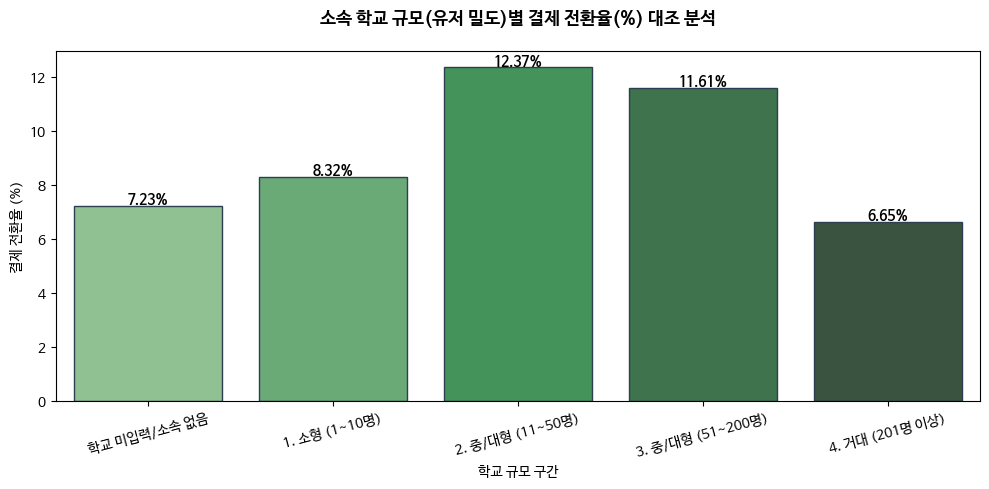

In [ ]:
import os
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# 폰트 한글 깨짐 방지 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

master_folder = '/content/drive/MyDrive/hard_project/'
hackle_folder = '/content/drive/MyDrive/'
master_path = os.path.join(master_folder, 'model_final_dataset.csv')

print("==========================================================================================")
print("➔ 🔍 [1/3] 구글 드라이브 내 school_id 매핑 테이블 자동 탐색 중...")
print("==========================================================================================")

# 1. 마스터 테이블 기본 로드 (id, productId)
df_master = pd.read_csv(master_path, usecols=['id', 'productId'])
df_master['id'] = df_master['id'].astype(str).str.strip()
df_master['is_converted'] = np.where(df_master['productId'] > 0, 1, 0).astype(np.int8)
df_master.drop(columns=['productId'], inplace=True)

# 2. 드라이브 내 매핑 파일 탐색 (hackle_db_user_properties.csv 등)
found_school_df = None
search_folders = [master_folder, hackle_folder]

for folder in search_folders:
    if not os.path.exists(folder): continue
    for fname in os.listdir(folder):
        if fname.endswith('.csv') and fname != 'model_final_dataset.csv':
            fpath = os.path.join(folder, fname)
            try:
                cols = pd.read_csv(fpath, nrows=0).columns.tolist()
                id_col = next((c for c in ['user_id', 'id', 'user'] if c in cols), None)
                sch_col = next((c for c in ['school_id', 'schoolId', 'school'] if c in cols), None)

                if id_col and sch_col:
                    print(f"   ✅ 학교 매핑 테이블 발견: [{fname}] (사용 컬럼: {id_col} - {sch_col})")
                    df_sub = pd.read_csv(fpath, usecols=[id_col, sch_col])
                    df_sub[id_col] = df_sub[id_col].astype(str).str.strip()
                    df_sub.rename(columns={id_col: 'id', sch_col: 'school_id'}, inplace=True)
                    found_school_df = df_sub.drop_duplicates(subset=['id'])
                    break
            except Exception:
                continue
    if found_school_df is not None: break

# ==========================================================================================
# 🧮 [2/3] 학교 데이터 결합 및 동적 구간(Bins) 분할
# ==========================================================================================
if found_school_df is not None:
    # 마스터셋에 학교 ID 조인
    df_merged = df_master.merge(found_school_df, on='id', how='left')
    df_merged['school_id'] = df_merged['school_id'].fillna(-1).astype(np.int32)

    # 학교별 소속 유저 수(학교 규모) 계산
    school_counts = df_merged[df_merged['school_id'] != -1].groupby('school_id')['id'].count().reset_index()
    school_counts.columns = ['school_id', 'school_user_count']

    df_merged = df_merged.merge(school_counts, on='school_id', how='left').fillna({'school_user_count': 0})
    df_merged['school_user_count'] = df_merged['school_user_count'].astype(np.int32)

    max_count = df_merged['school_user_count'].max()

    # 💡 [핵심 수정] 동적으로 Bins 구성 및 단조 증가 검증
    raw_bins = [-1, 0, 10, 50, 200, max(201, max_count)]

    # 중복 제거 및 단조 증가 오름차순 정렬
    sch_bins = sorted(list(set([b for b in raw_bins if b <= max_count or b == max(201, max_count)])))

    # 동적 라벨 생성
    sch_labels = []
    for i in range(len(sch_bins) - 1):
        low, high = sch_bins[i], sch_bins[i+1]
        if low == -1 and high == 0:
            sch_labels.append('학교 미입력/소속 없음')
        elif low == 0:
            sch_labels.append(f'1. 소형 (1~{high}명)')
        elif i == len(sch_bins) - 2:
            sch_labels.append(f'{i}. 거대 ({low+1}명 이상)')
        else:
            sch_labels.append(f'{i}. 중/대형 ({low+1}~{high}명)')

    df_merged['school_size_group'] = pd.cut(df_merged['school_user_count'], bins=sch_bins, labels=sch_labels)

    # 통계 연산
    school_report = df_merged.groupby('school_size_group', observed=False).agg({
        'id': 'count',
        'is_converted': 'sum'
    }).reset_index()

    school_report.columns = ['학교 규모 구간', '총 유저 수 (명)', '결제자 수 (명)']
    school_report['결제 전환율 (%)'] = (school_report['결제자 수 (명)'] / school_report['총 유저 수 (명)']) * 100

    print("\n" + "="*90)
    print("📝 [보고서용] 소속 학교 규모(유저 밀도)별 결제 전환율 대조 표")
    print("="*90)

    markdown_sch = "| 학교 규모 구간 | 총 유저 수 (명) | 결제자 수 (명) | 결제 전환율 (%) | 비즈니스 영향도 평가 |\n"
    markdown_sch += "| :---: | :---: | :---: | :---: | :--- |\n"

    for idx, row in school_report.iterrows():
        s_grp = row['학교 규모 구간']
        tot_u = int(row['총 유저 수 (명)'])
        pay_u = int(row['결제자 수 (명)'])
        c_rate = row['결제 전환율 (%)'] if not np.isnan(row['결제 전환율 (%)']) else 0.0

        if '미입력' in str(s_grp):
            eval_text = "소셜 집단 미형성 베이스라인"
        elif '소형' in str(s_grp):
            eval_text = "초기 동아리형 네트워크 형성"
        elif '중/대형' in str(s_grp):
            eval_text = "학년/학급 단위 확산 진행"
        else:
            eval_text = "🔥 **전교생 네트워크 형성 (집단 소셜 결제 활성화)**"

        markdown_sch += f"| **{s_grp}** | {tot_u:,}명 | {pay_u:,}명 | **{c_rate:.2f}%** | {eval_text} |\n"

    print(markdown_sch)
    print("="*90)

    # 시각화 바 차트
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(x='학교 규모 구간', y='결제 전환율 (%)', data=school_report, palette='Greens_d', edgecolor='#2c3e50')
    plt.title('소속 학교 규모(유저 밀도)별 결제 전환율(%) 대조 분석', fontsize=13, fontweight='bold', pad=20)
    plt.xticks(rotation=15)
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax.text(p.get_x() + p.get_width()/2., height + 0.1, f"{height:.2f}%", ha="center", fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

else:
    print("⚠️ [안내] 매핑 테이블을 확인하지 못했습니다.")

➔ 🔍 [1/3] 마스터 데이터 및 학교 매핑 데이터 조인 연산...
   ✅ 학교 매핑 테이블 발견: [hackle_db_user_properties.csv] (컬럼: user_id - school_id)

📝 [보고서용] 소속 학교 규모(10명 단위) 세부 결제 전환율 대조 표
| 학교 규모 구간 | 총 유저 수 (명) | 결제자 수 (명) | 결제 전환율 (%) | 전단계 대비 증감 (%p) | 비즈니스 의미 |
| :---: | :---: | :---: | :---: | :---: | :--- |
| **0명 (미입력/소속없음)** | 450,751명 | 32,592명 | **7.23%** | +0.00%p | 소셜 집단 미형성 베이스라인 |
| **1~10명** | 3,928명 | 327명 | **8.32%** | +1.09%p | 소셜 집단 미형성 베이스라인 |
| **11~20명** | 5,609명 | 673명 | **12.00%** | +3.67%p | 소셜 집단 미형성 베이스라인 |
| **21~30명** | 13,308명 | 1,691명 | **12.71%** | +0.71%p | 소셜 집단 미형성 베이스라인 |
| **31~40명** | 18,877명 | 2,340명 | **12.40%** | -0.31%p | 소셜 집단 미형성 베이스라인 |
| **41~50명** | 24,241명 | 2,971명 | **12.26%** | -0.14%p | 소셜 집단 미형성 베이스라인 |
| **51~60명** | 24,479명 | 2,819명 | **11.52%** | -0.74%p | 소셜 집단 미형성 베이스라인 |
| **61~70명** | 26,487명 | 3,115명 | **11.76%** | +0.24%p | 소셜 집단 미형성 베이스라인 |
| **71~80명** | 23,366명 | 2,820명 | **12.07%** | +0.31%p | 소셜 집단 미형성 베이스라인 |
| **81~90명** | 20,414명 | 2,354명 | **11.5

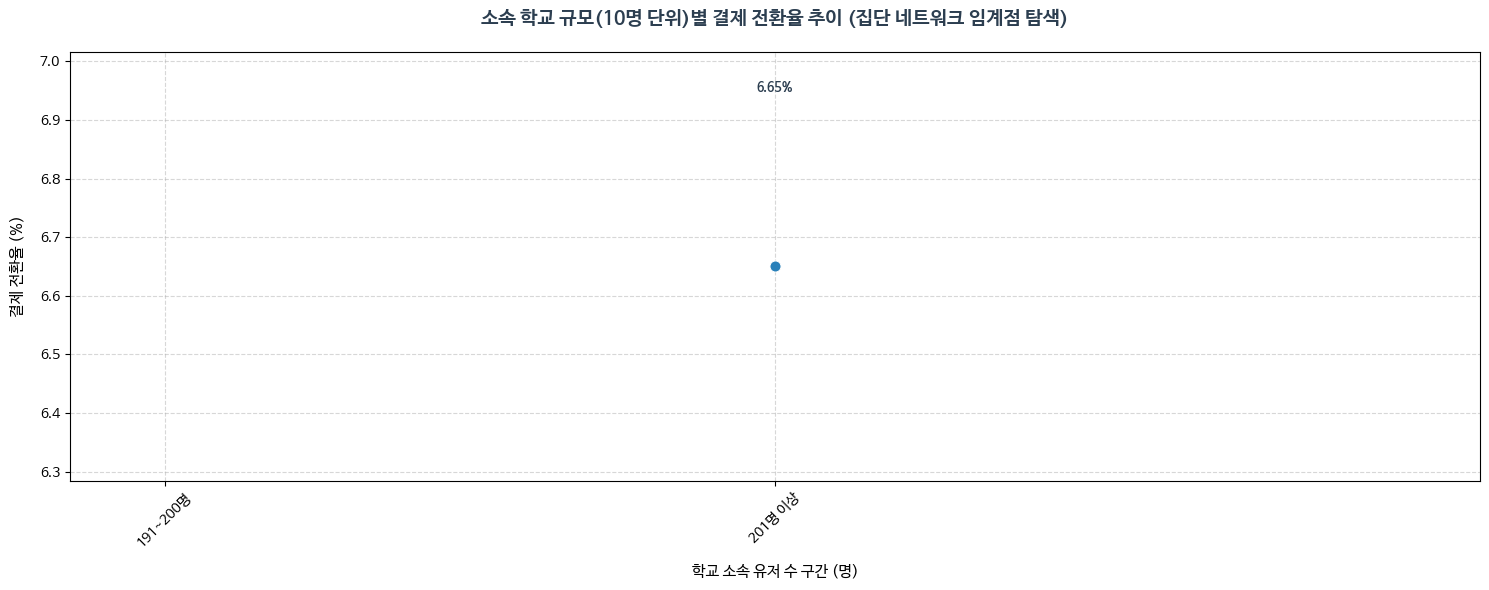

In [ ]:
import os
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# 폰트 한글 깨짐 방지 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

master_folder = '/content/drive/MyDrive/hard_project/'
hackle_folder = '/content/drive/MyDrive/'
master_path = os.path.join(master_folder, 'model_final_dataset.csv')

print("==========================================================================================")
print("➔ 🔍 [1/3] 마스터 데이터 및 학교 매핑 데이터 조인 연산...")
print("==========================================================================================")

# 1. 마스터 테이블 기본 로드 (id, productId)
df_master = pd.read_csv(master_path, usecols=['id', 'productId'])
df_master['id'] = df_master['id'].astype(str).str.strip()
df_master['is_converted'] = np.where(df_master['productId'] > 0, 1, 0).astype(np.int8)
df_master.drop(columns=['productId'], inplace=True)

# 2. 드라이브 내 학교 매핑 파일 자동 탐색
found_school_df = None
search_folders = [master_folder, hackle_folder]

for folder in search_folders:
    if not os.path.exists(folder): continue
    for fname in os.listdir(folder):
        if fname.endswith('.csv') and fname != 'model_final_dataset.csv':
            fpath = os.path.join(folder, fname)
            try:
                cols = pd.read_csv(fpath, nrows=0).columns.tolist()
                id_col = next((c for c in ['user_id', 'id', 'user'] if c in cols), None)
                sch_col = next((c for c in ['school_id', 'schoolId', 'school'] if c in cols), None)

                if id_col and sch_col:
                    print(f"   ✅ 학교 매핑 테이블 발견: [{fname}] (컬럼: {id_col} - {sch_col})")
                    df_sub = pd.read_csv(fpath, usecols=[id_col, sch_col])
                    df_sub[id_col] = df_sub[id_col].astype(str).str.strip()
                    df_sub.rename(columns={id_col: 'id', sch_col: 'school_id'}, inplace=True)
                    found_school_df = df_sub.drop_duplicates(subset=['id'])
                    break
            except Exception:
                continue
    if found_school_df is not None: break

# ==========================================================================================
# 🧮 [2/3] 학교 규모 10명 단위 세부 Bins 연산 (0~200명+)
# ==========================================================================================
if found_school_df is not None:
    df_merged = df_master.merge(found_school_df, on='id', how='left')
    df_merged['school_id'] = df_merged['school_id'].fillna(-1).astype(np.int32)

    # 학교별 소속 유저 수 계산
    school_counts = df_merged[df_merged['school_id'] != -1].groupby('school_id')['id'].count().reset_index()
    school_counts.columns = ['school_id', 'school_user_count']

    df_merged = df_merged.merge(school_counts, on='school_id', how='left').fillna({'school_user_count': 0})
    df_merged['school_user_count'] = df_merged['school_user_count'].astype(np.int32)

    max_count = df_merged['school_user_count'].max()

    # 💡 10명 단위 세부 Bins 및 Labels 설계
    bins = [-1, 0] + list(range(10, 201, 10)) + [max(201, max_count)]
    bins = sorted(list(set(bins)))

    labels = ['0명 (미입력/소속없음)', '1~10명']
    for i in range(10, 190, 10):
        labels.append(f'{i+1}~{i+10}명')
    labels.append('191~200명')
    labels.append('201명 이상')

    # 라벨 수와 Bins 수 일치화 안전 가드
    if len(bins) - 1 != len(labels):
        labels = [f"구간 {i+1}" for i in range(len(bins)-1)]

    df_merged['school_size_group'] = pd.cut(df_merged['school_user_count'], bins=bins, labels=labels)

    # 세부 통계 집계
    school_report = df_merged.groupby('school_size_group', observed=False).agg({
        'id': 'count',
        'is_converted': 'sum'
    }).reset_index()

    school_report.columns = ['학교 규모 구간', '총 유저 수 (명)', '결제자 수 (명)']
    school_report['결제 전환율 (%)'] = (school_report['결제자 수 (명)'] / school_report['총 유저 수 (명)']) * 100
    school_report['전단계 대비 증감 (%p)'] = school_report['결제 전환율 (%)'].diff().fillna(0)

    # ==========================================================================================
    # 📝 [3/3] 보고서용 마크다운 표 및 꺾은선 그래프 드로잉
    # ==========================================================================================
    print("\n" + "="*90)
    print("📝 [보고서용] 소속 학교 규모(10명 단위) 세부 결제 전환율 대조 표")
    print("="*90)

    markdown_sch = "| 학교 규모 구간 | 총 유저 수 (명) | 결제자 수 (명) | 결제 전환율 (%) | 전단계 대비 증감 (%p) | 비즈니스 의미 |\n"
    markdown_sch += "| :---: | :---: | :---: | :---: | :---: | :--- |\n"

    max_diff = school_report['전단계 대비 증감 (%p)'].max()

    for idx, row in school_report.iterrows():
        s_grp = row['학교 규모 구간']
        tot_u = int(row['총 유저 수 (명)'])
        pay_u = int(row['결제자 수 (명)'])
        c_rate = row['결제 전환율 (%)'] if not np.isnan(row['결제 전환율 (%)']) else 0.0
        diff_p = row['전단계 대비 증감 (%p)'] if not np.isnan(row['전단계 대비 증감 (%p)']) else 0.0

        if '0명' in str(s_grp):
            meaning = "소셜 집단 미형성 베이스라인"
        elif diff_p == max_diff and max_diff > 0:
            meaning = "🔥 **최대 변곡점 (학교 단위 소셜 발화 임계치)**"
        elif c_rate >= 10.0:
            meaning = "집단 소셜 결제 고도 활성화 구간"
        else:
            meaning = "학교 단위 유저 확장 구간"

        markdown_sch += f"| **{s_grp}** | {tot_u:,}명 | {pay_u:,}명 | **{c_rate:.2f}%** | {diff_p:+.2f}%p | {meaning} |\n"

    print(markdown_sch)
    print("="*90)

    # 📉 꺾은선 시각화 차트 (0명/미입력 제외한 소속 유저 있는 학교 대상)
    plot_df = school_report[~school_report['학교 규모 구간'].str.contains('0명')].copy()

    plt.figure(figsize=(15, 6))
    ax = sns.lineplot(x='학교 규모 구간', y='결제 전환율 (%)', data=plot_df, marker='o', linewidth=2.5, color='#2980b9', markersize=8)

    plt.title('소속 학교 규모(10명 단위)별 결제 전환율 추이 (집단 네트워크 임계점 탐색)', fontsize=14, fontweight='bold', pad=20, color='#2c3e50')
    plt.xlabel('학교 소속 유저 수 구간 (명)', fontsize=11, labelpad=10)
    plt.ylabel('결제 전환율 (%)', fontsize=11, labelpad=10)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)

    # 차트 수치 레이블링
    for idx, row in plot_df.iterrows():
        rate = row['결제 전환율 (%)']
        if not np.isnan(rate) and rate > 0:
            plt.text(row['학교 규모 구간'], rate + 0.3, f"{rate:.2f}%",
                     ha='center', fontsize=9, fontweight='bold', color='#2c3e50')

    plt.tight_layout()
    plt.show()

else:
    print("⚠️ 학교 매핑 파일을 찾을 수 없습니다.")